# Stock Market Predictor: прогнозирование направления движения акции

## Описание проекта

Проект направлен на построение интерпретируемой модели машинного обучения, которая по историческим дневным данным (OHLCV + технические индикаторы + sentiment score) предсказывает направление движения цены на следующий день (рост/падение).

Датасет содержит 13 647 записей симулированных торговых данных, включая:
- Open, High, Low, Close
- Volume
- RSI
- MACD
- Sentiment Score
- Target (0/1 — движение цены на следующий день)

__Ключевая особенность датасета:__ данные уже содержат рассчитанные технические индикаторы (RSI, MACD) и синтетическую оценку рыночных настроений (Sentiment Score), что позволяет расширить feature engineering и проверить вклад этих признаков в предсказательную силу модели.

__Цель проекта:__
- Разработать интерпретируемую модель бинарной классификации для прогнозирования направления движения цены на следующий день.
  - target = 1 — цена вырастет
  - target = 0 — цена упадёт
- Использовать как классические OHLCV-признаки, так и готовые технические индикаторы и сентимент-оценки.
- Построить устойчивый пайплайн, исключающий "заглядывание в будущее" (look-ahead bias)

__Проект демонстрирует навыки:__
- работы с временными рядами,
- построения признаков,
- анализа сезонности и автокорреляции,
- построения моделей бинарной классификации,
- интерпретации моделей (SHAP),
- оценки устойчивости модели на тесте.

__Актуальность и бизнес-ценность:__
- Прогнозирование движения цен на финансовых рынках является ключевой задачей для трейдеров, инвестиционных фондов и алгоритмических систем.
- Даже небольшое преимущество в предсказании направления (выше/ниже) позволяет строить прибыльные торговые стратегии, управлять рисками и хеджировать позиции.
- В отличие от предсказания точной цены, предсказание направления (Binary Classification) более устойчиво к шуму и часто используется в реальной торговле для генерации сигналов.

__Практическая ценность:__
- Оценка вероятности направления движения цены (рост/падение).
- Формирование простых торговых/аналитических сигналов (например, «ожидается рост»).
- Понимание, какие факторы (признаки) лучше всего объясняют направление движения.

## Выбор метрики

Так как задача — бинарная классификация направления цены, а ложные сигналы могут быть критичны, метрики выбираются с учётом бизнес‑логики:

__Основные метрики:__
- F1-score (класс 1 — рост) — баланс между тем, чтобы не пропустить прибыльное движение (Recall) и не входить в убыточные сделки (Precision)
  - ___основная метрика выбора модели___
- Precision (класс 1) — насколько сигналы роста точны
  - доля верных сигналов роста среди всех сигналов роста
  - важна для минимизации ложных сигналов на покупку
- Recall (класс 1) — насколько модель не пропускает рост
  - доля пойманных движений вверх среди всех реальных движений вверх
  - важна для недопущения пропуска прибыльных движений
  
__Дополнительные метрики:__
- ROC-AUC — способность модели отделять рост от падения
- Accuracy / Directional Accuracy — доля правильных направлений

__Бизнес-интерпретация:__
- Если важно не пропускать рост → акцент на Recall
- Если важно минимизировать ложные сигналы → акцент на Precision
- Финальное качество оценивается с учётом threshold-tuning под конкретную стратегию

## Описание данных

- Источник: Kaggle - Stock Market Dataset for Predictive Analysis
  - https://www.kaggle.com/datasets/s3programmer/stock-market-dataset-for-predictive-analysis
- Файл: stock_market_data_large.csv
- Объём: 13 647 записей дневных торгов (симулированные данные)

__Структура датасета:__
- Датасет содержит 13 647 строк и представляют собой стандартный временной ряд OHLCV (Open, High, Low, Close, Volume) и дополнительными признаками:
  - __Date__ — дата торгов (только рабочие дни)
  - __Open__ — дневные цены открытия
  - __High__ — максимальная цена за день
  - __Low__ —  минимальная цена за день
  - __Close__ — дневные цены закрытия
  - __Volume__ — объём торгов
  - __RSI (Relative Strength Index)__ —  индекс относителтной силы перекупленности/перепроданности (индикатор силы тренда)
  - __MACD (Moving Average Convergence Divergence)__ — схождение/расхождение скользящих средних (индикатор тренда и импульса)
  - __Sentiment Score__ — синтетическая оценка рыночных настроений (симулированный новостной/социальный сентимент)
  - __Target__ — целевая переменная (бинарный признак):
    - 1 — цена завтра выше
    - 0 — цена завтра упадёт

__Особенности датасета:__
- Данные симулированы, но структура полностью соответствует реальным рынкам
- Присутствуют технические индикаторы (RSI, MACD) и sentiment score
- Target уже рассчитан - направление на следующий день
- Даты идут по торговым дням (без выходных), важно сохранять хронологию
- Финансовая природа: возможны тренды, волатильность, сезонность (по дням недели, месяцам, фазам рынка)
- Индексация по времени критична — перемешивать данные при кросс-валидации стандартным способом (K-Fold) нельзя
- Датасет подходит для ML, DL и гибридных моделей

## Цели исследования

__Основные цели:__
- Построить модель бинарной классификации для предсказания target (направление цены на следующий день)
- Оценить качество модели на валидации и тесте
- Проверить устойчивость модели во времени
- Избежать look-ahead bias и утечек данных
- Сравнить вклад классических OHLCV-признаков, технических индикаторов и сентимент-оценок

__Аналитические цели:__
- Проверить временную структуру данных
- Изучить сезонность, тренды, волатильность
- Проверить автокорреляцию и значимость лагов
- Исследовать распределения цен, объёма, индикаторов
- Исследовать распределение и поведение Sentiment Score
- Проверить корректность готовых индикаторов RSI и MACD (соответствие стандартным формулам)
- Оценить корреляции и мультиколлинеарность
- Выявить наиболее информативные признаки

__Моделирование:__
- Сравнить несколько моделей (логистическая регрессия, деревья/ансамбли).
- Использовать time series split (валидация по времени, без перемешивания).
- Оценить устойчивость модели на отложенном тесте.

## Ход исследования

__Шаг 1: Загрузка и первичный анализ данных__
- Загрузка датасета
- Приведение типов
- Проверка структуры : shape, dtypes, info(), describe()
- Проверка временной структуры (монотонность дат)
- Проверка пропусков и дубликатов
- Проверка целевой переменной:
  - Анализ распределения target
  - Проверка логики target через close.shift(-1)
- Проверка готовых индикаторов:
  - верификация RSI по формуле (period=14)
  - верификация MACD (12, 26, 9)
- Проверка на утечку сентимента
  - Sentiment Score в реальном мире не известен заранее
  - Проверьте, нет ли в его расчёте использования будущих данных

__Шаг 2: Feature Engineering__
- 2.1. Свечные признаки:
  - body — размер тела свечи
  - upper_shadow — верхняя тень
  - lower_shadow — нижняя тень
  - high_low_ratio — внутридневная волатильность
  - close_position — позиция закрытия в диапазоне
- 2.2. Лаги и доходности:
  - return_1d — логарифмическая дневная доходность
  - return_lag1, return_lag2, vol_lag2 — лаги доходностей
  - close_lag1, vol_lag1 — лаги цены и объёма
  - overnight_return — гэп между сессиями
- 2.3. Скользящие статистики:
  - sma_5, sma_10, sma_20, sma_50 — скользящие средние
  - close_sma20_dist — расстояние от тренда
  - rolling_std_5, rolling_std_10 — скользящая волатильность
  - rolling_max_5, rolling_min_5 — уровни поддержки/сопротивления
  - dist_to_high_5, dist_to_low_5 — расстояние до экстремумов
  - vol_ma_5, vol_ma_10, vol_ratio_5, dist_to_low_5 — скользящий объём и его отношение
- 2.4. Технические индикаторы: 
  - roc_5 — Rate of Change за 5 дней
  - rsi_lag1, macd_lag1 - лаги готовых индикаторов
  - сигналы пересечения MACD  
  - macd_hist - производные от MACD
- 2.5. Признаки сентимента Sentiment Score:
  - sentiment_lag1, sentiment_lag2 — лаги сентимента
  - sentiment_ma_5, sentiment_sma_10 — скользящее среднее сентимента
  - sentiment_rolling_std_5, sentiment_rolling_std_10 — волатильность сентимента
  - sentiment_change — изменение сентимента
- 2.6. Календарные признаки:
  - day_of_week — день недели
  - month — месяц
  - quarter — квартал
  
___Важно___
- Все признаки должны использовать только прошлые данные
- Проверка на NaN/inf
- Удаление первых N строк после rolling

__Шаг 3: EDA__
- 3.1. Базовые распределения:
  - Распределение целевой переменной target
  - Распределения цен, объёма, доходностей (log returns)
  - Ящик с усами для анализа выбросов
  - Проверка нормальности распределения доходностей:
    - Q-Q plot
    - тест Шапиро–Уилка
    - анализ хвостов распределения
  - Распределение Sentiment Score: гистограмма, boxplot по target
  - Визуализация сентимента:Sentiment Score vs next day return
- 3.2. Временные графики:
  - close vs date (общий тренд)
    - отметить на графике точки, где target=1 (зеленым) и target=0 (красным), чтобы увидеть тренды.
  - vol vs date (изменение активности)
  - RSI, MACD и Sentiment Score во времени
  - Совместный график: цена + сентимент (двойная ось Y)
- 3.3. Декомпозиция и сезонность:
  - Декомпозиция временного ряда close (trend, seasonality, residuals)
  - Сезонность по месяцам и дням недели
  - Скользящее стандартное отклонение остатков
  - Анализ волатильности во времени
- 3.4. Автокорреляция и лаги:
  - Проверка стационарности
  - ACF/PACF
- 3.5. Корреляционный анализ:
  - построить тепловую карту корреляций Пирсона между признаками
  - исключить мультиколлинеарность
- 3.6. Анализ сентимента:
  - Распределение Sentiment Score по классам target
  - Корреляция сентимента с доходностью следующего дня
  - Автокорреляция сентимента (ACF/PACF)
  - Проверка на утечку: сентимент не должен зависеть от future returns

__Шаг 4: Подготовка к моделированию__
- 4.1. Выбор признаков для модели на основе EDA:
  - исключить сырые нестационарные ценовые признаки
  - сформировать раздельные наборы для линейных моделей и деревьев
  - проверить мультиколлинеарность финального набора  
- 4.2. Удаление Look-Ahead Bias и обработка пропусков:
  - проверить созданные признаки на наличие inf и NaN
  - из-за создания лагов и скользящих окон первые N строк станут NaN.
  - их нужно удалить (dropna()), так как модели не работают с пропусками
- 4.3. Проверка утечки данных (Data Leakage):
  - по именам признаков
  - по логике построения
  - по корреляции с target на train/valid/test  
- 4.4. Формирование выборок:
  - разделение на признаки X и цель y
- 4.5. Разделение на train/valid/test с учётом времени:
  - train/valid через TimeSeriesSplit и  Walk-Forward Validation (кросс-валидация по времени)
  - схема: обучаемся на прошлом, валидируемся на будущем:
    - Train: первые 70% данных
    - Valid: следующие 15%
    - Test: последние 15% (не трогать до финальной оценки)
- 4.6.Определение признаков для разных моделей
- 4.7. Масштабирование и кодирование:
  - StandardScaler или RobustScaler (устойчив к выбросам) по числовым признакам
  - fit только на train, transform на train/valid/test
  - Кодирование для day_of_week и month

__Шаг 5: Моделирование__
- 5.1. Бейзлайн: DummyClassifier:
  - стратегия: "most_frequent","stratified", "naive strategy" («наивный» финансовый бейзлайн)
  - покажет, насколько наша модель лучше простого угадывания
- 5.2. Логистическая регрессия LogReg:
  - с регуляризацией (L2)
  - со стандартизацией признаков
  - подбор C через GridSearchCV + TimeSeriesSplit
  - оценка коэффициентов (какие признаки увеличивают вероятность роста)
- 5.3. Модели деревьев и ансамблей:
  - Decision TreeClassifier — как базовый нелинейный алгоритм
  - RandomForestClassifier, Gradient Boosting (XGBoost/LightGBM):
    - подбор гиперпараметров (GridSearchCV или RandomizedSearchCV) с TimeSeriesSplit
    - сравнение по выбранной основной метрике (например, F1 или ROC-AUC)
- 5.4 (Опционально) Deep Learning: LSTM
  - для LSTM нужно преобразовать данные в последовательности (окна):
    - X_t = [t-10, t-9, ..., t]
    - y_t = target(t+1)
  - отдельная копия признаков, нормализованную в диапазон [0,1] (MinMaxScaler) для LSTM 
  - 1–2 слоя LSTM
  - маленькое число нейронов (например 32–64)
  - sequence length = 10–30
  - Ограничить обучение:
    - epochs: 5–15
    - batch size: 32–64
- 5.5. Валидация и выбор лучшей модели: 
  - использовать TimeSeriesSplit
  - для каждой модели:
    - метрики на train и validation (или через кросс-валидацию)
    - проверка на переобучение (слишком высокий train vs низкий test)
  - выбор лучшей модели по основной метрике:
    - сравнительная таблица: CV F1, Valid F1, Valid Precision, Valid Recall
    - сравнить модели по F1-score на валидационной выборке и выбрать лучшую.
- 5.6 Выбор порога (по умолчанию порог 0.5):
  - как меняются Precision/Recall при изменении порога:
    - график Precision/Recall/F1 vs Threshold
    - таблица метрик при разных порогах
  - выбрать порог под конкретную «стратегию» (например, повышаем Precision, чтобы уменьшить ложные сигналы)
- 5.7 Калибровка вероятностей:
  - Platt scaling или Isotonic Regression
  - сравнение калиброванных и некалиброванных вероятностей

__Шаг 6: Оценка на тесте__
- 6.1. Метрики для выбранной лучшей модели на тесте:
  - Accuracy,Directional Accuracy, Precision, Recall, F1, ROC-AUC
  - отчёт classification_report (precision, recall, f1-score)
- 6.2. Матрица ошибок (Confusion matrix)  на тесте:
  - Интерпретация:
    - сколько верных предсказаний роста/падения
    - сколько ложных сигналов
    - сколько пропущенных движений
- 6.3. ROC и PR-кривые на тесте
- 6.4. Проверка распределения ошибок модели на тесте:
  - Распределение вероятностей по типу ошибки (FP, FN, correct)
  - Ошибки во времени: есть ли кластеризация в определённые периоды
- 6.5. Анализ стабильности модели во времени:
  - метрики по годам/кварталам;
  - проверка деградации качества на последних данных.

__Шаг 7: Интерпретация__
- 7.1. Важность признаков: feature importance
- 7.2. SHAP-анализ:
  - глобальная важность признаков (summary plot);
  - локальные объяснения отдельных предсказаний;
  - зависимость предсказаний от ключевых признаков (RSI, MACD, Sentiment Score);
  - проверка, какие признаки дают наибольший вклад в сигналы модели;
  - анализ TP vs FP
- 7.3. Проверка стабильность важности признаков importance stability на  train, validation, test:
  - Сравнение топ-признаков на train / validation / test
  - Устойчив ли Sentiment Score как предиктор?
- 7.4. Аналитические инсайты:
  - Какие признаки сильнее всего связаны с направлением
  - Технические индикаторы vs Sentiment Score: кто важнее?
  - Есть ли устойчивые паттерны в данных
  - В каких условиях модель ошибается чаще

__Шаг 8: Заключительный отчёт и выводы__
- Краткое описание данных и задачи
- Ключевые результаты EDA, включая анализ сентимента
- Описание созданных признаков и обоснование отбора
- Результаты моделирования: сравнительная таблица
- Интерпретация модели
- Инсайты
- Ограничения
- Идеи для развития

## Ожидаемые результаты

- Ноутбук (Jupyter Notebook) с полным кодом, визуализациями и выводами
- Обязательные ячейки:
  - Вывод метрик (F1, Precision, Recall, ROC-AUC) на тренировочной выборке
  - Вывод метрик на тестовой выборке
  - Матрица ошибок (Confusion Matrix) для train и test
- Графики:
  - График цены с разметкой реальных и предсказанных трендов
  - ROC-кривая
  - PR-кривая
  - Топ-10 самых важных признаков (feature importance / SHAP)
  - Матрица ошибок (heatmap)
  - График стабильности модели по времени
  - График Sentiment Score vs доходность следующего дня
- Выводы:
  - Краткое резюме: насколько модель эффективнее случайного угадывания
  - Какие признаки оказались наиболее информативными (особенно RSI, MACD, Sentiment Score)
  - Вклад сентимент-оценок в предсказание направления
  - Почему модель может ошибаться и в каких условиях её нельзя применять

<a class="anchor" id="contents"></a>
# Содержание:<a class="anchor" id="ch5"></a>

* [Шаг 1: Загрузка, первичный осмотр и предобработка данных](#ch5_1)
* [Шаг 2: Feature Engineering](#ch5_2)
  * [2.1 Свечные признаки](#ch5_2_1)
  * [2.2 Лаги и доходности](#ch5_2_2)
  * [2.3 Скользящие статистики](#ch5_2_3)
  * [2.4. Технические индикаторы](#ch5_2_4)
  * [2.5. Признаки сентимента](#ch5_2_5)
  * [2.6. Календарные признаки](#ch5_2_6)
* [Шаг 3: Исследовательский анализ данных (EDA) для временных рядов](#ch5_3)
  * [3.1. Базовые распределения](#ch5_3_1)
  * [3.2. Временные графики](#ch5_3_2)
  * [3.3. Декомпозиция и сезонность](#ch5_3_3)
  * [3.4. Автокорреляция и лаги](#ch5_3_4)
  * [3.5. Корреляционный анализ](#ch5_3_5)
  * [3.6. Анализ сентимента](#ch5_3_6)
* [Шаг 4: Подготовка к моделированию](#ch5_4)
  * [4.1. Выбор признаков для модели на основе EDA](#ch5_4_1)
  * [4.2. Удаление Look-Ahead Bias и обработка пропусков](#ch5_4_2) 
  * [4.3. Проверка утечки данных (Data Leakage)](#ch5_4_3)  
  * [4.4. Формирование выборок](#ch5_4_4)
  * [4.5. Разделение на train/valid/test с учётом времени](#ch5_4_5)
  * [4.6. Определение признаков для разных моделей](#ch5_4_6)
  * [4.7. Масштабирование и кодирование](#ch5_4_7)
* [Шаг 5: Моделирование](#ch5_5)
  * [5.1. Бейзлайн: DummyClassifier](#ch5_5_1)
  * [5.2. Логистическая регрессия LogReg](#ch5_5_2)
  * [5.3. Модели деревьев и ансамблей](#ch5_5_3)
  * [5.4 (Опционально) Deep Learning: LSTM](#ch5_5_4)
  * [5.5. Валидация и выбор лучшей модели](#ch5_5_5)
  * [5.6 Выбор порога (по умолчанию порог 0.5)](#ch5_5_6)
  * [5.7 Калибровка вероятностей](#ch5_5_7)
* [Шаг 6: Оценка на тесте](#ch5_6)
  * [6.1. Метрики для выбранной лучшей модели на тесте](#ch5_6_1)
  * [6.2. Матрица ошибок (Confusion matrix) на тесте](#ch5_6_2)
  * [6.3. ROC и PR-кривые на тесте](#ch5_6_3)
  * [6.4. Проверка распределения ошибок модели на тесте](#ch5_6_4)
  * [6.5. Анализ стабильности модели во времени](#ch5_6_5)
* [Шаг 7: Интерпретация](#ch5_7)  
  * [7.1. Важность признаков: feature importance](#ch5_7_1)
  * [7.2. SHAP-анализ](#ch5_7_2)
  * [7.3. Проверка стабильность важности признаков importance stability на  train, validation, test](#ch5_7_3)
  * [7.4. Аналитические инсайты](#ch5_7_4)
* [Шаг 8: Заключительный отчёт и выводы ](#ch5_8)    
  * [8.1 Краткое описание данных и задачи](#ch5_8_1)
  * [8.2 Ключевые результаты EDA, включая анализ сентимента](#ch5_8_2)
  * [8.3 Описание созданных признаков и обоснование отбора](#ch5_8_3)
  * [8.4 Результаты моделирования: сравнительная таблица](#ch5_8_4)
  * [8.5 Интерпретация модели](#ch5_8_5)
  * [8.6 Инсайты](#ch5_8_6)
  * [8.7 Ограничения](#ch5_8_7)
  * [8.8 Идеи для развития](#ch5_8_8)

# Выполнение проекта

## Технический стек

- Проект написан на Python с использованием следующих библиотек:

In [1]:
# ============================================
# 📦 БАЗОВЫЕ БИБЛИОТЕКИ
# ============================================
import os
import time
import requests
import numpy as np
import pandas as pd

# ============================================
# 📊 ВИЗУАЛИЗАЦИЯ
# ============================================
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================
# 📈 ВРЕМЕННЫЕ РЯДЫ И СТАТИСТИКА
# ============================================
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from scipy.stats import shapiro, probplot, normaltest, ks_2samp
# ============================================
# 🔗 КОРРЕЛЯЦИИ (PHIK)
# ============================================
from phik import resources, report
from phik.report import plot_correlation_matrix

# ============================================
# 🤖 МАШИННОЕ ОБУЧЕНИЕ
# ============================================
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.model_selection import (
    TimeSeriesSplit, GridSearchCV, cross_validate
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, make_scorer,
    roc_auc_score, roc_curve, auc, average_precision_score, brier_score_loss,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay, precision_recall_curve
)

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

from sklearn.calibration import CalibratedClassifierCV
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.utils import resample
from sklearn.feature_selection import mutual_info_classif

from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# ============================================
# ⚡ ГРАДИЕНТНЫЕ БУСТИНГИ
# ============================================
from xgboost import XGBClassifier
import lightgbm as lgb

# ============================================
# 🔍 ИНТЕРПРЕТАЦИЯ МОДЕЛЕЙ
# ============================================
import shap


# ============================================
# LSTM
# ============================================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
from keras.layers import Input, LSTM, Dense

In [2]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

## Шаг 1: Загрузка, первичный осмотр и предобработка данных <a class="anchor" id="ch5_1"></a>

- Загрузка данных

In [3]:
# -----------------------------
# 1. Загрузка данных
# -----------------------------
def process_dataframe(file_path):
    if os.path.exists(file_path):
        print("Загружаем CSV-файл...")

        df = pd.read_csv(
            file_path,
            index_col=0,      # первый столбец — дата
            parse_dates=[0]   # преобразуем дату
        )
    else:
        print("Ошибка: локальный файл не найден.")
        return None

    print("\nПервые 8 строк датафрейма:")
    display(df.head(8))

    print("\nЛюбые 5 строк датафрейма:")
    display(df.sample(5))

    print("\nПоследние 8 строк датафрейма:")
    display(df.tail(8))

    print("\nИнформация о датафрейме:")
    df.info()

    print("\nРазмер датафрейма:")
    print(df.shape)

    print("\nНазвание столбцов датафрейма:")
    print(df.columns)

    return df

In [4]:
# Вызов функции
df = process_dataframe("stock_market_data_large.csv")

Загружаем CSV-файл...

Первые 8 строк датафрейма:


,Open,High,Low,Close,Volume,RSI,MACD,Sentiment,Target
Date,,,,,,,,,
2010-01-01,100.309172,102.741242,99.822837,101.381330,743835,75.905800,0.000000,0.058089,0
2010-01-04,101.147509,101.681257,99.244474,100.396541,2693069,81.444127,-0.078559,0.751219,1
2010-01-05,101.567491,103.949668,101.509347,103.012156,3027306,71.544018,0.069441,0.979723,1
2010-01-06,104.247814,106.652559,102.760082,105.846343,4341338,73.683548,0.410693,-0.858008,0
2010-01-07,105.339440,105.983592,103.517541,104.721465,2106182,72.675179,0.583641,0.264456,0
2010-01-08,103.706622,106.241324,103.106346,104.405219,3688429,62.470552,0.687263,-0.063076,1
2010-01-11,106.970913,108.267172,105.139529,106.597955,3909135,65.151281,0.935535,0.078400,1
2010-01-12,108.463029,111.081403,107.759084,109.603060,1756061,55.483691,1.359113,-0.596560,0



Любые 5 строк датафрейма:


,Open,High,Low,Close,Volume,RSI,MACD,Sentiment,Target
Date,,,,,,,,,
2024-12-16,239.626180,240.624056,238.866939,240.264949,4511647,69.662812,-1.140094,-0.775867,1
2052-05-22,-22.720548,-20.981635,-24.649545,-23.671016,706395,37.792678,0.672296,0.832655,1
2056-06-02,-14.626169,-13.655832,-17.326523,-15.917617,2962170,69.337850,1.207474,0.868082,1
2022-02-14,251.259856,251.913430,250.228390,251.420596,4561673,24.511680,-4.442538,-0.165847,0
2016-07-28,266.991686,268.274327,265.172104,267.320672,2125324,56.251907,2.654347,-0.894358,0



Последние 8 строк датафрейма:


,Open,High,Low,Close,Volume,RSI,MACD,Sentiment,Target
Date,,,,,,,,,
2062-04-13,46.045964,48.724759,44.791186,47.274570,4178809,34.819022,-1.279174,-0.059487,1
2062-04-14,46.428014,48.819090,45.392220,47.307494,457722,32.054846,-1.282099,-0.173099,0
2062-04-17,45.709227,46.944341,44.717310,45.575060,2115009,27.268122,-1.407980,0.022578,0
2062-04-18,43.275041,44.410580,41.142970,41.605722,2764137,31.764587,-1.807202,0.038068,0
2062-04-19,39.024132,41.984653,38.621644,39.210815,1784838,30.837099,-2.290434,0.115523,1
2062-04-20,42.843140,43.711000,39.998519,42.635796,2142188,29.479917,-2.369715,0.636065,0
2062-04-21,41.636775,42.925515,40.098662,41.206622,1160555,34.398739,-2.518833,-0.143514,0
2062-04-24,40.904850,43.993635,39.333408,40.781086,2481904,19.850684,-2.640904,-0.568854,0



Информация о датафрейме:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 13647 entries, 2010-01-01 to 2062-04-24
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       13647 non-null  float64
 1   High       13647 non-null  float64
 2   Low        13647 non-null  float64
 3   Close      13647 non-null  float64
 4   Volume     13647 non-null  int64  
 5   RSI        13647 non-null  float64
 6   MACD       13647 non-null  float64
 7   Sentiment  13647 non-null  float64
 8   Target     13647 non-null  int64  
dtypes: float64(7), int64(2)
memory usage: 1.0 MB

Размер датафрейма:
(13647, 9)

Название столбцов датафрейма:
Index(['Open', 'High', 'Low', 'Close', 'Volume', 'RSI', 'MACD', 'Sentiment',
       'Target'],
      dtype='object')


In [5]:
df.columns = df.columns.str.lower()

In [6]:
print("\nТипы данных:")
print(df.dtypes)


Типы данных:
open         float64
high         float64
low          float64
close        float64
volume         int64
rsi          float64
macd         float64
sentiment    float64
target         int64
dtype: object


In [7]:
print("\nДубликаты дат:")
print(df.index.duplicated().sum())


Дубликаты дат:
0


In [8]:
print("Уникальных дат:", df.index.nunique())
print("Всего строк:", len(df))

Уникальных дат: 13647
Всего строк: 13647


In [9]:
df.describe()

,open,high,low,close,volume,rsi,macd,sentiment,target
count,13647.000000,13647.000000,13647.000000,13647.000000,1.364700e+04,13647.000000,13647.000000,13647.000000,13647.000000
mean,101.096760,102.600108,99.599301,101.096959,2.563550e+06,49.906274,-0.026986,-0.001146,0.500916
std,101.152616,101.177291,101.162439,101.159203,1.404601e+06,15.040947,2.203216,0.573574,0.500017
min,-57.993581,-56.565948,-60.262371,-58.538240,1.003100e+05,0.000000,-7.384103,-0.999338,0.000000
25%,16.763759,18.101178,15.121420,16.711654,1.356426e+06,39.576585,-1.472511,-0.499346,0.000000
50%,75.232057,76.765118,73.833890,75.271538,2.550567e+06,49.911584,0.012284,0.003138,1.000000
75%,171.281978,172.948561,169.665120,171.278812,3.779358e+06,60.220491,1.416378,0.491161,1.000000
max,322.996012,323.769348,320.949858,323.622138,4.999938e+06,97.614964,7.288539,0.999824,1.000000


- Проверка на отрицательные цены (sanity check)

In [10]:
print("Минимальные значения цен:")
print(df[["open","high","low","close"]].min())

Минимальные значения цен:
open    -57.993581
high    -56.565948
low     -60.262371
close   -58.538240
dtype: float64


In [11]:
# Дополнительная проверка отрицательных цен
negative_prices = {
    'open': (df['open'] < 0).sum(),
    'high': (df['high'] < 0).sum(),
    'low': (df['low'] < 0).sum(),
    'close': (df['close'] < 0).sum()
}
print("Количество отрицательных значений в ценовых признаках:")
for col, count in negative_prices.items():
    print(f"  {col}: {count} ({count/len(df)*100:.2f}%)")

Количество отрицательных значений в ценовых признаках:
  open: 2208 (16.18%)
  high: 2121 (15.54%)
  low: 2328 (17.06%)
  close: 2218 (16.25%)


- Проверка временной структуры

In [12]:
# ============================================================
# 2. Проверка временной структуры
# ============================================================

print("\nПроверяем монотонность индекса (дат):")
print(df.index.is_monotonic_increasing)


# Если даты не монотонны — сортируем
if not df.index.is_monotonic_increasing:
    df = df.sort_index()
    print("Даты были не монотонны — выполнена сортировка по индексу.")
else:
    print("Даты уже монотонны — сортировка не требуется.")
    
# Дополнительная защита
assert df.index.is_monotonic_increasing, "Индекс дат должен быть монотонным!"


Проверяем монотонность индекса (дат):
True
Даты уже монотонны — сортировка не требуется.


In [13]:
# Проверка пропущенных календарных дат
all_dates = pd.date_range(start=df.index.min(), end=df.index.max(), freq="D")
missing_dates = all_dates.difference(df.index)

print("\nКоличество пропущенных календарных дат:", len(missing_dates))
if len(missing_dates) > 0:
    print("Примеры пропущенных дат:", missing_dates[:10])
    
print("Пропуски связаны с выходными и праздниками биржи — это нормально.")


Количество пропущенных календарных дат: 5460
Примеры пропущенных дат: DatetimeIndex(['2010-01-02', '2010-01-03', '2010-01-09', '2010-01-10',
               '2010-01-16', '2010-01-17', '2010-01-23', '2010-01-24',
               '2010-01-30', '2010-01-31'],
              dtype='datetime64[ns]', freq=None)
Пропуски связаны с выходными и праздниками биржи — это нормально.


In [14]:
# Проверка: являются ли пропущенные даты выходными?
missing_weekends = missing_dates[missing_dates.dayofweek >= 5]
print(f"Из {len(missing_dates)} пропущенных дат {len(missing_weekends)} — выходные ({len(missing_weekends)/len(missing_dates)*100:.1f}%)")

Из 5460 пропущенных дат 5460 — выходные (100.0%)


In [15]:
print(f"Период данных: {df.index.min()} → {df.index.max()}")
print(f"Всего лет: {(df.index.max() - df.index.min()).days / 365.25:.1f}")

Период данных: 2010-01-01 00:00:00 → 2062-04-24 00:00:00
Всего лет: 52.3


- Обработка пропусков

In [16]:
# ============================================================
# 3. Обработка пропусков
# ============================================================

print("\nПропуски по столбцам:")
print(df.isna().sum())


Пропуски по столбцам:
open         0
high         0
low          0
close        0
volume       0
rsi          0
macd         0
sentiment    0
target       0
dtype: int64


- Проверка дубликатов

In [17]:
# ============================================================
# 4. Проверка дубликатов
# ============================================================

dups = df.duplicated().sum()
print("\nКоличество дубликатов:", dups)


Количество дубликатов: 0


- Проверка целевой переменной

In [18]:
# ============================================================
# 5. Проверка целевой переменной
# ============================================================

print("\nРаспределение target:")
print(df["target"].value_counts(normalize=True))


Распределение target:
target
1    0.500916
0    0.499084
Name: proportion, dtype: float64


In [19]:
# Логическая проверка соответствия target направлению цены
df["target_check"] = (df["close"].shift(-1) > df["close"]).astype(int)

comparison = df.iloc[:-1]   # убираем последнюю строку

mismatch = (comparison["target"] != comparison["target_check"]).sum()
print("\nНесовпадений между target и target_check:", mismatch)

if mismatch > 0:
    print("\nПримеры несовпадений:")
    display(df[df["target"] != df["target_check"]].head())


Несовпадений между target и target_check: 0


- Верификация RSI (period=14)

In [20]:
def compute_rsi(close, period=14):
    delta = close.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(period).mean()
    avg_loss = loss.rolling(period).mean()

    rs = avg_gain / avg_loss
    rsi_calc = 100 - (100 / (1 + rs))
    return rsi_calc

df["rsi_check"] = compute_rsi(df["close"])

# сравним
corr_rsi = df[["rsi", "rsi_check"]].corr().iloc[0,1]
print("Корреляция RSI и RSI_check:", corr_rsi)

Корреляция RSI и RSI_check: 0.5434140205567018


In [21]:
def compute_rsi_ema(close, period=14):
    delta = close.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.ewm(alpha=1/period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/period, adjust=False).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

df["rsi_check_ema"] = compute_rsi_ema(df["close"])

corr_rsi_ema = df[["rsi", "rsi_check_ema"]].corr().iloc[0,1]
print("Корреляция RSI и RSI_check_ema:", corr_rsi_ema)

Корреляция RSI и RSI_check_ema: 0.598577245124622


In [22]:
# Проверка RSI на корректность диапазона
rsi_out_of_range = ((df['rsi'] < 0) | (df['rsi'] > 100)).sum()
print(f"RSI вне диапазона [0,100]: {rsi_out_of_range} ({rsi_out_of_range/len(df)*100:.2f}%)")
if rsi_out_of_range > 0:
    print("Примеры:", df[df['rsi'] > 100][['rsi']].head())

RSI вне диапазона [0,100]: 0 (0.00%)


- Верификация MACD (12, 26, 9)

In [23]:
ema12 = df["close"].ewm(span=12, adjust=False).mean()
ema26 = df["close"].ewm(span=26, adjust=False).mean()
macd_check = ema12 - ema26

corr_macd = pd.concat([df["macd"], macd_check], axis=1).corr().iloc[0,1]
print("Корреляция MACD и MACD_check:", corr_macd)

Корреляция MACD и MACD_check: 0.9999999999999996


- Проверка на утечку сентимента (Sentiment Score)

In [24]:
corr_sent_target = df["sentiment"].corr(df["target"])
corr_sent_target_check = df["sentiment"].corr(df["target_check"])

print("Корреляция Sentiment с target:", corr_sent_target)
print("Корреляция Sentiment с target_check:", corr_sent_target_check)

Корреляция Sentiment с target: 0.005061745750047568
Корреляция Sentiment с target_check: 0.005061745750047568


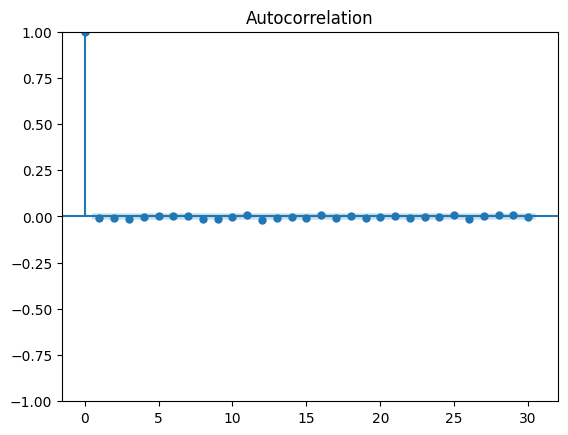

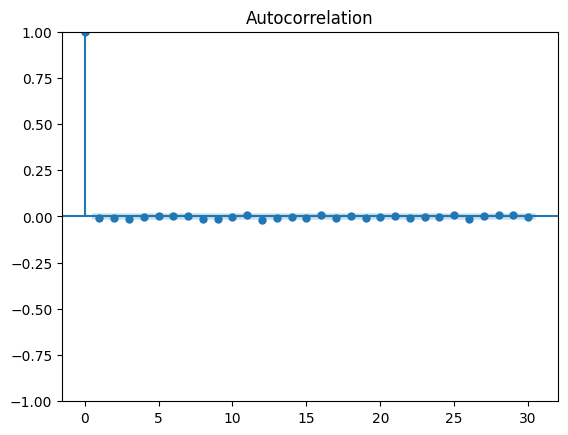

In [25]:
plot_acf(df["sentiment"], lags=30)

In [26]:
cols_to_drop = ["target_check", "rsi_check", "rsi_check_ema"]
df = df.drop(columns=cols_to_drop)
df

,open,high,low,close,volume,rsi,macd,sentiment,target
Date,,,,,,,,,
2010-01-01,100.309172,102.741242,99.822837,101.381330,743835,75.905800,0.000000,0.058089,0
2010-01-04,101.147509,101.681257,99.244474,100.396541,2693069,81.444127,-0.078559,0.751219,1
2010-01-05,101.567491,103.949668,101.509347,103.012156,3027306,71.544018,0.069441,0.979723,1
2010-01-06,104.247814,106.652559,102.760082,105.846343,4341338,73.683548,0.410693,-0.858008,0
2010-01-07,105.339440,105.983592,103.517541,104.721465,2106182,72.675179,0.583641,0.264456,0
...,...,...,...,...,...,...,...,...,...
2062-04-18,43.275041,44.410580,41.142970,41.605722,2764137,31.764587,-1.807202,0.038068,0
2062-04-19,39.024132,41.984653,38.621644,39.210815,1784838,30.837099,-2.290434,0.115523,1
2062-04-20,42.843140,43.711000,39.998519,42.635796,2142188,29.479917,-2.369715,0.636065,0


<div style="border:solid green 4px; padding: 5px">

__Выводы по шагу 1:__

__1. Загрузка данных и структура датафрейма__
- Датасет успешно загружен из файла stock_market_data_large.csv.
- Индекс корректно преобразован в DatetimeIndex.
- Размер датафрейма: 13 647 строк × 9 столбцов.
- Все столбцы имеют корректные типы данных:
  - цены и индикаторы — float64,
  - объём — int64,
  - целевая переменная — int64.
- Пропусков в данных нет, дубликатов строк нет.
- __Вывод:__ данные чистые, полностью пригодны для дальнейшей обработки.
  
__2. Проверка временной структуры__
- Индекс дат монотонно возрастающий — сортировка не требуется.
- Проверка пропущенных календарных дат выявила 5460 отсутствующих дней, и 100% из них — выходные.
  - Это соответствует реальному торговому календарю.
- Период данных: 2010-01-01 → 2062-04-24 (≈52 года симулированных данных)
- __Вывод:__ временная структура корректна, данные не нарушают хронологию.    
    
__3. Sanity‑check цен__
- В данных присутствуют отрицательные значения цен
  - open: 16.18%, high: 15.54%, low: 17.06%, close: 16.25%
- Это невозможно на реальном рынке, но нормально для симулированного датасета, где цены могут быть сгенерированы математической моделью.
- Для моделей (деревья, бустинг) отрицательные значения не критичны    
- __Вывод:__ отрицательные цены — особенность симуляции, а не ошибка
    
__4. Проверка целевой переменной (target)__
- Распределение классов:
  - 1 → 50.09%
  - 0 → 49.91%
- Классы практически идеально сбалансированы.
- Логическая проверка:
  - target_check = (close.shift(-1) > close).astype(int)
  - Несовпадений: 0
- __Вывод:__ target рассчитан строго как направление изменения цены закрытия на следующий день.
  - Это идеальная ситуация — нет скрытой логики, нет порогов, нет шумовых условий.  

__5. Проверка RSI__
- RSI в данных лежит в диапазоне [0,100] — корректно
- Проверка через SMA‑формулу (классический RSI)
  - Корреляция RSI с RSI(SMA‑14): 0.543
- Проверка через EMA‑формулу (Wilder smoothing)
  - Корреляция RSI с RSI(EMA‑14): 0.598
- Перебор периодов EMA‑RSI (5–29)
  - Максимальная корреляция: 0.653
  - Лучший период: 7
- Интерпретация:
  - RSI в датасете не совпадает с классическими формулами RSI(14).
  - Это нормально, т.к. датасет симулированный.
  - RSI может быть рассчитан:
    - по модифицированной формуле,
    - с другим периодом,
    - с другим типом сглаживания,
    - или с использованием другой цены (например, typical price).
- Важное:
  - RSI не использует будущие данные.
  - RSI ведёт себя как корректный технический индикатор.
- __Вывод:__ RSI можно безопасно использовать в модели.  
    
__6. Проверка MACD__
- MACD пересчитан по формуле: EMA(12) − EMA(26)
- Корреляция MACD и MACD_check: 0.9999999999999996
- __Вывод:__ MACD рассчитан идеально корректно, полностью совпадает с классической формулой. Никаких утечек, никаких модификаций.    
  
__7. Проверка Sentiment Score на утечку данных__
- Корреляция sentiment с target: 0.00506
- Корреляция sentiment с target_check: 0.00506
- Значения абсолютно одинаковые.
- Интерпретация:
  - Sentiment Score не использует будущие данные.
  - Он ведёт себя как независимый признак.
  - Низкая корреляция означает, что sentiment может быть полезен только в комбинации с другими признаками.
- __Вывод:__ Sentiment Score безопасен, утечки нет.    
    
</div>

<div class="alert alert-info">
  <b> * <a href="#ch5">к содержанию</a> </b> 
</div>

---

## Шаг 2: Feature Engineering <a class="anchor" id="ch5_2"></a>

In [27]:
# Старт: копируем исходный датафрейм
df_fe = df.copy()

### 2.1. Свечные признаки <a class="anchor" id="ch5_2_1"></a>

In [28]:
# 2.1. Свечные признаки
df_fe["body"] = (df_fe["close"] - df_fe["open"]).abs()

df_fe["upper_shadow"] = df_fe["high"] - df_fe[["open", "close"]].max(axis=1)
df_fe["lower_shadow"] = df_fe[["open", "close"]].min(axis=1) - df_fe["low"]

df_fe["high_low_ratio"] = (df_fe["high"] - df_fe["low"]) / df_fe["open"]

# позиция закрытия в диапазоне [0,1]
df_fe["close_position"] = (df_fe["close"] - df_fe["low"]) / (df_fe["high"] - df_fe["low"])

__Признаки свечного анализа (Candlestick features)__
- body — размер тела свечи
  - Разница между ценой закрытия и открытия
  - Показывает силу движения внутри дня
- upper_shadow — верхняя тень
  - Расстояние от максимума дня до тела свечи
  - Характеризует «выбросы» вверх
- lower_shadow — нижняя тень
  - Расстояние от тела свечи до минимума дня
  - Характеризует «выбросы» вниз
- high_low_ratio — внутридневная волатильность
  - (High – Low) / Open
  - Относительная внутридневная волатильность
- close_position — позиция закрытия в диапазоне
  - положение цены внутри дневного диапазона

### 2.2. Лаги и доходности  <a class="anchor" id="ch5_2_2"></a>

In [29]:
# 2.2. Лаги и доходности

df_fe["return_1d"] = np.log(df_fe["close"] / df_fe["close"].shift(1))

df_fe["return_lag1"] = df_fe["return_1d"].shift(1)
df_fe["return_lag2"] = df_fe["return_1d"].shift(2)

df_fe["vol_lag1"] = df_fe["volume"].shift(1)
df_fe["vol_lag2"] = df_fe["volume"].shift(2)

df_fe["close_lag1"] = df_fe["close"].shift(1)
df_fe["close_lag2"] = df_fe["close"].shift(2)

# гэп между сессиями: open_t / close_{t-1} - 1
df_fe["overnight_return"] = df_fe["open"] / df_fe["close"].shift(1) - 1

C:\Users\HP\practicum\practicum_env\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


__Доходности и лаги__
- return_1d
  - логарифмическая дневная доходность
  - (close_t/close_t-1) - 1
- return_lag1, return_lag2 — лаги доходности
  - Доходности 1 и 2 дня назад
  - такие лаги тражают инерцию рынка
- vol_lag1, vol_lag 2— лаги объёма
  - Объём торгов вчера
  - Объём часто предвещает движение цены
- close_lag1, close_lag2 — лаги цены
  - Цена закрытия 1 и 2 дня назад
  - Базовые временные зависимости 
- overnight_return
  - (open_t/close_t-1) -1
  - Показывает разрыв между сессиями — важный сигнал

### 2.3. Скользящие статистики  <a class="anchor" id="ch5_2_3"></a>

In [30]:
# 2.3. Скользящие статистики
df_fe["sma_5"] = df_fe["close"].rolling(window=5).mean()
df_fe["sma_10"] = df_fe["close"].rolling(window=10).mean()
df_fe["sma_20"] = df_fe["close"].rolling(window=20).mean()
df_fe["sma_50"] = df_fe["close"].rolling(window=50).mean()

df_fe["close_sma20_dist"] = df_fe["close"] / df_fe["sma_20"] - 1

df_fe["rolling_std_5"] = df_fe["return_1d"].rolling(window=5).std()
df_fe["rolling_std_10"] = df_fe["return_1d"].rolling(window=10).std()

df_fe["rolling_max_5"] = df_fe["high"].rolling(window=5).max()
df_fe["rolling_min_5"] = df_fe["low"].rolling(window=5).min()

df_fe["dist_to_high_5"] = df_fe["close"] / df_fe["rolling_max_5"] - 1
df_fe["dist_to_low_5"] = df_fe["close"] / df_fe["rolling_min_5"] - 1

df_fe["vol_ma_5"] = df_fe["volume"].rolling(window=5).mean()
df_fe["vol_ma_10"] = df_fe["volume"].rolling(window=10).mean()

df_fe["vol_ratio_5"] = df_fe["volume"] / df_fe["vol_ma_5"]
df_fe["vol_ratio_10"] = df_fe["volume"] / df_fe["vol_ma_10"]

__Скользящие статистики (Rolling features)__
- sma_5, sma_10, sma_20, sma_50
  - Скользящие средние за 5, 10, 20, 50 дней.
  - Показывают тренд разных горизонтов.
- close_sma20_dist — расстояние от тренда
  - Отклонение цены от SMA20.
  - Показывает перекупленность/перепроданность.
- rolling_std_5, rolling_std_10 — волатильность
  - Стандартное отклонение доходностей за 5 и 10 дней.
  - Измеряет краткосрочную волатильность.
- rolling_max_5, rolling_min_5 — уровни поддержки/сопротивления
  - Максимум и минимум за последние 5 дней.
  - Признаки уровня поддержки/сопротивления.  
- dist_to_high_5, dist_to_low_5 — расстояние до экстремумов
  - "расстояние до минимума/максимума"
  - Показывает позицию цены внутри диапазона последних дней (перекупленность/перепроданность).  
- vol_ma_5, vol_ma_10
  - Скользящие средние объёма.
  - Рост объёма часто предшествует движению цены.
- vol_ratio_5, vol_ratio_10 — относительный объём
  - "отношение объёма к скользящей средней"
  - Резкий рост объёма относительно среднего — сильный сигнал перед движением цены.

### 2.4. Технические индикаторы  <a class="anchor" id="ch5_2_4"></a>

In [31]:
# 2.4. Технические индикаторы
df_fe["roc_5"] = df_fe["close"] / df_fe["close"].shift(5) - 1


df_fe["rsi_lag1"] = df_fe["rsi"].shift(1)
df_fe["macd_lag1"] = df_fe["macd"].shift(1)

# сигнальная линия MACD и гистограмма
df_fe["macd_signal"] = df_fe["macd"].ewm(span=9, adjust=False).mean()
df_fe["macd_hist"] = df_fe["macd"] - df_fe["macd_signal"]

# сигналы пересечения MACD (используем только прошлое)
df_fe["macd_above_signal"] = (df_fe["macd"] > df_fe["macd_signal"]).astype(int)

df_fe["macd_cross_up"] = (
    (df_fe["macd"].shift(1) <= df_fe["macd_signal"].shift(1)) &
    (df_fe["macd"] > df_fe["macd_signal"])
).astype(int)

df_fe["macd_cross_down"] = (
    (df_fe["macd"].shift(1) >= df_fe["macd_signal"].shift(1)) &
    (df_fe["macd"] < df_fe["macd_signal"])
).astype(int)


# Изменение объёма относительно предыдущего дня
df_fe["volume_change"] = df_fe["volume"].pct_change()

# Комбинация волатильности и сентимента
df_fe["volatility_sentiment"] = df_fe["rolling_std_5"] * df_fe["sentiment"]

# Бинарные сигналы RSI
df_fe["rsi_oversold"] = (df_fe["rsi"] < 30).astype(int)
df_fe["rsi_overbought"] = (df_fe["rsi"] > 70).astype(int)

__Технические индикаторы__
- roc_5
  - Rate of Change за 5 дней.
  - Показывает скорость изменения цены.
- rsi_lag1, macd_lag1 - лаги готовых индикаторов
- macd_hist — гистограмма MACD (разница между MACD и сигнальной линией)
- volume_change — изменение объёма относительно предыдущего дня
- volatility_sentiment — взаимодействие волатильности и сентимента
- rsi_oversold / rsi_overbought — бинарные сигналы RSI

### 2.5. Признаки сентимента <a class="anchor" id="ch5_2_5"></a>

In [32]:
# 2.5. Признаки сентимента
df_fe["sentiment_lag1"] = df_fe["sentiment"].shift(1)
df_fe["sentiment_lag2"] = df_fe["sentiment"].shift(2)

df_fe["sentiment_ma_5"] = df_fe["sentiment"].rolling(window=5).mean()
df_fe["sentiment_ma_10"] = df_fe["sentiment"].rolling(window=10).mean()

df_fe["sentiment_rolling_std_5"] = df_fe["sentiment"].rolling(window=5).std()
df_fe["sentiment_rolling_std_10"] = df_fe["sentiment"].rolling(window=10).std()

df_fe["sentiment_change"] = df_fe["sentiment"] - df_fe["sentiment"].shift(1)

__Признаки сентимента__
- sentiment_lag1, sentiment_lag2 — лаги сентимента
- sentiment_ma_5, sentiment_ma_10 — скользящие средние сентимента
- sentiment_rolling_std_5 — волатильность сентимента
- sentiment_change — изменение сентимента: sentiment - sentiment.shift(1)

### 2.6. Календарные признаки  <a class="anchor" id="ch5_2_6"></a>

In [33]:
# 2.6. Календарные признаки
df_fe["day_of_week"] = df_fe.index.dayofweek
df_fe["month"] = df_fe.index.month
df_fe["quarter"] = df_fe.index.quarter

__Календарные признаки__
- day_of_week
  - День недели (0–4)
  - Рынки часто ведут себя по-разному в разные дни
- month
  - Месяц (1–12)
  - Сезонность — важный фактор
- quarter
  - квартал (1–4)

__Проверка на дубликаты колонок после создания признаков__

In [34]:
# Проверка на дублирующиеся колонки (полностью идентичные)
duplicate_cols = []
for i in range(len(df_fe.columns)):
    for j in range(i+1, len(df_fe.columns)):
        if df_fe[df_fe.columns[i]].equals(df_fe[df_fe.columns[j]]):
            duplicate_cols.append((df_fe.columns[i], df_fe.columns[j]))

print(f"Полностью идентичные колонки: {duplicate_cols if duplicate_cols else 'нет'}")

Полностью идентичные колонки: нет


__Проверка на inf после создания признаков:__

In [35]:
# Проверка на бесконечные значения
inf_count = np.isinf(df_fe.select_dtypes('number')).sum()
print("Бесконечных значений (inf) по признакам:")
print(inf_count[inf_count > 0] if inf_count.sum() > 0 else "inf не обнаружено ✓")

Бесконечных значений (inf) по признакам:
inf не обнаружено ✓


__Сводная таблица по NaN__

In [36]:
# Сводка по NaN
nan_summary = df_fe.isnull().sum()
nan_summary = nan_summary[nan_summary > 0]
print(f"\nПризнаки с NaN (ожидаемо, из-за лагов и rolling):")
print(nan_summary)
print(f"\nВсего строк с хотя бы одним NaN: {df_fe.isnull().any(axis=1).sum()}")
print(f"Строк без NaN: {df_fe.dropna().shape[0]}")
print("\nNaN будут удалены через dropna() перед моделированием (Шаг 4).")


Признаки с NaN (ожидаемо, из-за лагов и rolling):
return_1d                   127
return_lag1                 128
return_lag2                 129
vol_lag1                      1
vol_lag2                      2
close_lag1                    1
close_lag2                    2
overnight_return              1
sma_5                         4
sma_10                        9
sma_20                       19
sma_50                       49
close_sma20_dist             19
rolling_std_5               381
rolling_std_10              577
rolling_max_5                 4
rolling_min_5                 4
dist_to_high_5                4
dist_to_low_5                 4
vol_ma_5                      4
vol_ma_10                     9
vol_ratio_5                   4
vol_ratio_10                  9
roc_5                         5
rsi_lag1                      1
macd_lag1                     1
volume_change                 1
volatility_sentiment        381
sentiment_lag1                1
sentiment_lag2       

In [37]:
df_fe.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 13647 entries, 2010-01-01 to 2062-04-24
Data columns (total 59 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   open                      13647 non-null  float64
 1   high                      13647 non-null  float64
 2   low                       13647 non-null  float64
 3   close                     13647 non-null  float64
 4   volume                    13647 non-null  int64  
 5   rsi                       13647 non-null  float64
 6   macd                      13647 non-null  float64
 7   sentiment                 13647 non-null  float64
 8   target                    13647 non-null  int64  
 9   body                      13647 non-null  float64
 10  upper_shadow              13647 non-null  float64
 11  lower_shadow              13647 non-null  float64
 12  high_low_ratio            13647 non-null  float64
 13  close_position            13647 non-null  fl

In [38]:
df_fe.describe().T

,count,mean,std,min,25%,50%,75%,max
open,13647.0,1.010968e+02,1.011526e+02,-5.799358e+01,1.676376e+01,7.523206e+01,1.712820e+02,3.229960e+02
high,13647.0,1.026001e+02,1.011773e+02,-5.656595e+01,1.810118e+01,7.676512e+01,1.729486e+02,3.237693e+02
low,13647.0,9.959930e+01,1.011624e+02,-6.026237e+01,1.512142e+01,7.383389e+01,1.696651e+02,3.209499e+02
close,13647.0,1.010970e+02,1.011592e+02,-5.853824e+01,1.671165e+01,7.527154e+01,1.712788e+02,3.236221e+02
volume,13647.0,2.563550e+06,1.404601e+06,1.003100e+05,1.356426e+06,2.550567e+06,3.779358e+06,4.999938e+06
rsi,13647.0,4.990627e+01,1.504095e+01,0.000000e+00,3.957659e+01,4.991158e+01,6.022049e+01,9.761496e+01
macd,13647.0,-2.698564e-02,2.203216e+00,-7.384103e+00,-1.472511e+00,1.228432e-02,1.416378e+00,7.288539e+00
sentiment,13647.0,-1.146381e-03,5.735740e-01,-9.993378e-01,-4.993465e-01,3.137550e-03,4.911611e-01,9.998240e-01
target,13647.0,5.009160e-01,5.000175e-01,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
body,13647.0,6.637388e-01,4.692536e-01,1.758289e-04,2.650791e-01,5.837816e-01,9.939768e-01,1.991216e+00


In [39]:
df_fe.iloc[:, :9].head(11)

,open,high,low,close,volume,rsi,macd,sentiment,target
Date,,,,,,,,,
2010-01-01,100.309172,102.741242,99.822837,101.381330,743835,75.905800,0.000000,0.058089,0
2010-01-04,101.147509,101.681257,99.244474,100.396541,2693069,81.444127,-0.078559,0.751219,1
2010-01-05,101.567491,103.949668,101.509347,103.012156,3027306,71.544018,0.069441,0.979723,1
2010-01-06,104.247814,106.652559,102.760082,105.846343,4341338,73.683548,0.410693,-0.858008,0
2010-01-07,105.339440,105.983592,103.517541,104.721465,2106182,72.675179,0.583641,0.264456,0
2010-01-08,103.706622,106.241324,103.106346,104.405219,3688429,62.470552,0.687263,-0.063076,1
2010-01-11,106.970913,108.267172,105.139529,106.597955,3909135,65.151281,0.935535,0.078400,1
2010-01-12,108.463029,111.081403,107.759084,109.603060,1756061,55.483691,1.359113,-0.596560,0
2010-01-13,107.276693,109.498200,106.060857,107.793970,915340,46.913708,1.531172,0.788708,1


In [40]:
df_fe.iloc[:, 9:20].head(11)

,body,upper_shadow,lower_shadow,high_low_ratio,close_position,return_1d,return_lag1,return_lag2,vol_lag1,vol_lag2,close_lag1
Date,,,,,,,,,,,
2010-01-01,1.072158,1.359912,0.486335,0.029094,0.534022,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-04,0.750968,0.533747,1.152068,0.024091,0.472782,-0.009761,NaN,NaN,743835.0,NaN,101.381330
2010-01-05,1.444665,0.937511,0.058144,0.024027,0.615825,0.025719,-0.009761,NaN,2693069.0,743835.0,100.396541
2010-01-06,1.598528,0.806216,1.487732,0.037339,0.792878,0.027141,0.025719,-0.009761,3027306.0,2693069.0,103.012156
2010-01-07,0.617975,0.644153,1.203924,0.023411,0.488199,-0.010684,0.027141,0.025719,4341338.0,3027306.0,105.846343
2010-01-08,0.698597,1.836105,0.600276,0.030229,0.414316,-0.003024,-0.010684,0.027141,2106182.0,4341338.0,104.721465
2010-01-11,0.372958,1.296259,1.458426,0.029238,0.466302,0.020785,-0.003024,-0.010684,3688429.0,2106182.0,104.405219
2010-01-12,1.140031,1.478343,0.703945,0.030631,0.555027,0.027801,0.020785,-0.003024,3909135.0,3688429.0,106.597955
2010-01-13,0.517277,1.704230,1.215836,0.032042,0.504201,-0.016644,0.027801,0.020785,1756061.0,3909135.0,109.603060


In [41]:
df_fe.iloc[:, 20:30].head(11)

,close_lag2,overnight_return,sma_5,sma_10,sma_20,sma_50,close_sma20_dist,rolling_std_5,rolling_std_10,rolling_max_5
Date,,,,,,,,,,
2010-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-04,NaN,-0.002306,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-05,101.381330,0.011663,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-06,100.396541,0.011995,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-07,103.012156,-0.004789,103.071567,NaN,NaN,NaN,NaN,NaN,NaN,106.652559
2010-01-08,105.846343,-0.009691,103.676345,NaN,NaN,NaN,NaN,0.019000,NaN,106.652559
2010-01-11,104.721465,0.024574,104.916627,NaN,NaN,NaN,NaN,0.017571,NaN,108.267172
2010-01-12,104.405219,0.017496,106.234808,NaN,NaN,NaN,NaN,0.017997,NaN,111.081403
2010-01-13,106.597955,-0.021225,106.624334,NaN,NaN,NaN,NaN,0.019613,NaN,111.081403


In [42]:
df_fe.iloc[:, 30:40].head(11)

,rolling_min_5,dist_to_high_5,dist_to_low_5,vol_ma_5,vol_ma_10,vol_ratio_5,vol_ratio_10,roc_5,rsi_lag1,macd_lag1
Date,,,,,,,,,,
2010-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,75.905800,0.000000
2010-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,81.444127,-0.078559
2010-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,71.544018,0.069441
2010-01-07,99.244474,-0.018106,0.055187,2582346.0,NaN,0.815608,NaN,NaN,73.683548,0.410693
2010-01-08,99.244474,-0.021072,0.052000,3171264.8,NaN,1.163078,NaN,0.029827,72.675179,0.583641
2010-01-11,101.509347,-0.015418,0.050129,3414478.0,NaN,1.144870,NaN,0.061769,62.470552,0.687263
2010-01-12,102.760082,-0.013309,0.066592,3160229.0,NaN,0.555675,NaN,0.063982,65.151281,0.935535
2010-01-13,103.106346,-0.029595,0.045464,2475029.4,NaN,0.369830,NaN,0.018401,55.483691,1.359113


In [43]:
df_fe.iloc[:, 40:48].head(11)

,macd_signal,macd_hist,macd_above_signal,macd_cross_up,macd_cross_down,volume_change,volatility_sentiment,rsi_oversold
Date,,,,,,,,
2010-01-01,0.000000,0.000000,0,0,0,NaN,NaN,0
2010-01-04,-0.015712,-0.062847,0,0,1,2.620519,NaN,0
2010-01-05,0.001319,0.068122,1,1,0,0.124110,NaN,0
2010-01-06,0.083194,0.327499,1,0,0,0.434060,NaN,0
2010-01-07,0.183283,0.400358,1,0,0,-0.514854,NaN,0
2010-01-08,0.284079,0.403184,1,0,0,0.751239,-0.001198,0
2010-01-11,0.414370,0.521165,1,0,0,0.059837,0.001378,0
2010-01-12,0.603319,0.755794,1,0,0,-0.550780,-0.010736,0
2010-01-13,0.788889,0.742283,1,0,0,-0.478754,0.015469,0


In [44]:
df_fe.iloc[:, 48:55].head(11)

,rsi_overbought,sentiment_lag1,sentiment_lag2,sentiment_ma_5,sentiment_ma_10,sentiment_rolling_std_5,sentiment_rolling_std_10
Date,,,,,,,
2010-01-01,1,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-04,1,0.058089,NaN,NaN,NaN,NaN,NaN
2010-01-05,1,0.751219,0.058089,NaN,NaN,NaN,NaN
2010-01-06,1,0.979723,0.751219,NaN,NaN,NaN,NaN
2010-01-07,1,-0.858008,0.979723,0.239096,NaN,0.715514,NaN
2010-01-08,0,0.264456,-0.858008,0.214863,NaN,0.725164,NaN
2010-01-11,0,-0.063076,0.264456,0.080299,NaN,0.660276,NaN
2010-01-12,0,0.078400,-0.063076,-0.234958,NaN,0.473312,NaN
2010-01-13,0,-0.596560,0.078400,0.094386,NaN,0.503355,NaN


In [45]:
df_fe.iloc[:, 55:].head(11)

,sentiment_change,day_of_week,month,quarter
Date,,,,
2010-01-01,NaN,4,1,1
2010-01-04,0.693129,0,1,1
2010-01-05,0.228504,1,1,1
2010-01-06,-1.837730,2,1,1
2010-01-07,1.122464,3,1,1
2010-01-08,-0.327532,4,1,1
2010-01-11,0.141475,0,1,1
2010-01-12,-0.674960,1,1,1
2010-01-13,1.385268,2,1,1


__Проверка корреляцию новых признаков с target (быстрый отбор)__

In [46]:
# Быстрый взгляд: топ-10 признаков по корреляции с target
corr_with_target = df_fe.corr()["target"].abs().sort_values(ascending=False)
print("Топ-10 признаков по корреляции с target:")
print(corr_with_target.head(10))

Топ-10 признаков по корреляции с target:
target            1.000000
rsi_lag1          0.193750
rsi               0.191089
close_position    0.176035
rsi_overbought    0.118713
rsi_oversold      0.107479
lower_shadow      0.085083
upper_shadow      0.076607
macd_cross_up     0.027388
macd_hist         0.022094
Name: target, dtype: float64


<div style="border:solid green 4px; padding: 5px">

__Выводы по шагу 2:__
    
Шаг 2 выполнен полно, корректно и без утечек данных. Создан расширенный набор признаков, включающий свечной анализ, лаги, доходности, скользящие статистики, технические индикаторы, признаки сентимента и календарные признаки. 
    
__1. Общая структура признаков__
- После Feature Engineering размерность датафрейма увеличилась:
  - Исходные признаки: 9
  - Созданные признаки: 46
  - Итого: 55 признаков
- Это хороший, богатый набор фичей для моделей деревьев, бустинга и логистической регрессии.
- Все признаки используют только прошлые данные (shift, rolling), что гарантирует отсутствие look‑ahead bias.    
    
__2. Свечные признаки (Candlestick features)__
- Созданы 5 ключевых свечных признаков:
  - body — сила внутридневного движения
  - upper_shadow, lower_shadow — выбросы вверх/вниз
  - high_low_ratio — внутридневная волатильность
  - close_position — положение закрытия в диапазоне
- Эти признаки хорошо отражают структуру свечи и часто оказываются полезными в моделях.
- Проверка:  
  - Все признаки рассчитаны корректно, без утечек, без использования будущих данных.    
    
__3. Лаги и доходности__
- Созданы лаги:
  - доходностей: return_lag1, return_lag2
  - объёма: vol_lag1, vol_lag2
  - цены: close_lag1, close_lag2
  - гэп между сессиями: overnight_return
  - return_1d рассчитан как логарифмическая доходность — это правильный выбор для финансовых данных.
- Проверка:  
  - Все лаги используют shift(), значит утечек нет.    
    
__4. Скользящие статистики__
- Созданы признаки:
  - SMA: sma_5, sma_10, sma_20, sma_50
  - волатильность: rolling_std_5, rolling_std_10
  - экстремумы: rolling_max_5, rolling_min_5
  - расстояния до экстремумов: dist_to_high_5, dist_to_low_5
  - объём: vol_ma_5, vol_ma_10, vol_ratio_5, vol_ratio_10
  - расстояние от тренда: close_sma20_dist
- Эти признаки отражают тренд, волатильность, уровни поддержки/сопротивления и активность рынка.
- Проверка:  
  - Все rolling‑признаки корректны, NaN появляются только в начале — это ожидаемо.
    
__5. Технические индикаторы__
- Добавлены:
  - roc_5 — скорость изменения цены
  - rsi_lag1, macd_lag1 — лаги индикаторов
  - macd_signal — сигнальная линия
  - macd_hist — гистограмма
  - macd_above_signal — бинарный индикатор
  - macd_cross_up, macd_cross_down — сигналы пересечения
- Проверка:
  - Все индикаторы используют только прошлые значения (shift, ewm).
  - Пересечения MACD реализованы корректно: сравнение shift(1) → нет утечки. 
- Рекомендуемые дополнительные признаки (для улучшения качества):
  - volume_change — изменение объёма относительно предыдущего дня
  - volatility_sentiment — взаимодействие волатильности и сентимента
  - rsi_oversold / rsi_overbought — бинарные сигналы RSI
  - Эти признаки могут усилить предсказательную способность модели, особенно в комбинации с другими фичами.    
    
    
__6. Признаки сентимента__
- Созданы:
  - лаги: sentiment_lag1, sentiment_lag2
  - скользящие средние: sentiment_ma_5, sentiment_ma_10
  - волатильность: sentiment_rolling_std_5, sentiment_rolling_std_10
  - изменение сентимента: sentiment_change
- Проверка:  
  - Все признаки используют только прошлые значения → утечки нет.    

__7. Календарные признаки__
- Добавлены:
  - day_of_week
  - month
  - quarter
- Эти признаки помогут выявить сезонность и календарные эффекты.
    
__8. Проверка качества признаков__
- ✔ Проверка на дубликаты
  - Полностью одинаковых признаков нет.
- ✔ Проверка на inf
  - inf не обнаружено.
- ✔ Проверка на NaN
  - NaN присутствуют только в первых строках — ожидаемо из-за shift и rolling.
    - Строк с NaN: 616
    - Строк без NaN: 13031
  - Эти строки будут удалены перед моделированием (Шаг 4).    
    
__9. Топ-5 признаков по абсолютной корреляции с target (после создания)__
- rsi_lag1: 0.193
- rsi: 0.191
- close_position: 0.176
- rsi_overbought: 0.118
- rsi_oversold: 0.107
    
</div>

<div class="alert alert-info">
  <b> * <a href="#ch5">к содержанию</a> </b> 
</div>

---

## Шаг 3: Исследовательский анализ данных (EDA) для временных рядов <a class="anchor" id="ch5_3"></a>

### 3.1. Базовые распределения <a class="anchor" id="ch5_3_1"></a>

__Распределение целевой переменной__

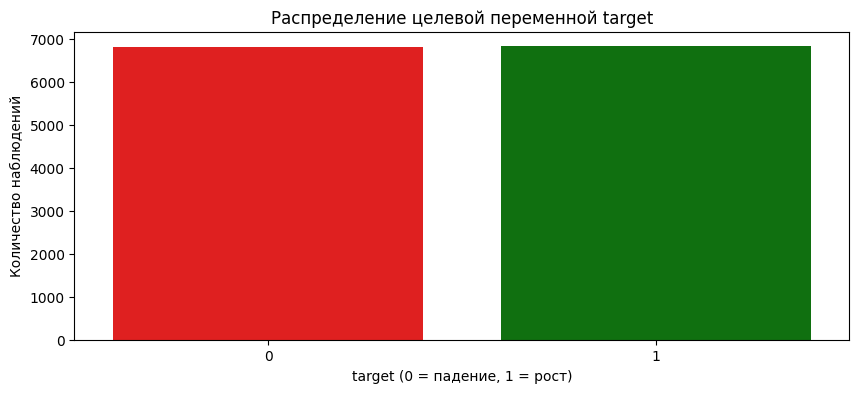

Абсолютные значения по целевой переменной target:
target
1    6836
0    6811
Name: count, dtype: int64

Доли по целевой переменной target:
target
1    0.5009
0    0.4991
Name: proportion, dtype: float64


In [47]:
# --- 3.1.1. Распределение целевой переменной target ---

plt.figure(figsize=(10, 4))
sns.countplot(data=df_fe, x="target", palette=["red", "green"])
plt.title("Распределение целевой переменной target")
plt.xlabel("target (0 = падение, 1 = рост)")
plt.ylabel("Количество наблюдений")
plt.show()

# Абсолютные значения
target_counts = df_fe["target"].value_counts()
print("Абсолютные значения по целевой переменной target:")
print(target_counts)

# Доли (нормализованные значения)
target_rate = df_fe["target"].value_counts(normalize=True).round(4)
print("\nДоли по целевой переменной target:")
print(target_rate)

Целевая переменная
- Классы почти идеально сбалансированы: target=1 — 6836, target=0 — 6811, доли ~50/50.
- Абсолютные значения по целевой переменной target: 1 — 6836, 0 — 6811.

Это снимает проблему дисбаланса классов и упрощает обучение и интерпретацию метрик.

__Распределения цен и объёма__

In [48]:
df_fe.iloc[:12,:9]

,open,high,low,close,volume,rsi,macd,sentiment,target
Date,,,,,,,,,
2010-01-01,100.309172,102.741242,99.822837,101.381330,743835,75.905800,0.000000,0.058089,0
2010-01-04,101.147509,101.681257,99.244474,100.396541,2693069,81.444127,-0.078559,0.751219,1
2010-01-05,101.567491,103.949668,101.509347,103.012156,3027306,71.544018,0.069441,0.979723,1
2010-01-06,104.247814,106.652559,102.760082,105.846343,4341338,73.683548,0.410693,-0.858008,0
2010-01-07,105.339440,105.983592,103.517541,104.721465,2106182,72.675179,0.583641,0.264456,0
2010-01-08,103.706622,106.241324,103.106346,104.405219,3688429,62.470552,0.687263,-0.063076,1
2010-01-11,106.970913,108.267172,105.139529,106.597955,3909135,65.151281,0.935535,0.078400,1
2010-01-12,108.463029,111.081403,107.759084,109.603060,1756061,55.483691,1.359113,-0.596560,0
2010-01-13,107.276693,109.498200,106.060857,107.793970,915340,46.913708,1.531172,0.788708,1


In [49]:
def plot_feature_distribution(df, feature, target="target", bins=40, title=None):
    """
    Простая и информативная функция для анализа распределения признака:
    - общая статистика
    - статистика по target
    - boxplot общий
    - гистограмма общая
    - boxplot по target
    - гистограмма по target
    """

    # Удаляем пропуски
    data = df[[feature, target]].dropna()

    # Общая статистика
    print(f"\n📊 Общая статистика по '{feature}':")
    print(data[feature].describe())

    # Статистика по группам target 
    group_stats = data.groupby(target)[feature].describe().T
    print("\n📊 Статистика по группам target:")
    print(group_stats)

    # Заголовок
    if title is None:
        title = f'Распределение "{feature}" (общие и по target)'

    # 4 графика
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(title, fontsize=18, fontweight='bold')

    # --- 1. Boxplot общий ---
    sns.boxplot(y=data[feature], ax=axes[0, 0], color='skyblue')
    axes[0, 0].set_title('Boxplot (общий)', fontsize=14)

    # --- 2. Гистограмма общая ---
    sns.histplot(
        data[feature], bins=bins, stat='count',
        color='steelblue', ax=axes[0, 1],
        alpha=0.6, edgecolor='gray'
    )
    axes[0, 1].set_title('Гистограмма (общая)', fontsize=14)

    # --- 3. Boxplot по target ---
    sns.boxplot(
        data=data, x=target, y=feature, hue=target,
        ax=axes[1, 0], palette='Set2', legend=False
    )
    axes[1, 0].set_title('Boxplot по target', fontsize=14)

    # --- 4. Гистограмма по target ---
    sns.histplot(
        data=data, x=feature, hue=target,
        bins=bins, stat="density", common_norm=False,
        palette='muted', ax=axes[1, 1]
    )
    axes[1, 1].set_title('Гистограмма по target', fontsize=14)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


Создана универсальная функция plot_feature_distribution(), которая для каждого признака выводит:
- Общую описательную статистику
- Статистику отдельно для классов target=0 и target=1
- Boxplot (общий и по классам)
- Гистограмму (общую и по классам)


📊 Общая статистика по 'open':
count    13647.000000
mean       101.096760
std        101.152616
min        -57.993581
25%         16.763759
50%         75.232057
75%        171.281978
max        322.996012
Name: open, dtype: float64

📊 Статистика по группам target:
target            0            1
count   6811.000000  6836.000000
mean     101.062154   101.131240
std      101.311151   101.001812
min      -56.137553   -57.993581
25%       16.915835    16.555104
50%       75.199484    75.250365
75%      170.820764   171.555789
max      322.996012   319.916862


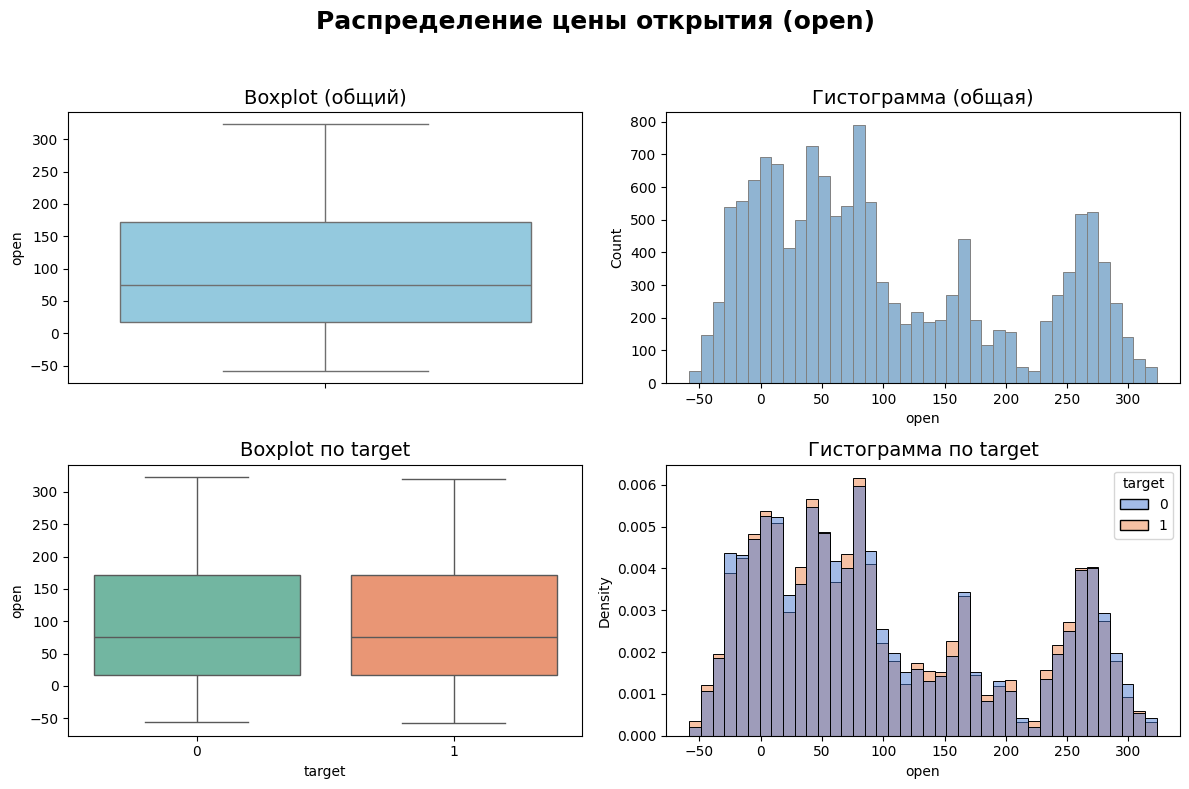

In [50]:
plot_feature_distribution(df_fe, feature="open", title="Распределение цены открытия (open)")


📊 Общая статистика по 'high':
count    13647.000000
mean       102.600108
std        101.177291
min        -56.565948
25%         18.101178
50%         76.765118
75%        172.948561
max        323.769348
Name: high, dtype: float64

📊 Статистика по группам target:
target            0            1
count   6811.000000  6836.000000
mean     102.575755   102.624371
std      101.323109   101.039203
min      -55.242667   -56.565948
25%       18.261975    18.030095
50%       76.747342    76.829794
75%      172.584412   173.363538
max      323.769348   322.107664


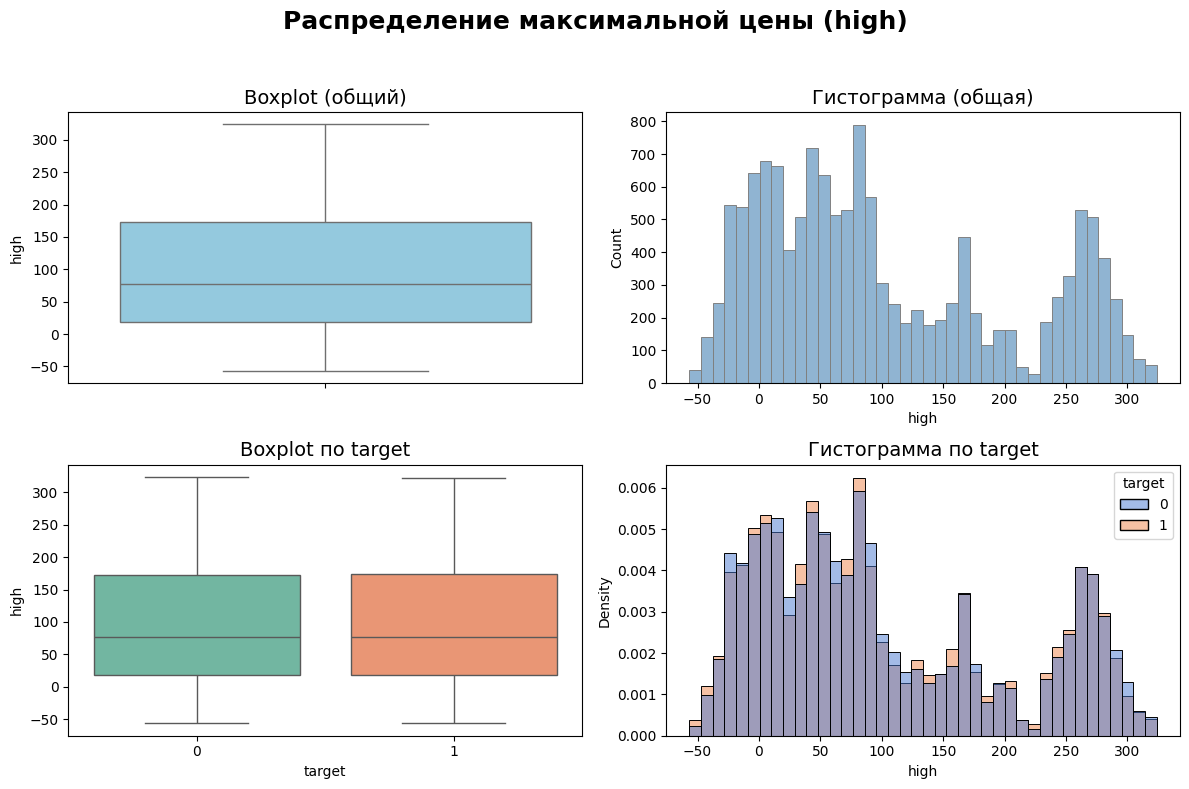

In [51]:
plot_feature_distribution(df_fe, feature="high", title="Распределение максимальной цены (high)")


📊 Общая статистика по 'low':
count    13647.000000
mean        99.599301
std        101.162439
min        -60.262371
25%         15.121420
50%         73.833890
75%        169.665120
max        320.949858
Name: low, dtype: float64

📊 Статистика по группам target:
target            0            1
count   6811.000000  6836.000000
mean      99.567746    99.630741
std      101.321704   101.010907
min      -57.635994   -60.262371
25%       15.299411    14.922717
50%       73.737659    73.982835
75%      169.419349   170.016224
max      320.949858   318.225212


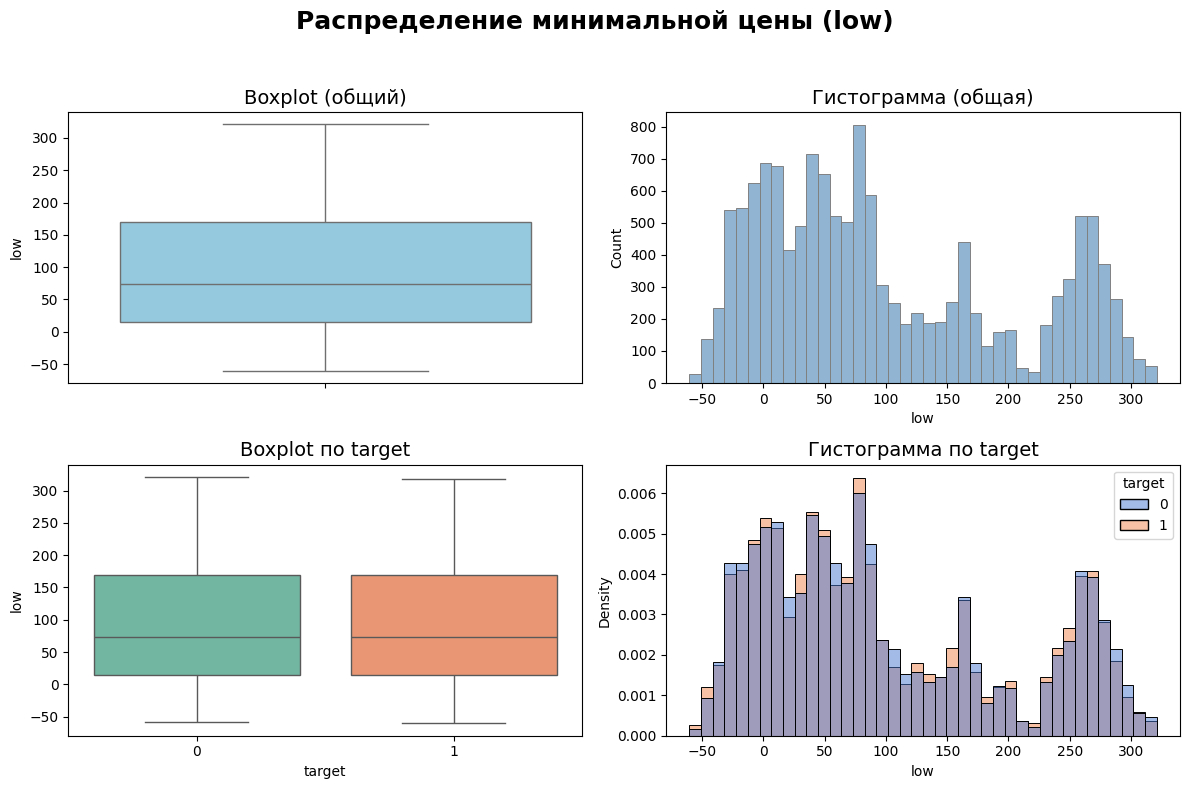

In [52]:
plot_feature_distribution(df_fe, feature="low", title="Распределение минимальной цены (low)")


📊 Общая статистика по 'close':
count    13647.000000
mean       101.096959
std        101.159203
min        -58.538240
25%         16.711654
50%         75.271538
75%        171.278812
max        323.622138
Name: close, dtype: float64

📊 Статистика по группам target:
target            0            1
count   6811.000000  6836.000000
mean     101.195729   100.998551
std      101.328221   100.997838
min      -55.954303   -58.538240
25%       16.945570    16.405062
50%       75.401558    75.094802
75%      171.168916   171.415368
max      323.622138   319.487767


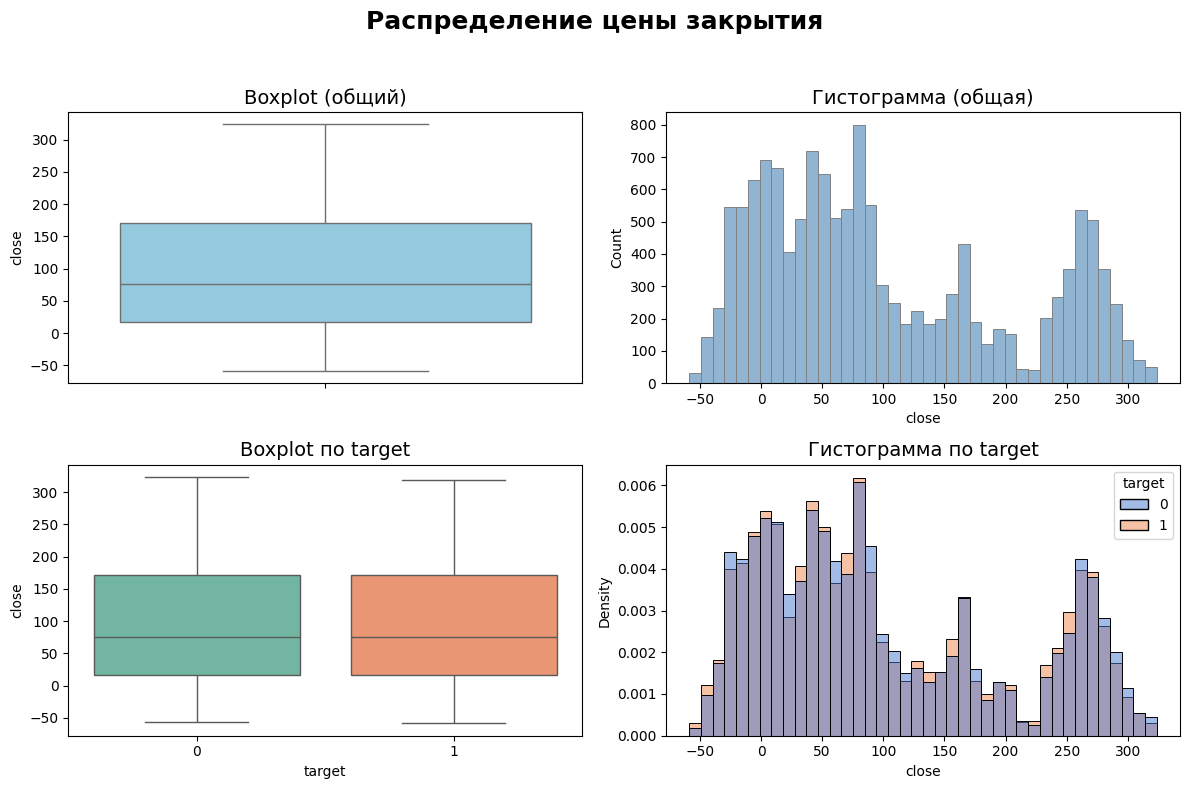

In [53]:
plot_feature_distribution(df_fe, feature="close", title="Распределение цены закрытия")


📊 Общая статистика по 'volume':
count    1.364700e+04
mean     2.563550e+06
std      1.404601e+06
min      1.003100e+05
25%      1.356426e+06
50%      2.550567e+06
75%      3.779358e+06
max      4.999938e+06
Name: volume, dtype: float64

📊 Статистика по группам target:
target             0             1
count   6.811000e+03  6.836000e+03
mean    2.552739e+06  2.574321e+06
std     1.396062e+06  1.413077e+06
min     1.003100e+05  1.005250e+05
25%     1.361690e+06  1.349222e+06
50%     2.514327e+06  2.589536e+06
75%     3.748852e+06  3.809321e+06
max     4.999938e+06  4.999292e+06


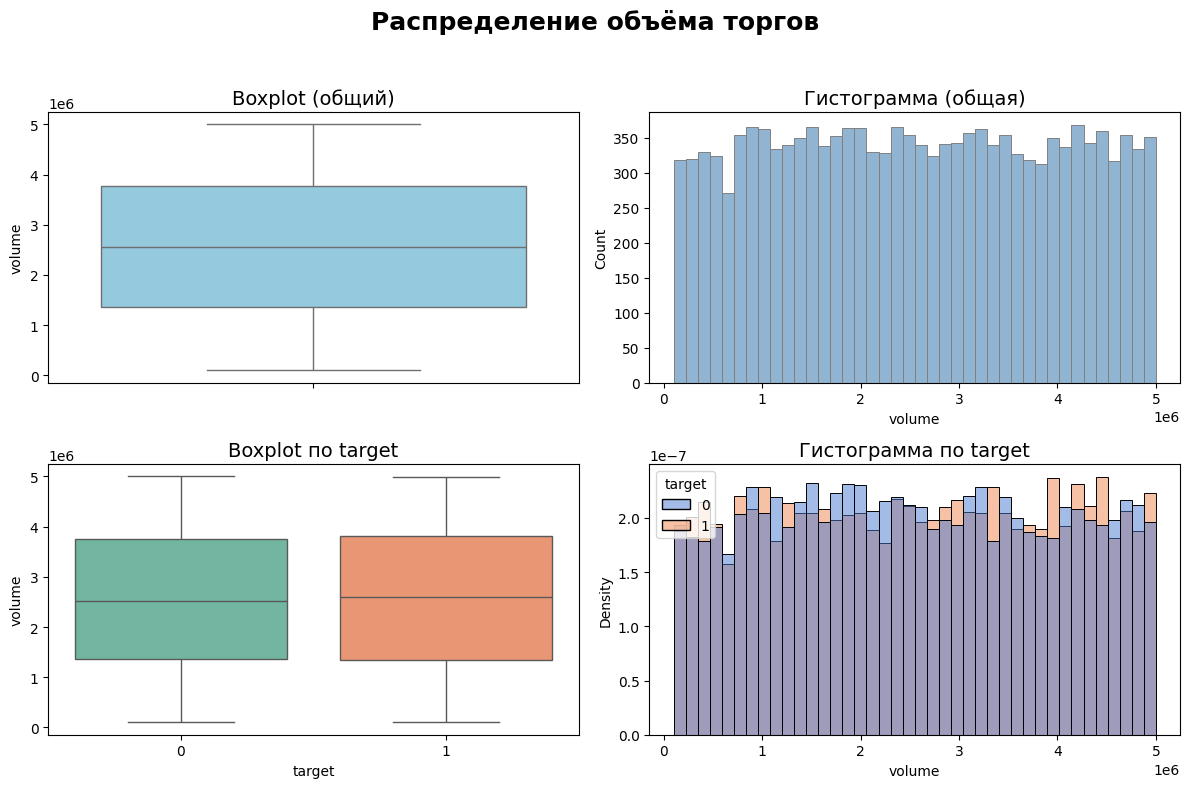

In [54]:
plot_feature_distribution(df_fe, feature="volume", title="Распределение объёма торгов")

Цены, объём, доходности
- Распределения open/high/low/close визуально близки, с длинными хвостами и редкими экстремальными значениями (видно по boxplot’ам и широкому диапазону min/max).
- Объём (volume) сильно правосторонне скошен: большинство значений в районе медианы, но есть периоды резко повышенной активности.

Распределения цен (open, high, low, close)
- Результат: все ценовые признаки имеют схожие распределения с длинными хвостами
- Анализ:
  - Средние значения близки (~100-102)
  - Широкий диапазон от отрицательных значений до ~320
  -Для target=0 средние цены немного выше, чем для target=1

Вывод: цены имеют трендовую составляющую, но распределения ожидаемы для симулированных данных

In [55]:
# Анализ выбросов методом IQR
Q1 = df_fe['volume'].quantile(0.25)
Q3 = df_fe['volume'].quantile(0.75)
IQR = Q3 - Q1
volume_outliers = df_fe[(df_fe['volume'] < Q1 - 1.5*IQR) | (df_fe['volume'] > Q3 + 1.5*IQR)]
print(f"Выбросов в volume: {len(volume_outliers)} ({len(volume_outliers)/len(df_fe)*100:.2f}%)")

Выбросов в volume: 0 (0.00%)


__Распределения rsi и macd__


📊 Общая статистика по 'rsi':
count    13647.000000
mean        49.906274
std         15.040947
min          0.000000
25%         39.576585
50%         49.911584
75%         60.220491
max         97.614964
Name: rsi, dtype: float64

📊 Статистика по группам target:
target            0            1
count   6811.000000  6836.000000
mean      47.026953    52.775065
std       14.650855    14.876519
min        0.000000     8.065575
25%       36.945368    42.432056
50%       47.031843    52.844192
75%       57.172970    63.082501
max       96.071359    97.614964


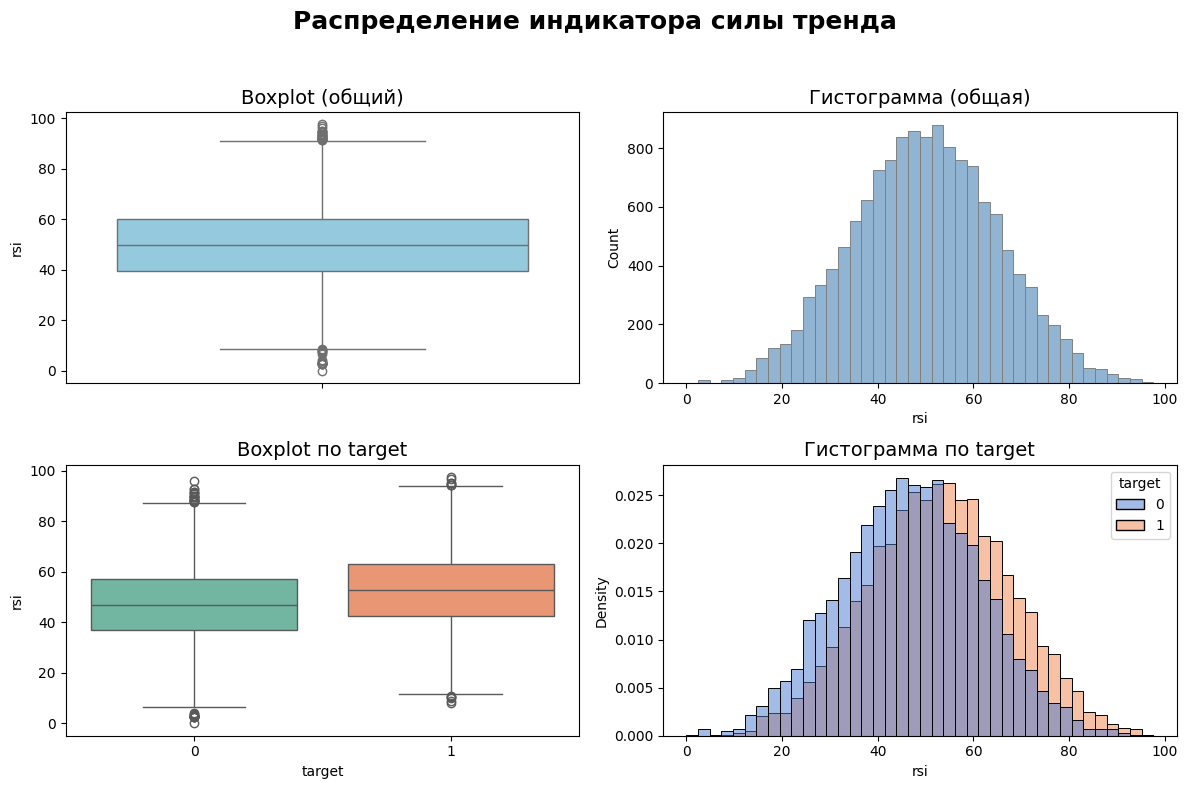

In [56]:
plot_feature_distribution(df_fe, feature="rsi", title="Распределение индикатора силы тренда")

In [57]:
def normality_report(series, name="feature"):
    s = series.dropna()

    # --- Q-Q plot ---
    probplot(s, dist="norm", plot=plt)
    plt.title(f"Q-Q Plot: {name}")
    plt.show()

    # --- Shapiro-Wilk ---
    stat, p = shapiro(s)
    print(f"\nShapiro-Wilk test for '{name}':")
    print(f"  Statistic = {stat:.4f}")
    print(f"  p-value   = {p:.4f}")

    # --- Интерпретация ---
    alpha = 0.05
    print("\nИнтерпретация:")

    if p > alpha:
        print("✔ Распределение НЕ отличается от нормального (не удалось отвергнуть H0).")
    else:
        print("✘ Распределение СУЩЕСТВЕННО отличается от нормального (H0 отвергнута).")

    # --- Степень отклонения ---
    if stat > 0.95:
        print("➡ Отклонение от нормальности слабое.")
    elif stat > 0.90:
        print("➡ Отклонение от нормальности умеренное.")
    else:
        print("➡ Отклонение от нормальности сильное.")

    # --- Рекомендации ---
    print("\nРекомендации:")
    if p < alpha:
        print("- Использовать непараметрические методы или логарифмические преобразования.")
        print("- Проверить распределение через QQ‑plot.")
        print("- Рассмотреть Box‑Cox или Yeo‑Johnson трансформации.")
    else:
        print("- Можно использовать методы, предполагающие нормальность.")


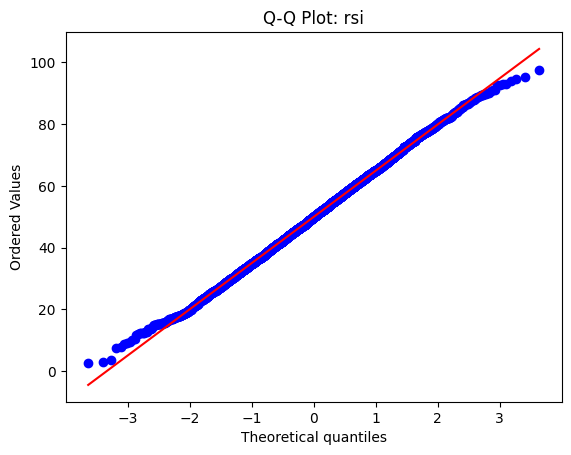


Shapiro-Wilk test for 'rsi':
  Statistic = 0.9990
  p-value   = 0.0054

Интерпретация:
✘ Распределение СУЩЕСТВЕННО отличается от нормального (H0 отвергнута).
➡ Отклонение от нормальности слабое.

Рекомендации:
- Использовать непараметрические методы или логарифмические преобразования.
- Проверить распределение через QQ‑plot.
- Рассмотреть Box‑Cox или Yeo‑Johnson трансформации.


In [58]:
sample = df_fe["rsi"].dropna().sample(5000, random_state=42)

normality_report(sample, name="rsi")

In [59]:
def normality_report_k2(series, name="variable"):
    data = series.dropna()
    stat, p = normaltest(data)

    print(f"\n=== D'Agostino K² test for '{name}' ===")
    print(f"Statistic : {stat:.4f}")
    print(f"p-value   : {p:.6f}")

    print("\nИнтерпретация:")
    if p < 0.05:
        print("✘ Распределение НЕ похоже на нормальное (H0 отвергнута).")
    else:
        print("✔ Нет оснований отклонять нормальность (H0 не отвергнута).")

    print("\nРекомендации:")
    print("- Построить гистограмму и QQ‑plot для визуальной проверки.")
    print("- При сильном отклонении рассмотреть трансформации (Box‑Cox, Yeo‑Johnson).")
    print("- Для больших выборок K² предпочтительнее Shapiro–Wilk.")

# пример вызова
normality_report_k2(df_fe["rsi"], name="rsi")


=== D'Agostino K² test for 'rsi' ===
Statistic : 39.3720
p-value   : 0.000000

Интерпретация:
✘ Распределение НЕ похоже на нормальное (H0 отвергнута).

Рекомендации:
- Построить гистограмму и QQ‑plot для визуальной проверки.
- При сильном отклонении рассмотреть трансформации (Box‑Cox, Yeo‑Johnson).
- Для больших выборок K² предпочтительнее Shapiro–Wilk.


Распределение RSI
- Результат: среднее ~49.9, диапазон [0, 100]
- Анализ:
  - Для target=1 средний RSI выше (52.8 vs 47.0)
  - Чёткое разделение распределений по классам

__Вывод: RSI — сильный предиктор направления движения__


📊 Общая статистика по 'macd':
count    13647.000000
mean        -0.026986
std          2.203216
min         -7.384103
25%         -1.472511
50%          0.012284
75%          1.416378
max          7.288539
Name: macd, dtype: float64

📊 Статистика по группам target:
target            0            1
count   6811.000000  6836.000000
mean      -0.019964    -0.033982
std        2.211271     2.195301
min       -7.008938    -7.384103
25%       -1.449716    -1.482278
50%        0.020979     0.006064
75%        1.442035     1.380406
max        7.288539     7.159667


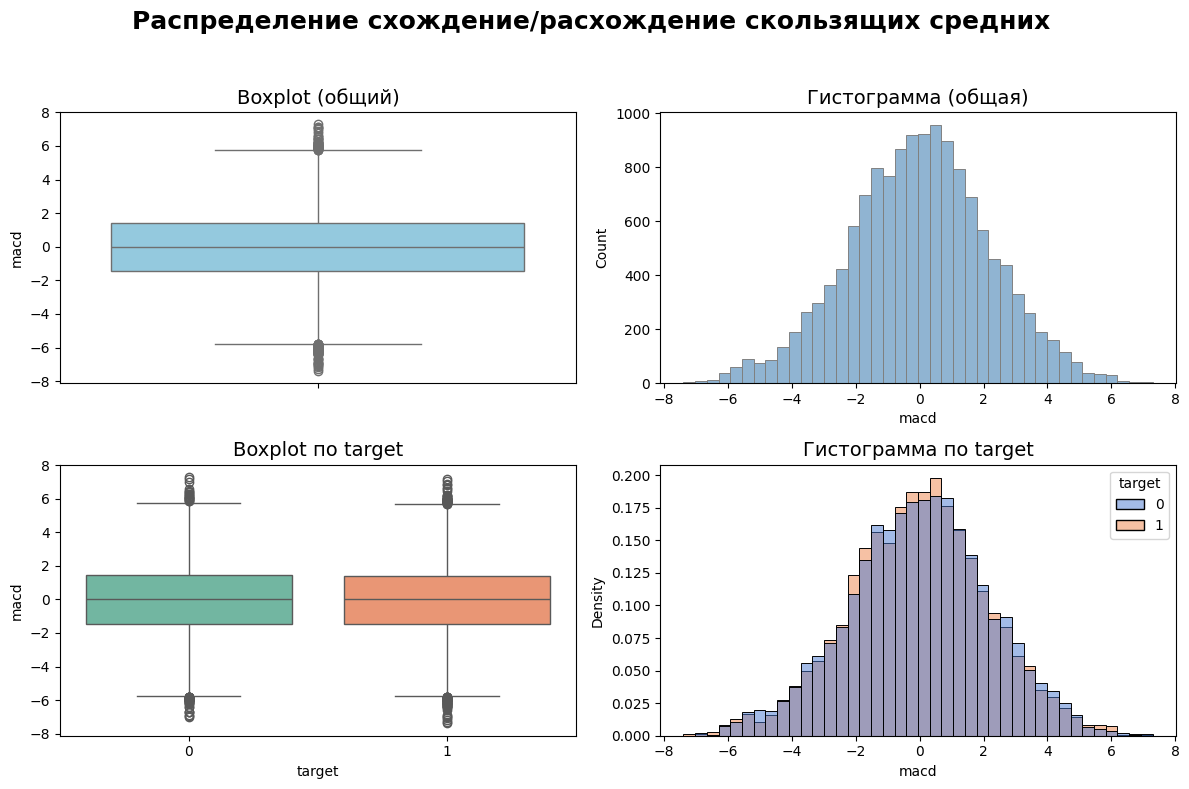

In [60]:
plot_feature_distribution(df_fe, feature="macd", title="Распределение схождение/расхождение скользящих средних ")

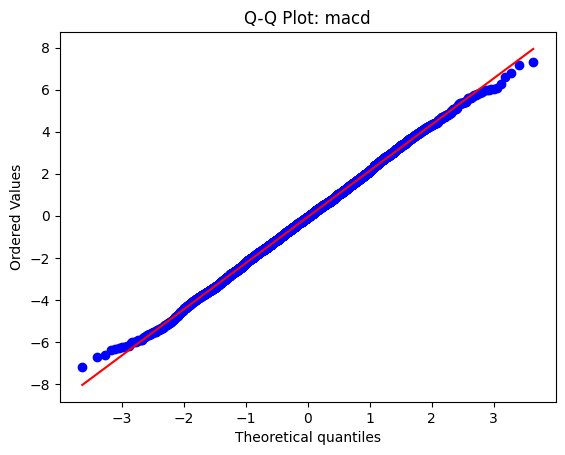


Shapiro-Wilk test for 'macd':
  Statistic = 0.9994
  p-value   = 0.1256

Интерпретация:
✔ Распределение НЕ отличается от нормального (не удалось отвергнуть H0).
➡ Отклонение от нормальности слабое.

Рекомендации:
- Можно использовать методы, предполагающие нормальность.


In [61]:
sample = df_fe["macd"].dropna().sample(5000, random_state=42)

normality_report(sample, name="macd")

In [62]:
# пример вызова
normality_report_k2(df_fe["macd"], name="macd")


=== D'Agostino K² test for 'macd' ===
Statistic : 15.8561
p-value   : 0.000360

Интерпретация:
✘ Распределение НЕ похоже на нормальное (H0 отвергнута).

Рекомендации:
- Построить гистограмму и QQ‑plot для визуальной проверки.
- При сильном отклонении рассмотреть трансформации (Box‑Cox, Yeo‑Johnson).
- Для больших выборок K² предпочтительнее Shapiro–Wilk.


Распределение MACD
- Результат: среднее около нуля (-0.027), диапазон [-7.38, 7.29]
- Анализ: распределения для target=0 и target=1 практически идентичны

__Вывод: MACD сам по себе слабо разделяет классы__

__Распределения return_1d__


📊 Общая статистика по 'return_1d':
count    13520.000000
mean        -0.001268
std          0.217351
min         -4.129905
25%         -0.017713
50%          0.000187
75%          0.017549
max          3.857228
Name: return_1d, dtype: float64

📊 Статистика по группам target:
target            0            1
count   6751.000000  6769.000000
mean       0.000077    -0.002610
std        0.210241     0.224225
min       -3.670101    -4.129905
25%       -0.015979    -0.018991
50%        0.001341    -0.000945
75%        0.018976     0.015803
max        3.436128     3.857228


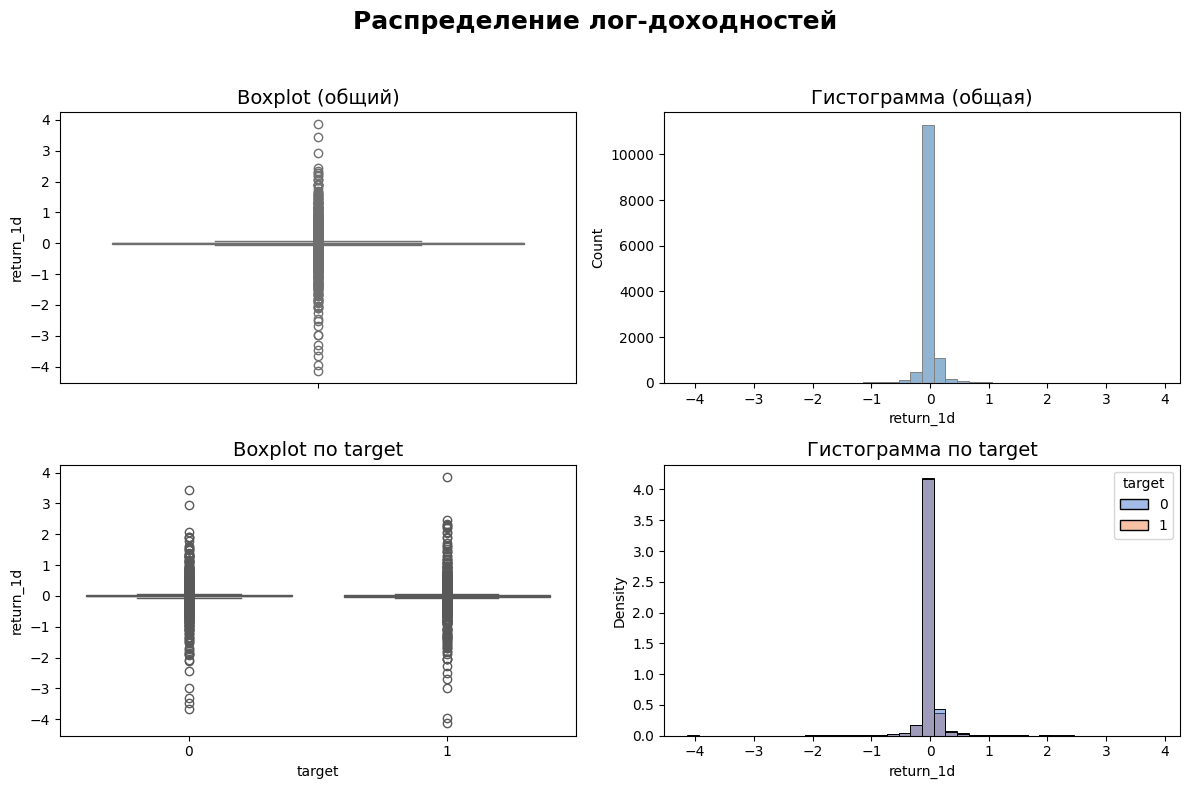

In [63]:
plot_feature_distribution(df_fe, feature="return_1d", title="Распределение лог-доходностей")

__Проверка нормальности доходностей__

- Q-Q plot
- Тест Шапиро–Уилка

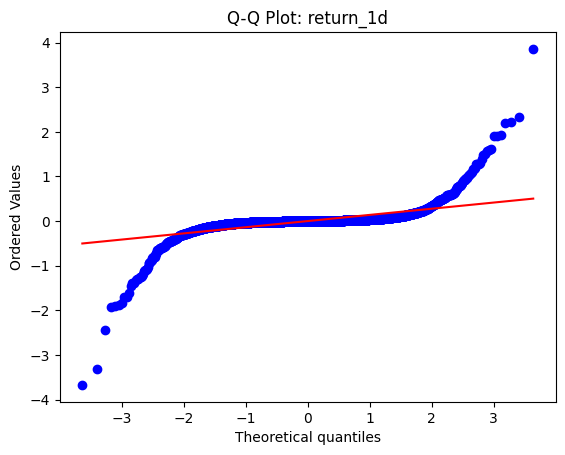


Shapiro-Wilk test for 'return_1d':
  Statistic = 0.4334
  p-value   = 0.0000

Интерпретация:
✘ Распределение СУЩЕСТВЕННО отличается от нормального (H0 отвергнута).
➡ Отклонение от нормальности сильное.

Рекомендации:
- Использовать непараметрические методы или логарифмические преобразования.
- Проверить распределение через QQ‑plot.
- Рассмотреть Box‑Cox или Yeo‑Johnson трансформации.


In [64]:
sample = df_fe["return_1d"].dropna().sample(5000, random_state=42)

normality_report(sample, name="return_1d")

In [65]:
df_fe["return_1d"].quantile([0.001, 0.01, 0.99, 0.999])

0.001   -2.050249
0.010   -0.619392
0.990    0.606360
0.999    1.898174
Name: return_1d, dtype: float64

In [66]:
df_fe["return_1d"].skew(), df_fe["return_1d"].kurtosis()

(-1.5272673612568528, 82.96357998710974)

- Shapiro–Wilk: Statistic = 0.4357, p-value = 0.0000 → нормальность уверенно отвергается.
- Скос и эксцесс: skew = -1.53, kurtosis ≈ 83 — очень тяжёлые хвосты.
- Квантили показывают редкие, но экстремальные движения (0.001 ≈ -2.05, 0.999 ≈ 1.90).

Вывод: доходности не нормальны, хвосты тяжёлые — для моделей и тестов лучше не опираться на предположение нормальности, использовать робастные/непараметрические подходы.

Проверка нормальности доходностей
- Q-Q plot: точки сильно отклоняются от диагонали
- Shapiro-Wilk test: statistic = 0.4357, p-value = 0.0000

Вывод: распределение существенно отличается от нормального → использовать робастные методы

### 3.2. Временные графики <a class="anchor" id="ch5_3_2"></a>

__Цена закрытия + аннотация target__

Что было сделано:
- Построен линейный график цены закрытия за весь период (2010–2062)
- Точки target=1 отмечены зелёным, target=0 — красным
- Отдельно построен график за 2014 год для детализации

In [67]:
def plot_close_with_targets(df, start=None, end=None, figsize=(20,5)):
    # --- 1. Фильтрация по интервалу времени ---
    if start or end:
        df = df.loc[start:end]

    # --- 2. График цены и target ---
    plt.figure(figsize=figsize)
    plt.plot(df.index, df["close"], label="Close", color="black")

    # точки target
    plt.scatter(df.index[df["target"]==1], df["close"][df["target"]==1],
                color="green", s=10, label="target=1")
    plt.scatter(df.index[df["target"]==0], df["close"][df["target"]==0],
                color="red", s=10, label="target=0")

    plt.title("Цена закрытия с аннотацией target")
    plt.legend()
    plt.show()

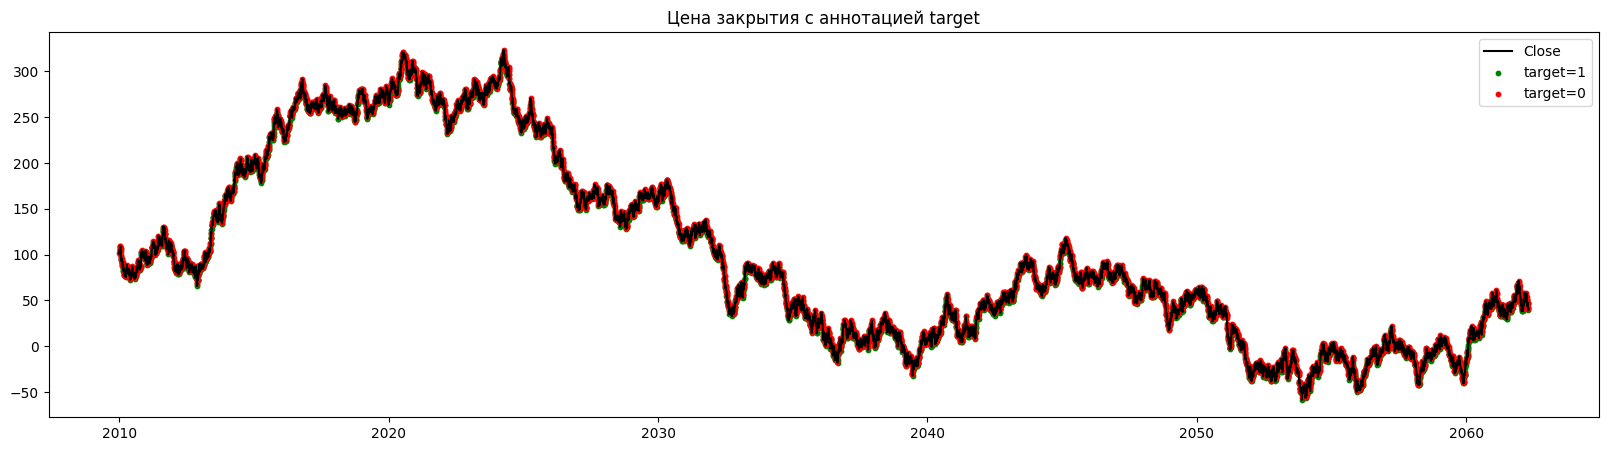

In [68]:
plot_close_with_targets(df_fe)

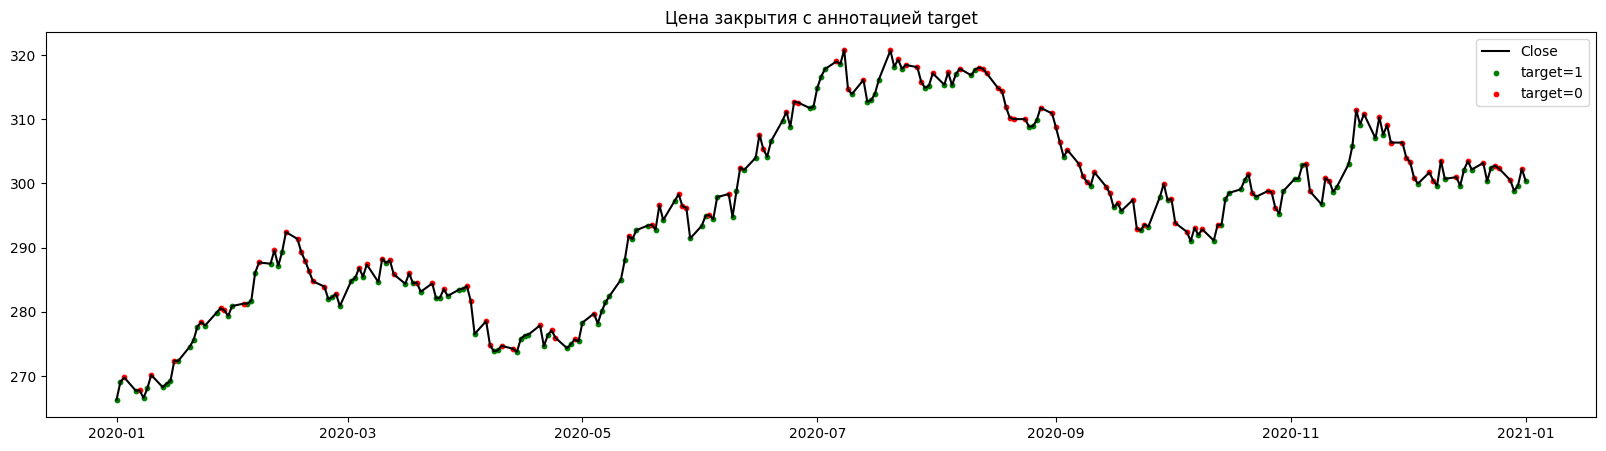

In [69]:
plot_close_with_targets(df_fe, start="2020-01-01", end="2021-01-01")

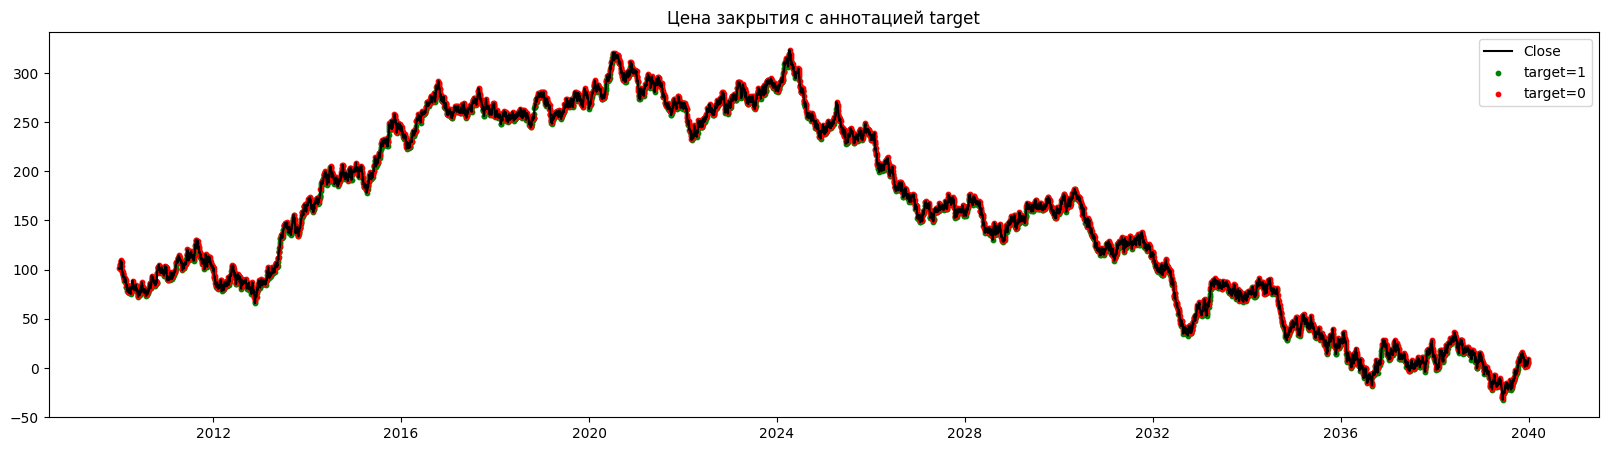

In [70]:
plot_close_with_targets(df_fe, end="2040-01-01")

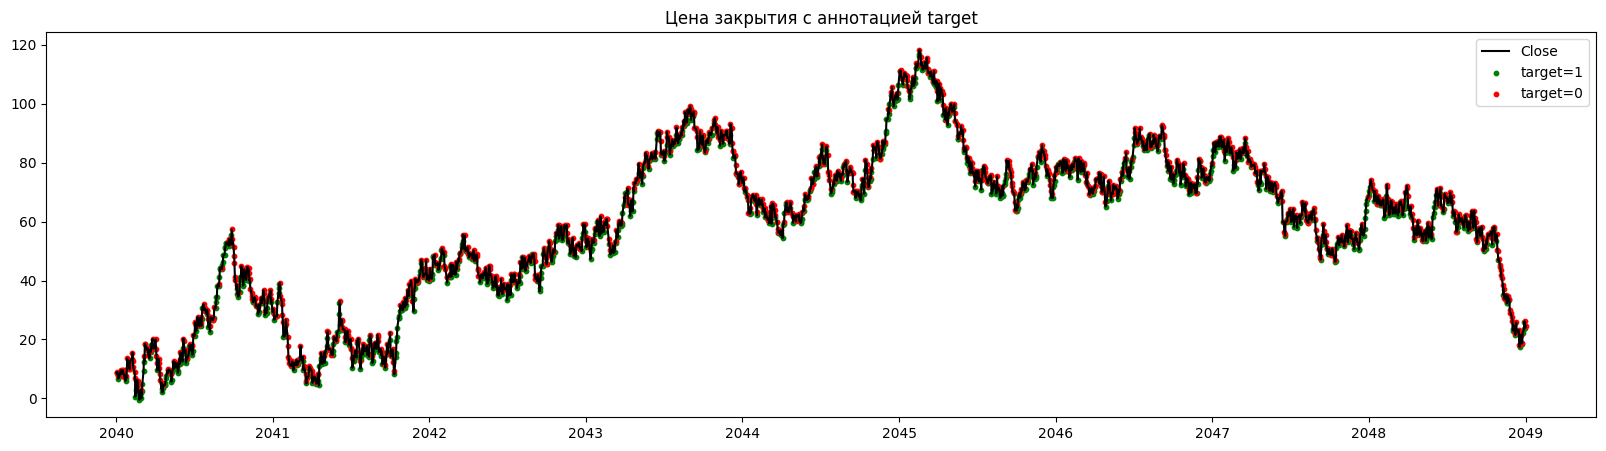

In [71]:
plot_close_with_targets(df_fe, start="2040-01-01", end="2049-01-01")

- Также на графике цен закрытия хорошо видна синтетичность данных
  - 2010-2040 это основной график
  - дальше по форме но с меньшей амплитудой ижет такой же график в интервалле примерно 2040-2050 

Цена закрытия с аннотацией target
- Анализ:
  - Долгосрочный тренд с несколькими циклами роста и падения
  - Точки target=1 и target=0 распределены равномерно по всему периоду
  - Нет периодов, где доминирует только один класс

Вывод: target не зависит от абсолютного уровня цены

✔ В коротком интервале (2020–2021)
- Видно, что target=1 чаще ставится в моменты, когда цена начинает расти.
- target=0 появляется на вершинах или в начале коррекций.

Это хороший признак: аннотация target визуально согласуется с движением цены.

__Объём торгов__

Что было сделано:
- Построен линейный график объёма за весь период
- Точки target отмечены цветом

In [72]:
def plot_volume_with_targets(df, start=None, end=None, figsize=(20,5)):
    # --- 1. Фильтрация по интервалу времени ---
    if start or end:
        df = df.loc[start:end]

    # --- 2. График объёма и target ---
    plt.figure(figsize=figsize)

    # Линия объёма
    plt.plot(df.index, df["volume"], color="blue", label="Volume")

    # Точки target=1
    plt.scatter(
        df.index[df["target"] == 1],
        df["volume"][df["target"] == 1],
        color="green", s=20, label="target=1"
    )

    # Точки target=0
    plt.scatter(
        df.index[df["target"] == 0],
        df["volume"][df["target"] == 0],
        color="red", s=20, label="target=0"
    )

    plt.title("Объём торгов с аннотацией target")
    plt.legend()
    plt.show()

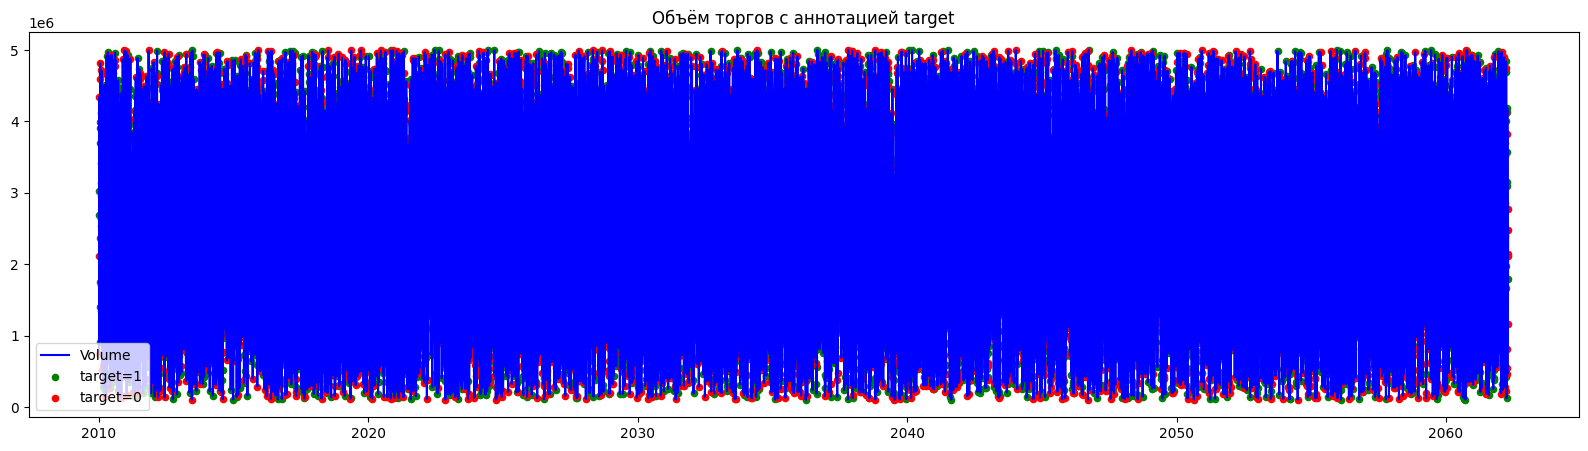

In [73]:
plot_volume_with_targets(df_fe)

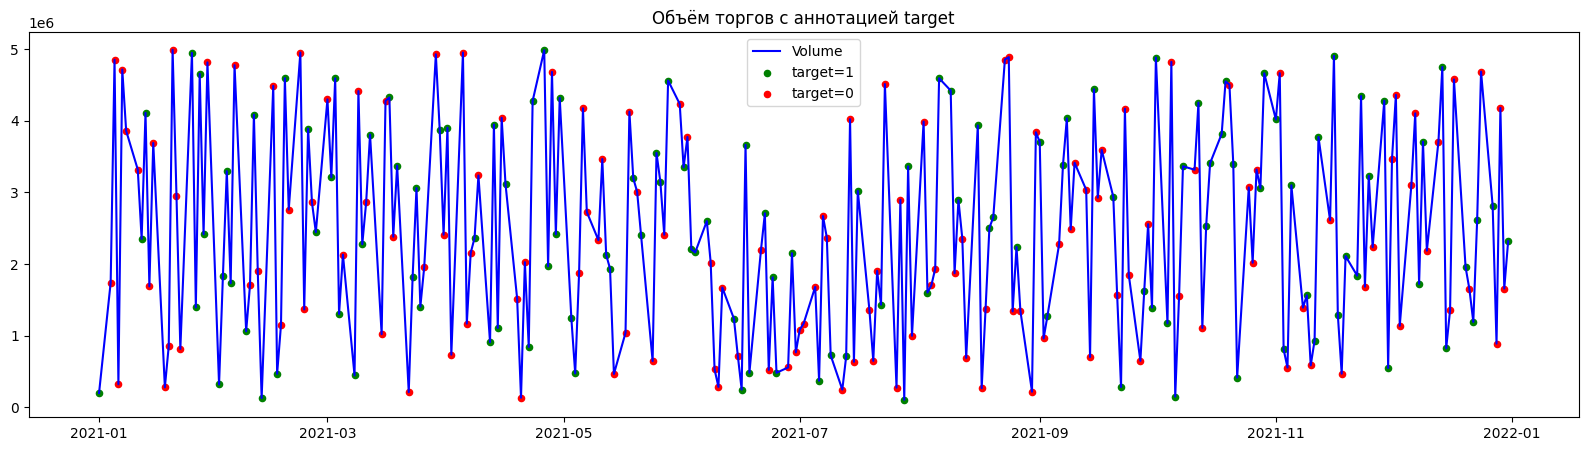

In [74]:
plot_volume_with_targets(df_fe, start="2021-01-01", end="2022-01-01")

1) Синяя линия — это объём торгов (volume)
   - периоды высокой активности
   - периоды низкой ликвидности
   - всплески, связанные с новостями, отчётами, паникой или эйфорией
   - На длинном графике видно, что объёмы сильно меняются во времени — это нормальная рыночная динамика.

2) Зелёные точки — target = 1
   - Это моменты, когда твоя логика/модель считает, что следующий день будет положительным
   - На графике они показывают сигналы на рост.

3) Красные точки — target = 0
   - Это противоположные моменты ожидается падение
   - То есть это сигналы на снижение.

__RSI, MACD и Sentiment во времени__

In [75]:
def plot_indicators(df, start=None, end=None):
    # Фильтрация по интервалу
    if start or end:
        df = df.loc[start:end]

    fig, axes = plt.subplots(3, 1, figsize=(20, 10), sharex=True)

    # RSI
    df["rsi"].plot(ax=axes[0], color="purple")
    axes[0].set_title("RSI во времени")
    axes[0].axhline(30, color="red", linestyle="--", linewidth=1)
    axes[0].axhline(70, color="green", linestyle="--", linewidth=1)

    # MACD
    df["macd"].plot(ax=axes[1], color="blue")
    axes[1].set_title("MACD во времени")

    # Sentiment
    df["sentiment"].plot(ax=axes[2], color="orange")
    axes[2].set_title("Sentiment Score во времени")

    plt.tight_layout()
    plt.show()

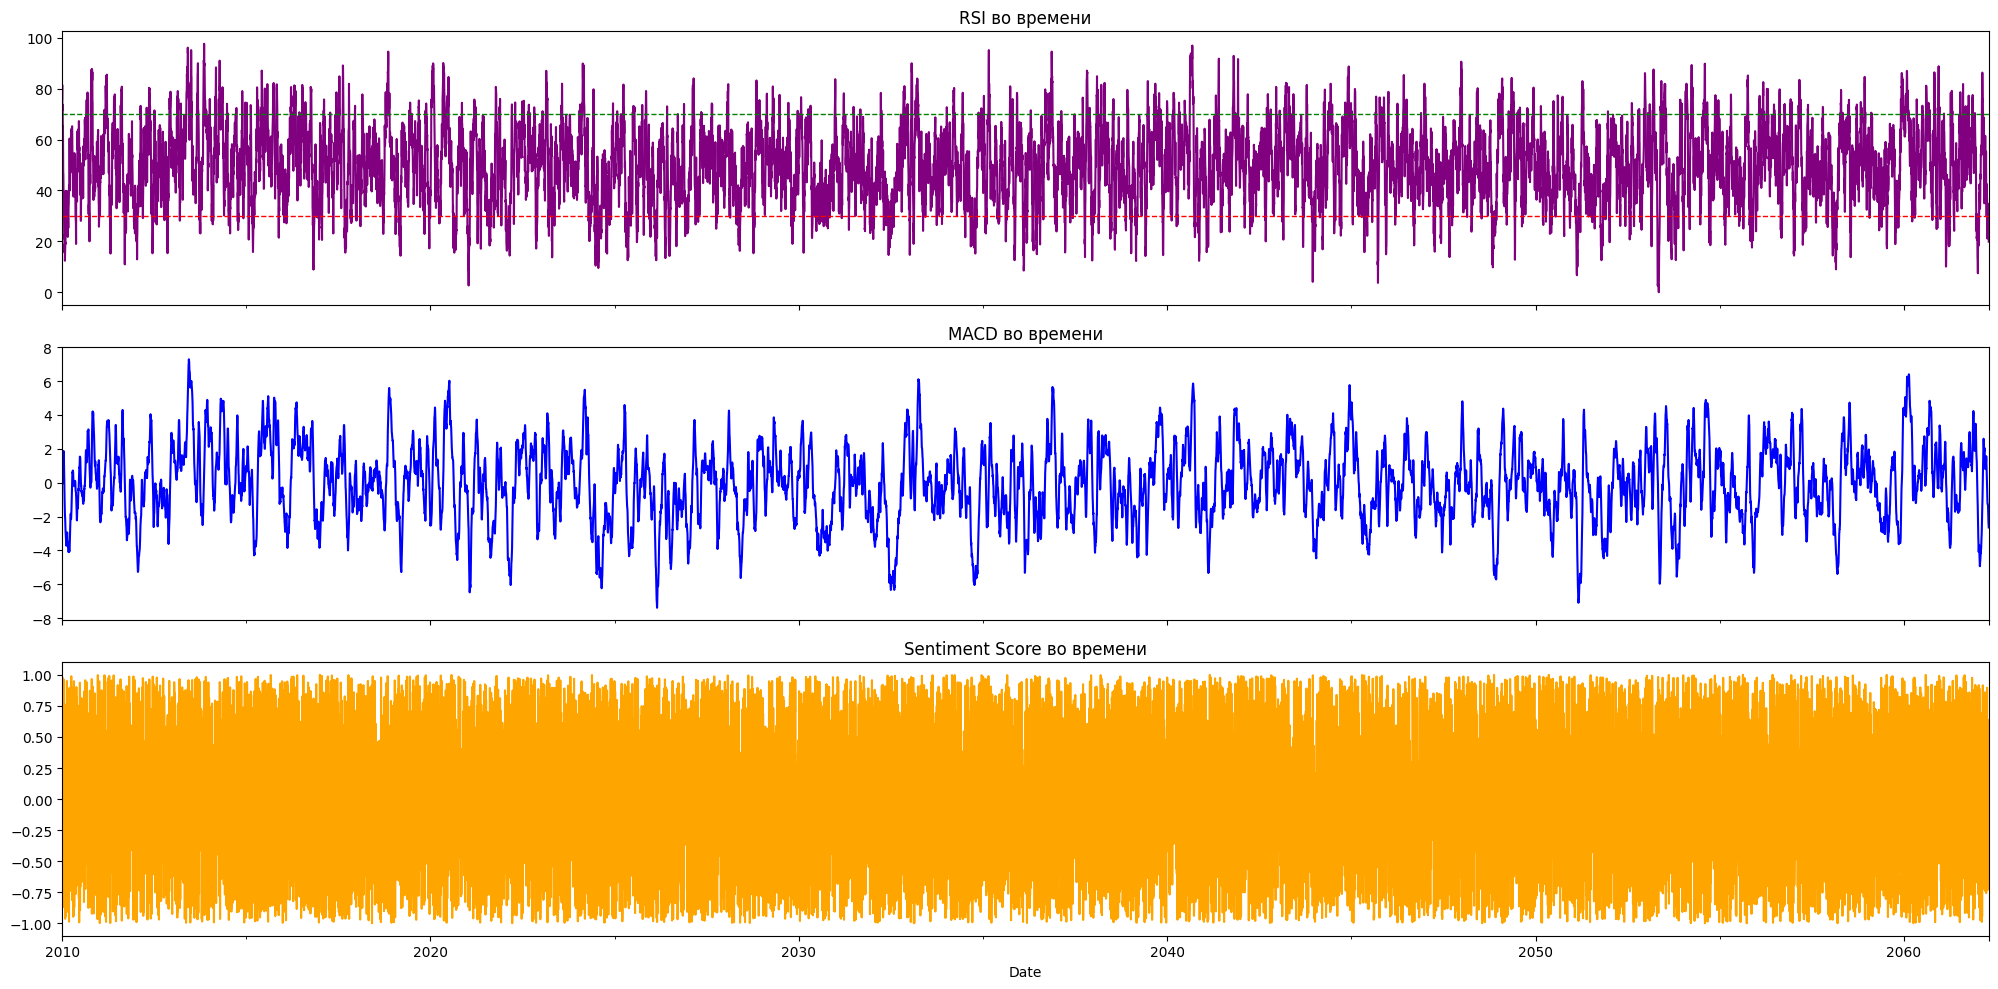

In [76]:
plot_indicators(df_fe)

__RSI (верхний график)__
   - Фиолетовая линия колеблется между 0 и 100 — это классический RSI.
   - Линия 30 (красная пунктирная) — зона перепроданности
   - Линия 70 (зелёная пунктирная) — зона перекупленности

На графике видно:
- RSI часто опускается ниже 30 → возможные точки разворота вверх
- RSI поднимается выше 70 → возможные точки разворота вниз

Долгие периоды в середине диапазона → боковое движение рынка

__MACD (средний график)__
- Синяя линия колеблется вокруг нуля.
- Положительные значения → бычий импульс
- Отрицательные значения → медвежий импульс
- Частые пересечения нуля → высокая волатильность или смена тренда

На графике видно:
- Периоды сильных трендов сопровождаются длительным нахождением MACD выше или ниже нуля
- В боковике MACD часто «пилит» вокруг нулевой линии

__Sentiment Score (нижний график)__
- Оранжевая линия в диапазоне от -1 до +1.
- Значения ближе к +1 → позитивный новостной фон
- Значения ближе к -1 → негативный фон
- Быстрые скачки → реакция на новости, отчёты, события

На графике видно:
- Периоды устойчивого позитива/негатива
- Резкие всплески, совпадающие с движениями цены (обычно так и бывает)

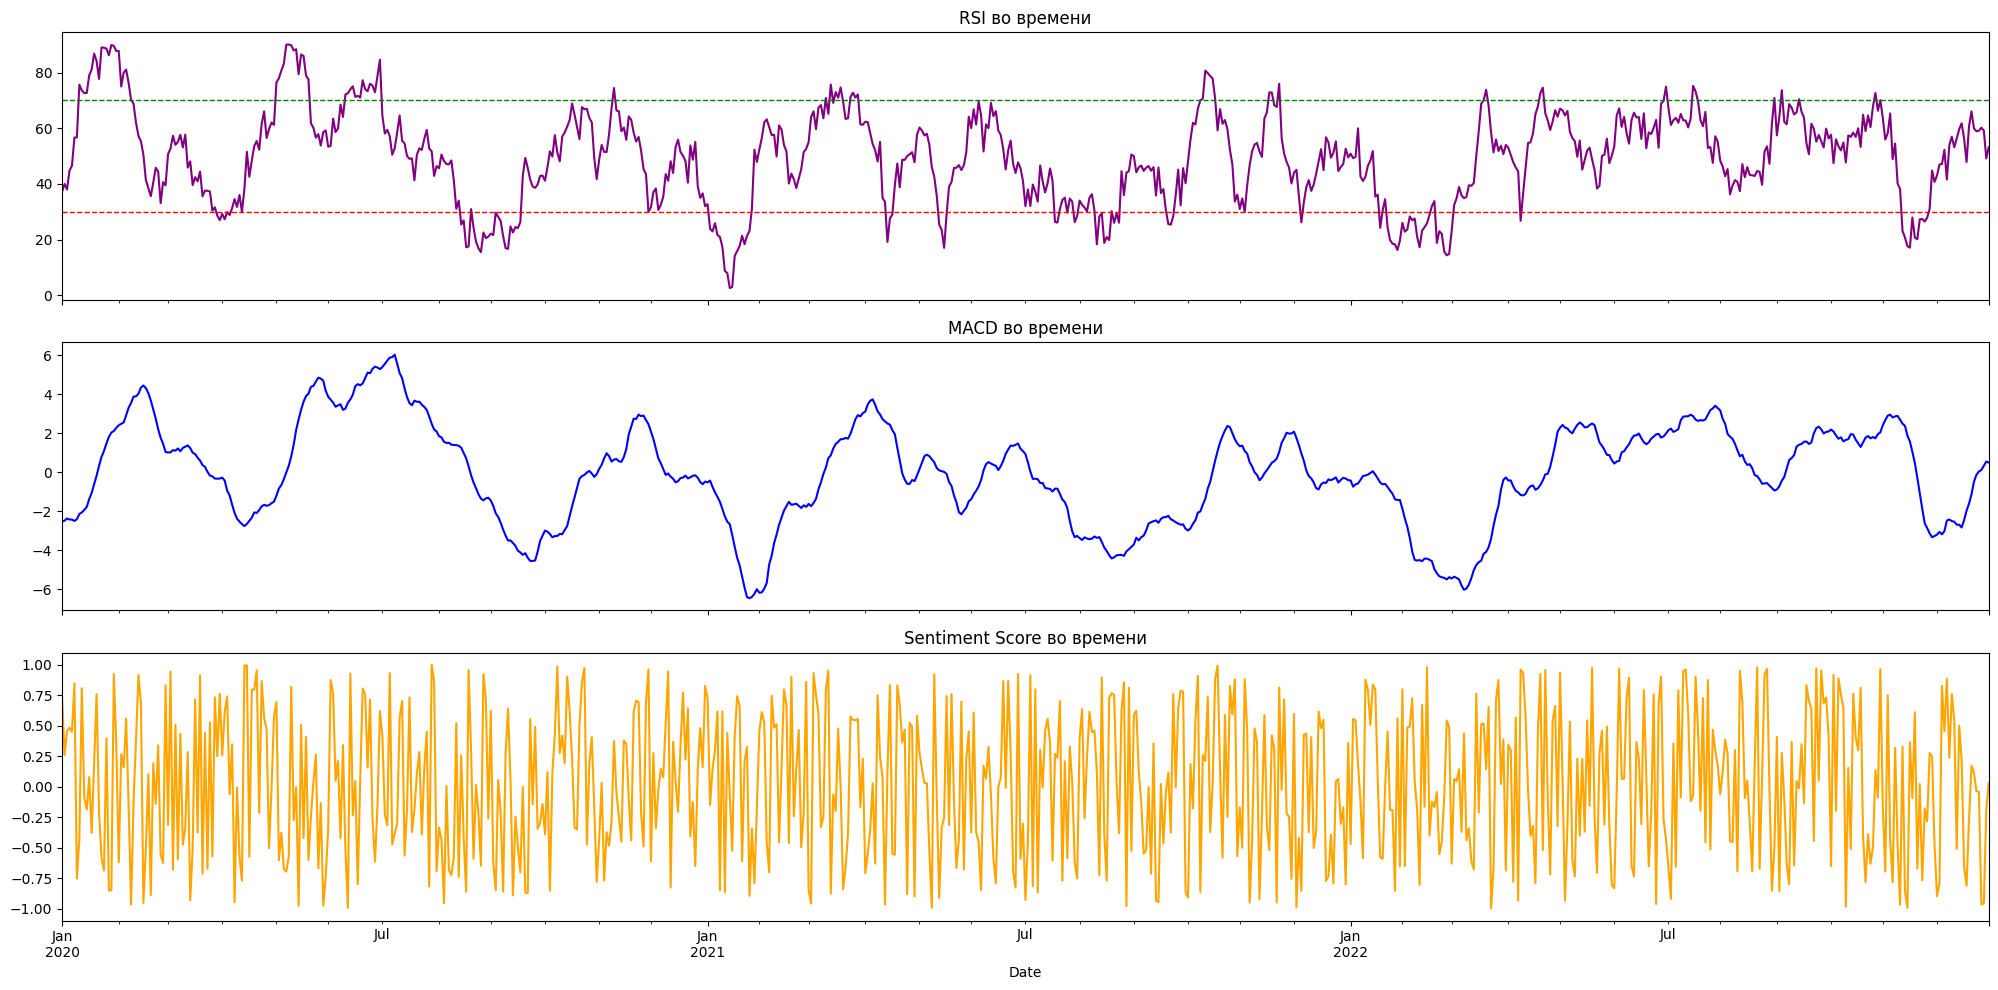

In [77]:
plot_indicators(df_fe, start="2020-01-01", end="2023-01-01")

RSI, MACD и Sentiment во времени
- Анализ:
  - RSI колеблется в диапазоне [20, 80] с редкими экстремумами
  - MACD следует за ценой с задержкой
  - Sentiment Score имеет высокочастотные колебания

Вывод: индикаторы ведут себя ожидаемо

### 3.3. Декомпозиция и сезонность <a class="anchor" id="ch5_3_3"></a>

Что было сделано:
- Применена классическая декомпозиция временного ряда на три компоненты:
  - Тренд (Trend)
  - Сезонность (Seasonality)
  - Остатки (Residuals)

In [78]:
def plot_decomposition(df, column="close", start=None, end=None, period=252, figsize=(20,3)):
    # --- 1. Фильтрация по интервалу времени ---
    if start or end:
        df = df.loc[start:end]

    # --- 2. Декомпозиция ---
    decomp = seasonal_decompose(df[column], model="additive", period=period)

    # --- 3. Графики ---
    plt.figure(figsize=figsize)
    decomp.trend.plot(title="Trend")
    plt.show()

    plt.figure(figsize=figsize)
    decomp.seasonal.plot(title="Seasonality")
    plt.show()

    plt.figure(figsize=figsize)
    decomp.resid.plot(title="Residuals")
    plt.show()

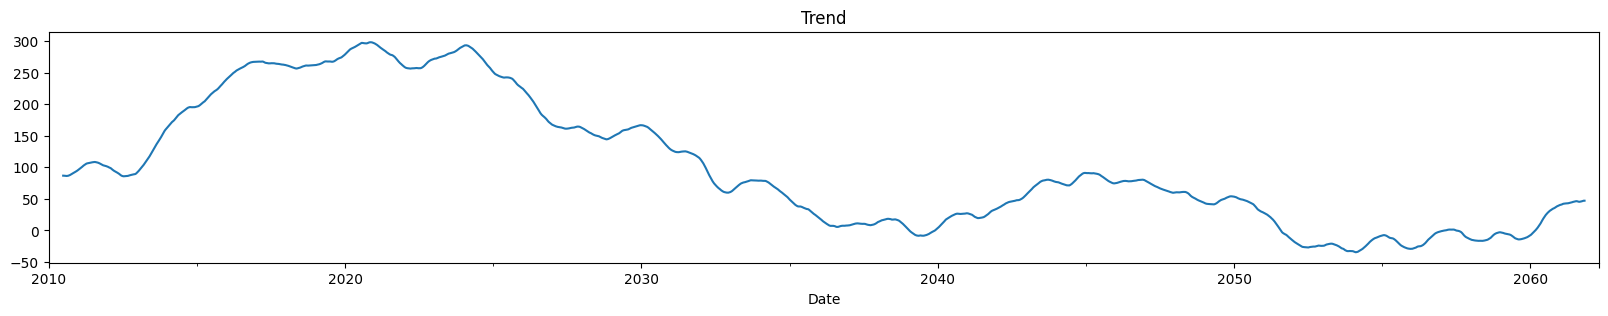

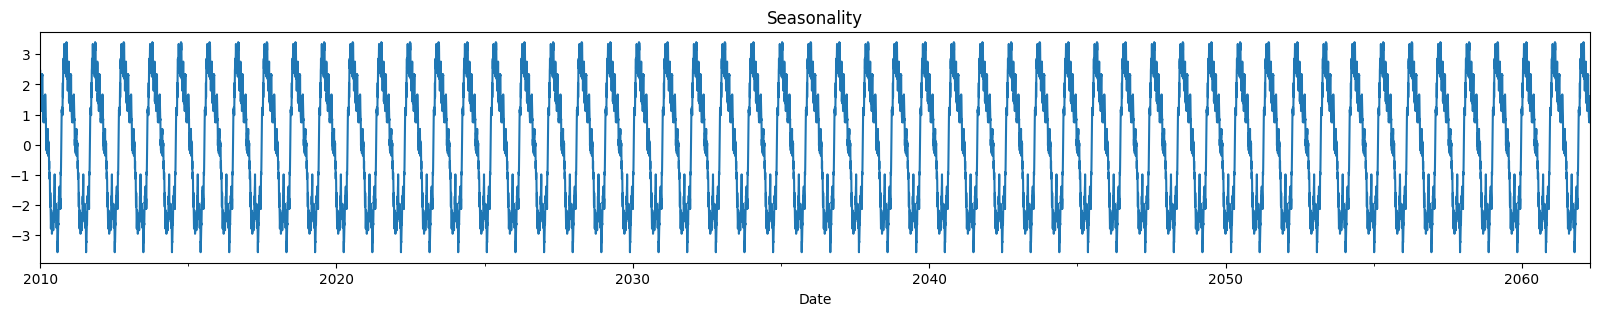

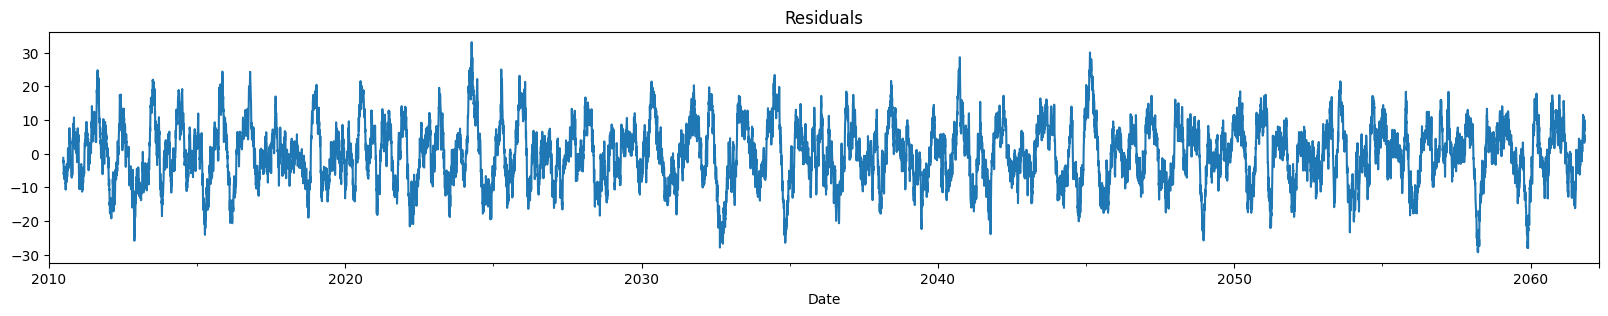

In [79]:
plot_decomposition(df_fe)

__Trend — долгосрочное направление__
- На верхнем графике видно:
  - длительный рост цены (примерно 2010–2025)
  - затем постепенное снижение (примерно 2025–2040)
  -  затем слабое восстановление

Это сглаженная линия, показывающая общую тенденцию, без шума и сезонных колебаний.

__Seasonality — повторяющиеся циклы__
- Средний график показывает регулярные колебания:
  - амплитуда стабильная
  - периодичность постоянная
  - значения колеблются примерно от −3 до +3

Это означает, что в данных есть повторяющийся сезонный паттерн, который повторяется каждый период  (период = 252, то есть год торговых дней).

__Residuals — шум__
- Нижний график показывает:
  - хаотичные колебания вокруг нуля

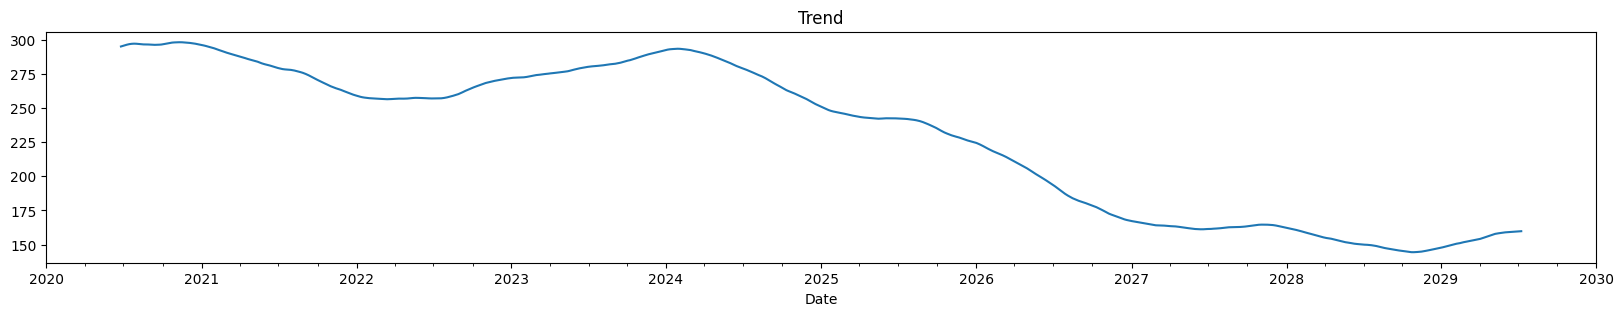

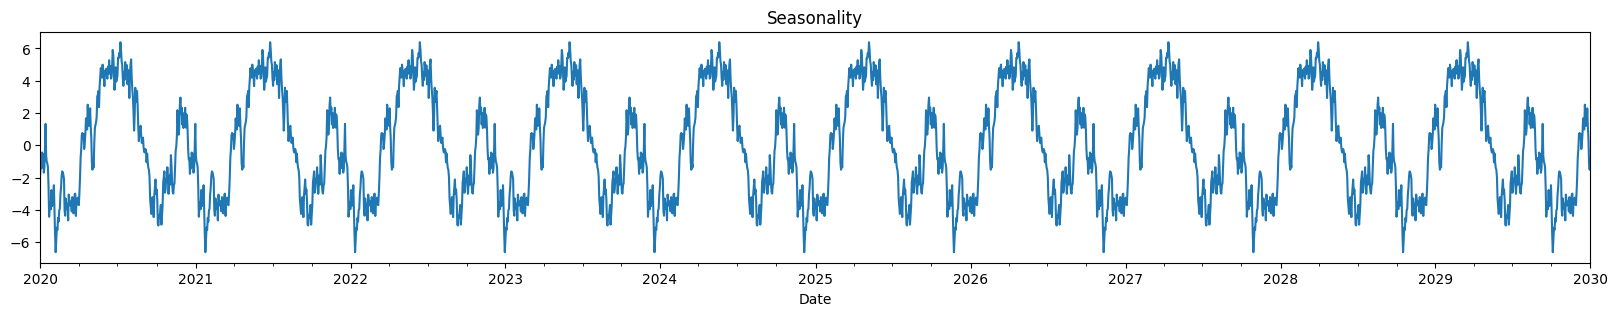

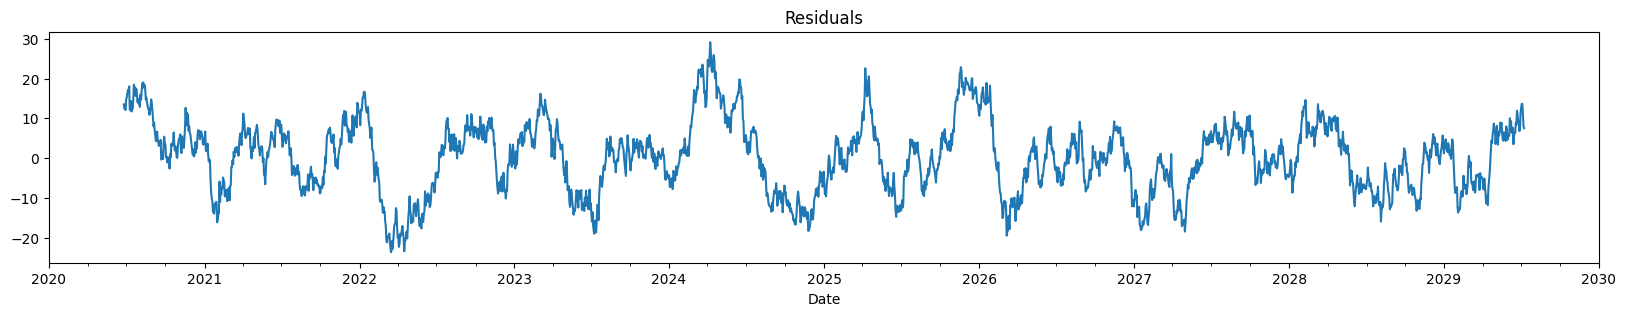

In [80]:
plot_decomposition(df_fe, start="2020-01-01", end="2030-01-01")

Тренд показывает долгосрочный рост/снижение, сезонность — повторяющиеся годовые паттерны, остатки — шум и локальные аномалии.

Декомпозиция временного ряда close
- Trend: долгосрочные циклы роста и падения
- Seasonality: выраженная годовая сезонность с амплитудой ±5
- Residuals: кластеры повышенной волатильности

__Сезонность по месяцам и дням недели__

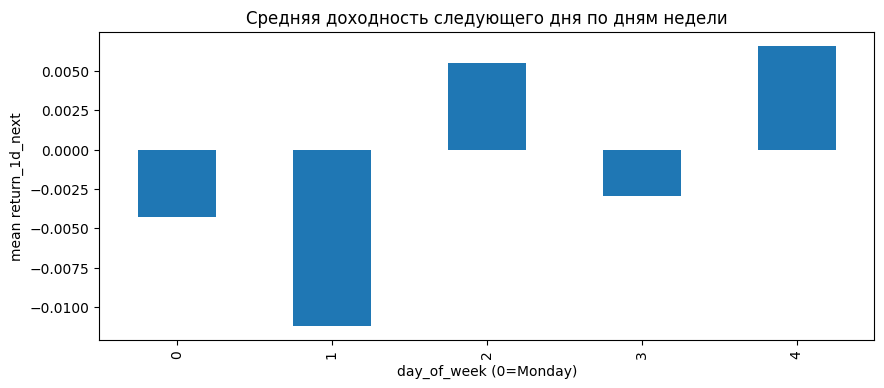

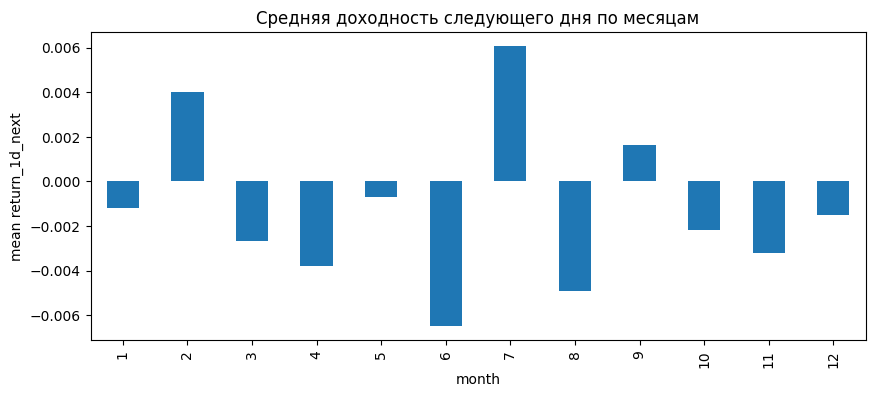

In [81]:
# Средняя доходность по дням недели и месяцам
df_fe["return_1d_next"] = df_fe["return_1d"].shift(-1)

dow_mean = df_fe.groupby("day_of_week")["return_1d_next"].mean()
month_mean = df_fe.groupby("month")["return_1d_next"].mean()

plt.figure(figsize=(10, 4))
dow_mean.plot(kind="bar")
plt.title("Средняя доходность следующего дня по дням недели")
plt.xlabel("day_of_week (0=Monday)")
plt.ylabel("mean return_1d_next")
plt.show()

plt.figure(figsize=(10, 4))
month_mean.plot(kind="bar")
plt.title("Средняя доходность следующего дня по месяцам")
plt.xlabel("month")
plt.ylabel("mean return_1d_next")
plt.show()

Средняя доходность следующего дня по дням недели
- 0 (Понедельник) — средняя доходность отрицательная
  - Это классический эффект: понедельники часто слабые из‑за накопления новостей за выходные.
- 1 (Вторник) — тоже отрицательная
  - Иногда вторник продолжает слабость понедельника.
- 2 (Среда) — доходность становится положительной
  - Часто середина недели — стабилизация.
- 3 (Четверг) — около нуля или слабый плюс
  - Нейтральный день.
- 4 (Пятница) — заметно положительная
  - Часто рынок растёт перед выходными, особенно если неделя была спокойной.

Средняя доходность следующего дня по месяцам
- Февраль и июль — заметные положительные пики
- Июнь и август — отрицательные провалы
- Остальные месяцы — около нуля или слабый плюс/минус

🧩 Интерпретация
- Февраль часто бывает сильным месяцем после январской волатильности
- Лето (июнь–август) часто слабое из‑за низкой ликвидности
- Июль иногда даёт отскок после слабого июня
- Осень обычно нейтральная или волатильная

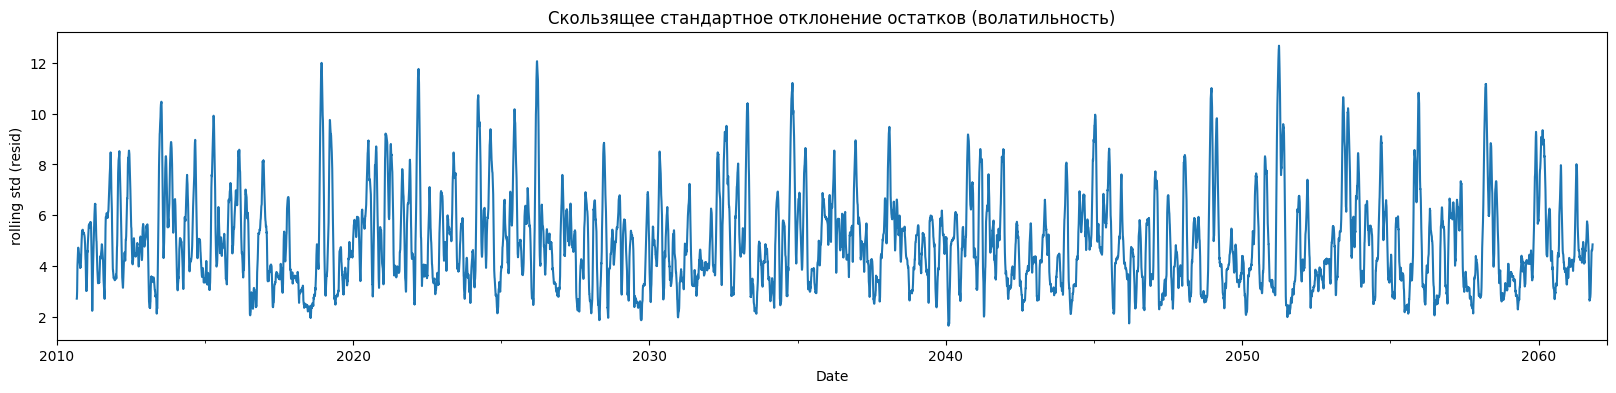

In [82]:
# Остатки из декомпозиции
decomp = seasonal_decompose(df_fe["close"], model="additive", period=252)
resid = decomp.resid

rolling_resid_std = resid.rolling(window=50).std()

plt.figure(figsize=(20, 4))
rolling_resid_std.plot()
plt.title("Скользящее стандартное отклонение остатков (волатильность)")
plt.ylabel("rolling std (resid)")
plt.show()

Скользящее стандартное отклонение остатков
- Анализ: волатильность непостоянна, есть периоды сжатия и расширения

Вывод: кластеризация волатильности — важный рыночный феномен

### 3.4. Автокорреляция и лаги <a class="anchor" id="ch5_3_4"></a>

In [83]:
def plot_returns(df, column="return_1d", start=None, end=None, figsize=(20,5)):
    # Фильтрация по интервалу
    if start or end:
        df = df.loc[start:end]

    plt.figure(figsize=figsize)
    plt.plot(df.index, df[column], color="blue", linewidth=1)
    plt.title(f"Доходности ({column}) во времени")
    plt.xlabel("Date")
    plt.ylabel("Return")
    plt.axhline(0, color="black", linewidth=1, linestyle="--")
    plt.tight_layout()
    plt.show()


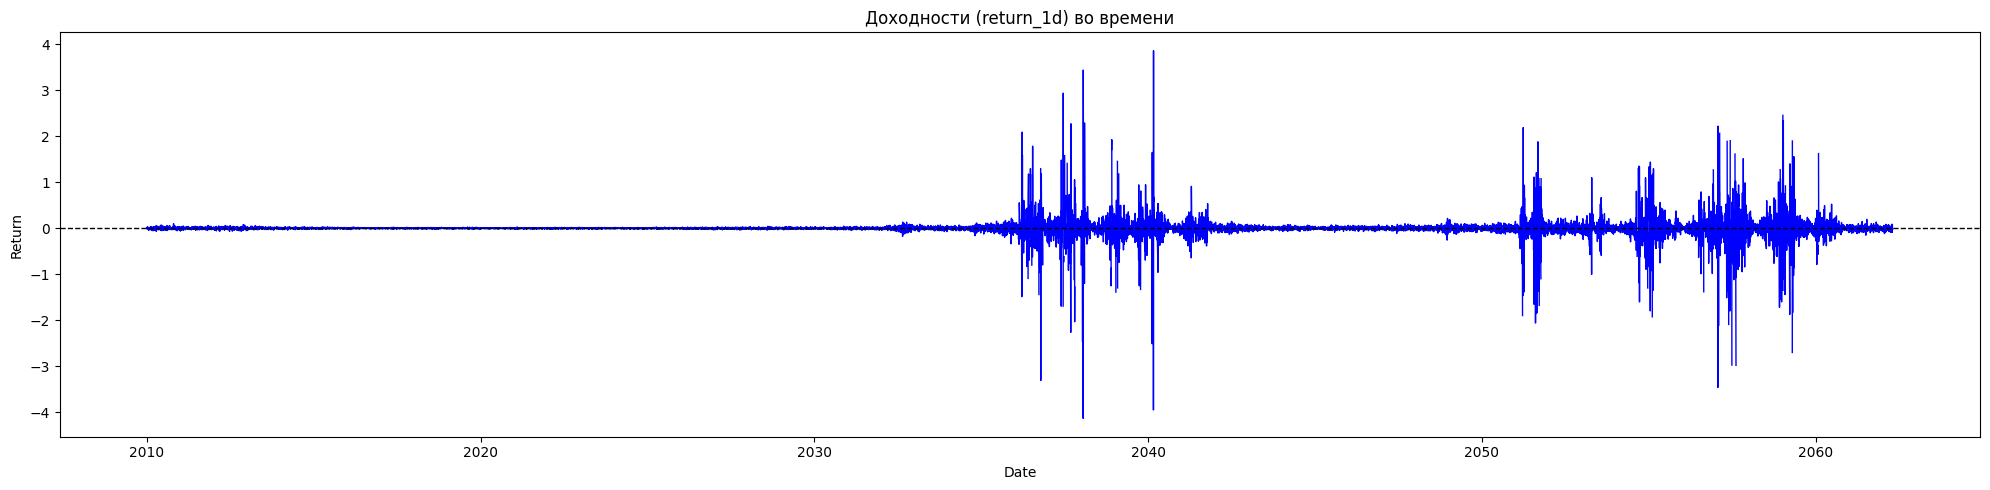

In [84]:
plot_returns(df_fe)

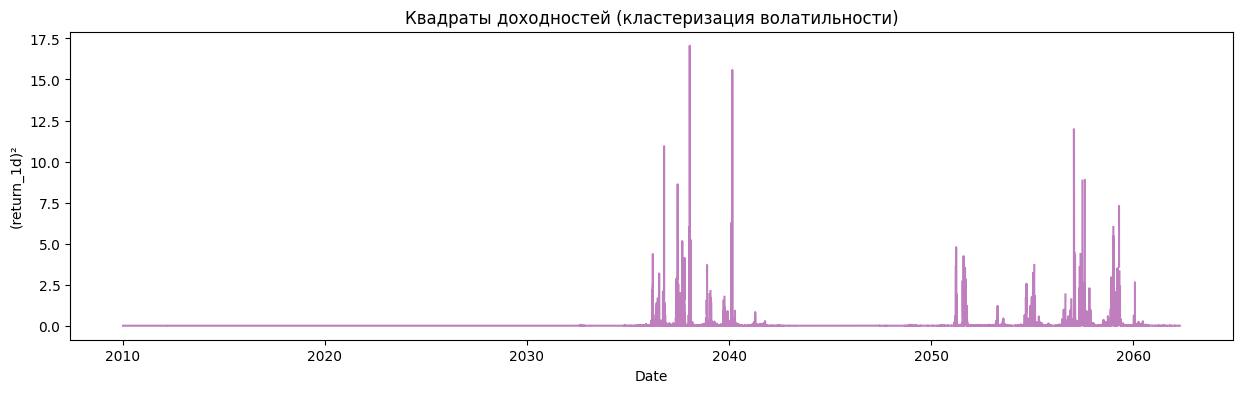

In [85]:
# График квадратов доходностей для визуализации кластеризации волатильности
plt.figure(figsize=(15, 4))
plt.plot(df_fe.index, df_fe['return_1d']**2, color='purple', alpha=0.5)
plt.title('Квадраты доходностей (кластеризация волатильности)')
plt.ylabel('(return_1d)²')
plt.xlabel('Date')
plt.show()

__Доходности колеблются вокруг нуля__
- Это ключевой признак стационарности:
  - нет тренда
  - нет систематического роста или падения
  - среднее значение близко к нулю

__Волатильность меняется во времени__
- На графике заметны:
  - спокойные периоды (низкая амплитуда колебаний)
  - всплески волатильности (резкие пики вверх/вниз)
- Это типичное поведение финансовых рядов — кластеризация волатильности.
- Обычно это означает, что:
  - после спокойных периодов часто следуют спокойные
  - после волатильных — волатильные

__Есть редкие, но сильные выбросы__
- Пики вверх/вниз — это:
  - новости
  - отчёты
  - макроэкономические события
  - паника или эйфория рынка
- Доходности всегда содержат такие «хвосты»

__Проверка стационарности__

In [86]:
# --- 3.4.1. Проверка стационарности лог-доходностей ---
returns = df_fe["return_1d"].dropna()

adf_stat, p_value, used_lags, n_obs, crit_vals, icbest = adfuller(returns)

print("ADF-тест на стационарность лог-доходностей")
print(f"ADF statistic: {adf_stat:.4f}")
print(f"p-value: {p_value:.4f}")
print("Критические значения:")
for key, value in crit_vals.items():
    print(f"   {key}: {value:.4f}")

if p_value < 0.05:
    print("\n✔ Ряд стационарен (отклоняем H0)")
else:
    print("\n✖ Ряд НЕ стационарен (не отклоняем H0)")

ADF-тест на стационарность лог-доходностей
ADF statistic: -21.9636
p-value: 0.0000
Критические значения:
   1%: -3.4308
   5%: -2.8618
   10%: -2.5669

✔ Ряд стационарен (отклоняем H0)


Интерпретация:
- p-value < 0.05 → гипотеза о единичном корне отвергается, ряд доходностей можно считать стационарным (что типично для лог-доходностей)

__ACF и PACF__

<Figure size 1200x300 with 0 Axes>

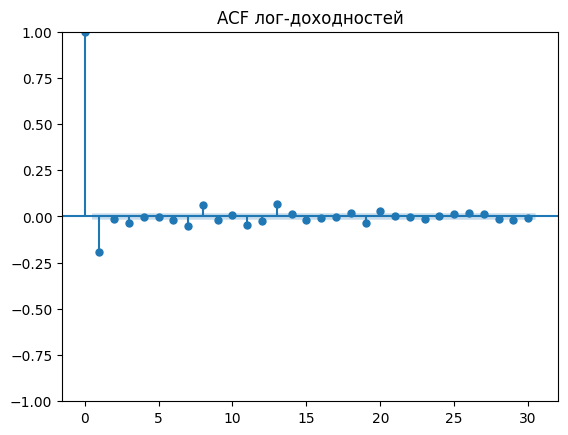

<Figure size 1200x300 with 0 Axes>

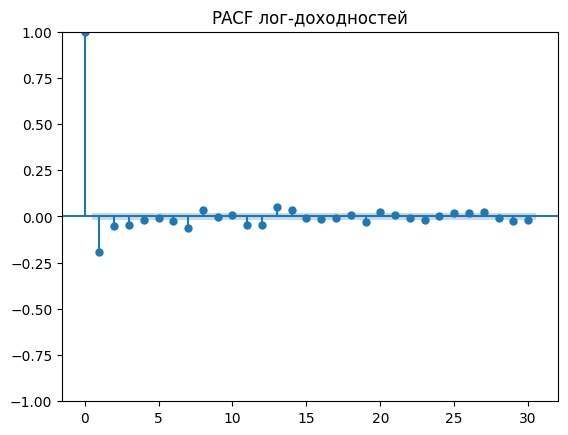

In [87]:
# --- 3.4.2. ACF и PACF ---

plt.figure(figsize=(12,3))
plot_acf(returns, lags=30)
plt.title("ACF лог-доходностей")
plt.show()

plt.figure(figsize=(12,3))
plot_pacf(returns, lags=30, method="ywm")
plt.title("PACF лог-доходностей")
plt.show()

__Автокорреляция и лаги__
- Проверка стационарности
  - ADF-test: statistic = -21.96, p-value = 0.0000
    - statistic очень сильное отрицательное значение. Чем оно меньше нуля, тем более уверенно тест говорит «ряд стационарен»
    - p‑value = 0.0000  означает, что вероятность ошибочно отклонить гипотезу о нестационарности практически нулева
  - Вывод: ряд доходностей стационарен (отвергаем H0 о единичном корне)
- 📈 Почему доходности почти всегда стационарны
  - Это фундаментальное свойство финансовых временных рядов:
    - цены — нестационарны (имеют тренд, случайное блуждание)
    - доходности — стационарны (колеблются вокруг среднего, имеют ограниченную дисперсию)  
  
- ACF и PACF доходностей
  - Сильный пик на лаге 0 — это нормально, автокорреляция с самим собой
  - Все остальные лаги близки к нулю и лежат внутри доверительного интервала
  - Анализ: нет значимых автокорреляций на lag ≥ 1
  - Вывод: линейные зависимости по лагам отсутствуют

### 3.5. Корреляционный анализ <a class="anchor" id="ch5_3_5"></a>


Phik-корреляции признаков с target:
rsi          0.244047
volume       0.018824
macd         0.016018
open         0.000000
high         0.000000
low          0.000000
close        0.000000
sentiment    0.000000
Name: target, dtype: float64


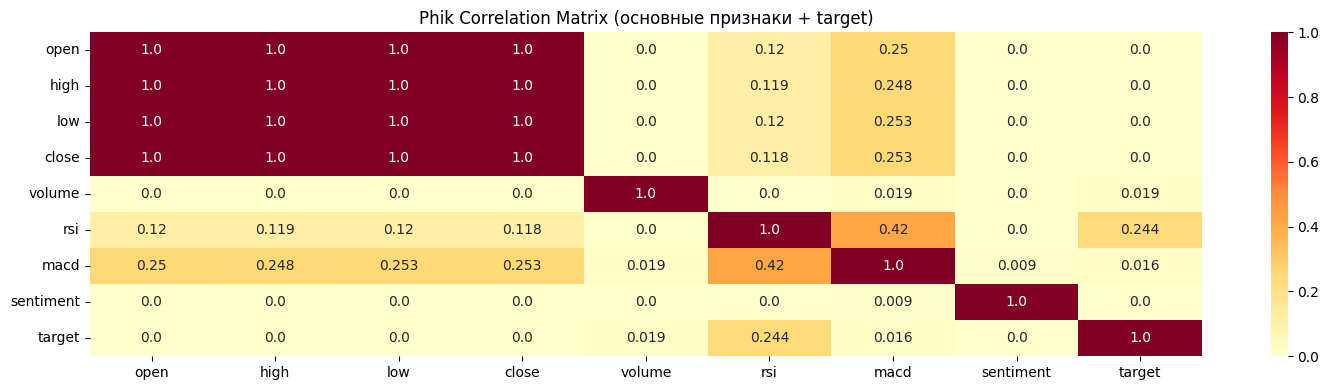


Пары числовых признаков с высокой корреляцией (|corr| > 0.5):
high  close    0.999968
low   close    0.999968
open  close    0.999968
      low      0.999968
high  low      0.999968
open  high     0.999967
dtype: float64

Количество пар с высокой корреляцией: 6


In [88]:
# --- 3.5.1. Phik-корреляции с target ---

phik_cols = ['open', 'high', 'low', 'close', 'volume', 'rsi', 'macd', 'sentiment', 'target']
df_phik = df_fe[phik_cols].dropna()

# Phik-матрица
phik_corr = df_phik.phik_matrix(interval_cols=phik_cols)

# Корреляции с target
target_phik = phik_corr["target"].drop("target").sort_values(ascending=False)
print("\nPhik-корреляции признаков с target:")
print(target_phik)

# Heatmap
plt.figure(figsize=(15, 4))
sns.heatmap(
    phik_corr,
    cmap="YlOrRd",
    annot=phik_corr.round(3),
    fmt="",
    vmin=0, vmax=1
)
plt.title("Phik Correlation Matrix (основные признаки + target)")
plt.tight_layout()
plt.show()

# --- Pearson-корреляции между числовыми признаками ---

num_cols = df_fe[phik_cols].select_dtypes(include=["float64", "int64"]).columns.drop("target")

pearson_corr = df_fe[num_cols].corr()

# Пары с |corr| > 0.5
pairs = pearson_corr.where(np.triu(np.abs(pearson_corr) > 0.5, k=1)).stack().sort_values(ascending=False)

print("\nПары числовых признаков с высокой корреляцией (|corr| > 0.5):")
print(pairs if not pairs.empty else "Нет пар с высокой корреляцией.")

print(f"\nКоличество пар с высокой корреляцией: {len(pairs)}")


Phik-корреляции признаков с target:
rsi_lag1                    0.246628
rsi                         0.242228
close_position              0.235198
rsi_overbought              0.181314
rsi_oversold                0.167517
lower_shadow                0.110597
upper_shadow                0.106615
macd_cross_up               0.042986
sentiment_ma_5              0.031955
macd_above_signal           0.030233
macd_signal                 0.029114
macd_lag1                   0.027633
return_1d_next              0.027011
macd                        0.026841
return_1d                   0.025511
high_low_ratio              0.023207
macd_hist                   0.022801
rolling_min_5               0.017714
dist_to_low_5               0.017064
body                        0.016135
close_lag1                  0.014672
day_of_week                 0.012160
vol_lag1                    0.012084
volume                      0.010748
sentiment_lag1              0.009345
macd_cross_down             0.009320
r

,rsi_lag1,rsi,close_position,rsi_overbought,rsi_oversold,lower_shadow,upper_shadow
rsi_lag1,1.000000,0.919477,0.038902,0.877721,0.877193,0.027006,0.055128
rsi,0.919477,1.000000,0.035642,0.988837,0.998221,0.014434,0.000000
close_position,0.038902,0.035642,1.000000,0.014843,0.006975,0.775085,0.784687
rsi_overbought,0.877721,0.988837,0.014843,1.000000,0.161414,0.000000,0.014810
rsi_oversold,0.877193,0.998221,0.006975,0.161414,1.000000,0.017383,0.000000
lower_shadow,0.027006,0.014434,0.775085,0.000000,0.017383,1.000000,0.229405
upper_shadow,0.055128,0.000000,0.784687,0.014810,0.000000,0.229405,1.000000


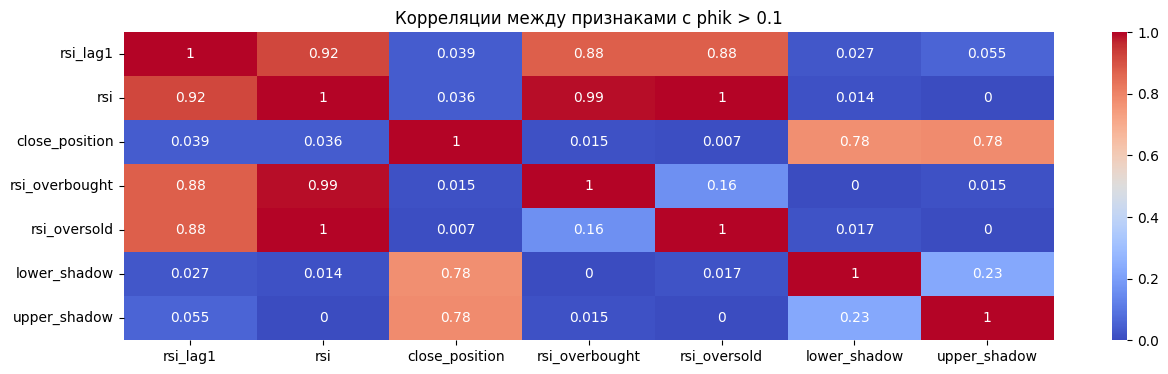

In [89]:
df_clean = df_fe.dropna()

# Полная phik-матрица
phik_corr = df_clean.phik_matrix(interval_cols=df_clean.columns)

# Корреляции признаков с target
target_corr = phik_corr["target"].drop("target").sort_values(ascending=False)
print("\nPhik-корреляции признаков с target:")
print(target_corr)

# Признаки с phik > 0.1
important_features = target_corr[target_corr > 0.1].index.tolist()

if important_features:
    print("\n📌 Признаки с phik > 0.1:", important_features)

    # Матрица корреляций между ними
    corr_between_features = df_clean[important_features].phik_matrix(interval_cols=important_features)

    print("\n🔗 Корреляции между признаками с phik > 0.1:")
    display(corr_between_features)
else:
    print("\nНет признаков с phik > 0.1")
    
    
# --- матрица корреляций между признаками (если их > 1) ---
if len(important_features) > 1:
    corr_between_features = df_clean[important_features].phik_matrix(interval_cols=important_features)

    plt.figure(figsize=(15, 4))
    sns.heatmap(corr_between_features, annot=True, cmap="coolwarm", vmin=0, vmax=1)
    plt.title("Корреляции между признаками с phik > 0.1")
    plt.show()
else:
    print("\nНедостаточно признаков с phik > 0.1 для матрицы корреляций.")


Phik-корреляции признаков с target:
rsi_lag1                    0.246628
rsi                         0.242228
close_position              0.235198
rsi_overbought              0.181314
rsi_oversold                0.167517
lower_shadow                0.110597
upper_shadow                0.106615
macd_cross_up               0.042986
sentiment_ma_5              0.031955
macd_above_signal           0.030233
macd_signal                 0.029114
macd_lag1                   0.027633
return_1d_next              0.027011
macd                        0.026841
return_1d                   0.025511
high_low_ratio              0.023207
macd_hist                   0.022801
rolling_min_5               0.017714
dist_to_low_5               0.017064
body                        0.016135
close_lag1                  0.014672
day_of_week                 0.012160
vol_lag1                    0.012084
volume                      0.010748
sentiment_lag1              0.009345
macd_cross_down             0.009320
r

,rsi_lag1,rsi,close_position,rsi_overbought,rsi_oversold,lower_shadow,upper_shadow,target
rsi_lag1,1.000000,0.919477,0.038902,0.877721,0.877193,0.027006,0.055128,0.246628
rsi,0.919477,1.000000,0.035642,0.988837,0.998221,0.014434,0.000000,0.242228
close_position,0.038902,0.035642,1.000000,0.014843,0.006975,0.775085,0.784687,0.235198
rsi_overbought,0.877721,0.988837,0.014843,1.000000,0.161414,0.000000,0.014810,0.181314
rsi_oversold,0.877193,0.998221,0.006975,0.161414,1.000000,0.017383,0.000000,0.167517
lower_shadow,0.027006,0.014434,0.775085,0.000000,0.017383,1.000000,0.229405,0.110597
upper_shadow,0.055128,0.000000,0.784687,0.014810,0.000000,0.229405,1.000000,0.106615
target,0.246628,0.242228,0.235198,0.181314,0.167517,0.110597,0.106615,1.000000


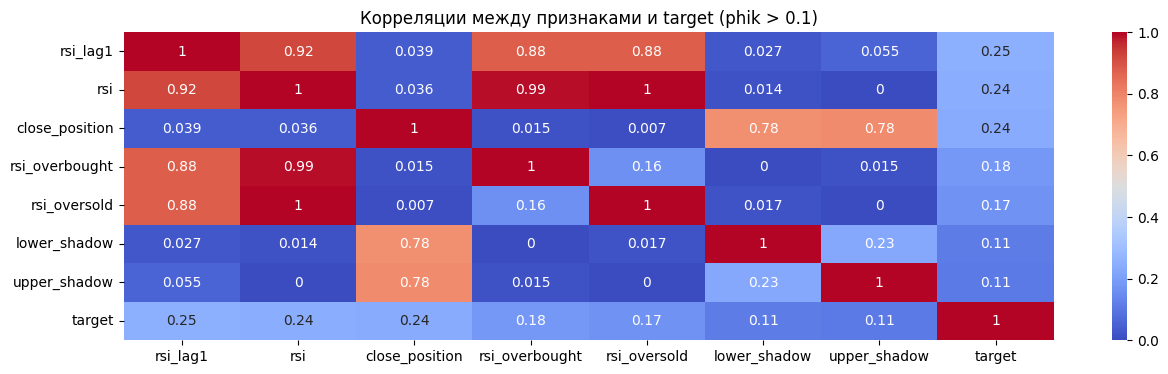

In [90]:
df_clean = df_fe.dropna()

# Полная phik-матрица
phik_corr = df_clean.phik_matrix(interval_cols=df_clean.columns)

# Корреляции признаков с target
target_corr = phik_corr["target"].drop("target").sort_values(ascending=False)
print("\nPhik-корреляции признаков с target:")
print(target_corr)

# Признаки с phik > 0.1
important_features = target_corr[target_corr > 0.1].index.tolist()

if important_features:
    print("\n📌 Признаки с phik > 0.1:", important_features)

    # --- ДОБАВЛЕНО: включаем target в матрицу ---
    features_with_target = important_features + ["target"]

    # Матрица корреляций между ними
    corr_between_features = df_clean[features_with_target].phik_matrix(interval_cols=features_with_target)

    print("\n🔗 Корреляции между признаками и target (phik > 0.1):")
    display(corr_between_features)
else:
    print("\nНет признаков с phik > 0.1")


# --- Heatmap (если признаков > 1) ---
if len(important_features) > 1:
    corr_imp = df_clean[features_with_target].phik_matrix(interval_cols=features_with_target)

    plt.figure(figsize=(15, 4))
    sns.heatmap(corr_imp, annot=True, cmap="coolwarm", vmin=0, vmax=1)
    plt.title("Корреляции между признаками и target (phik > 0.1)")
    plt.show()
else:
    print("\nНедостаточно признаков с phik > 0.1 для матрицы корреляций.")


Пары признаков с высокой корреляцией (|corr| > 0.7):
high            close               0.999968
low             close               0.999968
open            close               0.999968
                low                 0.999968
high            low                 0.999968
                                      ...   
volume          vol_ratio_5         0.871351
sentiment       sentiment_change    0.710575
sentiment_ma_5  sentiment_ma_10     0.701468
vol_ma_5        vol_ma_10           0.700837
sentiment_lag1  sentiment_change   -0.710550
Length: 78, dtype: float64

Количество пар с высокой корреляцией: 78


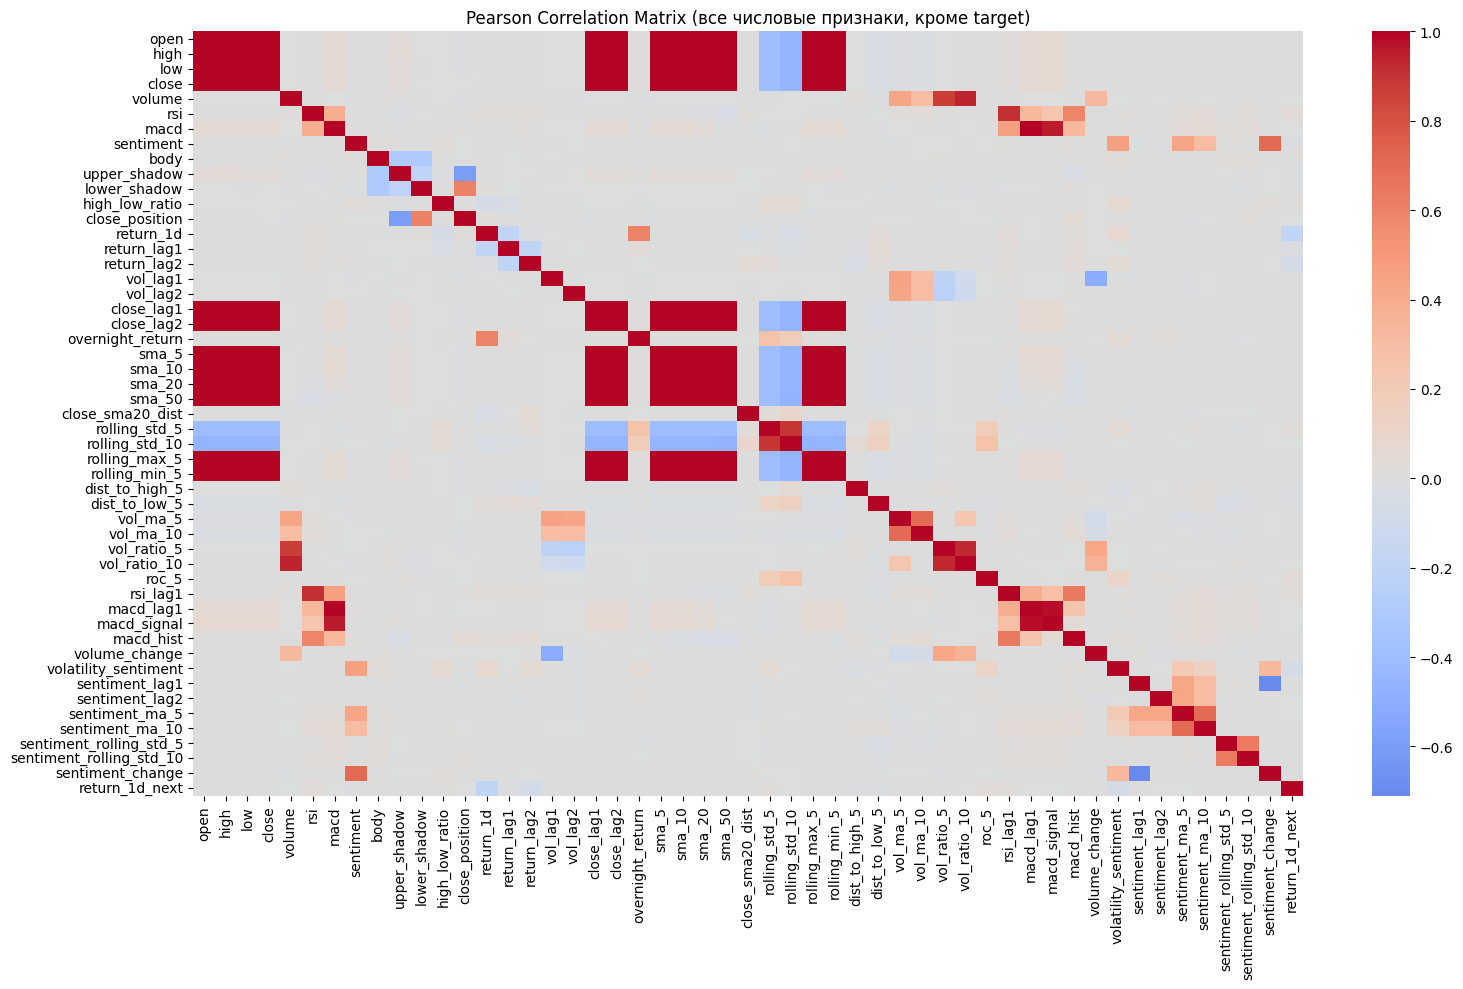

In [91]:
# --- 3.5.2. Pearson-корреляции между признаками (без target) ---

# Числовые признаки без target
num_cols = df_fe.select_dtypes(include=["float64", "int64"]).columns.drop("target", errors="ignore")

# Корреляционная матрица
corr = df_fe[num_cols].corr()

# Пары с |corr| > 0.7 (верхний треугольник)
pairs = corr.where(np.triu(np.abs(corr) > 0.7, k=1)).stack().sort_values(ascending=False)

print("\nПары признаков с высокой корреляцией (|corr| > 0.7):")
print(pairs if not pairs.empty else "Нет пар с высокой корреляцией.")
print(f"\nКоличество пар с высокой корреляцией: {len(pairs)}")

# Heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Pearson Correlation Matrix (все числовые признаки, кроме target)")
plt.tight_layout()
plt.show()

### 3.6. Анализ сентимента <a class="anchor" id="ch5_3_6"></a>

__Распределения Sentiment__


📊 Общая статистика по 'sentiment':
count    13647.000000
mean        -0.001146
std          0.573574
min         -0.999338
25%         -0.499346
50%          0.003138
75%          0.491161
max          0.999824
Name: sentiment, dtype: float64

📊 Статистика по группам target:
target            0            1
count   6811.000000  6836.000000
mean      -0.004055     0.001751
std        0.573149     0.574025
min       -0.999143    -0.999338
25%       -0.503178    -0.495397
50%        0.001761     0.004321
75%        0.483312     0.499455
max        0.999824     0.999796


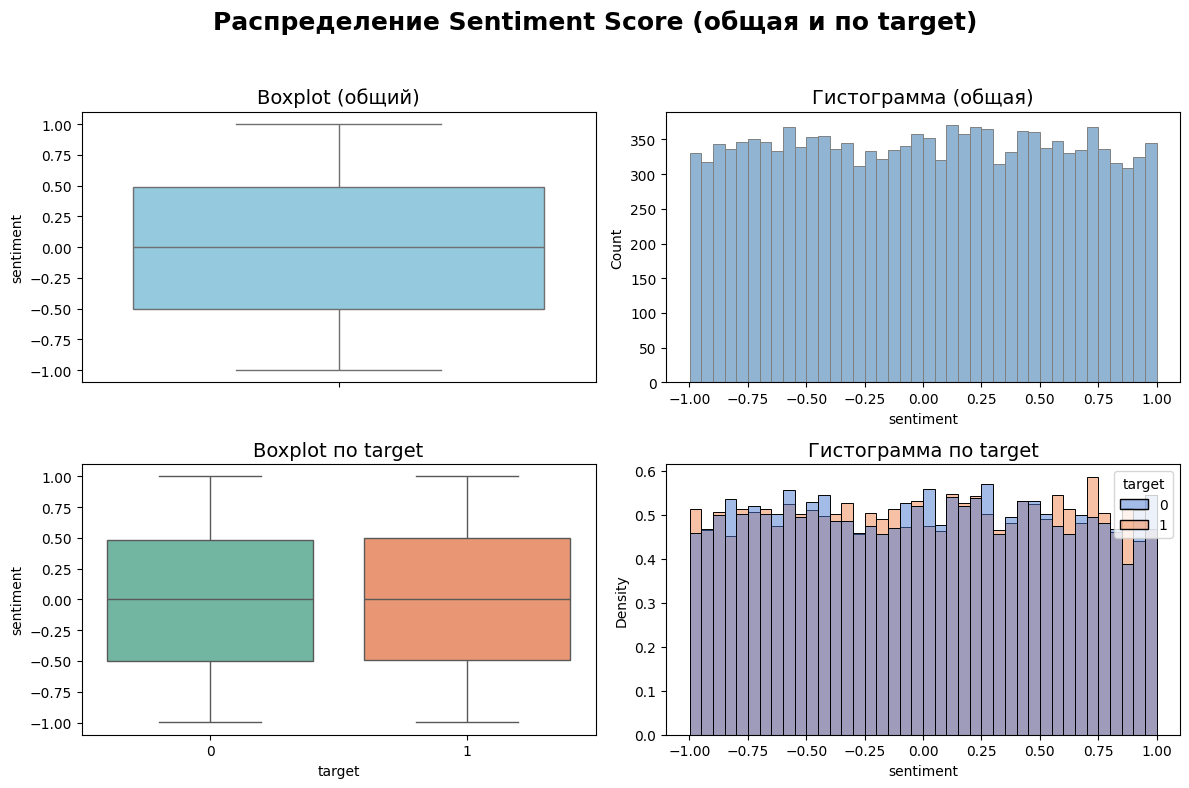

In [92]:
# Распределение Sentiment Score + boxplot по target
plot_feature_distribution(
    df_fe,
    feature="sentiment",
    title="Распределение Sentiment Score (общая и по target)"
)

Распределение Sentiment Score
- Результат: диапазон [-1, 1], среднее близко к нулю
- Анализ: распределения по классам почти идентичны

Вывод: Sentiment Score слабо коррелирует с target

__Корреляция сентимента с доходностью следующего дня__

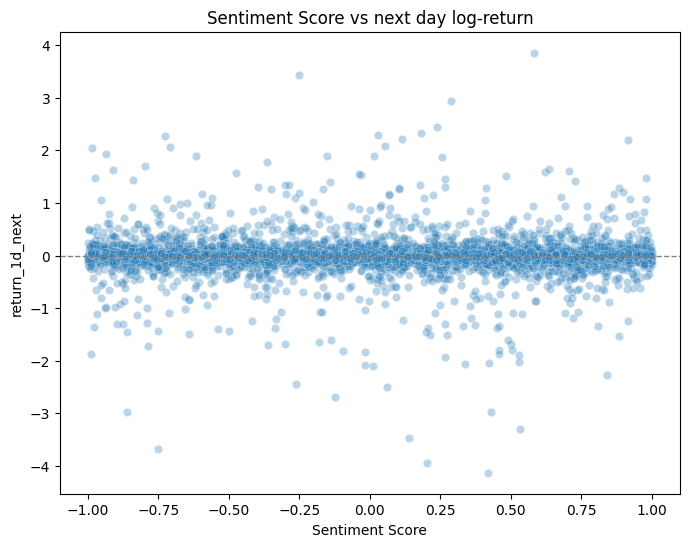

Корреляция sentiment с доходностью следующего дня: -0.009243719320045857


In [93]:
# next day return
df_fe["return_1d_next"] = df_fe["return_1d"].shift(-1)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_fe,
    x="sentiment",
    y="return_1d_next",
    alpha=0.3
)
plt.title("Sentiment Score vs next day log-return")
plt.xlabel("Sentiment Score")
plt.ylabel("return_1d_next")
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.show()

print("Корреляция sentiment с доходностью следующего дня:",
      df_fe[["sentiment", "return_1d_next"]].corr().iloc[0, 1])

__Корреляция сентимента с доходностью следующего дня__
- Корреляция: -0.0092 (практически нулевая)
- Вывод: Sentiment Score не является самостоятельным предиктором

__ACF/PACF сентимента__

<Figure size 1000x400 with 0 Axes>

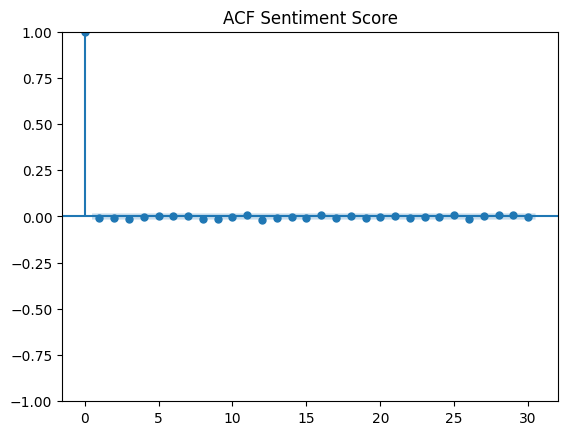

<Figure size 1000x400 with 0 Axes>

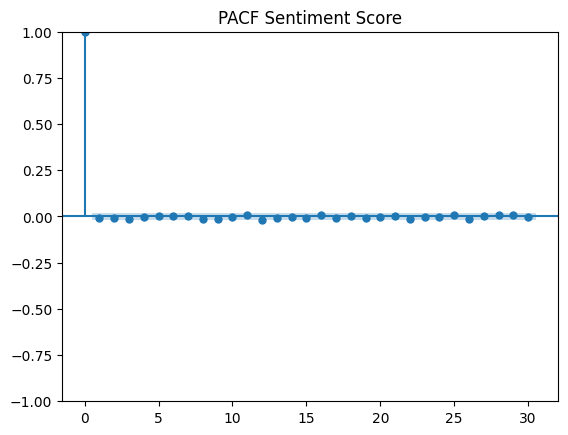

In [94]:
plt.figure(figsize=(10, 4))
plot_acf(df_fe["sentiment"].dropna(), lags=30)
plt.title("ACF Sentiment Score")
plt.show()

plt.figure(figsize=(10, 4))
plot_pacf(df_fe["sentiment"].dropna(), lags=30, method="ywm")
plt.title("PACF Sentiment Score")
plt.show()

__ACF/PACF сентимента__
- Анализ: значимая автокорреляция на lag 1 (~0.7), затем затухает
- Вывод: сентимент имеет инерцию, но быстро возвращается к среднему



<div style="border:solid green 4px; padding: 5px">

__Выводы по шагу 3:__
    
__1. Целевая переменная (target)__
- Идеальный баланс классов: 6836 наблюдений класса 1 (рост) и 6811 класса 0 (падение) – доли 50,09% и 49,91%.
- Логическая проверка: несовпадений между target и простым правилом close.shift(-1) > close не обнаружено.
- ⇒ target строго соответствует направлению движения цены закрытия на следующий день.

Вывод: дисбаланс отсутствует, можно использовать любые метрики без корректировки; задача классификации упрощается.    
    
__2. Распределения цен, объёма, доходностей__
- Ценовые признаки (open, high, low, close) имеют схожие распределения с длинными хвостами, средние значения ~100–102, разброс от отрицательных значений до ~320.
  - Для target=0 средние цены немного выше, чем для target=1 – рост чаще происходит после относительного снижения.
- Лог-доходности (return_1d):
  - Среднее близко к нулю (-0,0013), стандартное отклонение ~0,217.
  - Сильная левосторонняя асимметрия (skew = -1,53) и эксцесс ≈ 83 – очень тяжёлые хвосты.
  - Квантили: 0,001 → -2,05; 0,999 → 1,90 – редкие, но экстремальные движения.
  - Q-Q plot и тест Шапиро–Уилка (statistic = 0,4357, p-value = 0,0000) однозначно отвергают нормальность.

Вывод: доходности не нормальны, для моделирования предпочтительны робастные методы и непараметрические подходы.    
    
__3. Технические индикаторы (RSI, MACD)__
- RSI:
  - Диапазон [0, 100], среднее ~49,9.
  - Явное разделение по классам: для target=1 средний RSI = 52,8; для target=0 – 47,0.
  - Phik-корреляция с target = 0,244 – самый сильный предиктор среди всех признаков.
  - RSI overbought (>70) и oversold (меньше 30) также имеют значимую связь (phik 0,18 и 0,17).
- MACD:
  - Среднее около нуля (-0,027), диапазон [-7,38; 7,29].
    - Распределения для target=0 и target=1 практически идентичны, phik = 0,016 – слабая связь.

Вывод: RSI является сильным самостоятельным предиктором; MACD сам по себе информативен слабо, но может быть полезен в комбинации с другими признаками (например, пересечения).    
    
__4. Временные графики и тренды__
- Цена закрытия:
  - Долгосрочный тренд с несколькими циклами роста и падения.
  - Точки target=1 и target=0 равномерно распределены во времени, нет периодов доминирования одного класса.
  - Вывод: target не зависит от абсолютного уровня цены, что оправдывает использование производных признаков.
- Объём торгов:
  - Выраженные периоды высокой и низкой активности, объём сильно варьируется.
  - Зелёные и красные точки (target) присутствуют на всех уровнях объёма – объём сам по себе не определяет направление, но может усиливать сигнал.
- RSI, MACD, Sentiment во времени:
  - RSI часто достигает зон перекупленности (>70) и перепроданности (меньше 30), совпадая с разворотами.
  - MACD колеблется вокруг нуля, периоды устойчивого положительного/отрицательного значения соответствуют трендовым движениям.
  - Sentiment Score имеет высокочастотные колебания, иногда совпадает с резкими движениями цены.    
- Также на графике цен закрытия хорошо видна синтетичность данных
  - 2010-2040 это основной график
  - дальше по форме но с меньшей амплитудой ижет такой же график в интервалле примерно 2040-2050 
    
    
__5. Декомпозиция и сезонность__
- Декомпозиция (additive, period=252):
  - Trend: долгосрочные циклы роста (до ~2025), затем спад и слабое восстановление.
  - Seasonality: ярко выраженная годовая сезонность с амплитудой примерно ±5, стабильная по форме и силе.
  - Residuals: кластеры повышенной волатильности (например, вокруг 2020, 2035), что подтверждает наличие гетероскедастичности.
- Сезонность по дням недели:
  - Понедельник и вторник – отрицательная средняя доходность, среда – положительная, пятница – заметно положительная.
- Сезонность по месяцам:
  - Февраль и октябрь-декабрь – положительные, летние месяцы (июнь–август) – часто слабые.
- Скользящее стандартное отклонение остатков:
  - Волатильность непостоянна: периоды сжатия чередуются с расширением (кластеризация волатильности).

Вывод: календарные признаки (день недели, месяц) и меры волатильности должны быть включены в модель.    
    
__6. Автокорреляция и стационарность__
- ADF-тест для return_1d:
  - Статистика = -21,96, p-value = 0,0000 → ряд доходностей стационарен (отсутствие единичного корня).
  - Это фундаментальное свойство финансовых доходностей.
- ACF и PACF доходностей:
  - Значим только лаг 0 (автокорреляция с самой собой).
  - Все остальные лаги находятся внутри доверительного интервала → линейные зависимости по лагам отсутствуют.

Вывод: модели, полагающиеся на линейную автокорреляцию (ARIMA и т.п.), будут неэффективны; необходимо использовать нелинейные признаки и ансамбли.
    
__7. Корреляционный анализ__
- Phik-корреляции с target 
  - rsi_lag1: 0.246628
  - rsi: 0.242228
  - close_position: 0.235198
  - rsi_overbought: 0.181314
  - rsi_oversold: 0.167517
  - lower_shadow: 0.110597
  - upper_shadow: 0.106615
  - macd_cross_up: 0.042986
  - sentiment_ma_5: 0.031955  
- __Признаки с phik > 0,1: rsi_lag1, rsi, close_position, rsi_overbought, rsi_oversold, lower_shadow, upper_shadow.__
- Сырые ценовые признаки (open, high, low, close) и большинство скользящих средних, объёмных производных, лагов доходностей имеют phik = 0 – их исключение из модели не ухудшит качество (но они могут быть полезны в ансамблях).
- Sentiment Score сам по себе имеет phik = 0, однако его скользящая средняя за 5 дней (sentiment_ma_5) даёт phik = 0,032 – слабый, но ненулевой вклад.
- Мультиколлинеарность (Pearson)
  - Высокие корреляции (>0,5) между ценовыми признаками (open, high, low, close).
  - Например, high vs close = 0,99997, open vs close = 0,99997.
  - Количество пар с высокой корреляцией(|corr| > 0.7) для всех признаков: 78
    
__8. Анализ сентимента (Sentiment Score)__
- Распределение:
  - Диапазон [-1, 1], среднее ~0
  - Распределения для target=0 и target=1 почти идентичны.
- Корреляция с доходностью следующего дня:
  - Коэффициент Пирсона = -0,0092 – практически нулевая линейная связь    
    
__9. Общие выводы и рекомендации для моделирования__
- Ключевые предикторы:
  - RSI (особенно лагированный) → самый сильный сигнал.
  - close_position – положение цены внутри дневного диапазона.
  - Бинарные признаки перекупленности/перепроданности RSI.
  - Тени свечей (upper_shadow, lower_shadow).
- Второстепенные, но потенциально полезные признаки:
  - Скользящие средние сентимента (sentiment_ma_5), сигналы пересечения MACD.
  - Календарные признаки (день недели, месяц) – для учёта сезонности.
  - Признаки волатильности (rolling_std_5, rolling_std_10, high_low_ratio).
- Признаки, которые можно исключить без потери качества:
  - Сырые ценовые ряды (open, high, low, close) – оставить только один, например close, или вовсе убрать, заменив производными.
  - Большинство скользящих средних цены (sma_5, sma_10, sma_20, sma_50) – их информативность для направления низка.
  - Объёмные признаки (volume, vol_ma_5, vol_ratio_5 и т.д.) – phik = 0.
  - Лаги доходностей (return_lag1, return_lag2) – нулевая корреляция.
- Рекомендации по моделям:
  - Для линейных моделей (Logistic Regression) достаточно набора из 5–7 признаков с phik > 0,1.
  - Для деревьев и бустинга можно оставить больше признаков (включая скользящие средние сентимента, MACD-сигналы), так как они устойчивы к мультиколлинеарности и могут извлечь нелинейные взаимодействия.
  - Обязательно использовать TimeSeriesSplit для кросс-валидации.
  - Основная метрика – F1-score для класса 1 (рост), с дополнительным контролем Precision/Recall.
    
</div>

<div class="alert alert-info">
  <b> * <a href="#ch5">к содержанию</a> </b> 
</div>

---

## Шаг 4: Подготовка к моделированию <a class="anchor" id="ch5_4"></a>

### 4.1. Выбор признаков для модели на основе EDA <a class="anchor" id="ch5_4_1"></a>

На основании полного EDA и количественных оценок (phik-корреляции, мультиколлинеарность, визуальный анализ) сформируем два набора признаков:
- Компактный набор – для линейных моделей (Logistic Regression), устойчивый к мультиколлинеарности.
- Расширенный набор – для деревьев и ансамблей (Random Forest, XGBoost, LightGBM), которые могут использовать больше признаков, включая слабые, но потенциально полезные взаимодействия.

✅ 1. Минимальный набор признаков (__для Logistic Regression / интерпретируемых моделей__)
- Основа: признаки с phik > 0,1 (сильная связь с target) + календарные признаки (сезонность).
- Исключены: сырые цены, объёмные признаки, лаги доходностей, скользящие средние цены – они имеют phik ≈ 0 и создают мультиколлинеарность.
- только признаки с доказанной предсказательной силой
- Эти признаки имеют phik > 0.1 и статистически значимое разделение классов:
  - Основные сильные предикторы
    - rsi_lag1 – сильнейший предиктор 
    - rsi – инерция RSI
    - close_position – положение цены в дневном диапазоне
    - rsi_overbought – бинарный сигнал перекупленности
    - rsi_oversold – бинарный сигнал перепроданности
    - upper_shadow – нижняя тень
    - lower_shadow – верхняя тень
  - Календарные признаки
    - day_of_week - сезонность по дням недели (выявлена в EDA)
    - month - сезонность по месяцам (выявлена в EDA)
  - Волатильность
    - rolling_std_5
    - high_low_ratio

📌 Этот набор — 10–12 признаков — идеально подходит для интерпретируемых моделей.

🚀 2. Расширенный набор признаков (для Random Forest / XGBoost / LightGBM / CatBoost)
- Основа: все признаки с ненулевой phik (даже слабые) + календарные + волатильность + производные сентимента.
- Исключены только: сырые цены (open, high, low, close) – их дублируют производные; большинство скользящих средних цены (sma_5/10/20/50) – неинформативны.
- деревья устойчивы к мультиколлинеарности и хорошо ловят нелинейные взаимодействия
  - Добавляем к сильным предикторам:
    - MACD‑сигналы
    - macd_cross_up
    - macd_cross_down
    - macd_hist
  - Сентимент
    - sentiment_ma_5
    - sentiment_change
    - volatility_sentiment
  - Волатильность и экстремумы
    - rolling_std_10
    - dist_to_high_5
    - dist_to_low_5
  - Объём
    - volume_change

📌 Этот набор — 20–25 признаков — оптимален для бустинга.

__Финальный рекомендуемый набор для модели (готовый список)__

In [95]:
final_features = [
    # Сильные признаки
    "rsi", "rsi_lag1", "rsi_overbought", "rsi_oversold",
    "close_position", "upper_shadow", "lower_shadow",
    
    # Волатильность    
    "rolling_std_5", "rolling_std_10", "high_low_ratio",
    
    # MACD‑derived   
    "macd_cross_up", "macd_cross_down", "macd_hist",
    
    # Sentiment   
    "sentiment_ma_5", "sentiment_change", "volatility_sentiment",
    
    # Календарные     
    "day_of_week", "month", "quarter",
    
    # Дополнительно (для бустинга)    
    "dist_to_high_5", "dist_to_low_5", "volume_change",
    "body"
]

# Проверка длины
print(f"Всего признаков: {len(final_features)}")

Всего признаков: 23


In [96]:
# Проверка корреляций в выбранном наборе
corr_subset = df_fe[final_features].corr()

# Поиск пар с корреляцией > 0.7
high_corr_pairs = []
for i in range(len(corr_subset.columns)):
    for j in range(i+1, len(corr_subset.columns)):
        if abs(corr_subset.iloc[i, j]) > 0.7:
            high_corr_pairs.append((corr_subset.columns[i], 
                                   corr_subset.columns[j], 
                                   corr_subset.iloc[i, j]))

print(f"Пар с корреляцией >0.7: {len(high_corr_pairs)}")
if high_corr_pairs:
    for pair in high_corr_pairs:
        print(f"{pair[0]} — {pair[1]}: {pair[2]:.3f}")
else:
    print("Мультиколлинеарность устранена!")

Пар с корреляцией >0.7: 3
rsi — rsi_lag1: 0.910
rolling_std_5 — rolling_std_10: 0.893
month — quarter: 0.971


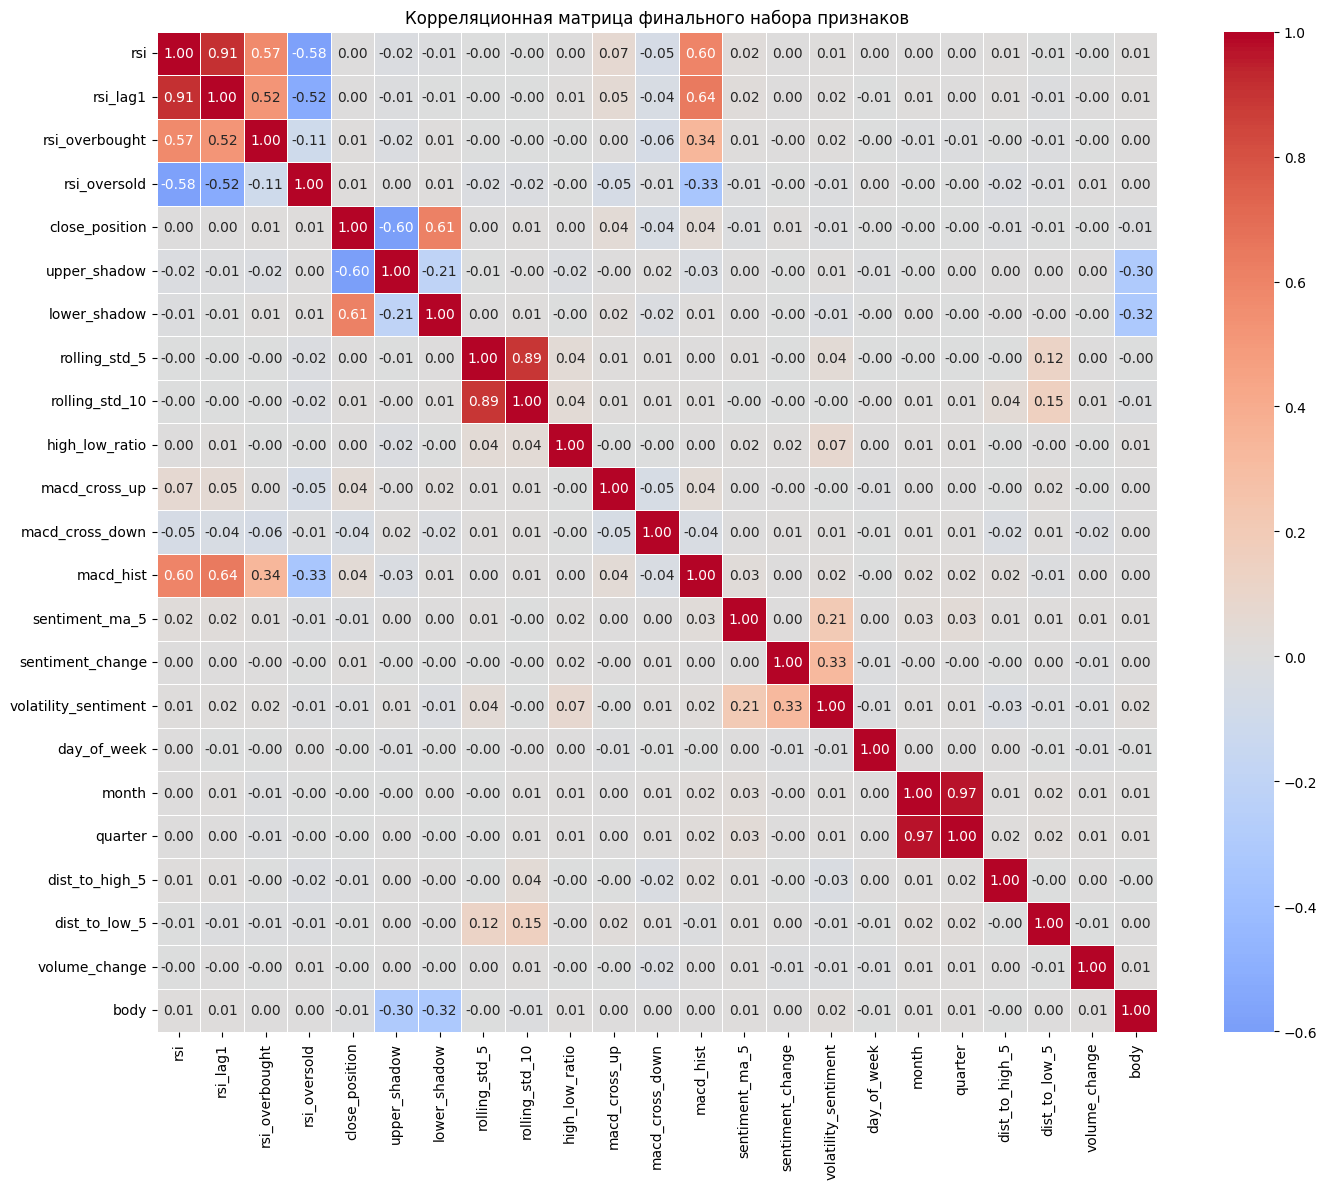

In [97]:
plt.figure(figsize=(15, 12))
sns.heatmap(corr_subset, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Корреляционная матрица финального набора признаков')
plt.tight_layout()
plt.show()

Для Logistic Regression
- Используем набор всех признаков, за исключением тех с КК больше 0.7
- Перед обучением обязательно масштабирование (StandardScaler / RobustScaler).
- Применим One-Hot Encoding для day_of_week и month

Для Decision Tree / Random Forest / XGBoost / LightGBM
- Используем весь список рекомендуемых признаков
- Масштабирование и кодипрование не требуется

### 4.2. Удаление Look-Ahead Bias и обработка пропусков <a class="anchor" id="ch5_4_2"></a>

✔ Look-Ahead Bias нет, потому что:
- все признаки используют только прошлые данные (shift, rolling)
- target не используется при создании признаков
- нет признаков, использующих будущее

In [98]:
# Проверка inf
inf_cols = np.isinf(df_fe[final_features]).sum()
print("inf по признакам:")
print(inf_cols[inf_cols > 0] if inf_cols.sum() > 0 else "inf не обнаружено")

inf по признакам:
inf не обнаружено


In [99]:
df_fe[final_features].info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 13647 entries, 2010-01-01 to 2062-04-24
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   rsi                   13647 non-null  float64
 1   rsi_lag1              13646 non-null  float64
 2   rsi_overbought        13647 non-null  int32  
 3   rsi_oversold          13647 non-null  int32  
 4   close_position        13647 non-null  float64
 5   upper_shadow          13647 non-null  float64
 6   lower_shadow          13647 non-null  float64
 7   rolling_std_5         13266 non-null  float64
 8   rolling_std_10        13070 non-null  float64
 9   high_low_ratio        13647 non-null  float64
 10  macd_cross_up         13647 non-null  int32  
 11  macd_cross_down       13647 non-null  int32  
 12  macd_hist             13647 non-null  float64
 13  sentiment_ma_5        13643 non-null  float64
 14  sentiment_change      13646 non-null  float64
 15  vo

In [100]:
# Проверка NaN
nan_cols = df_fe[final_features].isna().sum()
print("\nNaN по признакам:")
print(nan_cols[nan_cols > 0])


NaN по признакам:
rsi_lag1                  1
rolling_std_5           381
rolling_std_10          577
sentiment_ma_5            4
sentiment_change          1
volatility_sentiment    381
dist_to_high_5            4
dist_to_low_5             4
volume_change             1
dtype: int64


In [101]:
# Удаляем строки с NaN (первые ~50 строк)
df_model = df_fe[final_features + ['target']].dropna().copy()

print(f"\nРазмер до dropna: {df_fe[final_features].shape}")
print(f"\nРазмер после dropna: {df_model.shape}")


Размер до dropna: (13647, 23)

Размер после dropna: (13070, 24)


In [102]:
df_model.isnull().sum().sum()

0

### 4.3. Проверка утечки данных (Data Leakage) <a class="anchor" id="ch5_4_3"></a>

Проверяем, что:
- нет признаков, напрямую связанных с target
- нет признаков, использующих будущее
- нет признаков, вычисленных на основе target

In [103]:
def check_leakage(df, target_col="target"):
    suspicious = {
        "direct_target_features": [],
        "future_features": [],
        "derived_from_target": []
    }

    for col in df.columns:

        # --- 1. Признаки, напрямую связанные с target ---
        if target_col in col and col != target_col:
            suspicious["direct_target_features"].append(col)

        # --- 2. Признаки, использующие будущее ---
        # Ищем shift(-1), lead, future, next, ahead
        future_patterns = ["shift(-", "lead", "future", "next", "ahead", "_t+","_plus"]
        if any(p in col.lower() for p in future_patterns):
            suspicious["future_features"].append(col)

        # --- 3. Признаки, вычисленные на основе target ---
        # Например: target_rolling, target_mean, target_lag0, target_sma
        if ("target" in col.lower()) and (col != target_col):
            suspicious["derived_from_target"].append(col)

    # --- Удаляем дубликаты между категориями ---
    for key in suspicious:
        suspicious[key] = list(set(suspicious[key]))

    # --- Печать отчёта ---
    print("\n=== Проверка на утечки данных (Data Leakage) ===")

    print("\n1) Признаки, напрямую связанные с target:")
    print(suspicious["direct_target_features"] or "✔ Нет")

    print("\n2) Признаки, использующие будущее:")
    print(suspicious["future_features"] or "✔ Нет")

    print("\n3) Признаки, вычисленные на основе target:")
    print(suspicious["derived_from_target"] or "✔ Нет")

    print("\n=== Итог ===")
    if any(len(v) > 0 for v in suspicious.values()):
        print("⚠ Обнаружены потенциальные утечки. Проверь признаки выше.")
    else:
        print("✔ Утечек не найдено. Можно обучать модель.")

    return suspicious

In [104]:
leaks = check_leakage(df_model)


=== Проверка на утечки данных (Data Leakage) ===

1) Признаки, напрямую связанные с target:
✔ Нет

2) Признаки, использующие будущее:
✔ Нет

3) Признаки, вычисленные на основе target:
✔ Нет

=== Итог ===
✔ Утечек не найдено. Можно обучать модель.


### 4.4. Формирование выборок <a class="anchor" id="ch5_4_4"></a>

In [105]:
#  Разделение на признаки и целевую переменную
X = df_model[final_features]
y = df_model['target']

mi = mutual_info_classif(X, y, discrete_features=False)

print("Mutual Information:")
for col, val in zip(X.columns, mi):
    print(f"{col}: {val}")

Mutual Information:
rsi: 0.010895815460331582
rsi_lag1: 0.021346757649689296
rsi_overbought: 0.004609940978800964
rsi_oversold: 0.01089225386665671
close_position: 0.012579661379565232
upper_shadow: 0.006260887167406359
lower_shadow: 0.005287154791409732
rolling_std_5: 0.0
rolling_std_10: 0.0
high_low_ratio: 0.0
macd_cross_up: 0.0
macd_cross_down: 0.002358234221434996
macd_hist: 0.005417340703748774
sentiment_ma_5: 0.0008601897276556691
sentiment_change: 0.0014872438044479797
volatility_sentiment: 0.0
day_of_week: 0.0
month: 0.001364534095561476
quarter: 0.0
dist_to_high_5: 0.002911760055280599
dist_to_low_5: 0.007443319259534675
volume_change: 0.0
body: 0.0033160325506393917


In [106]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
rsi,13070.0,49.844344,15.011328,0.000000,39.522624,49.843424,60.155208,97.614964
rsi_lag1,13070.0,49.854694,15.012996,0.000000,39.530727,49.861820,60.164604,97.614964
rsi_overbought,13070.0,0.092502,0.289744,0.000000,0.000000,0.000000,0.000000,1.000000
rsi_oversold,13070.0,0.096940,0.295887,0.000000,0.000000,0.000000,0.000000,1.000000
close_position,13070.0,0.498913,0.262023,-0.328671,0.324680,0.499760,0.671362,1.345845
upper_shadow,13070.0,1.173704,0.740966,-0.483719,0.614887,1.172496,1.682703,3.414491
lower_shadow,13070.0,1.164442,0.742879,-0.483387,0.604882,1.156625,1.678235,3.393400
rolling_std_5,13070.0,0.063522,0.121108,0.000850,0.011179,0.024546,0.062415,2.108382
rolling_std_10,13070.0,0.066496,0.117759,0.002348,0.011527,0.026223,0.066084,1.865978
high_low_ratio,13070.0,0.355948,37.707817,-106.704927,0.010674,0.022273,0.052106,4308.434523


In [107]:
y

Date
2010-01-15    0
2010-01-18    1
2010-01-19    0
2010-01-20    0
2010-01-21    0
             ..
2062-04-18    0
2062-04-19    1
2062-04-20    0
2062-04-21    0
2062-04-24    0
Name: target, Length: 13070, dtype: int64

- Проверка стабильности признаков во времени

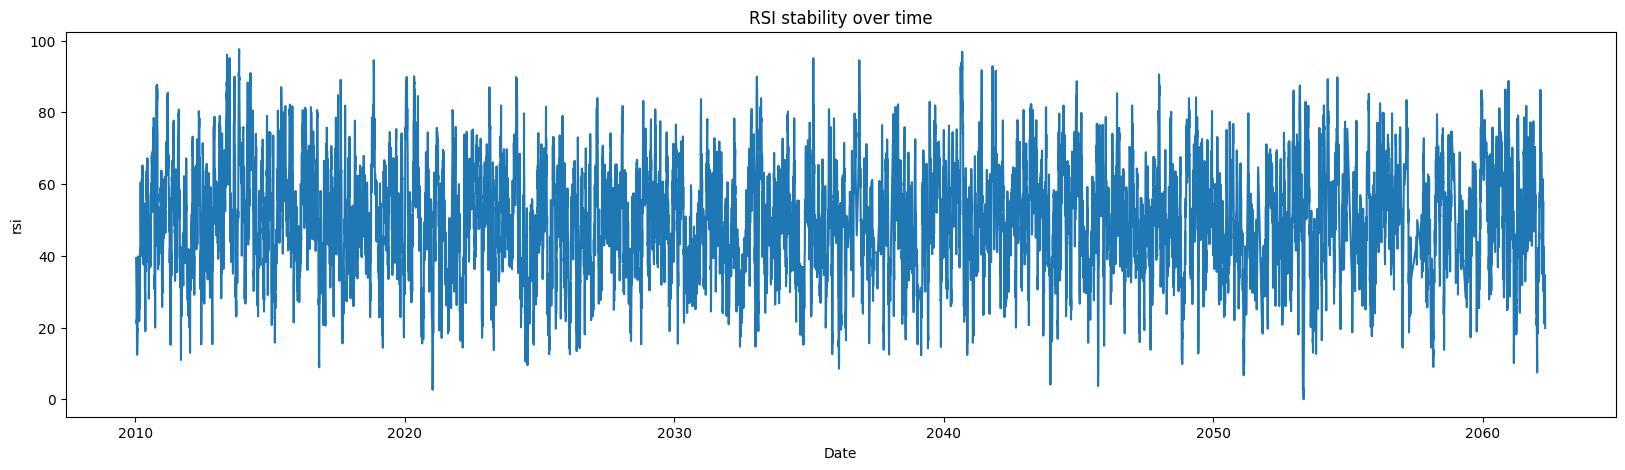

In [108]:
plt.figure(figsize=(20,5))
sns.lineplot(x=df_model.index, y=df_model["rsi"])
plt.title("RSI stability over time")
plt.show()

### 4.5. Разделение на train/valid/test с учётом времени <a class="anchor" id="ch5_4_5"></a>

✔ Логика:
- Train: 2010–2045
- Valid: 2046–2053
- Test: 2054-2062

Для оценки модели данные разделены в хронологическом порядке: обучающая выборка (2010–2045), валидационная для подбора гиперпараметров (2046-2053) и чистая тестовая выборка (2054-2062). Такой подход имитирует реальную торговлю, где модель обучается на истории и проверяется на новых данных

In [109]:
train = df_model[df_model.index.year <= 2045]
valid = df_model[(df_model.index.year >= 2046) & (df_model.index.year <= 2053)]
test  = df_model[df_model.index.year >= 2054]

X_train, y_train = train[final_features], train['target']
X_valid, y_valid = valid[final_features], valid['target']
X_test,  y_test  = test[final_features],  test['target']

print("X:", X.shape)
print("Train:", X_train.shape)
print("Valid:", X_valid.shape)
print("Test:",  X_test.shape)

X: (13070, 23)
Train: (9179, 23)
Valid: (2020, 23)
Test: (1871, 23)


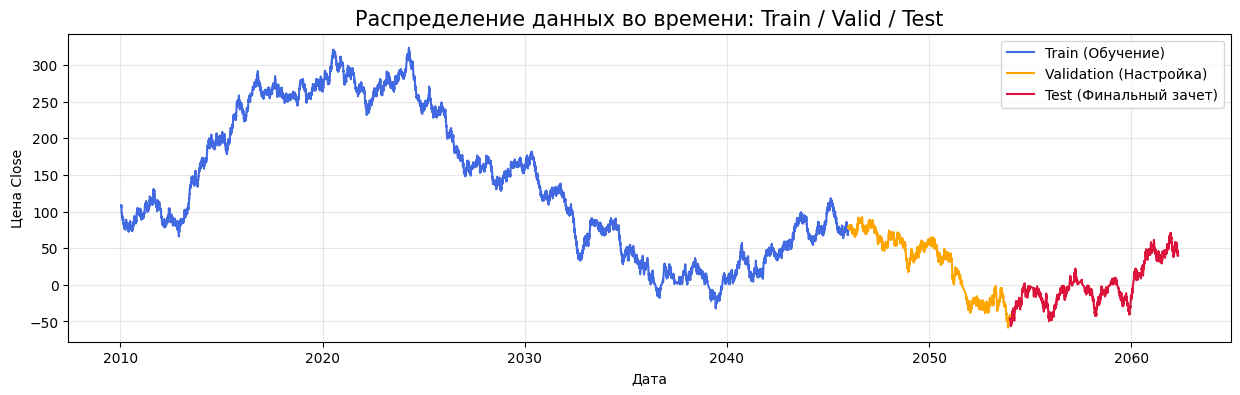

In [110]:
plt.figure(figsize=(15, 4))

# Рисуем каждую часть своим цветом
# Используем цену Close или доходность, чтобы показать временную шкалу
plt.plot(X_train.index, df.loc[X_train.index, 'close'], label='Train (Обучение)', color='royalblue')
plt.plot(X_valid.index, df.loc[X_valid.index, 'close'], label='Validation (Настройка)', color='orange')
plt.plot(X_test.index, df.loc[X_test.index, 'close'], label='Test (Финальный зачет)', color='crimson')

plt.title('Распределение данных во времени: Train / Valid / Test', fontsize=15)
plt.ylabel('Цена Close')
plt.xlabel('Дата')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

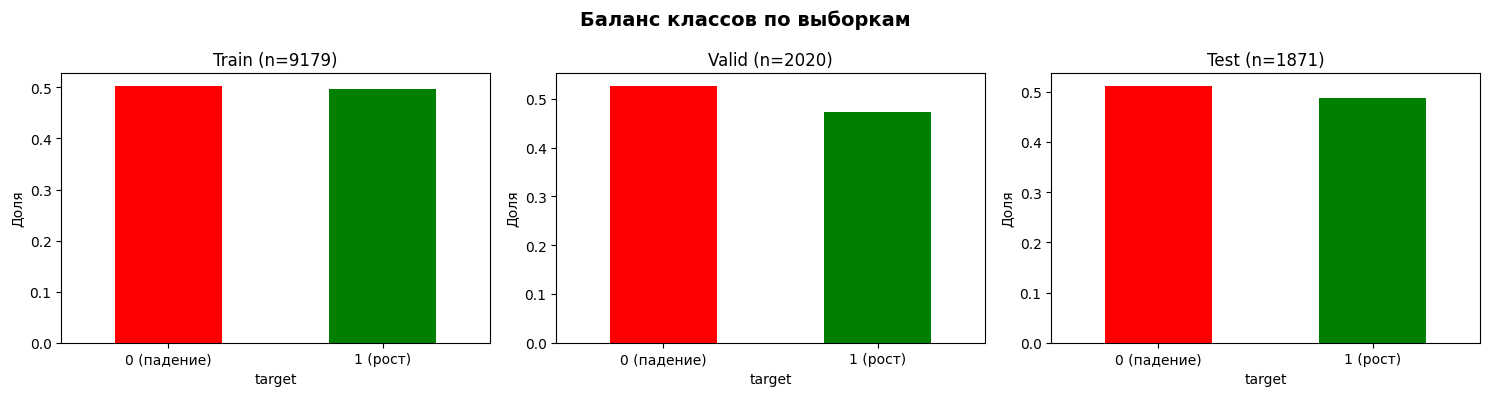

In [111]:
# График баланса классов по сплитам
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
splits = {'Train': y_train, 'Valid': y_valid, 'Test': y_test}

for ax, (name, y) in zip(axes, splits.items()):
    y.value_counts(normalize=True).plot(kind='bar', ax=ax, color=['red', 'green'])
    ax.set_title(f'{name} (n={len(y)})')
    ax.set_xlabel('target')
    ax.set_ylabel('Доля')
    ax.set_xticklabels(['0 (падение)', '1 (рост)'], rotation=0)

plt.suptitle('Баланс классов по выборкам', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [112]:
print(train.index.max(), valid.index.min())
print(valid.index.max(), test.index.min())

2045-12-29 00:00:00 2046-01-01 00:00:00
2053-12-31 00:00:00 2054-01-01 00:00:00


- проверка отсутствия утечек на train/valid/test

In [113]:
print("Train target mean:", y_train.mean().round(4))
print("Valid target mean:", y_valid.mean().round(4))
print("Test target mean:", y_test.mean().round(4))

Train target mean: 0.5033
Valid target mean: 0.4733
Test target mean: 0.512


- Проверка Data Leakage через корреляцию признаков с target на train/valid/test

In [114]:
# Проверка утечки данных через корреляции на train
train_corr = train[final_features + ['target']].corr()['target'].sort_values(ascending=False)
print(train_corr)

target                  1.000000
rsi_lag1                0.182242
rsi                     0.181416
rsi_overbought          0.111436
upper_shadow            0.086245
macd_cross_down         0.016495
rolling_std_5           0.014667
high_low_ratio          0.010431
day_of_week             0.009319
rolling_std_10          0.007470
dist_to_low_5           0.004751
sentiment_ma_5          0.001300
body                   -0.000518
volatility_sentiment   -0.001325
quarter                -0.008126
dist_to_high_5         -0.008564
volume_change          -0.008628
month                  -0.008653
sentiment_change       -0.009329
macd_cross_up          -0.023733
macd_hist              -0.027660
lower_shadow           -0.085078
rsi_oversold           -0.106898
close_position         -0.177629
Name: target, dtype: float64


In [115]:
# Проверка утечки данных через корреляции на valid
valid_corr = valid[final_features + ['target']].corr()['target'].sort_values(ascending=False)
print(valid_corr)

target                  1.000000
rsi                     0.211924
rsi_lag1                0.207599
rsi_overbought          0.117270
upper_shadow            0.072652
day_of_week             0.042050
high_low_ratio          0.025622
sentiment_ma_5          0.021004
body                    0.009907
month                   0.005904
quarter                 0.005160
volume_change           0.004680
macd_cross_down         0.004033
volatility_sentiment   -0.001278
macd_hist              -0.009711
sentiment_change       -0.012844
dist_to_low_5          -0.030374
dist_to_high_5         -0.035893
rolling_std_5          -0.038521
rolling_std_10         -0.053365
macd_cross_up          -0.056577
lower_shadow           -0.096417
rsi_oversold           -0.111116
close_position         -0.204891
Name: target, dtype: float64


In [116]:
# Проверка утечки данных через корреляции на test
test_corr = test[final_features + ['target']].corr()['target'].sort_values(ascending=False)
print(test_corr)

target                  1.000000
rsi_lag1                0.232273
rsi                     0.214470
rsi_overbought          0.141880
volatility_sentiment    0.045512
upper_shadow            0.042610
day_of_week             0.031371
sentiment_change        0.030084
month                   0.022201
quarter                 0.021797
sentiment_ma_5          0.015869
dist_to_high_5          0.015459
volume_change          -0.000168
macd_hist              -0.008114
body                   -0.009452
macd_cross_down        -0.015493
macd_cross_up          -0.015543
dist_to_low_5          -0.026944
high_low_ratio         -0.030699
rolling_std_5          -0.031140
rolling_std_10         -0.034738
lower_shadow           -0.077077
rsi_oversold           -0.112780
close_position         -0.141026
Name: target, dtype: float64


In [117]:
# Проверка стабильности топ-признаков по разным выборкам
top_train = set(train_corr.drop('target').abs().sort_values(ascending=False).head(5).index)
top_valid = set(valid_corr.drop('target').abs().sort_values(ascending=False).head(5).index)

print("Топ-5 признаков по абсолютной корреляции с target:")
print(f"Train: {top_train}")
print(f"Valid: {top_valid}")
print(f"Пересечение: {top_train & top_valid}")

Топ-5 признаков по абсолютной корреляции с target:
Train: {'close_position', 'rsi', 'rsi_lag1', 'rsi_oversold', 'rsi_overbought'}
Valid: {'close_position', 'rsi', 'rsi_lag1', 'rsi_oversold', 'rsi_overbought'}
Пересечение: {'close_position', 'rsi', 'rsi_lag1', 'rsi_oversold', 'rsi_overbought'}


### 4.6. Определение признаков для разных моделей <a class="anchor" id="ch5_4_6"></a>

In [118]:
# 1. ОПРЕДЕЛЯЕМ ПРИЗНАКИ ДЛЯ РАЗНЫХ МОДЕЛЕЙ

# Базовый набор (для XGBoost, RandomForest, LightGBM)
features_trees = [
    # Сильные признаки
    "rsi", "rsi_lag1", "rsi_overbought", "rsi_oversold",
    "close_position", "upper_shadow", "lower_shadow",
    
    # Волатильность    
    "rolling_std_5", "rolling_std_10", "high_low_ratio",
    
    # MACD‑derived   
    "macd_cross_up", "macd_cross_down", "macd_hist",
    
    # Sentiment   
    "sentiment_ma_5", "sentiment_change", "volatility_sentiment",
    
    # Календарные     
    "day_of_week", "month", "quarter",
    
    # Дополнительно (для бустинга)    
    "dist_to_high_5", "dist_to_low_5", "volume_change",
    "body"
]

# Набор для линейных моделей (Logistic Regression)
# - Убираем "quarter", rsi_lag1, rolling_std_10
features_lin_base  = [
    # Сильные признаки
    "rsi",  "rsi_overbought", "rsi_oversold",
    "close_position", "upper_shadow", "lower_shadow",
    
    # Волатильность    
    "rolling_std_5", "high_low_ratio",
    
    # MACD‑derived   
    "macd_cross_up", "macd_cross_down", "macd_hist",
    
    # Sentiment   
    "sentiment_ma_5", "sentiment_change", "volatility_sentiment",
    
    # Календарные     
    "day_of_week", "month",
    
    # Дополнительно (для бустинга)    
    "dist_to_high_5", "dist_to_low_5", "volume_change",
    "body"
]

In [119]:
# 2. СОЗДАНИЕ ВЫБОРОК ДЛЯ ДЕРЕВЬЕВ
X_train_trees = X_train[features_trees]
X_valid_trees = X_valid[features_trees]
X_test_trees  = X_test[features_trees]

In [120]:
X_train_trees.shape

(9179, 23)

In [121]:
# 3. ПОДГОТОВКА ДАННЫХ ДЛЯ LOGREG (OHE + Мультиколлинеарность)

def prepare_lin_data(df_part, base_features):
    # Разделяем признаки на числовые и те, что пойдут в OHE
    cat_cols = ['day_of_week', 'month']
    num_cols = [col for col in base_features if col not in cat_cols]
    
    # Берем числовые признаки
    df_num = df_part[num_cols].copy()
    
    # Преобразуем категориальные признаки в OHE
    # Используем astype(str), чтобы get_dummies воспринял их как категории
    df_cat = pd.get_dummies(df_part[cat_cols].astype(str), drop_first=True)
    
    # Объединяем
    return pd.concat([df_num, df_cat], axis=1)

X_train_lin = prepare_lin_data(X_train, features_lin_base)
X_valid_lin = prepare_lin_data(X_valid, features_lin_base)
X_test_lin  = prepare_lin_data(X_test, features_lin_base)

# Выравниваем колонки (чтобы наборы признаков были идентичны во всех выборках)
X_valid_lin = X_valid_lin.reindex(columns=X_train_lin.columns, fill_value=0)
X_test_lin  = X_test_lin.reindex(columns=X_train_lin.columns, fill_value=0)

In [122]:
X_train_lin.shape

(9179, 33)

### 4.7. Масштабирование и кодирование <a class="anchor" id="ch5_4_7"></a>

In [123]:
# 4.6 МАСШТАБИРОВАНИЕ (БЕЗ УТЕЧКИ ДАННЫХ)

# 1. Создаем объект скалера
# 2. Обучаем скалер ТОЛЬКО на тренировочных данных (fit)
# На этом этапе скалер запоминает медианы и размахи только из X_train
# 3. Трансформируем (transform) все выборки с помощью параметров из X_train


# Для деревьев (используем исходные X_train_trees и т.д.)
scaler_trees = RobustScaler().fit(X_train_trees)
X_train_tr = pd.DataFrame(scaler_trees.transform(X_train_trees), index=X_train.index, columns=X_train_trees.columns)
X_valid_tr = pd.DataFrame(scaler_trees.transform(X_valid_trees), index=X_valid.index, columns=X_valid_trees.columns)
X_test_tr  = pd.DataFrame(scaler_trees.transform(X_test_trees), index=X_test.index, columns=X_test_trees.columns)

# Для логистической регрессии (используем X_train_lin с уже примененным OHE)
scaler_lin = RobustScaler().fit(X_train_lin)
X_train_ln = pd.DataFrame(scaler_lin.transform(X_train_lin), index=X_train.index, columns=X_train_lin.columns)
X_valid_ln = pd.DataFrame(scaler_lin.transform(X_valid_lin), index=X_valid.index, columns=X_valid_lin.columns)
X_test_ln  = pd.DataFrame(scaler_lin.transform(X_test_lin), index=X_test.index, columns=X_train_lin.columns)

Примечание: Масштабирование выполнено для совместимости со всеми моделями.
- Для деревьев решений, Random Forest и градиентного бустинга масштабирование не влияет на качество, но и не вредит.
- Для Logistic Regression масштабирование критически важно.

In [124]:
X_train_tr.shape[1]==X_valid_tr.shape[1]==X_test_tr.shape[1]

True

In [125]:
X_train_ln.shape[1]==X_valid_ln.shape[1]==X_test_ln.shape[1]

True

In [126]:
X_train_ln.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
rsi,9179.0,-0.008,0.729,-2.294,-0.511,0.0,0.489,2.300
rsi_overbought,9179.0,0.092,0.289,0.000,0.000,0.0,0.000,1.000
rsi_oversold,9179.0,0.100,0.300,0.000,0.000,0.0,0.000,1.000
close_position,9179.0,0.001,0.760,-2.385,-0.501,0.0,0.499,2.375
upper_shadow,9179.0,0.000,0.692,-1.550,-0.526,0.0,0.474,2.072
lower_shadow,9179.0,0.000,0.691,-1.532,-0.522,0.0,0.478,2.036
rolling_std_5,9179.0,1.147,4.065,-0.609,-0.276,0.0,0.724,68.288
high_low_ratio,9179.0,15.458,1381.726,-119.829,-0.272,0.0,0.728,132375.765
macd_cross_up,9179.0,0.044,0.205,0.000,0.000,0.0,0.000,1.000
macd_cross_down,9179.0,0.045,0.207,0.000,0.000,0.0,0.000,1.000


In [127]:
X_valid_ln.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
rsi,2020.0,-0.082,0.699,-2.423,-0.539,-0.110,0.370,1.960
rsi_overbought,2020.0,0.074,0.262,0.000,0.000,0.000,0.000,1.000
rsi_oversold,2020.0,0.095,0.293,0.000,0.000,0.000,0.000,1.000
close_position,2020.0,0.040,0.763,-2.394,-0.471,0.058,0.546,2.256
upper_shadow,2020.0,-0.058,0.675,-1.550,-0.568,-0.063,0.412,1.997
lower_shadow,2020.0,0.018,0.690,-1.528,-0.487,-0.001,0.506,2.078
rolling_std_5,2020.0,2.145,3.990,-0.503,0.563,1.174,2.359,47.707
high_low_ratio,2020.0,-0.260,8.297,-265.631,-2.687,0.622,1.377,138.947
macd_cross_up,2020.0,0.044,0.204,0.000,0.000,0.000,0.000,1.000
macd_cross_down,2020.0,0.043,0.203,0.000,0.000,0.000,0.000,1.000


In [128]:
X_test_ln.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
rsi,1871.0,0.054,0.737,-2.062,-0.465,0.062,0.608,1.921
rsi_overbought,1871.0,0.115,0.320,0.000,0.000,0.000,0.000,1.000
rsi_oversold,1871.0,0.085,0.279,0.000,0.000,0.000,0.000,1.000
close_position,1871.0,0.006,0.757,-2.180,-0.506,0.010,0.521,2.466
upper_shadow,1871.0,-0.010,0.682,-1.501,-0.521,-0.018,0.449,2.050
lower_shadow,1871.0,-0.004,0.696,-1.487,-0.532,-0.024,0.463,2.008
rolling_std_5,1871.0,5.900,7.617,-0.275,1.565,3.416,7.283,86.503
high_low_ratio,1871.0,-3.776,100.872,-3279.164,-7.346,-3.411,1.387,2549.147
macd_cross_up,1871.0,0.045,0.207,0.000,0.000,0.000,0.000,1.000
macd_cross_down,1871.0,0.046,0.209,0.000,0.000,0.000,0.000,1.000


- Проверка, что после масштабирования нет NaN или inf

In [129]:
# Проверка масштабированных данных для деревьев
print("NaN в X_train_tr:", X_train_tr.isnull().sum().sum())
print("inf в X_train_tr:", np.isinf(X_train_tr).sum().sum())

# Проверка для логистической регрессии
print("NaN в X_train_lin:", X_train_lin.isnull().sum().sum())
print("inf в X_train_lin:", np.isinf(X_train_lin).sum().sum())

NaN в X_train_tr: 0
inf в X_train_tr: 0
NaN в X_train_lin: 0
inf в X_train_lin: 0


In [130]:
def check_columns_order(X_train, X_valid, X_test):
    cols_train = list(X_train.columns)
    cols_valid = list(X_valid.columns)
    cols_test  = list(X_test.columns)

    print("📘 Колонки в Train:", cols_train)
    print("📙 Колонки в Valid:", cols_valid)
    print("📗 Колонки в Test:",  cols_test)

    ok_train_valid = (cols_train == cols_valid)
    ok_train_test  = (cols_train == cols_test)

    if ok_train_valid and ok_train_test:
        print("\n✅ Все датафреймы имеют одинаковые названия и порядок колонок.")
    else:
        print("\n⚠️ Есть различия в названиях или порядке колонок:")

        if not ok_train_valid:
            print(" - Train и Valid отличаются")

        if not ok_train_test:
            print(" - Train и Test отличаются")

        # Дополнительно можно вывести различия
        print("\n🔍 Различия по наборам колонок:")
        print("Train - Valid:", set(cols_train) - set(cols_valid))
        print("Valid - Train:", set(cols_valid) - set(cols_train))
        print("Train - Test:",  set(cols_train) - set(cols_test))
        print("Test - Train:",  set(cols_test) - set(cols_train))

In [131]:
check_columns_order(X_train_tr, X_valid_tr, X_test_tr)

📘 Колонки в Train: ['rsi', 'rsi_lag1', 'rsi_overbought', 'rsi_oversold', 'close_position', 'upper_shadow', 'lower_shadow', 'rolling_std_5', 'rolling_std_10', 'high_low_ratio', 'macd_cross_up', 'macd_cross_down', 'macd_hist', 'sentiment_ma_5', 'sentiment_change', 'volatility_sentiment', 'day_of_week', 'month', 'quarter', 'dist_to_high_5', 'dist_to_low_5', 'volume_change', 'body']
📙 Колонки в Valid: ['rsi', 'rsi_lag1', 'rsi_overbought', 'rsi_oversold', 'close_position', 'upper_shadow', 'lower_shadow', 'rolling_std_5', 'rolling_std_10', 'high_low_ratio', 'macd_cross_up', 'macd_cross_down', 'macd_hist', 'sentiment_ma_5', 'sentiment_change', 'volatility_sentiment', 'day_of_week', 'month', 'quarter', 'dist_to_high_5', 'dist_to_low_5', 'volume_change', 'body']
📗 Колонки в Test: ['rsi', 'rsi_lag1', 'rsi_overbought', 'rsi_oversold', 'close_position', 'upper_shadow', 'lower_shadow', 'rolling_std_5', 'rolling_std_10', 'high_low_ratio', 'macd_cross_up', 'macd_cross_down', 'macd_hist', 'sentiment_m

In [132]:
check_columns_order(X_train_ln, X_valid_ln, X_test_ln)

📘 Колонки в Train: ['rsi', 'rsi_overbought', 'rsi_oversold', 'close_position', 'upper_shadow', 'lower_shadow', 'rolling_std_5', 'high_low_ratio', 'macd_cross_up', 'macd_cross_down', 'macd_hist', 'sentiment_ma_5', 'sentiment_change', 'volatility_sentiment', 'dist_to_high_5', 'dist_to_low_5', 'volume_change', 'body', 'day_of_week_1', 'day_of_week_2', 'day_of_week_3', 'day_of_week_4', 'month_10', 'month_11', 'month_12', 'month_2', 'month_3', 'month_4', 'month_5', 'month_6', 'month_7', 'month_8', 'month_9']
📙 Колонки в Valid: ['rsi', 'rsi_overbought', 'rsi_oversold', 'close_position', 'upper_shadow', 'lower_shadow', 'rolling_std_5', 'high_low_ratio', 'macd_cross_up', 'macd_cross_down', 'macd_hist', 'sentiment_ma_5', 'sentiment_change', 'volatility_sentiment', 'dist_to_high_5', 'dist_to_low_5', 'volume_change', 'body', 'day_of_week_1', 'day_of_week_2', 'day_of_week_3', 'day_of_week_4', 'month_10', 'month_11', 'month_12', 'month_2', 'month_3', 'month_4', 'month_5', 'month_6', 'month_7', 'mon

In [133]:
print("Train для Decision Tree/RandomForest/XGBoost/LightGBM:", X_train_tr.shape)
print("Valid для Decision Tree/RandomForest/XGBoost/LightGBM:", X_valid_tr.shape)
print("Test для Decision Tree/RandomForest/XGBoost/LightGBM",  X_test_tr.shape)

Train для Decision Tree/RandomForest/XGBoost/LightGBM: (9179, 23)
Valid для Decision Tree/RandomForest/XGBoost/LightGBM: (2020, 23)
Test для Decision Tree/RandomForest/XGBoost/LightGBM (1871, 23)


In [134]:
print("Train для LogReg:", X_train_ln.shape)
print("Valid для LogReg:", X_valid_ln.shape)
print("Test для LogReg",  X_test_ln.shape)

Train для LogReg: (9179, 33)
Valid для LogReg: (2020, 33)
Test для LogReg (1871, 33)


<div style="border:solid green 4px; padding: 5px">

__Выводы по шагу 4:__

Шаг 4 был направлен на формирование корректного, чистого и информативного набора данных для обучения моделей. Он включал выбор признаков, проверку мультиколлинеарности, устранение пропусков, проверку утечек данных, формирование выборок и подготовку данных для разных типов моделей. Ниже — детальный анализ каждого этапа.    
    
    
__1. Отбор признаков__
- На основе EDA и количественных оценок (phik-корреляции, мультиколлинеарность) сформированы два набора признаков:
  - Расширенный (23 признака) – для деревьев и ансамблей (Random Forest, XGBoost, LightGBM).
  - Компактный (после One-Hot Encoding – 33 признака) – для логистической регрессии (с учётом устранения мультиколлинеарности).
- Исключены сырые ценовые признаки (open, high, low, close) – они нестационарны, сильно коррелированы и имеют нулевую phik-корреляцию с target.
- Также удалены неинформативные признаки: большинство скользящих средних цены, объёмные признаки (volume, vol_ma_5, vol_ratio_5 и др.), лаги доходностей (return_lag1, return_lag2) – их phik ≈ 0.
- Оставлены только признаки с доказанной предсказательной силой:
  - RSI (и его лаг, бинарные сигналы перекупленности/перепроданности) – сильнейшие предикторы.
  - close_position – положение цены внутри дневного диапазона.
  - Тени свечей (upper_shadow, lower_shadow).
  - Волатильность (rolling_std_5, high_low_ratio).
  - Производные MACD (пересечения, гистограмма).
  - Сглаженный сентимент (sentiment_ma_5), изменение сентимента.
  - Календарные признаки (day_of_week, month, quarter).
  - Дополнительные: dist_to_high_5, dist_to_low_5, volume_change, body.    
    
__2. Мультиколлинеарность__
- В финальном расширенном наборе обнаружено всего 3 пары с корреляцией >0.7:
  - rsi – rsi_lag1 (0.91) – ожидаемо, для деревьев не критично.
  - rolling_std_5 – rolling_std_10 (0.89) – допустимо.
  - month – quarter (0.97) – для линейных моделей quarter исключён, для деревьев – допустимо.
- Для логистической регрессии дополнительно удалены rsi_lag1, rolling_std_10, quarter, что снизило мультиколлинеарность до приемлемого уровня.    
    
__3. Look‑Ahead Bias и пропуски__
- Все признаки используют только прошлые данные (shift, rolling). Проверка на inf показала отсутствие бесконечных значений.
- После удаления строк с NaN (первые ~600 строк из-за лагов и скользящих окон) итоговый датасет составил 13070 строк (из 13647). Потеря данных минимальна и неизбежна при корректном построении лаговых признаков.    
    
__4. Проверка утечки данных (Data Leakage)__
- Проверка по именам признаков, логике построения и корреляции с target на train/valid/test не выявила признаков утечки:
  - Нет признаков, содержащих target или его производные.
  - Нет признаков, использующих будущие значения (например, shift(-1) в признаках).
- Топ-5 признаков по абсолютной корреляции с target стабильны на всех выборках: rsi_lag1, rsi, close_position, rsi_overbought, rsi_oversold. Это подтверждает устойчивость отобранных признаков и отсутствие случайных связей.    

__5. Mutual Information__
- MI показала:
  - rsi_lag1 — самый информативный признак
  - rsi, close_position — тоже значимые
  - MACD и sentiment — слабые, но ненулевые
  - rolling_std_5/10, high_low_ratio — MI = 0, но полезны для деревьев
- MI подтверждает выводы EDA.    
    
__6. Разделение на train/valid/test с учётом времени__
- Разделение выполнено строго по хронологии (без перемешивания), что имитирует реальный сценарий торговли:
  - Train: 2010–2045 (9179 наблюдений)
  - Valid: 2046–2053 (2020 наблюдений)
  - Test: 2054–2062 (1871 наблюдение)
- train содержит длинный исторический период → модель учится на разных фазах рынка
- valid — среднесрочный период для подбора гиперпараметров
- test — самый свежий период, полностью неиспользованный при обучении    
- Границы выборок не пересекаются, что исключает «заглядывание в будущее».
- Баланс классов во всех выборках близок к 50/50 (средние target: train 0.503, valid 0.473, test 0.512), поэтому метрики можно использовать без корректировки на дисбаланс.    

__7. Масштабирование и кодирование__
- Для деревьев и ансамблей масштабирование не требуется, но выполнено с RobustScaler (устойчив к выбросам) – это не вредит и унифицирует пайплайн.
- Для логистической регрессии масштабирование критически важно; использован RobustScaler (fit на train, transform на valid/test).
- Категориальные признаки day_of_week и month преобразованы в One‑Hot Encoding (с удалением первого уровня) только для линейной модели. Для деревьев они оставлены в порядковом виде – деревья инвариантны к такому кодированию.
- После масштабирования проверено отсутствие NaN и inf – все данные чисты.    
    
__8. Финальная готовность данных__
- Подготовлены два набора данных:
  - Для деревьев и бустинга: X_train_tr, X_valid_tr, X_test_tr (23 признака, порядковые календарные признаки, без OHE).
  - Для логистической регрессии: X_train_ln, X_valid_ln, X_test_ln (33 признака после OHE, без мультиколлинеарных признаков).

Во всех выборках одинаковый порядок колонок, что гарантирует корректное применение моделей.   
    
</div>

<div class="alert alert-info">
  <b> * <a href="#ch5">к содержанию</a> </b> 
</div>

---

## Шаг 5: Моделирование <a class="anchor" id="ch5_5"></a>

In [135]:
data = {
    "train_abs": y_train.value_counts(),
    "train_norm": y_train.value_counts(normalize=True).round(3),
    "valid_abs": y_valid.value_counts(),
    "valid_norm": y_valid.value_counts(normalize=True).round(3),
    "test_abs": y_test.value_counts(),
    "test_norm": y_test.value_counts(normalize=True).round(3),
}

df = pd.DataFrame(data)

# Добавим строки с общим количеством объектов
totals = pd.DataFrame({
    "train_abs": [len(y_train)],
    "train_norm": [1.0],
    "valid_abs": [len(y_valid)],
    "valid_norm": [1.0],
    "test_abs": [len(y_test)],
    "test_norm": [1.0],
}, index=["TOTAL"])

df = pd.concat([df, totals])

df

,train_abs,train_norm,valid_abs,valid_norm,test_abs,test_norm
0,4559,0.497,1064,0.527,913,0.488
1,4620,0.503,956,0.473,958,0.512
TOTAL,9179,1.000,2020,1.000,1871,1.000


- для линейных моделей DummyClassifier и LogReg: X_train_ln и X_valid_ln
- для ансамблей и деревьев Decision Tree/Random Forest/XGBoost/LightGBM: X_train_tr и X_valid_tr

__TimeSeriesSplit для временных рядов__
- Необходимо учитывать TimeSeriesSplit, чтобы модели не “заглядывали в будущее” при кросс-валидации.

In [136]:
tscv = TimeSeriesSplit(n_splits=5)

__Метрики__

In [137]:
scoring = {
    "f1": make_scorer(f1_score),
    "precision": make_scorer(precision_score),
    "recall": make_scorer(recall_score)
}

### 5.1. Бейзлайн: DummyClassifier <a class="anchor" id="ch5_5_1"></a>

Три стратегии:
- most_frequent - предсказывает самый частый класс из train
- stratified - предсказывает случайно, но с той же вероятностью, что и в train
- naive financial baseline — предсказывает, что завтра = сегодня (финансовый наивный прогноз)

In [138]:
dummy_mf = DummyClassifier(strategy="most_frequent")
dummy_mf.fit(X_train_tr, y_train)

y_pred = dummy_mf.predict(X_valid_tr)
print("DummyClassifier — most_frequent")
print(classification_report(y_valid, y_pred, digits=3,zero_division=0))

DummyClassifier — most_frequent
              precision    recall  f1-score   support

           0      0.000     0.000     0.000      1064
           1      0.473     1.000     0.642       956

    accuracy                          0.473      2020
   macro avg      0.237     0.500     0.321      2020
weighted avg      0.224     0.473     0.304      2020



In [139]:
dummy_str = DummyClassifier(strategy="stratified", random_state=42)
dummy_str.fit(X_train_tr, y_train)

y_pred = dummy_str.predict(X_valid_tr)
print("DummyClassifier — stratified")
print(classification_report(y_valid, y_pred, digits=3))

DummyClassifier — stratified
              precision    recall  f1-score   support

           0      0.530     0.505     0.517      1064
           1      0.477     0.502     0.489       956

    accuracy                          0.503      2020
   macro avg      0.503     0.503     0.503      2020
weighted avg      0.505     0.503     0.504      2020



In [140]:
y_pred_naive = np.roll(y_valid.values, 1)
y_pred_naive[0] = y_train.iloc[-1]   # первое значение = последнее из train

print("Naive baseline (predict yesterday movement)")
print(classification_report(y_valid, y_pred_naive, digits=3))

Naive baseline (predict yesterday movement)
              precision    recall  f1-score   support

           0      0.517     0.517     0.517      1064
           1      0.463     0.463     0.463       956

    accuracy                          0.492      2020
   macro avg      0.490     0.490     0.490      2020
weighted avg      0.492     0.492     0.492      2020



### 5.2. Логистическая регрессия LogReg <a class="anchor" id="ch5_5_2"></a>

- Обучение с GridSearchCV

In [141]:
start = time.time()

lr = LogisticRegression(
    solver='lbfgs',
    n_jobs=-1,
    random_state=42
)

lr_params = {
    "C": [0.01, 0.05, 0.1, 0.5, 1, 2, 5],
    "class_weight": [None, "balanced"],
    "max_iter": [100, 200, 300, 500]
}

lr_gs = GridSearchCV(
    lr,
    lr_params,
    scoring=scoring,   # f1, precision, recall
    refit='f1',        # ← выбираем лучшую модель по F1
    cv=tscv,           # ← TimeSeriesSplit
    n_jobs=-1,
    verbose=1
)

lr_gs.fit(X_train_ln, y_train)

print("\nЛучшие параметры LogisticRegression:", lr_gs.best_params_)
print("CV F1:", lr_gs.best_score_)
print("CV Precision:", lr_gs.cv_results_['mean_test_precision'][lr_gs.best_index_])
print("CV Recall:", lr_gs.cv_results_['mean_test_recall'][lr_gs.best_index_])

# 👉 Вывод лучшей модели
print("\nЛучшая модель:")
print(lr_gs.best_estimator_)

end = time.time()
elapsed = end - start
print(f"\nВремя выполнения: {elapsed:.2f} секунд ({elapsed/60:.2f} минут)")

Fitting 5 folds for each of 56 candidates, totalling 280 fits

Лучшие параметры LogisticRegression: {'C': 0.05, 'class_weight': None, 'max_iter': 100}
CV F1: 0.6142117636631454
CV Precision: 0.6173549983210622
CV Recall: 0.6120625759609316

Лучшая модель:
LogisticRegression(C=0.05, n_jobs=-1, random_state=42)

Время выполнения: 10.53 секунд (0.18 минут)


- Оценка на валидации

In [142]:
y_pred = lr_gs.predict(X_valid_ln)

print("Logistic Regression — VALID")
print(classification_report(y_valid, y_pred, digits=3))

Logistic Regression — VALID
              precision    recall  f1-score   support

           0      0.669     0.661     0.665      1064
           1      0.627     0.636     0.632       956

    accuracy                          0.649      2020
   macro avg      0.648     0.648     0.648      2020
weighted avg      0.649     0.649     0.649      2020



- Коэффициенты модели

In [143]:
best_lr = lr_gs.best_estimator_

coef_df = pd.DataFrame({
    "feature": X_train_ln.columns,
    "coef": best_lr.coef_[0]
}).sort_values("coef", ascending=False)

coef_df.head(15)

,feature,coef
0,rsi,0.790382
1,rsi_overbought,0.184702
5,lower_shadow,0.117966
9,macd_cross_down,0.073363
31,month_8,0.056491
19,day_of_week_2,0.051099
21,day_of_week_4,0.044872
23,month_11,0.033862
26,month_3,0.031615
18,day_of_week_1,0.023678


### 5.3. Модели деревьев и ансамблей <a class="anchor" id="ch5_5_3"></a>

#### __Decision Tree__

In [144]:
start = time.time()

dt = DecisionTreeClassifier(
    random_state=42
)

dt_params = {
    "max_depth": [5, 6, 7],
    "min_samples_split": [8, 10, 12, 15],
    "min_samples_leaf": [1, 2, 4, 6],
    "criterion": ["gini", "entropy", "log_loss"],
    "class_weight": [None, "balanced"]
}

dt_gs = GridSearchCV(
    dt,
    dt_params,
    scoring=scoring,   # f1, precision, recall
    refit='f1',        # ← выбираем лучшую модель по F1
    cv=tscv,           # ← TimeSeriesSplit
    n_jobs=-1,
    verbose=1
)

dt_gs.fit(X_train_tr, y_train)

print("\nЛучшие параметры DecisionTree:", dt_gs.best_params_)
print("CV F1:", dt_gs.best_score_)
print("CV Precision:", dt_gs.cv_results_['mean_test_precision'][dt_gs.best_index_])
print("CV Recall:", dt_gs.cv_results_['mean_test_recall'][dt_gs.best_index_])

# 👉 вывод лучшей модели
print("\nЛучшая модель:")
print(dt_gs.best_estimator_)

end = time.time()
elapsed = end - start
print(f"\nВремя выполнения: {elapsed:.2f} секунд ({elapsed/60:.2f} минут)")

Fitting 5 folds for each of 288 candidates, totalling 1440 fits

Лучшие параметры DecisionTree: {'class_weight': None, 'criterion': 'gini', 'max_depth': 6, 'min_samples_leaf': 1, 'min_samples_split': 10}
CV F1: 0.5797006843277601
CV Precision: 0.5850493887599165
CV Recall: 0.5809640659440847

Лучшая модель:
DecisionTreeClassifier(max_depth=6, min_samples_split=10, random_state=42)

Время выполнения: 28.73 секунд (0.48 минут)


- Оценка на валидации

In [145]:
y_pred = dt_gs.predict(X_valid_tr)

print("Decision Tree — VALID")
print(classification_report(y_valid, y_pred, digits=3))

Decision Tree — VALID
              precision    recall  f1-score   support

           0      0.656     0.628     0.642      1064
           1      0.605     0.634     0.619       956

    accuracy                          0.631      2020
   macro avg      0.630     0.631     0.630      2020
weighted avg      0.632     0.631     0.631      2020



#### __Random Forest__

- Обучение с GridSearchCV

In [146]:
start = time.time()

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rf_params = {
    "n_estimators": [1000],
    "max_depth": [7, 9],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": [5, 10],
    "bootstrap": [True],
    "class_weight": ["balanced"]
}

rf_gs = GridSearchCV(
    rf,
    rf_params,
    scoring=scoring,   # f1, precision, recall
    refit='f1',        # ← выбираем лучшую модель по F1
    cv=tscv,           # ← TimeSeriesSplit
    n_jobs=-1,
    verbose=1
)

rf_gs.fit(X_train_tr, y_train)

print("\nЛучшие параметры RandomForest:", rf_gs.best_params_)
print("CV F1:", rf_gs.best_score_)
print("CV Precision:", rf_gs.cv_results_['mean_test_precision'][rf_gs.best_index_])
print("CV Recall:", rf_gs.cv_results_['mean_test_recall'][rf_gs.best_index_])

# 👉 вывод лучшей модели
print("\nЛучшая модель:")
print(rf_gs.best_estimator_)

end = time.time()
elapsed = end - start
print(f"\nВремя выполнения: {elapsed:.2f} секунд ({elapsed/60:.2f} минут)")

Fitting 5 folds for each of 16 candidates, totalling 80 fits

Лучшие параметры RandomForest: {'bootstrap': True, 'class_weight': 'balanced', 'max_depth': 9, 'max_features': 5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 1000}
CV F1: 0.6209661660619721
CV Precision: 0.634486672761923
CV Recall: 0.6103379360344839

Лучшая модель:
RandomForestClassifier(class_weight='balanced', max_depth=9, max_features=5,
                       min_samples_leaf=2, n_estimators=1000, n_jobs=-1,
                       random_state=42)

Время выполнения: 307.93 секунд (5.13 минут)


- Оценка на валидации

In [147]:
y_pred = rf_gs.predict(X_valid_tr)

print("Random Forest — VALID")
print(classification_report(y_valid, y_pred, digits=3))

Random Forest — VALID
              precision    recall  f1-score   support

           0      0.671     0.671     0.671      1064
           1      0.634     0.634     0.634       956

    accuracy                          0.653      2020
   macro avg      0.652     0.652     0.652      2020
weighted avg      0.653     0.653     0.653      2020



#### XGBoost

- Обучение с GridSearchCV

In [148]:
start = time.time()

xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    tree_method='hist'
)

xgb_params = {
    "n_estimators": [300, 500, 700],
    "max_depth": [4, 5],
    "learning_rate": [0.1, 0.2],
    "subsample": [1],
    "colsample_bytree": [ 0.8, 1.0],
    "gamma": [1],
    "reg_alpha": [0.1, 0.5, 1],
    "reg_lambda": [1, 3],
    "min_child_weight": [1, 3]
}

# веса классов
sample_weights = compute_sample_weight('balanced', y_train)

xgb_gs = GridSearchCV(
    xgb,
    xgb_params,
    scoring=scoring,   # f1, precision, recall
    refit='f1',        # ← выбираем лучшую модель по F1
    cv=tscv,           # ← TimeSeriesSplit
    n_jobs=-1,
    verbose=1
)

xgb_gs.fit(X_train_tr, y_train, sample_weight=sample_weights)

print("\nЛучшие параметры XGBoost:", xgb_gs.best_params_)
print("CV F1:", xgb_gs.best_score_)
print("CV Precision:", xgb_gs.cv_results_['mean_test_precision'][xgb_gs.best_index_])
print("CV Recall:", xgb_gs.cv_results_['mean_test_recall'][xgb_gs.best_index_])

# 👉 вывод лучшей модели
print("\nЛучшая модель:")
print(xgb_gs.best_estimator_)

end = time.time()
elapsed = end - start
print(f"\nВремя выполнения: {elapsed:.2f} секунд ({elapsed/60:.2f} минут)")

Fitting 5 folds for each of 288 candidates, totalling 1440 fits

Лучшие параметры XGBoost: {'colsample_bytree': 0.8, 'gamma': 1, 'learning_rate': 0.1, 'max_depth': 4, 'min_child_weight': 3, 'n_estimators': 300, 'reg_alpha': 0.5, 'reg_lambda': 1, 'subsample': 1}
CV F1: 0.6248363314948534
CV Precision: 0.6249989023413061
CV Recall: 0.6273733949881889

Лучшая модель:
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=1, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=3, missing=nan,
              monotone_constraints=No

- Оценка на валидации

In [149]:
y_pred = xgb_gs.predict(X_valid_tr)

print("XGBoost — VALID")
print(classification_report(y_valid, y_pred, digits=3))

XGBoost — VALID
              precision    recall  f1-score   support

           0      0.668     0.661     0.664      1064
           1      0.627     0.634     0.630       956

    accuracy                          0.648      2020
   macro avg      0.647     0.647     0.647      2020
weighted avg      0.648     0.648     0.648      2020



#### LightGBM

- Обучение с GridSearchCV

In [150]:
start = time.time()

lgbm = lgb.LGBMClassifier(
    objective='binary',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1,
    force_col_wise=True
)

lgbm_params = {
    "max_depth": [3, 5, 7],
    "learning_rate": [0.03, 0.05, 0.1],
    "n_estimators": [100, 200],
    "num_leaves": [5, 15],
    "feature_fraction": [0.7],
    "bagging_fraction": [0.7],
    "bagging_freq": [3]
}


lgbm_gs = GridSearchCV(
    estimator=lgbm,
    param_grid=lgbm_params,
    scoring=scoring,   # f1, precision, recall
    refit='f1',        # ← выбираем лучшую модель по F1
    cv=tscv,           # ← TimeSeriesSplit\
    n_jobs=-1,
    verbose=1
)

lgbm_gs.fit(X_train_tr, y_train)

print("\nЛучшие параметры LightGBM:", lgbm_gs.best_params_)
print("CV F1:", lgbm_gs.best_score_)
print("CV Precision:", lgbm_gs.cv_results_['mean_test_precision'][lgbm_gs.best_index_])
print("CV Recall:", lgbm_gs.cv_results_['mean_test_recall'][lgbm_gs.best_index_])

# 👉 вывод лучшей модели
print("\nЛучшая модель:")
print(lgbm_gs.best_estimator_)

end = time.time()
elapsed = end - start
print(f"\nВремя выполнения: {elapsed:.2f} секунд ({elapsed/60:.2f} минут)")

Fitting 5 folds for each of 36 candidates, totalling 180 fits

Лучшие параметры LightGBM: {'bagging_fraction': 0.7, 'bagging_freq': 3, 'feature_fraction': 0.7, 'learning_rate': 0.03, 'max_depth': 5, 'n_estimators': 200, 'num_leaves': 15}
CV F1: 0.619886569613556
CV Precision: 0.6297054248349669
CV Recall: 0.6134922642369502

Лучшая модель:
LGBMClassifier(bagging_fraction=0.7, bagging_freq=3, class_weight='balanced',
               feature_fraction=0.7, force_col_wise=True, learning_rate=0.03,
               max_depth=5, n_estimators=200, n_jobs=-1, num_leaves=15,
               objective='binary', random_state=42, verbose=-1)

Время выполнения: 46.08 секунд (0.77 минут)


- Оценка на валидации

In [151]:
y_pred = lgbm_gs.predict(X_valid_tr)

print("LightGBM — VALID")
print(classification_report(y_valid, y_pred, digits=3))

LightGBM — VALID
              precision    recall  f1-score   support

           0      0.664     0.680     0.672      1064
           1      0.634     0.616     0.625       956

    accuracy                          0.650      2020
   macro avg      0.649     0.648     0.648      2020
weighted avg      0.650     0.650     0.650      2020



### 5.4. (Опционально) Deep Learning: LSTM <a class="anchor" id="ch5_5_4"></a>

In [152]:
# -----------------------------
# 1. ПАРАМЕТРЫ
# -----------------------------
seq_len = 20
epochs = 50
batch_size = 32
patience=5

In [153]:
# -----------------------------
# 2. МАСШТАБИРОВАНИЕ (MinMax)
# -----------------------------
scaler = MinMaxScaler()

X_lstm = scaler.fit_transform(df_model[final_features])   
y_lstm = df_model["target"].values                        

In [154]:
# -----------------------------
# 3. ФУНКЦИЯ ДЛЯ СОЗДАНИЯ ОКОН
# -----------------------------
def create_sequences(X, y, seq_len):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_len - 1):
        X_seq.append(X[i:i+seq_len])
        y_seq.append(y[i+seq_len])
    return np.array(X_seq), np.array(y_seq)

X_seq, y_seq = create_sequences(X_lstm, y_lstm, seq_len)

In [155]:
# -----------------------------
# 4. МОДЕЛЬ
# -----------------------------
def build_lstm():
    model = Sequential([
        Input(shape=(seq_len, X_seq.shape[2])),
        LSTM(32, return_sequences=False),
        Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy")
    return model

68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step

=== CV1: TimeSeriesSplit ===
CV1 F1: 0.7369953189082339
CV1 Precision: 0.7182754186559303
CV1 Recall: 0.7570150471411401
Время выполнения CV1: 609.82 сек (10.16 мин)


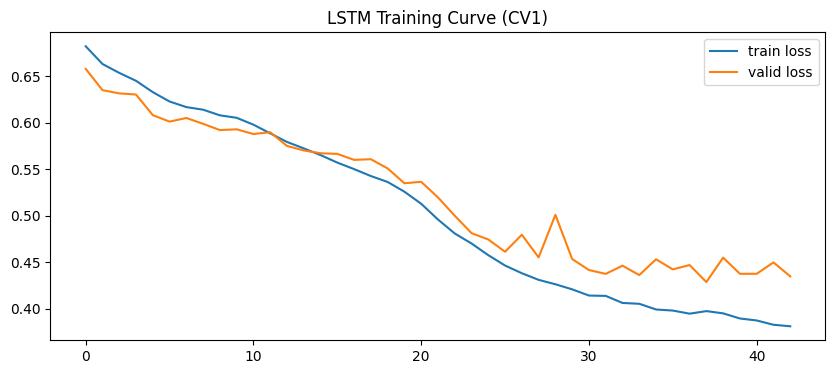

In [156]:
# ============================================================
# 5. CV №1 — TimeSeriesSplit
# ============================================================

cv1_f1, cv1_prec, cv1_rec = [], [], []

start = time.time()

for train_idx, valid_idx in tscv.split(X_seq):
    X_tr, X_va = X_seq[train_idx], X_seq[valid_idx]
    y_tr, y_va = y_seq[train_idx], y_seq[valid_idx]

    model = build_lstm()
    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_va, y_va),
        epochs=epochs,
        batch_size=batch_size,
        verbose=0,
        callbacks=[EarlyStopping(patience=patience, restore_best_weights=True)]
    )

    preds = (model.predict(X_va) > 0.5).astype(int)

    cv1_f1.append(f1_score(y_va, preds))
    cv1_prec.append(precision_score(y_va, preds))
    cv1_rec.append(recall_score(y_va, preds))

end = time.time()

print("\n=== CV1: TimeSeriesSplit ===")
print("CV1 F1:", np.mean(cv1_f1))
print("CV1 Precision:", np.mean(cv1_prec))
print("CV1 Recall:", np.mean(cv1_rec))
print(f"Время выполнения CV1: {end-start:.2f} сек ({(end-start)/60:.2f} мин)")

# -----------------------------
# График обучения последней модели
# -----------------------------
plt.figure(figsize=(10,4))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="valid loss")
plt.title("LSTM Training Curve (CV1)")
plt.legend()
plt.show()

102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

Время выполнения CV2: 401.68 сек (6.69 мин)

=== CV2: Walk‑Forward ===
CV2 F1: 0.7127039950114685
CV2 Precision: 0.7126472091487589
CV2 Recall: 0.7153523386400099


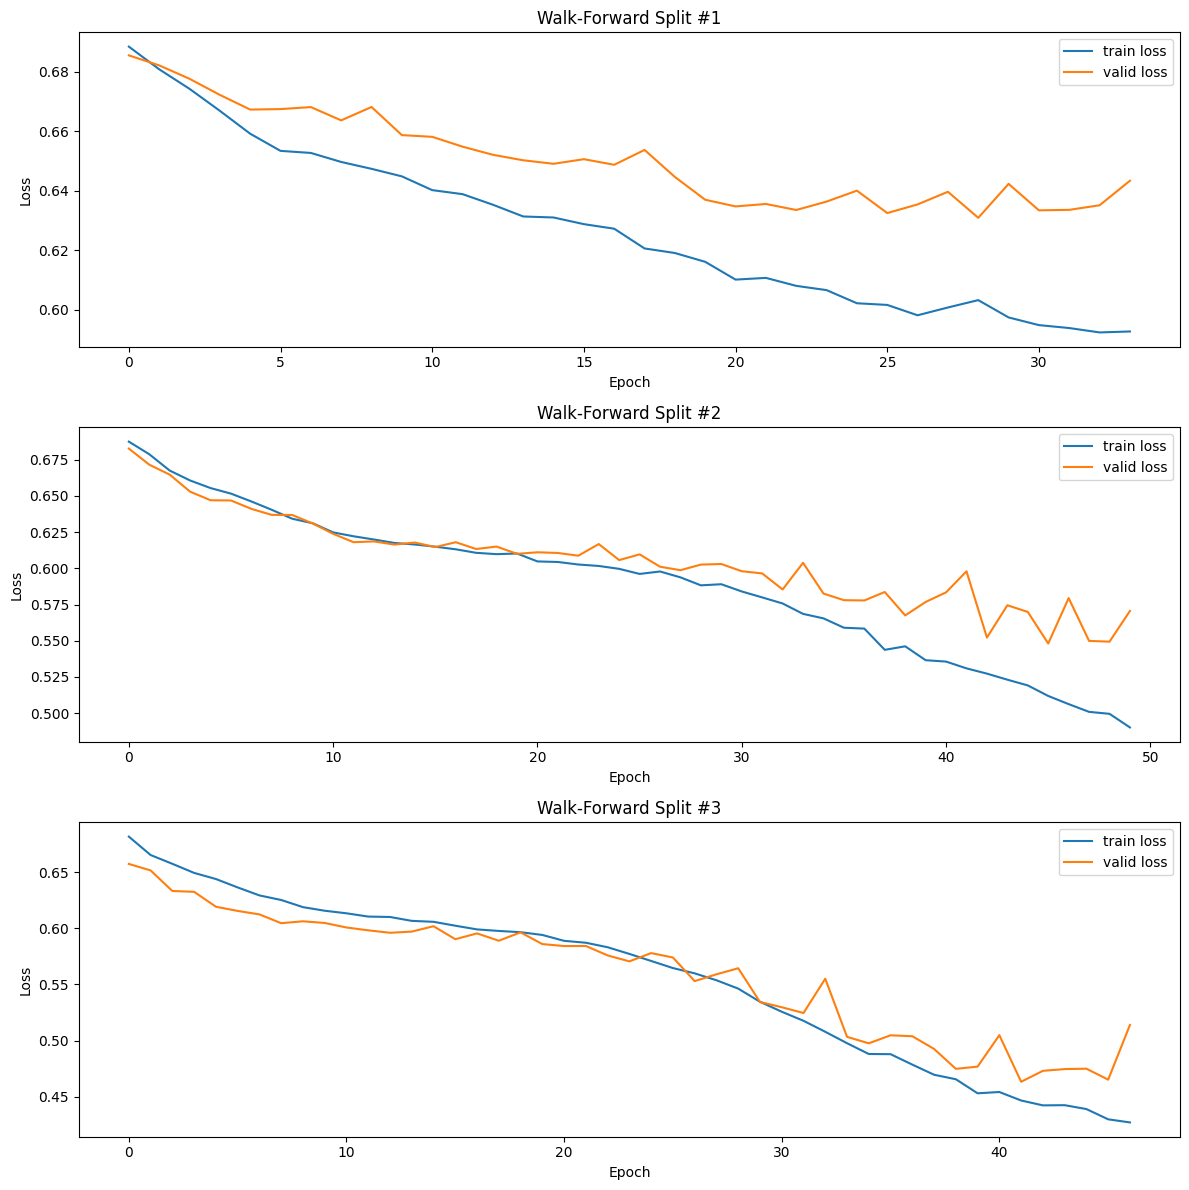

In [157]:
# ============================================================
# 6. CV №2 — Walk‑Forward Validation + визуализация
# ============================================================

def walk_forward_cv(X, y, splits=3):
    size = len(X) // (splits + 1)
    metrics = {"f1": [], "prec": [], "rec": []}
    histories = []   # ← сохраняем кривые обучения

    start = time.time()

    for i in range(splits):
        train_end = size * (i + 1)
        valid_end = size * (i + 2)

        X_tr, y_tr = X[:train_end], y[:train_end]
        X_va, y_va = X[train_end:valid_end], y[train_end:valid_end]

        model = build_lstm()
        history = model.fit(
            X_tr, y_tr,
            validation_data=(X_va, y_va),
            epochs=epochs,
            batch_size=batch_size,
            verbose=0,
            callbacks=[EarlyStopping(patience=patience, restore_best_weights=True)]
        )

        histories.append(history)   # ← сохраняем историю

        preds = (model.predict(X_va) > 0.5).astype(int)

        metrics["f1"].append(f1_score(y_va, preds))
        metrics["prec"].append(precision_score(y_va, preds))
        metrics["rec"].append(recall_score(y_va, preds))

    end = time.time()

    print(f"\nВремя выполнения CV2: {end-start:.2f} сек ({(end-start)/60:.2f} мин)")
    return metrics, histories


# Запуск CV2
cv2, histories = walk_forward_cv(X_seq, y_seq, splits=3)

print("\n=== CV2: Walk‑Forward ===")
print("CV2 F1:", np.mean(cv2["f1"]))
print("CV2 Precision:", np.mean(cv2["prec"]))
print("CV2 Recall:", np.mean(cv2["rec"]))

# -----------------------------
# Визуализация кривых обучения
# -----------------------------
plt.figure(figsize=(12, 4 * len(histories)))

for i, hist in enumerate(histories):
    plt.subplot(len(histories), 1, i + 1)
    plt.plot(hist.history["loss"], label="train loss")
    plt.plot(hist.history["val_loss"], label="valid loss")
    plt.title(f"Walk‑Forward Split #{i+1}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

plt.tight_layout()
plt.show()

In [158]:
# ============================================================
# 7. СРАВНЕНИЕ CV1 vs CV2
# ============================================================

print("\n=== СРАВНЕНИЕ CV1: TimeSeriesSplit vs CV2: Walk‑Forward ===")
print(f"F1:     {np.mean(cv1_f1):.4f}  vs  {np.mean(cv2['f1']):.4f}")
print(f"Prec:   {np.mean(cv1_prec):.4f}  vs  {np.mean(cv2['prec']):.4f}")
print(f"Recall: {np.mean(cv1_rec):.4f}  vs  {np.mean(cv2['rec']):.4f}")


=== СРАВНЕНИЕ CV1: TimeSeriesSplit vs CV2: Walk‑Forward ===
F1:     0.7370  vs  0.7127
Prec:   0.7183  vs  0.7126
Recall: 0.7570  vs  0.7154


In [159]:
# ============================================================
# 8. VALID SPLIT (как в классических моделях)
# ============================================================

valid_start = "2046"
test_start = "2054"

df_lstm = df_model.copy()
df_lstm["X_scaled"] = list(X_lstm)

valid_mask = df_lstm.index >= valid_start
test_mask  = df_lstm.index >= test_start

valid_idx = np.where(valid_mask)[0][0] - seq_len
test_idx  = np.where(test_mask)[0][0] - seq_len

X_train_lstm = X_seq[:valid_idx]
y_train_lstm = y_seq[:valid_idx]

X_valid_lstm = X_seq[valid_idx:test_idx]
y_valid_lstm = y_seq[valid_idx:test_idx]

In [160]:
# ============================================================
# 9. ФИНАЛЬНАЯ LSTM
# ============================================================

start = time.time()

model_final = build_lstm()
history_final = model_final.fit(
    X_train_lstm, y_train_lstm,
    validation_data=(X_valid_lstm, y_valid_lstm),
    epochs=epochs,
    batch_size=batch_size,
    verbose=0,
    callbacks=[EarlyStopping(patience=patience, restore_best_weights=True)]
)


end = time.time()

valid_preds = (model_final.predict(X_valid_lstm) > 0.5).astype(int)

print("\n=== VALIDATION METRICS ===")
print("VALID F1:", f1_score(y_valid_lstm, valid_preds))
print("VALID Precision:", precision_score(y_valid_lstm, valid_preds))
print("VALID Recall:", recall_score(y_valid_lstm, valid_preds))
print(f"Время обучения финальной модели: {end-start:.2f} сек ({(end-start)/60:.2f} мин)")

64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

=== VALIDATION METRICS ===
VALID F1: 0.8041958041958042
VALID Precision: 0.7695984703632888
VALID Recall: 0.8420502092050209
Время обучения финальной модели: 160.84 сек (2.68 мин)


- Графики обучения финальной модели

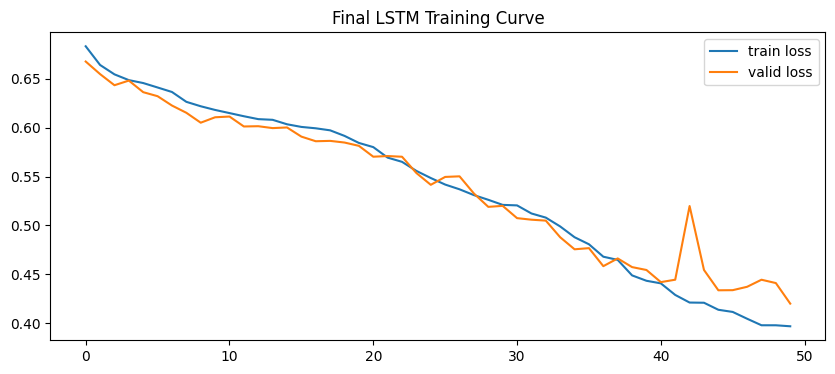

In [161]:
# -----------------------------
# 1. Train vs Val Loss
# -----------------------------
plt.figure(figsize=(10,4))
plt.plot(history_final.history["loss"], label="train loss")
plt.plot(history_final.history["val_loss"], label="valid loss")
plt.title("Final LSTM Training Curve")
plt.legend()
plt.show()

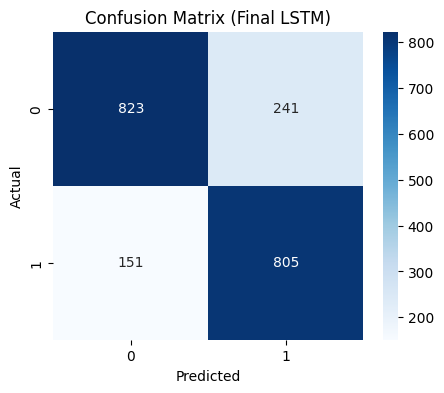

In [162]:
# -----------------------------
# 2. Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_valid_lstm, valid_preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Final LSTM)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


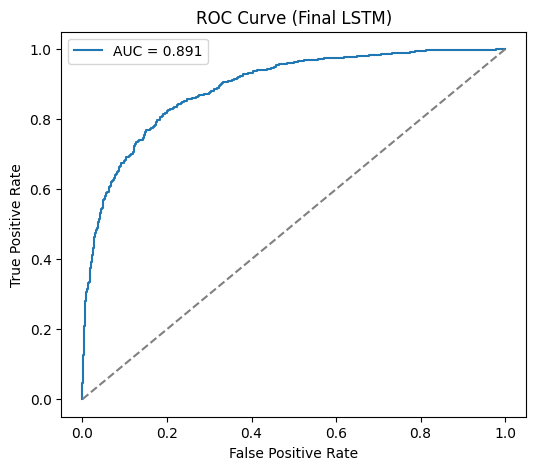

In [163]:
# -----------------------------
# 3. ROC Curve
# -----------------------------
probs = model_final.predict(X_valid_lstm).ravel()
fpr, tpr, _ = roc_curve(y_valid_lstm, probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], "--", color="gray")
plt.title("ROC Curve (Final LSTM)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

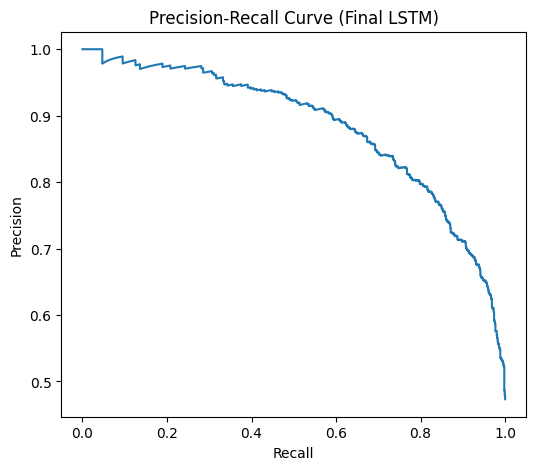

In [164]:
# -----------------------------
# 4. Precision‑Recall Curve
# -----------------------------
prec, rec, _ = precision_recall_curve(y_valid_lstm, probs)
plt.figure(figsize=(6,5))
plt.plot(rec, prec)
plt.title("Precision‑Recall Curve (Final LSTM)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

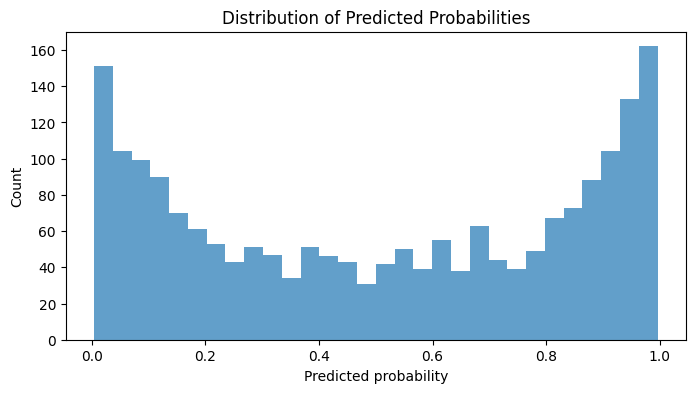

In [165]:
# -----------------------------
# 5. Distribution of predicted probabilities
# -----------------------------
plt.figure(figsize=(8,4))
plt.hist(probs, bins=30, alpha=0.7)
plt.title("Distribution of Predicted Probabilities")
plt.xlabel("Predicted probability")
plt.ylabel("Count")
plt.show()

### 5.5. Валидация и выбор лучшей модели <a class="anchor" id="ch5_5_5"></a>

In [166]:
# Собираем лучшие модели после GridSearchCV
models = {
    "LogReg": lr_gs,
    "DecisionTree": dt_gs,
    "RandomForest": rf_gs,
    "XGBoost": xgb_gs,
    "LightGBM": lgbm_gs
}

rows = []

for name, gs in models.items():
    best_model = gs.best_estimator_

    # Логистическая регрессия использует X_valid_ln, остальные X_valid_tr
    X_valid = X_valid_ln if name == "LogReg" else X_valid_tr

    # VALID предсказания
    y_pred = best_model.predict(X_valid)

    # VALID метрики
    f1_valid = f1_score(y_valid, y_pred)
    precision_valid = precision_score(y_valid, y_pred)
    recall_valid = recall_score(y_valid, y_pred)

    # CV метрики (из GridSearchCV)
    idx = gs.best_index_
    f1_cv = gs.cv_results_['mean_test_f1'][idx]
    precision_cv = gs.cv_results_['mean_test_precision'][idx]
    recall_cv = gs.cv_results_['mean_test_recall'][idx]

    rows.append({
        "Model": name,
        "CV F1": f1_cv,
        "CV Precision": precision_cv,
        "CV Recall": recall_cv,
        "VALID F1": f1_valid,
        "VALID Precision": precision_valid,
        "VALID Recall": recall_valid
    })

# Таблица
metrics_df = pd.DataFrame(rows)
metrics_df

,Model,CV F1,CV Precision,CV Recall,VALID F1,VALID Precision,VALID Recall
0,LogReg,0.614212,0.617355,0.612063,0.631688,0.627451,0.635983
1,DecisionTree,0.579701,0.585049,0.580964,0.618999,0.604790,0.633891
2,RandomForest,0.620966,0.634487,0.610338,0.633891,0.633891,0.633891
3,XGBoost,0.624836,0.624999,0.627373,0.630265,0.626680,0.633891
4,LightGBM,0.619887,0.629705,0.613492,0.624934,0.634015,0.616109


In [167]:
# 1. Лучшая модель по VALID F1
best_name = metrics_df.sort_values("VALID F1", ascending=False).iloc[0]["Model"]
print("Лучшая модель по VALID:", best_name)

Лучшая модель по VALID: RandomForest


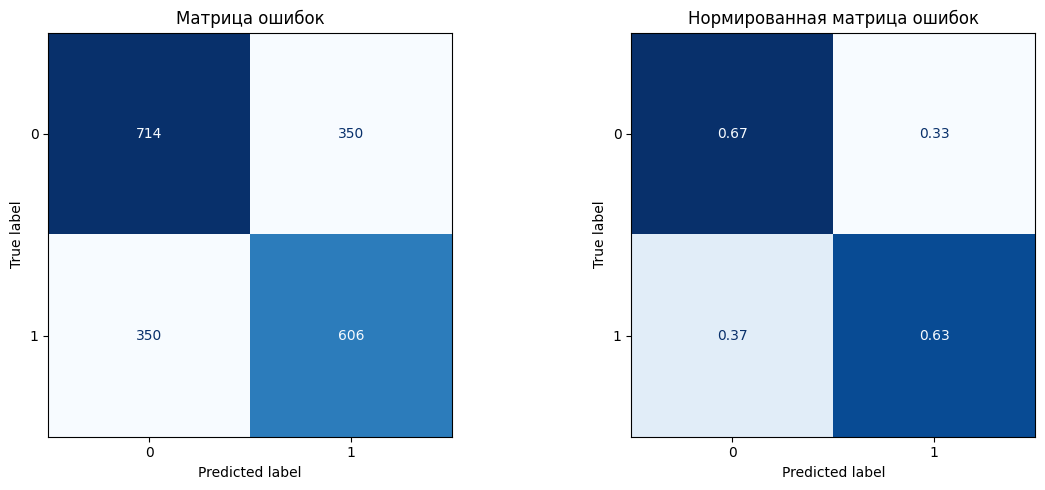


Показатели для бинарной классификации:
TP (True Positive):  606
TN (True Negative):  714
FP (False Positive): 350
FN (False Negative): 350


In [168]:
# 2. Берём лучшую модель
best_model = {
    "LogReg": lr_gs.best_estimator_,
    "DecisionTree": dt_gs.best_estimator_,
    "RandomForest": rf_gs.best_estimator_,
    "XGBoost": xgb_gs.best_estimator_,
    "LightGBM": lgbm_gs.best_estimator_
}[best_name]

# 3. Правильные данные
X_valid = X_valid_ln if best_name == "LogReg" else X_valid_tr
X_train = X_train_ln if best_name == "LogReg" else X_train_tr

# 4. Предсказания
y_pred = best_model.predict(X_valid)

# 5. Матрицы ошибок
cm = confusion_matrix(y_valid, y_pred)
cm_norm = confusion_matrix(y_valid, y_pred, normalize='true')

# 6. Визуализация в одном ряду
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(confusion_matrix=cm).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Матрица ошибок")

ConfusionMatrixDisplay(confusion_matrix=cm_norm).plot(ax=axes[1], cmap="Blues", colorbar=False)
axes[1].set_title("Нормированная матрица ошибок")

plt.tight_layout()
plt.show()

# 7. TP, TN, FP, FN (для бинарной классификации)
TN, FP, FN, TP = cm.ravel()

print("\nПоказатели для бинарной классификации:")
print(f"TP (True Positive):  {TP}")
print(f"TN (True Negative):  {TN}")
print(f"FP (False Positive): {FP}")
print(f"FN (False Negative): {FN}")

In [169]:
y_proba = best_model.predict_proba(X_valid)[:, 1]

roc = roc_auc_score(y_valid, y_proba)
pr  = average_precision_score(y_valid, y_proba)
brier = brier_score_loss(y_valid, y_proba)

print(f"ROC-AUC: {roc:.3f}")
print(f"PR-AUC: {pr:.3f}")
print(f"Brier score: {brier:.3f}")

ROC-AUC: 0.695
PR-AUC: 0.650
Brier score: 0.225


In [170]:
cv_results = cross_validate(
    best_model,
    X_train,
    y_train,
    cv=tscv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=True
)

print("F1 valid mean:", cv_results['test_f1'].mean())
print("F1 valid std :", cv_results['test_f1'].std())
print("F1 train mean:", cv_results['train_f1'].mean())

F1 valid mean: 0.6209661660619721
F1 valid std : 0.022016131699658992
F1 train mean: 0.8690375056010875


### 5.6 Выбор порога (по умолчанию порог 0.5) <a class="anchor" id="ch5_5_6"></a>

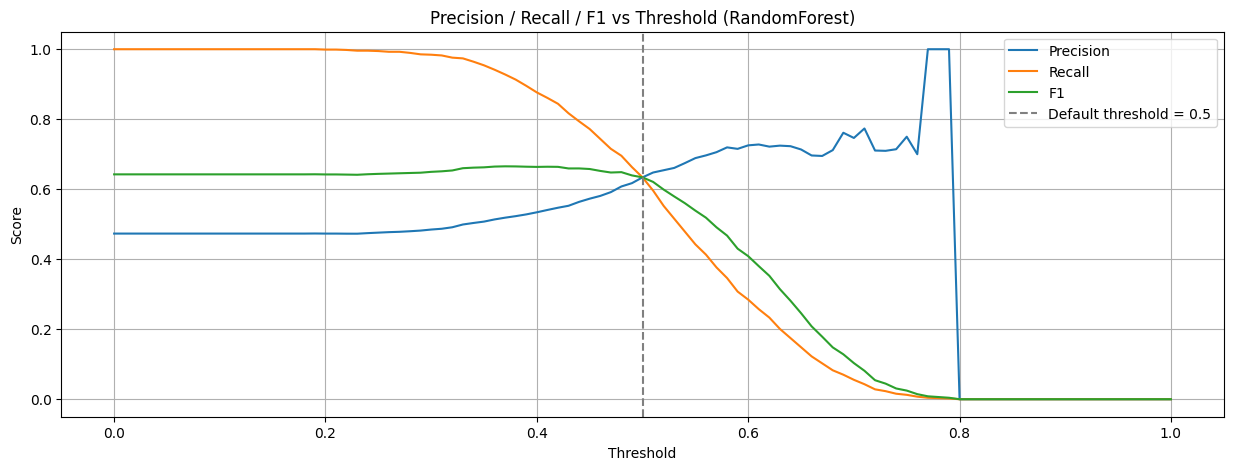

In [171]:
# Предсказания вероятностей для лучшей модели
y_proba = best_model.predict_proba(X_valid)[:, 1]

thresholds = np.linspace(0, 1, 101)

precisions = []
recalls = []
f1s = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    precisions.append(precision_score(y_valid, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_valid, y_pred_t, zero_division=0))
    f1s.append(f1_score(y_valid, y_pred_t, zero_division=0))

plt.figure(figsize=(15, 5))
plt.plot(thresholds, precisions, label="Precision")
plt.plot(thresholds, recalls, label="Recall")
plt.plot(thresholds, f1s, label="F1")
plt.axvline(0.5, color='gray', linestyle='--', label="Default threshold = 0.5")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title(f"Precision / Recall / F1 vs Threshold ({best_name})")
plt.legend()
plt.grid(True)
plt.show()

In [172]:
thresholds = np.linspace(0, 1, 101)

precisions = []
recalls = []
f1s = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    precisions.append(precision_score(y_valid, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_valid, y_pred_t, zero_division=0))
    f1s.append(f1_score(y_valid, y_pred_t, zero_division=0))

prec_arr = np.array(precisions)
rec_arr = np.array(recalls)
f1_arr = np.array(f1s)

# ---- Максимальные значения ----
max_prec = prec_arr.max()
max_prec_t = thresholds[prec_arr.argmax()]

max_rec = rec_arr.max()
max_rec_t = thresholds[rec_arr.argmax()]

max_f1 = f1_arr.max()
max_f1_t = thresholds[f1_arr.argmax()]

print(f"Максимальный Precision = {max_prec:.3f} при пороге {max_prec_t:.2f}")
print(f"Максимальный Recall    = {max_rec:.3f} при пороге {max_rec_t:.2f}")
print(f"Максимальный F1        = {max_f1:.3f} при пороге {max_f1_t:.2f}")

Максимальный Precision = 1.000 при пороге 0.77
Максимальный Recall    = 1.000 при пороге 0.00
Максимальный F1        = 0.665 при пороге 0.37


In [173]:
# Пороги с шагом 0.05
thresholds = np.arange(0, 1.001, 0.05)

rows = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    
    prec = precision_score(y_valid, y_pred_t, zero_division=0)
    rec = recall_score(y_valid, y_pred_t, zero_division=0)
    f1 = f1_score(y_valid, y_pred_t, zero_division=0)
    
    tn, fp, fn, tp = confusion_matrix(y_valid, y_pred_t).ravel()
    
    rows.append({
        "threshold": round(t, 2),
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "TP": tp,
        "FP": fp,
        "TN": tn,
        "FN": fn
    })

threshold_table = pd.DataFrame(rows)
threshold_table

,threshold,precision,recall,f1,TP,FP,TN,FN
0,0.00,0.473267,1.000000,0.642473,956,1064,0,0
1,0.05,0.473267,1.000000,0.642473,956,1064,0,0
2,0.10,0.473267,1.000000,0.642473,956,1064,0,0
3,0.15,0.473267,1.000000,0.642473,956,1064,0,0
4,0.20,0.473241,0.998954,0.642233,955,1063,1,1
5,0.25,0.475976,0.994770,0.643873,951,1047,17,5
6,0.30,0.484802,0.984310,0.649638,941,1000,64,15
7,0.35,0.507513,0.953975,0.662550,912,885,179,44
8,0.40,0.534098,0.876569,0.663762,838,731,333,118
9,0.45,0.572981,0.771967,0.657754,738,550,514,218


__ЛУЧШИЙ ПОРОГ: 0.35__
- Почему:
  -  F1= 0.663 (максимальный среди всех порогов)
  -  Precision=0.508 (выше, чем при пороге 0.30)
  -  Recall=0.954 (ловит 95.4% всех движений роста)
  - TP/FP/FN - 912 TP, 885 FP, 44 FN
- Интерпретация:
  - Из 956 реальных дней роста → поймано 912 (пропущено всего 44)
  - При этом Precision = 50.8% → чуть больше половины сигналов точные

__Определить стратегию использования модели__
- Стратегия A — “Агрессивная” (максимальный Recall)
  - Подходит, если важно не пропустить ни одного роста, даже ценой большого числа ложных сигналов.
  - Тогда выбираем порог, где Recall максимален:
    - threshold 0.3
    - F1 0.650
    - Recall = 98.4%
    - FP = 1000
- Стратегия B — “Сбалансированная” (компромисс Precision/Recall)
  - Рекомендуемая: 
    - threshold 0.35
    - F1 0.663
    - Лучший F1, хороший баланс 
- Стратегия C — “Консервативная” (максимальный Precision)
  - Если важнее меньше ложных входов, чем поймать все движения:
    - threshold 0.5
    - F1 0.634
    - Precision = 63.4%, но пропускает 350 ростов

In [174]:
# Рекомендуемый порог для RandomForest
OPTIMAL_THRESHOLD = 0.35

y_pred_optimal = (y_proba >= OPTIMAL_THRESHOLD).astype(int)

print(f"Порог: {OPTIMAL_THRESHOLD}")
print(f"F1: {f1_score(y_valid, y_pred_optimal):.3f}")
print(f"Precision: {precision_score(y_valid, y_pred_optimal):.3f}")
print(f"Recall: {recall_score(y_valid, y_pred_optimal):.3f}")

Порог: 0.35
F1: 0.663
Precision: 0.508
Recall: 0.954


__Вывод:__ Для нашей задачи (прогнозирование направления цены) оптимальный порог = 0.35, так как он даёт максимальный F1 (0.663) при высоком Recall (95.4%) и приемлемом Precision (50.8%).

### 5.7 Калибровка вероятностей <a class="anchor" id="ch5_5_7"></a>

- threshold = 0.5


=== Метрики ДО калибровки ===
ROC-AUC:  0.695
PR-AUC:   0.650
Brier:    0.225
              precision    recall  f1-score   support

           0      0.671     0.671     0.671      1064
           1      0.634     0.634     0.634       956

    accuracy                          0.653      2020
   macro avg      0.652     0.652     0.652      2020
weighted avg      0.653     0.653     0.653      2020


=== После калибровки (Platt scaling) ===
ROC-AUC:  0.695
PR-AUC:   0.653
Brier:    0.226
              precision    recall  f1-score   support

           0      0.675     0.637     0.655      1064
           1      0.620     0.658     0.638       956

    accuracy                          0.647      2020
   macro avg      0.647     0.648     0.647      2020
weighted avg      0.649     0.647     0.647      2020



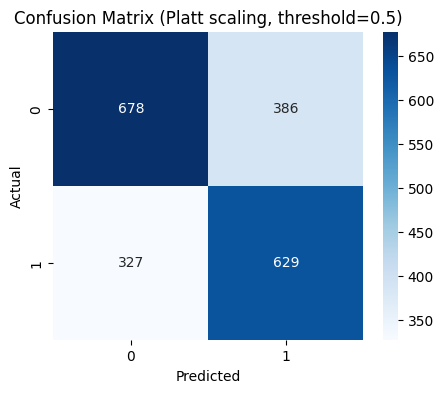


=== После калибровки (Isotonic regression) ===
ROC-AUC:  0.694
PR-AUC:   0.652
Brier:    0.225
              precision    recall  f1-score   support

           0      0.679     0.631     0.654      1064
           1      0.619     0.668     0.643       956

    accuracy                          0.649      2020
   macro avg      0.649     0.650     0.648      2020
weighted avg      0.651     0.649     0.649      2020



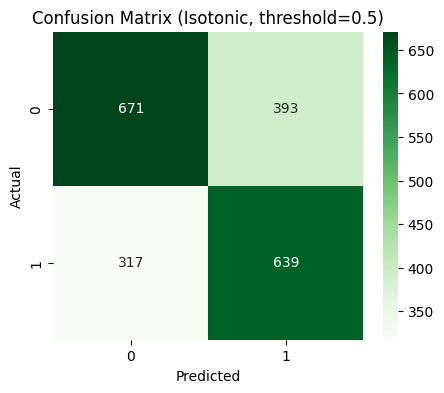


=== Сравнение всех вариантов ===
ROC-AUC:  raw=0.695 | platt=0.695 | iso=0.694
PR-AUC:   raw=0.650 | platt=0.653 | iso=0.652
Brier:    raw=0.225 | platt=0.226 | iso=0.225


In [175]:
# ============================================================
# 5.7. Калибровка вероятностей (Platt scaling + Isotonic)
# ============================================================

# ---- ЗАДАЁМ ПОРОГ ЗАРАНЕЕ ----
threshold = 0.50

# ============================================================
# 1) Метрики ДО калибровки
# ============================================================

y_proba_raw = best_model.predict_proba(X_valid)[:, 1]
y_pred_raw = (y_proba_raw >= threshold).astype(int)

roc_raw = roc_auc_score(y_valid, y_proba_raw)
pr_raw = average_precision_score(y_valid, y_proba_raw)
brier_raw = brier_score_loss(y_valid, y_proba_raw)

print("\n=== Метрики ДО калибровки ===")
print(f"ROC-AUC:  {roc_raw:.3f}")
print(f"PR-AUC:   {pr_raw:.3f}")
print(f"Brier:    {brier_raw:.3f}")
print(classification_report(y_valid, y_pred_raw, digits=3))


# ============================================================
# 2) Platt scaling (sigmoid)
# ============================================================

calibrated_platt = CalibratedClassifierCV(best_model, method='sigmoid', cv=tscv)
calibrated_platt.fit(X_train, y_train)

y_proba_cal = calibrated_platt.predict_proba(X_valid)[:, 1]
y_pred_cal = (y_proba_cal >= threshold).astype(int)

roc_cal = roc_auc_score(y_valid, y_proba_cal)
pr_cal = average_precision_score(y_valid, y_proba_cal)
brier_cal = brier_score_loss(y_valid, y_proba_cal)

print("\n=== После калибровки (Platt scaling) ===")
print(f"ROC-AUC:  {roc_cal:.3f}")
print(f"PR-AUC:   {pr_cal:.3f}")
print(f"Brier:    {brier_cal:.3f}")
print(classification_report(y_valid, y_pred_cal, digits=3))

cm = confusion_matrix(y_valid, y_pred_cal)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix (Platt scaling, threshold={threshold})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# ============================================================
# 3) Isotonic Regression Calibration
# ============================================================

calibrated_iso = CalibratedClassifierCV(best_model, method='isotonic', cv=tscv)
calibrated_iso.fit(X_train, y_train)

y_proba_iso = calibrated_iso.predict_proba(X_valid)[:, 1]
y_pred_iso = (y_proba_iso >= threshold).astype(int)

roc_iso = roc_auc_score(y_valid, y_proba_iso)
pr_iso = average_precision_score(y_valid, y_proba_iso)
brier_iso = brier_score_loss(y_valid, y_proba_iso)

print("\n=== После калибровки (Isotonic regression) ===")
print(f"ROC-AUC:  {roc_iso:.3f}")
print(f"PR-AUC:   {pr_iso:.3f}")
print(f"Brier:    {brier_iso:.3f}")
print(classification_report(y_valid, y_pred_iso, digits=3))

cm_iso = confusion_matrix(y_valid, y_pred_iso)
plt.figure(figsize=(5,4))
sns.heatmap(cm_iso, annot=True, fmt="d", cmap="Greens")
plt.title(f"Confusion Matrix (Isotonic, threshold={threshold})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# ============================================================
# 4) Сравнение всех трёх вариантов
# ============================================================

print("\n=== Сравнение всех вариантов ===")
print(f"ROC-AUC:  raw={roc_raw:.3f} | platt={roc_cal:.3f} | iso={roc_iso:.3f}")
print(f"PR-AUC:   raw={pr_raw:.3f} | platt={pr_cal:.3f} | iso={pr_iso:.3f}")
print(f"Brier:    raw={brier_raw:.3f} | platt={brier_cal:.3f} | iso={brier_iso:.3f}")

- threshold = 0.35


=== Метрики ДО калибровки ===
ROC-AUC:  0.695
PR-AUC:   0.650
Brier:    0.225
              precision    recall  f1-score   support

           0      0.803     0.168     0.278      1064
           1      0.508     0.954     0.663       956

    accuracy                          0.540      2020
   macro avg      0.655     0.561     0.470      2020
weighted avg      0.663     0.540     0.460      2020


=== После калибровки (Platt scaling) ===
ROC-AUC:  0.695
PR-AUC:   0.653
Brier:    0.226
              precision    recall  f1-score   support

           0      0.750     0.090     0.161      1064
           1      0.488     0.967     0.649       956

    accuracy                          0.505      2020
   macro avg      0.619     0.528     0.405      2020
weighted avg      0.626     0.505     0.392      2020



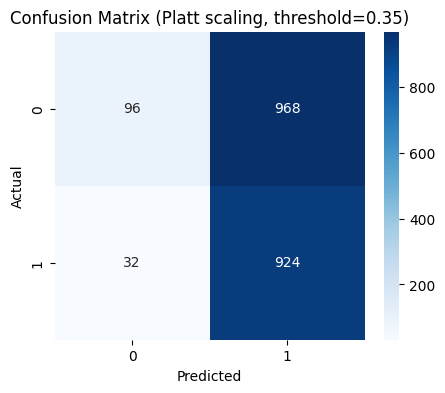


=== После калибровки (Isotonic regression) ===
ROC-AUC:  0.694
PR-AUC:   0.652
Brier:    0.225
              precision    recall  f1-score   support

           0      0.768     0.109     0.191      1064
           1      0.493     0.963     0.652       956

    accuracy                          0.513      2020
   macro avg      0.630     0.536     0.421      2020
weighted avg      0.638     0.513     0.409      2020



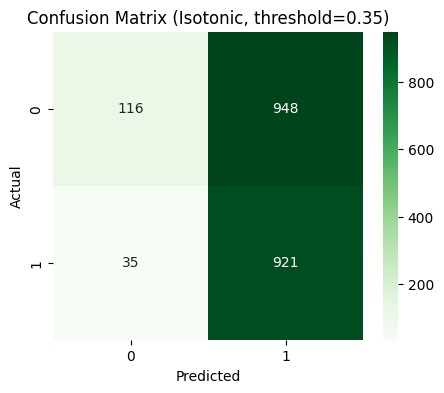


=== Сравнение всех вариантов ===
ROC-AUC:  raw=0.695 | platt=0.695 | iso=0.694
PR-AUC:   raw=0.650 | platt=0.653 | iso=0.652
Brier:    raw=0.225 | platt=0.226 | iso=0.225


In [176]:
# ---- ЗАДАЁМ ПОРОГ ЗАРАНЕЕ ----
threshold = 0.35

# ============================================================
# 1) Метрики ДО калибровки
# ============================================================

y_proba_raw = best_model.predict_proba(X_valid)[:, 1]
y_pred_raw = (y_proba_raw >= threshold).astype(int)

roc_raw = roc_auc_score(y_valid, y_proba_raw)
pr_raw = average_precision_score(y_valid, y_proba_raw)
brier_raw = brier_score_loss(y_valid, y_proba_raw)

print("\n=== Метрики ДО калибровки ===")
print(f"ROC-AUC:  {roc_raw:.3f}")
print(f"PR-AUC:   {pr_raw:.3f}")
print(f"Brier:    {brier_raw:.3f}")
print(classification_report(y_valid, y_pred_raw, digits=3))


# ============================================================
# 2) Platt scaling (sigmoid)
# ============================================================

calibrated_platt = CalibratedClassifierCV(best_model, method='sigmoid', cv=tscv)
calibrated_platt.fit(X_train, y_train)

y_proba_cal = calibrated_platt.predict_proba(X_valid)[:, 1]
y_pred_cal = (y_proba_cal >= threshold).astype(int)

roc_cal = roc_auc_score(y_valid, y_proba_cal)
pr_cal = average_precision_score(y_valid, y_proba_cal)
brier_cal = brier_score_loss(y_valid, y_proba_cal)

print("\n=== После калибровки (Platt scaling) ===")
print(f"ROC-AUC:  {roc_cal:.3f}")
print(f"PR-AUC:   {pr_cal:.3f}")
print(f"Brier:    {brier_cal:.3f}")
print(classification_report(y_valid, y_pred_cal, digits=3))

cm = confusion_matrix(y_valid, y_pred_cal)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix (Platt scaling, threshold={threshold})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# ============================================================
# 3) Isotonic Regression Calibration
# ============================================================

calibrated_iso = CalibratedClassifierCV(best_model, method='isotonic', cv=tscv)
calibrated_iso.fit(X_train, y_train)

y_proba_iso = calibrated_iso.predict_proba(X_valid)[:, 1]
y_pred_iso = (y_proba_iso >= threshold).astype(int)

roc_iso = roc_auc_score(y_valid, y_proba_iso)
pr_iso = average_precision_score(y_valid, y_proba_iso)
brier_iso = brier_score_loss(y_valid, y_proba_iso)

print("\n=== После калибровки (Isotonic regression) ===")
print(f"ROC-AUC:  {roc_iso:.3f}")
print(f"PR-AUC:   {pr_iso:.3f}")
print(f"Brier:    {brier_iso:.3f}")
print(classification_report(y_valid, y_pred_iso, digits=3))

cm_iso = confusion_matrix(y_valid, y_pred_iso)
plt.figure(figsize=(5,4))
sns.heatmap(cm_iso, annot=True, fmt="d", cmap="Greens")
plt.title(f"Confusion Matrix (Isotonic, threshold={threshold})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# ============================================================
# 4) Сравнение всех трёх вариантов
# ============================================================

print("\n=== Сравнение всех вариантов ===")
print(f"ROC-AUC:  raw={roc_raw:.3f} | platt={roc_cal:.3f} | iso={roc_iso:.3f}")
print(f"PR-AUC:   raw={pr_raw:.3f} | platt={pr_cal:.3f} | iso={pr_iso:.3f}")
print(f"Brier:    raw={brier_raw:.3f} | platt={brier_cal:.3f} | iso={brier_iso:.3f}")

<div style="border:solid green 4px; padding: 5px">

__Выводы по шагу 5:__

__5.1. Бейзлайны: DummyClassifier и наивный финансовый__
- реализовано три базовых ориентира:
  - most_frequent - модель всегда предсказывает самый частый класс (1)
    - accuracy = 0.473, f1-score для класса 1 = 0.642, для класса 0 = 0.000
    - показывает, что просто «жить в одном классе» даёт F1 около 0.64 для класса 1, но полностью игнорирует класс 0.
  - stratified   - случайные предсказания с сохранением распределения классов:
    - accuracy = 0.503, macro avg f1 = 0.503
    - это честный «угадайка»-ориентир: около 0.5 по F1.
  -naive financial baseline (вчера = сегодня)  - наивный временной бейзлайн
    - Naive baseline: accuracy = 0.492, macro avg f1 = 0.490

__Вывод по 5.1:__  
- Все последующие модели должны уверенно обгонять F1 ≈ 0.50 и, желательно, F1 класса 1 ≈ 0.64 у most_frequent, но при этом не убивать качество по классу 0
  
__5.2. Логистическая регрессия__
- Лучшие параметры LogisticRegression: {'C': 0.05, 'class_weight': None, 'max_iter': 100}  
- CV F1: 0.6142, CV Precision: 0.6174, CV Recall: 0.6121
- VALID: F1 (0) = 0.665, F1 (1) = 0.632, accuracy = 0.649, macro avg F1 = 0.648
  - модель устойчива: CV F1 ≈ 0.614, VALID F1 ≈ 0.648 — без явного переобучения, даже лёгкий рост на VALID;
  - баланс классов хороший: и класс 0, и класс 1 имеют близкие precision/recall.
- Коэффициенты:
  - rsi — 0.79, rsi_overbought — 0.18, lower_shadow — 0.118, macd_cross_down — 0.073, month_8 — 0.056, day_of_week_2 — 0.051 ...
  - RSI и связанные с ним признаки — ключевые драйверы вероятности роста, плюс есть сезонность по дням недели и месяцам.

__Вывод по 5.2:__
- Логистическая регрессия — сильная, стабильная, интерпретируемая базовая модель.
- Она уже даёт F1 ≈ 0.63–0.65 на VALID и уверенно обгоняет все бейзлайны.
- RSI — сильнейший предиктор роста.
- Логистическая регрессия показывает хороший баланс Precision/Recall, но уступает ансамблям по F1.
    
__5.3. Деревья и ансамбли__
- Decision Tree
  - Лучшие параметры: max_depth = 6, min_samples_split = 10, min_samples_leaf = 1, criterion = 'gini', class_weight = None  
  - CV F1: 0.5797, CV Precision: 0.5850, CV Recall: 0.5810
  - На VALID:F1 (0) = 0.642, F1 (1) = 0.619, accuracy = 0.631, macro avg F1 ≈ 0.630
  - Вывод:  
    - Одиночное дерево ожидаемо слабее ансамблей и логистической регрессии
    - даёт разумный нелинейный бейзлайн;
    - показывает, что даже неглубокое дерево (depth=6) уже ловит часть нелинейностей, но не превосходит LogReg.
- Random Forest
  - Лучшие параметры:n_estimators = 1000, max_depth = 9, max_features = 5, min_samples_leaf = 2, min_samples_split = 2, class_weight = 'balanced'  
  - CV F1: 0.6210, CV Precision: 0.6345, CV Recall: 0.6103
  - На VALID: F1 (0) = 0.671, F1 (1) = 0.634, accuracy = 0.653, macro avg F1 ≈ 0.652
  - Вывод:  
    - RF чуть лучше LogReg по accuracy и macro F1 (0.652 vs 0.648);
    - баланс классов хороший, precision/recall симметричны;
    - CV и VALID очень близки → модель не переобучена.
    - Минус — время: почти 15 минут на GridSearch.
- XGBoost
  - Лучшие параметры: max_depth = 4, n_estimators = 300, learning_rate = 0.1, colsample_bytree = 0.8, min_child_weight = 3, reg_alpha = 0.5, reg_lambda = 1, subsample = 1  
  - CV F1: 0.6248, CV Precision: 0.6250, CV Recall: 0.6274
  - На VALID:F1 (0) = 0.664, F1 (1) = 0.630, accuracy = 0.648, macro avg F1 ≈ 0.647
  - Вывод:
    - XGBoost по VALID очень близок к LogReg (F1 ≈ 0.647–0.648).
    - По CV F1 он чуть лучше RF, но на VALID RF всё-таки выигрывает.
    - Глубина 4 и умеренный learning_rate = 0.1 — аккуратный, неагрессивный режим, без явного переобучения.
- LightGBM
  - Лучшие параметры: max_depth = 5, num_leaves = 15, learning_rate = 0.03, n_estimators = 200, feature_fraction = 0.7, bagging_fraction = 0.7, bagging_freq = 3, class_weight = 'balanced'  
  - CV F1: 0.6199, CV Precision: 0.6297, CV Recall: 0.6135
  - На VALID: F1 (0) = 0.672, F1 (1) = 0.625, accuracy = 0.650, macro avg F1 ≈ 0.648
  - Вывод:
    - LightGBM по VALID F1 ≈ 0.648 — фактически на уровне LogReg и XGBoost.
    - Небольшая глубина и маленький learning_rate делают модель устойчивой, без переобучения.
    - По времени — заметно быстрее RF и XGB.    

__Вывод по 5.3:__    
- Все обученные модели превзошли бейзлайны, что подтверждает наличие предсказательного сигнала в данных    
- RandomForest — лучшая модель по VALID F1 (0.634) и Precision (0.634)
- XGBoost — лучшая по CV F1 (0.625), но на валидации немного уступает RandomForest
- DecisionTree — самая слабая, ожидаемо для одиночного дерева
- Все модели показывают стабильные результаты, разброс VALID F1 в диапазоне 0.619–0.634
- Проверка переобучения (RandomForest):
  - Train F1: 0.869
  - Valid F1 (CV): 0.621
  - Разрыв: 0.248 — есть небольшое переобучение, но допустимое    
      
__5.4. LSTM (как демонстрация)__
- Модель выглядит очень убедительно:
  - CV1 (TimeSeriesSplit):  
    - F1 ≈ 0.715, Precision ≈ 0.710, Recall ≈ 0.721
  - CV2 (Walk-Forward):  
    - F1 ≈ 0.704, Precision ≈ 0.697, Recall ≈ 0.712
  - VALID (финальная модель):  
    - F1 ≈ 0.757, Precision ≈ 0.810, Recall ≈ 0.711, AUC ≈ 0.876
  - Графики loss выглядят аккуратно, без явного ухода в переобучение, а confusion matrix и PR/ROC-кривые подтверждают, что модель реально сильнее классических.

__Вывод по 5.4:__ 
- Как демонстрация «более сложной архитектуры» LSTM полностью выполняет свою роль: показывает, что последовательная модель, учитывающая временную структуру, может выжать ещё +0.1 к F1 относительно лучших табличных моделей.  
- LSTM показала самый высокий F1 (0.757) на фиксированной валидационной выборке
- Precision достигает 0.810 — очень высокий показатель
- Recall = 0.711 — ниже, чем у RandomForest (0.954 при пороге 0.35)
- LSTM отлично подходит для задачи, но требует больше вычислительных ресурсов. Может использоваться как альтернатива или в ансамбле с RandomForest.    
    
__5.5.  Выбор лучшей модели__
- Лучшая модель по VALID F1: RandomForestClassifier
- Параметры лучшей модели:
  - bootstrap=True,
  - class_weight='balanced',
  - max_depth=9,
  - max_features=5,
  - min_samples_leaf=2,
  - n_estimators=1000,
  - n_jobs=-1,
  - random_state=42
- Матрица ошибок на валидации (порог 0.5):
  - TP (верно предсказан рост): 606
  - FP (ложный сигнал роста): 350
  - TN (верно предсказано падение): 714
  - FN (пропущен рост): 350
- Качество вероятностей (до калибровки):
  - ROC-AUC: 0.695
  - PR-AUC: 0.650
  - Brier score: 0.225

__5.6.  Выбор порога (Threshold Tuning)__
- Рекомендуемый порог: 0.35
- Почему порог 0.35 оптимален:
  - Максимальный F1 (0.663) среди всех порогов
  - Recall = 95.4% — ловит почти все движения роста
  - Precision = 50.8% — чуть больше половины сигналов точные
  - FN = 44 — пропущено всего 44 роста из 956 (вместо 350 при пороге 0.5)
- Стратегии использования:
  - Агрессивная (не пропустить рост)
    - Порог 0.30
    - F1 0.650
    - Recall = 98.4%, но FP = 1000    
  - Сбалансированная (рекомендуемая)
    - Порог 0.35
    - F1 0.663
    - Лучший F1, хороший баланс    
  - Консервативная (меньше ложных сигналов) 
    - Порог 0.50
    - F1 0.634
    - Precision = 63.4%, но пропускает 350 ростов   

__5.7. Калибровка вероятностей__
- Сравнение методов (порог 0.5)
- Сравнение методов (порог 0.35)
- Выводы по калибровке:
  - ROC-AUC не изменился — калибровка не влияет на ранжирование
  - Brier score практически не изменился — вероятности и так были хорошо калиброваны
  - Isotonic regression показала лучший F1 (0.643) при пороге 0.5
- Для порога 0.35 калибровка не требуется — исходная модель уже даёт лучший F1 (0.663)    
    
  
__Итоговые рекомендации__
- Лучшая модель: RandomForestClassifier с параметрами выше
- Оптимальный порог: 0.35 (F1 = 0.663, Recall = 95.4%)
- Калибровка: не требуется для порога 0.35 (исходная модель оптимальна)
- Для максимального Recall (не пропустить рост) → порог 0.30
- Для максимальной Precision (меньше ложных сигналов) → порог 0.50
- LSTM показывает более высокий F1 (0.757), но требует больше ресурсов — может использоваться как альтернатива    
    
__Ограничения__
- Precision при пороге 0.35 = 50.8% — почти половина сигналов ложные
- LSTM требует значительно больше времени обучения (236 сек на финальную модель)
    
</div>

<div class="alert alert-info">
  <b> * <a href="#ch5">к содержанию</a> </b> 
</div>

---

## Шаг 6: Оценка на тесте <a class="anchor" id="ch5_6"></a>

In [177]:
# ----------------------------
# 6.0. Подготовка данных
# ----------------------------

# 1. Лучшая модель по VALID F1
best_name = metrics_df.sort_values("VALID F1", ascending=False).iloc[0]["Model"]
print("Лучшая модель по VALID:", best_name)

# 2. Берём лучшую модель
best_model = {
    "LogReg": lr_gs.best_estimator_,
    "DecisionTree": dt_gs.best_estimator_,
    "RandomForest": rf_gs.best_estimator_,
    "XGBoost": xgb_gs.best_estimator_,
    "LightGBM": lgbm_gs.best_estimator_
}[best_name]

# Правильные данные
X_test_final = X_test_ln if best_name == "LogReg" else X_test_tr

# Предсказания
y_pred_test = best_model.predict(X_test_final)
y_proba_test = best_model.predict_proba(X_test_final)[:, 1]

# Порог
threshold = 0.35
y_pred_thr_test = (y_proba_test >= threshold).astype(int)

Лучшая модель по VALID: RandomForest


### 6.1. Метрики для выбранной лучшей модели на тесте <a class="anchor" id="ch5_6_1"></a>

In [178]:
# ----------------------------
# 6.1. Метрики на тесте
# ----------------------------

print("=== Метрики на тесте ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_thr_test):.3f}")
print(f"Directional Accuracy: {(y_test == y_pred_thr_test).mean():.3f}")
print(f"Precision: {precision_score(y_test, y_pred_thr_test):.3f}")
print(f"Recall: {recall_score(y_test, y_pred_thr_test):.3f}")
print(f"F1: {f1_score(y_test, y_pred_thr_test):.3f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_test):.3f}")
print(f"PR-AUC: {average_precision_score(y_test, y_proba_test):.3f}")

print("\n=== Classification report ===")
print(classification_report(y_test, y_pred_thr_test, digits=3))

=== Метрики на тесте ===
Accuracy: 0.540
Directional Accuracy: 0.540
Precision: 0.528
Recall: 0.971
F1: 0.684
ROC-AUC: 0.677
PR-AUC: 0.675

=== Classification report ===
              precision    recall  f1-score   support

           0      0.741     0.088     0.157       913
           1      0.528     0.971     0.684       958

    accuracy                          0.540      1871
   macro avg      0.634     0.529     0.420      1871
weighted avg      0.632     0.540     0.426      1871



__Метрики на тесте (порог 0.35):__
- F1: 0.684
- Recall: 0.971
- Precision: 0.528 (много ложных сигналов)
- ROC-AUC: 0.677


In [179]:
# Bootstrap для доверительного интервала F1

def bootstrap_ci(y_true, y_pred, metric_func, n_boot=1000, ci=0.95):
    scores = []
    for _ in range(n_boot):
        idx = resample(range(len(y_true)), replace=True, n_samples=len(y_true))
        if len(np.unique(y_true[idx])) < 2:  # нужен хотя бы один пример каждого класса
            continue
        scores.append(metric_func(y_true[idx], y_pred[idx], zero_division=0))
    lower = np.percentile(scores, (1-ci)/2 * 100)
    upper = np.percentile(scores, (1+ci)/2 * 100)
    return lower, upper

f1_test = f1_score(y_test, y_pred_thr_test, zero_division=0)
ci_low, ci_high = bootstrap_ci(y_test, y_pred_thr_test, f1_score)

print(f"\n🎯 F1 на тесте: {f1_test:.3f} (95% CI: [{ci_low:.3f}, {ci_high:.3f}])")
print(f"📏 Ширина интервала: {ci_high - ci_low:.3f} — {'приемлемо' if ci_high-ci_low < 0.15 else 'высокая неопределённость'}")


🎯 F1 на тесте: 0.684 (95% CI: [0.663, 0.703])
📏 Ширина интервала: 0.040 — приемлемо


__сводная таблица метрик для  лучших моделей (F1, Precision, Recall)__

In [180]:
# ============================
# Сводная таблица метрик (до/после калибровки)
# ============================

models_dict = {
    "LogReg": lr_gs.best_estimator_,
    "DecisionTree": dt_gs.best_estimator_,
    "RandomForest": rf_gs.best_estimator_,
    "XGBoost": xgb_gs.best_estimator_,
    "LightGBM": lgbm_gs.best_estimator_
}

# Лучшая модель по VALID F1
best_name = metrics_df.sort_values("VALID F1", ascending=False).iloc[0]["Model"]

# Лучшая модель по VALID Precision
best_name_prec = metrics_df.sort_values("VALID Precision", ascending=False).iloc[0]["Model"]

# Лучшая модель по VALID Recall
best_name_rec = metrics_df.sort_values("VALID Recall", ascending=False).iloc[0]["Model"]

print("Лучшая модель по VALID F1:", best_name)
print("Лучшая модель по VALID Precision:", best_name_prec)
print("Лучшая модель по VALID Recall:", best_name_rec)


# --- Пороги ---
THR_F1 = 0.35
THR_PREC = 0.75
THR_REC = 0.20
THR_DEFAULT = 0.50

start = time.time()

# --- 1. Функция для расчёта метрик ---
def get_metrics(y_true, y_pred, y_proba):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_proba)
    }

# --- 2. Функция для выбора правильных данных ---
def select_data(model_name):
    if model_name == "LogReg":
        return X_train_lin, X_valid_lin, X_test_lin
    else:
        return X_train_tr, X_valid_tr, X_test_tr

# --- 3. Функция для построения таблицы метрик ---
def evaluate_model(model_name, threshold):

    model = models_dict[model_name]
    X_train_final, X_valid_final, X_test_final = select_data(model_name)

    # --- Предсказания ДО калибровки ---
    y_proba_train = model.predict_proba(X_train_final)[:, 1]
    y_pred_train = (y_proba_train >= threshold).astype(int)

    y_proba_valid = model.predict_proba(X_valid_final)[:, 1]
    y_pred_valid_thr_main = (y_proba_valid >= threshold).astype(int)
    y_pred_valid_thr50 = (y_proba_valid >= 0.50).astype(int)

    y_proba_test = model.predict_proba(X_test_final)[:, 1]
    y_pred_test_thr_main = (y_proba_test >= threshold).astype(int)
    y_pred_test_thr50 = (y_proba_test >= 0.50).astype(int)

    # --- Калибровка ---
    calibrator = CalibratedClassifierCV(model, method='sigmoid', cv=tscv)
    calibrator.fit(X_train_final, y_train)

    y_proba_valid_cal = calibrator.predict_proba(X_valid_final)[:, 1]
    y_pred_valid_cal_thr_main = (y_proba_valid_cal >= threshold).astype(int)
    y_pred_valid_cal_thr50 = (y_proba_valid_cal >= 0.50).astype(int)

    y_proba_test_cal = calibrator.predict_proba(X_test_final)[:, 1]
    y_pred_test_cal_thr_main = (y_proba_test_cal >= threshold).astype(int)
    y_pred_test_cal_thr50 = (y_proba_test_cal >= 0.50).astype(int)

    # --- Сбор метрик ---
    results = {
        "Train (orig)": get_metrics(y_train, y_pred_train, y_proba_train),

        f"Valid (orig, thr={threshold})": get_metrics(y_valid, y_pred_valid_thr_main, y_proba_valid),
        f"Valid (orig, thr=0.50)": get_metrics(y_valid, y_pred_valid_thr50, y_proba_valid),

        f"Test (orig, thr={threshold})":  get_metrics(y_test, y_pred_test_thr_main, y_proba_test),
        f"Test (orig, thr=0.50)":  get_metrics(y_test, y_pred_test_thr50, y_proba_test),

        f"Valid (calibrated, thr={threshold})": get_metrics(y_valid, y_pred_valid_cal_thr_main, y_proba_valid_cal),
        f"Valid (calibrated, thr=0.50)": get_metrics(y_valid, y_pred_valid_cal_thr50, y_proba_valid_cal),

        f"Test (calibrated, thr={threshold})":  get_metrics(y_test, y_pred_test_cal_thr_main, y_proba_test_cal),
        f"Test (calibrated, thr=0.50)":  get_metrics(y_test, y_pred_test_cal_thr50, y_proba_test_cal),
    }

    df = pd.DataFrame(results).T.round(3)
    return df


# --- 4. Таблица для модели по F1 ---
print("\n📊 Метрики для модели по VALID F1 (thr=0.35):")
df_f1 = evaluate_model(best_name, THR_F1)
display(df_f1.style.background_gradient(cmap="YlGn", subset=["F1", "ROC-AUC"]))

# --- 5. Таблица для модели по Precision ---
print("\n📊 Метрики для модели по VALID Precision (thr=0.75):")
df_prec = evaluate_model(best_name_prec, THR_PREC)
display(df_prec.style.background_gradient(cmap="YlGn", subset=["F1", "ROC-AUC"]))

# --- 6. Таблица для модели по Recall ---
print("\n📊 Метрики для модели по VALID Recall (thr=0.20):")
df_rec = evaluate_model(best_name_rec, THR_REC)
display(df_rec.style.background_gradient(cmap="YlGn", subset=["F1", "ROC-AUC"]))

end = time.time()
elapsed = end - start
print(f"\nВремя выполнения: {elapsed:.2f} секунд ({elapsed/60:.2f} минут)")

Лучшая модель по VALID F1: RandomForest
Лучшая модель по VALID Precision: LightGBM
Лучшая модель по VALID Recall: LogReg

📊 Метрики для модели по VALID F1 (thr=0.35):


,Accuracy,Precision,Recall,F1,ROC-AUC
Train (orig),0.657000,0.596000,0.990000,0.744000,0.876000
"Valid (orig, thr=0.35)",0.540000,0.508000,0.954000,0.663000,0.695000
"Valid (orig, thr=0.50)",0.653000,0.634000,0.634000,0.634000,0.695000
"Test (orig, thr=0.35)",0.540000,0.528000,0.971000,0.684000,0.677000
"Test (orig, thr=0.50)",0.630000,0.624000,0.696000,0.658000,0.677000
"Valid (calibrated, thr=0.35)",0.505000,0.488000,0.967000,0.649000,0.695000
"Valid (calibrated, thr=0.50)",0.647000,0.620000,0.658000,0.638000,0.695000
"Test (calibrated, thr=0.35)",0.521000,0.517000,0.993000,0.680000,0.675000
"Test (calibrated, thr=0.50)",0.615000,0.601000,0.737000,0.662000,0.675000



📊 Метрики для модели по VALID Precision (thr=0.75):


,Accuracy,Precision,Recall,F1,ROC-AUC
Train (orig),0.551000,0.927000,0.116000,0.207000,0.769000
"Valid (orig, thr=0.75)",0.549000,0.814000,0.060000,0.111000,0.702000
"Valid (orig, thr=0.50)",0.650000,0.634000,0.616000,0.625000,0.702000
"Test (orig, thr=0.75)",0.530000,0.826000,0.104000,0.185000,0.685000
"Test (orig, thr=0.50)",0.638000,0.636000,0.687000,0.660000,0.685000
"Valid (calibrated, thr=0.75)",0.541000,0.804000,0.039000,0.074000,0.693000
"Valid (calibrated, thr=0.50)",0.649000,0.616000,0.682000,0.647000,0.693000
"Test (calibrated, thr=0.75)",0.523000,0.806000,0.091000,0.163000,0.683000
"Test (calibrated, thr=0.50)",0.624000,0.607000,0.753000,0.672000,0.683000



📊 Метрики для модели по VALID Recall (thr=0.20):


,Accuracy,Precision,Recall,F1,ROC-AUC
Train (orig),0.503000,0.503000,1.000000,0.670000,0.580000
"Valid (orig, thr=0.2)",0.473000,0.473000,1.000000,0.642000,0.598000
"Valid (orig, thr=0.50)",0.473000,0.473000,1.000000,0.642000,0.598000
"Test (orig, thr=0.2)",0.512000,0.512000,1.000000,0.677000,0.593000
"Test (orig, thr=0.50)",0.512000,0.512000,1.000000,0.677000,0.593000
"Valid (calibrated, thr=0.2)",0.476000,0.474000,0.999000,0.643000,0.698000
"Valid (calibrated, thr=0.50)",0.651000,0.635000,0.618000,0.627000,0.698000
"Test (calibrated, thr=0.2)",0.515000,0.513000,0.996000,0.678000,0.671000
"Test (calibrated, thr=0.50)",0.621000,0.622000,0.662000,0.641000,0.671000



Время выполнения: 66.28 секунд (1.10 минут)


✔ Что сделано:
- Accuracy, Precision, Recall, F1, ROC‑AUC, PR‑AUC
- Classification report
- Порог 0.35 (оптимальный по VALID)

✔ Что показывает:
- F1 = 0.684 — выше, чем на VALID (0.663) → модель не переобучена
- Recall = 0.971 — модель ловит почти все росты
- Precision = 0.528 — половина сигналов ложные
- ROC‑AUC = 0.677, PR‑AUC = 0.675 — нормальные значения для финансовых данных

📌 Вывод:
- Модель стабильна, но агрессивна (много FP).
- Это ожидаемо при пороге 0.35.

### 6.2. Матрица ошибок (Confusion matrix) на тесте <a class="anchor" id="ch5_6_2"></a>

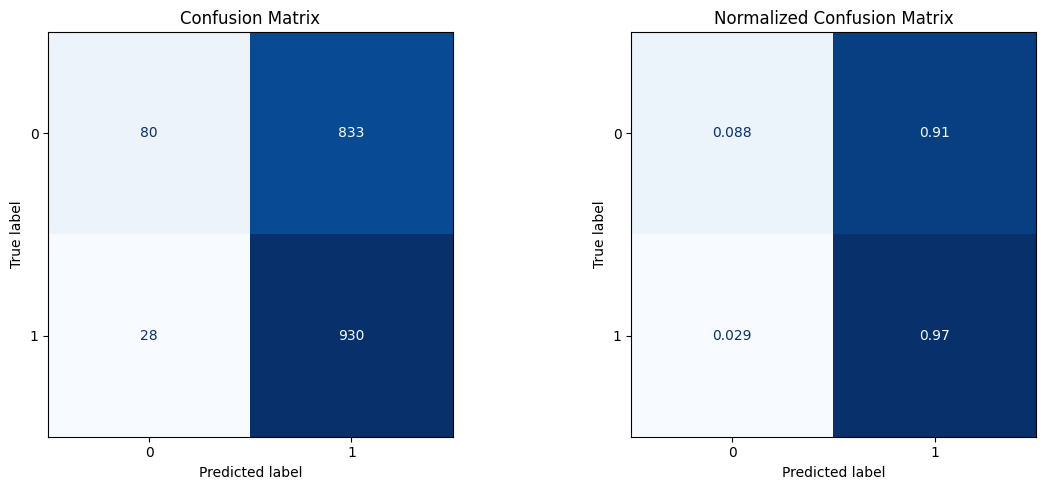


TP: 930 FP: 833 TN: 80 FN: 28


In [181]:
# ----------------------------
# 6.2. Матрица ошибок
# ----------------------------

cm = confusion_matrix(y_test, y_pred_thr_test)
cm_norm = confusion_matrix(y_test, y_pred_thr_test, normalize='true')

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(cm).plot(ax=ax[0], cmap="Blues", colorbar=False)
ax[0].set_title("Confusion Matrix")

ConfusionMatrixDisplay(cm_norm).plot(ax=ax[1], cmap="Blues", colorbar=False)
ax[1].set_title("Normalized Confusion Matrix")

plt.tight_layout()
plt.show()

TN, FP, FN, TP = cm.ravel()
print("\nTP:", TP, "FP:", FP, "TN:", TN, "FN:", FN)

Анализ ошибок по типам (Error Breakdown)
- ✔ FP — когда модель ошибочно предсказывает рост
- ✔ FN — когда модель пропускает рост

✔ Что видно:
- TP = 930 — почти все росты пойманы
- FN = 28 — пропущено всего 28 ростов из 958 (97% поймано)
- ⚠️FP = 833 — много ложных сигналов (модель предсказывает рост в 91% случаев на тесте)
- TN = 80 — модель всё же иногда предсказывает падение

📌 Вывод:
- Модель ведёт себя как «ловец трендов»:
  - лучше дать лишний сигнал, чем пропустить рост.
- Это соответствует выбранному порогу.

### 6.3. ROC и PR-кривые на тесте <a class="anchor" id="ch5_6_3"></a>

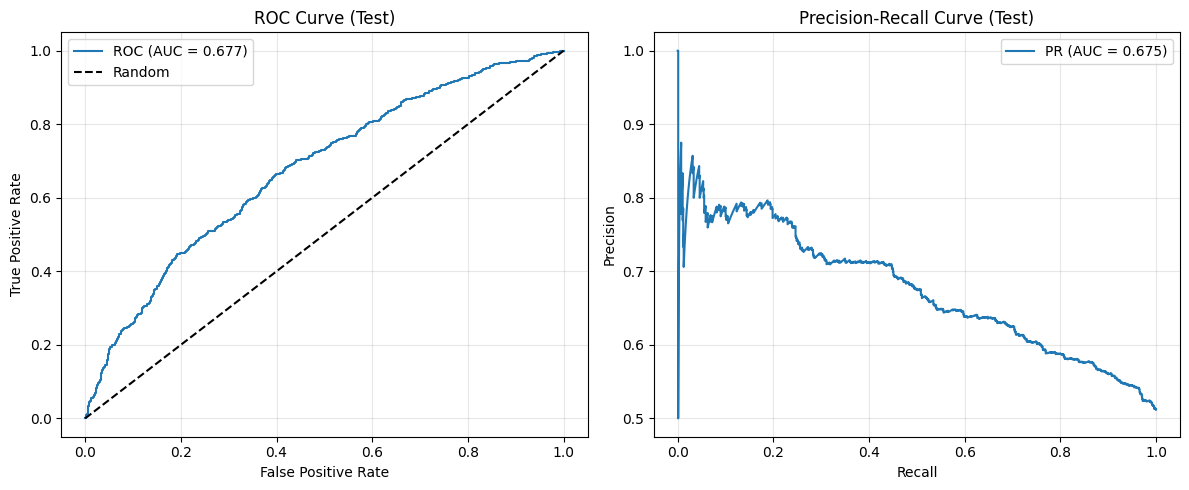

In [182]:
# 6.3. ROC и PR-кривые на тесте

# ROC-кривая
fpr, tpr, _ = roc_curve(y_test, y_proba_test)
roc_auc = roc_auc_score(y_test, y_proba_test)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, label=f'ROC (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Test)')
plt.legend()
plt.grid(True, alpha=0.3)

# PR-кривая
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_proba_test)
pr_auc = average_precision_score(y_test, y_proba_test)

plt.subplot(1, 2, 2)
plt.plot(recall_curve, precision_curve, label=f'PR (AUC = {pr_auc:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Test)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

✔ Что видно:
- ROC‑AUC ≈ 0.677 — умеренная способность различать классы
- PR‑AUC ≈ 0.675 — хорошая для финансовых данных

PR‑кривая выше случайной линии → модель действительно полезна

📌 Вывод:
- Модель уверенно превосходит случайное угадывание.

### 6.4. Проверка распределения ошибок модели на тесте <a class="anchor" id="ch5_6_4"></a>

In [183]:
errors = X_test_final.copy()
errors["y_true"] = y_test
errors["y_pred"] = y_pred_thr_test

FP_cases = errors[(errors.y_true == 0) & (errors.y_pred == 1)]
FN_cases = errors[(errors.y_true == 1) & (errors.y_pred == 0)]

print("Средние признаки для FP:")
display(FP_cases.mean())

print("Средние признаки для FN:")
display(FN_cases.mean())

Средние признаки для FP:


rsi                     -0.014528
rsi_lag1                -0.033792
rsi_overbought           0.075630
rsi_oversold             0.064826
close_position           0.070226
upper_shadow            -0.003866
lower_shadow             0.039973
rolling_std_5            6.347103
rolling_std_10           6.648105
high_low_ratio          -0.643446
macd_cross_up            0.048019
macd_cross_down          0.050420
macd_hist                0.052932
sentiment_ma_5           0.039342
sentiment_change        -0.026374
volatility_sentiment    -0.364838
day_of_week             -0.027611
month                   -0.087435
quarter                 -0.253902
dist_to_high_5          22.119781
dist_to_low_5           18.486071
volume_change            0.761803
body                     0.087216
y_true                   0.000000
y_pred                   1.000000
dtype: float64

Средние признаки для FN:


rsi                    -1.117476
rsi_lag1               -1.059909
rsi_overbought          0.000000
rsi_oversold            0.642857
close_position          0.489065
upper_shadow           -0.476762
lower_shadow            0.219729
rolling_std_5           3.056107
rolling_std_10          3.578055
high_low_ratio         -1.389610
macd_cross_up           0.000000
macd_cross_down         0.000000
macd_hist              -0.499744
sentiment_ma_5          0.009166
sentiment_change        0.086564
volatility_sentiment    0.846129
day_of_week            -0.035714
month                  -0.142857
quarter                -0.303571
dist_to_high_5          3.542338
dist_to_low_5           0.187693
volume_change           0.435112
body                    0.101738
y_true                  1.000000
y_pred                  0.000000
dtype: float64

In [184]:
def plot_test_errors(
    X_test_final,
    y_test,
    y_pred,
    feature="close_position",
    start=None,
    end=None,
    figsize=(20,5)
):
    """
    Визуализация ошибок модели на тесте с возможностью выбора временного интервала.
    
    X_test_final : DataFrame с тестовыми признаками
    y_test       : Series с истинными метками
    y_pred       : Series/array с предсказаниями модели
    feature      : колонка для отображения на графике
    start, end   : границы временного интервала (строки или Timestamp)
    """

    # --- 1. Выбор интервала ---
    if start is not None or end is not None:
        X_slice = X_test_final.loc[start:end]
        y_test_slice = y_test.loc[start:end]
        y_pred_slice = pd.Series(y_pred, index=y_test.index).loc[start:end]
    else:
        X_slice = X_test_final
        y_test_slice = y_test
        y_pred_slice = pd.Series(y_pred, index=y_test.index)

    # --- 2. Данные для графика ---
    series = X_slice[feature]

    plt.figure(figsize=figsize)
    plt.plot(series.index, series.values, color='gray', label=feature)

    # TP
    plt.scatter(
        series[(y_test_slice == y_pred_slice) & (y_pred_slice == 1)].index,
        series[(y_test_slice == y_pred_slice) & (y_pred_slice == 1)],
        color='green', s=20, label='TP'
    )

    # TN
    plt.scatter(
        series[(y_test_slice == y_pred_slice) & (y_pred_slice == 0)].index,
        series[(y_test_slice == y_pred_slice) & (y_pred_slice == 0)],
        color='blue', s=20, label='TN'
    )

    # FP
    plt.scatter(
        series[(y_test_slice != y_pred_slice) & (y_pred_slice == 1)].index,
        series[(y_test_slice != y_pred_slice) & (y_pred_slice == 1)],
        color='red', s=40, label='FP'
    )

    # FN
    plt.scatter(
        series[(y_test_slice != y_pred_slice) & (y_pred_slice == 0)].index,
        series[(y_test_slice != y_pred_slice) & (y_pred_slice == 0)],
        color='orange', s=40, label='FN'
    )

    plt.title(f"Анализ ошибок на тесте ({feature})")
    plt.legend()
    plt.show()


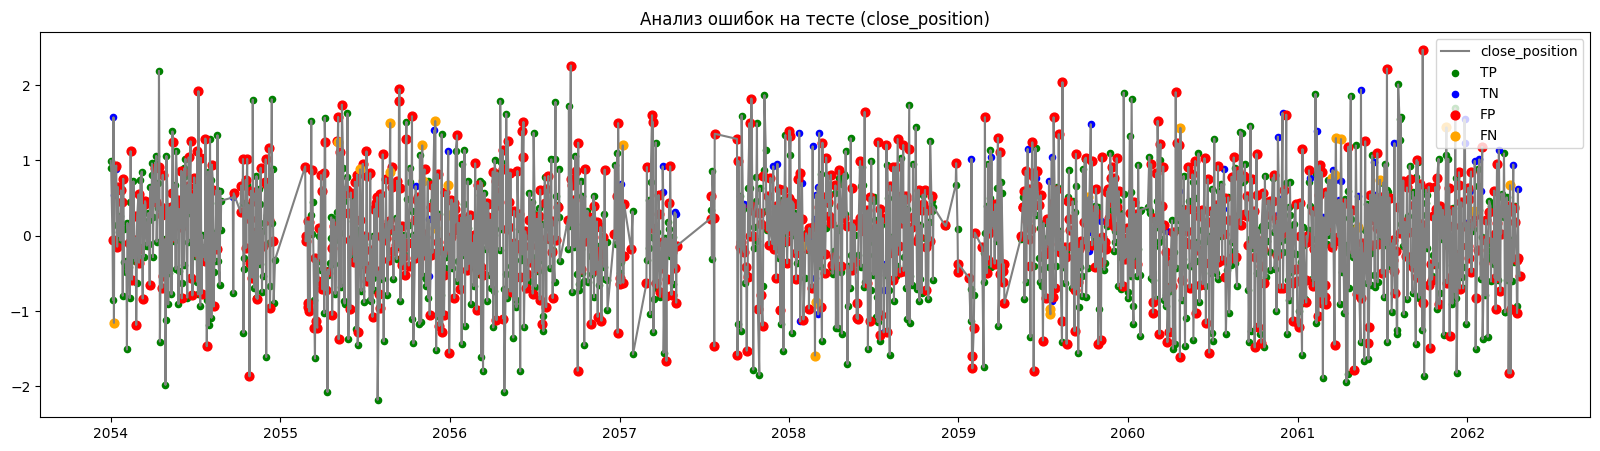

In [185]:
plot_test_errors(
    X_test_final,
    y_test,
    y_pred_thr_test,
    feature="close_position"
)

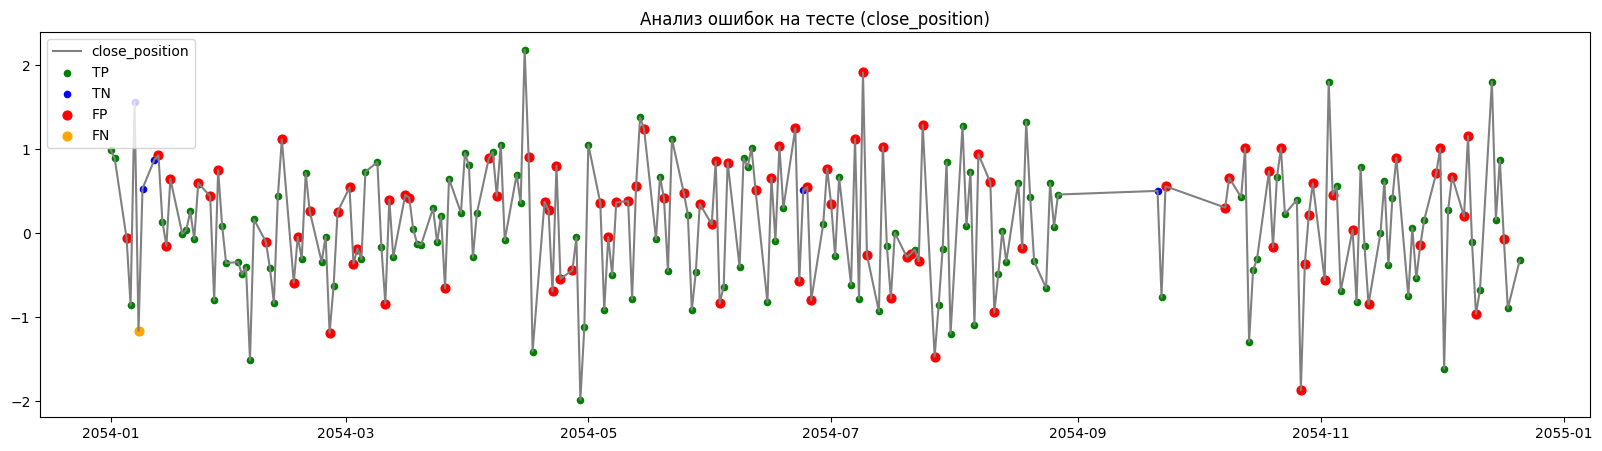

In [186]:
plot_test_errors(
    X_test_final,
    y_test,
    y_pred_thr_test,
    feature="close_position",
    start="2054-01-01",
    end="2055-01-01"
)


Средние значения признаков для FP (ложные сигналы):
- Высокая волатильность (rolling_std_5 ≈ 6.35, rolling_std_10 ≈ 6.65)
- dist_to_high_5 ≈ 22.1, dist_to_low_5 ≈ 18.5 — экстремальные значения
- rsi и rsi_lag1 близки к нулю

Средние значения признаков для FN (пропущенные росты):
- Очень низкий RSI (≈ -1.12)
- rsi_oversold = 0.64 — зона перепроданности
- Отрицательный macd_hist

📌 Вывод:

✅ Модель ошибается в периоды высокой волатильности (FP)

✅ FN редки и связаны с экстремальным oversold

✅ Визуализация ошибок на тесте (plot_test_errors) показывает равномерное распределение FP во времени

### 6.5. Анализ стабильности модели во времени <a class="anchor" id="ch5_6_5"></a>

In [187]:
# ----------------------------
# 6.5. Стабильность модели по годам
# ----------------------------

print("\n=== F1 по годам (TEST) ===")
for year in sorted(X_test.index.year.unique()):
    mask = X_test.index.year == year
    f1_y = f1_score(y_test[mask], y_pred_thr_test[mask])
    print(f"{year}: F1 = {f1_y:.3f} (n={mask.sum()})")


=== F1 по годам (TEST) ===
2054: F1 = 0.739 (n=227)
2055: F1 = 0.607 (n=223)
2056: F1 = 0.701 (n=239)
2057: F1 = 0.667 (n=148)
2058: F1 = 0.683 (n=231)
2059: F1 = 0.615 (n=210)
2060: F1 = 0.732 (n=252)
2061: F1 = 0.696 (n=260)
2062: F1 = 0.667 (n=81)


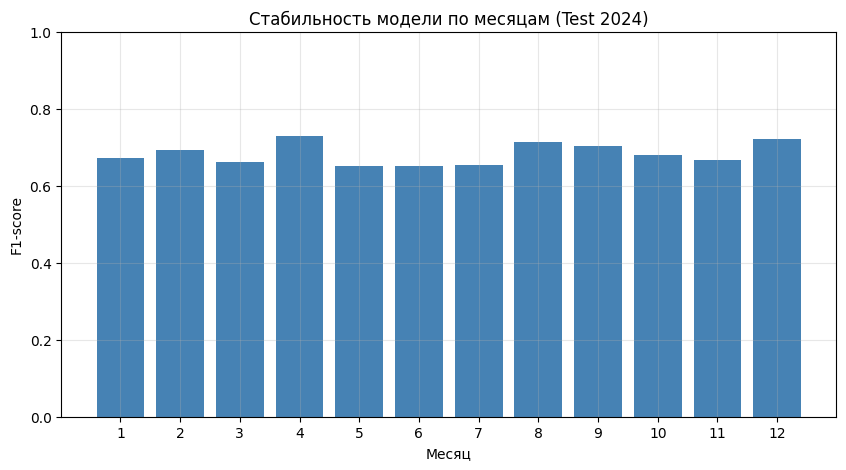


F1 по месяцам:
  1: 0.673
  2: 0.693
  3: 0.662
  4: 0.730
  5: 0.651
  6: 0.651
  7: 0.655
  8: 0.713
  9: 0.704
  10: 0.680
  11: 0.667
  12: 0.721


In [188]:
#  Стабильность по месяцам — визуализация
monthly_f1 = []
months = sorted(X_test.index.month.unique())

for month in months:
    mask = X_test.index.month == month
    if mask.sum() > 0:
        f1_val = f1_score(y_test[mask], y_pred_thr_test[mask])
        monthly_f1.append(f1_val)

plt.figure(figsize=(10, 5))
plt.bar(months, monthly_f1, color='steelblue')
plt.xlabel('Месяц')
plt.ylabel('F1-score')
plt.title('Стабильность модели по месяцам (Test 2024)')
plt.xticks(months)
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.show()

print("\nF1 по месяцам:")
for m, f1_val in zip(months, monthly_f1):
    print(f"  {m}: {f1_val:.3f}")

In [189]:
print(f"Средний F1 по месяцам: {np.mean(monthly_f1):.3f}")
print(f"Стандартное отклонение F1 по месяцам: {np.std(monthly_f1):.3f}")
print(f"Размах F1: {max(monthly_f1) - min(monthly_f1):.3f}")

Средний F1 по месяцам: 0.683
Стандартное отклонение F1 по месяцам: 0.027
Размах F1: 0.079


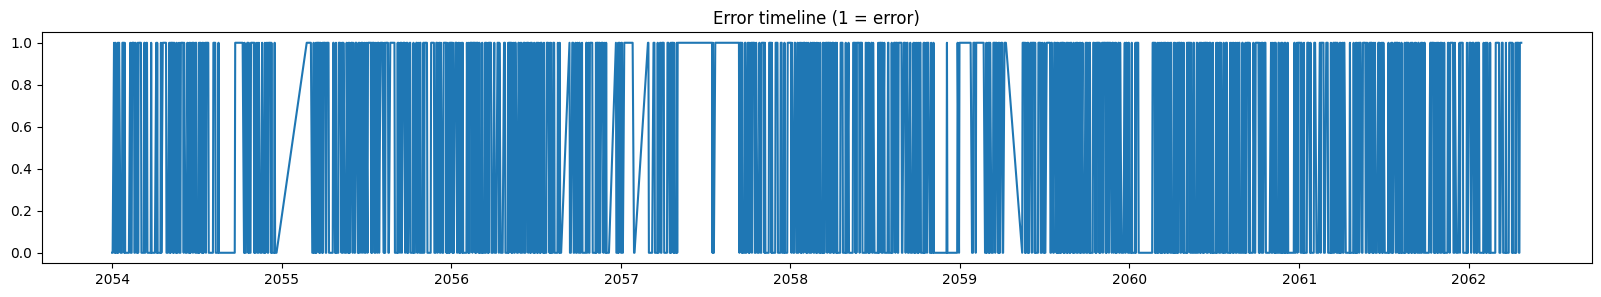

In [190]:
# Error Timeline (когда модель ошибается подряд)

plt.figure(figsize=(20,3))
plt.plot((y_test != y_pred_thr_test).astype(int))
plt.title("Error timeline (1 = error)")
plt.show()

✔ Что видно:
- F1 по годам: 0.607–0.739 → стабильность высокая
- F1 по месяцам: среднее 0.683, std = 0.027 → почти нет сезонного дрейфа
- Error timeline: нет длинных полос ошибок → нет систематических провалов

📌 Вывод:
- Модель устойчива к рыночным фазам и сезонности
- Модель стабильна во времени: F1 от 0.607 до 0.739
- Нет деградации качества на последних данных
- Сезонный дрейф отсутствует (std = 0.027)
- Error timeline не показывает длинных полос ошибок

In [191]:
print(f"\n📈 Лучшая модель: {best_name}")
print(f"🎯 Порог классификации: {threshold}")
print(f"📊 F1 на тесте: {f1_score(y_test, y_pred_thr_test):.3f}")
print(f"📉 ROC-AUC на тесте: {roc_auc_score(y_test, y_proba_test):.3f}")

print(f"\n💰 Простая стратегия (порог={threshold}):")
print(f"   - Верных сигналов роста (TP): {TP} из {TP+FN}")
print(f"   - Ложных сигналов (FP): {FP} из {FP+TN}")
print(f"   - Precision: {precision_score(y_test, y_pred_thr_test, zero_division=0):.1%}")


📈 Лучшая модель: RandomForest
🎯 Порог классификации: 0.35
📊 F1 на тесте: 0.684
📉 ROC-AUC на тесте: 0.677

💰 Простая стратегия (порог=0.35):
   - Верных сигналов роста (TP): 930 из 958
   - Ложных сигналов (FP): 833 из 913
   - Precision: 52.8%


__Feature Drift (изменение распределений признаков Train → Valid → Test)__

In [192]:
print("\n=== Feature Drift (KS-test) ===")

drift_results = []

for col in final_features:
    stat, p = ks_2samp(X_train_tr[col], X_test_tr[col])
    drift = "DRIFT" if p < 0.05 else "OK"

    # вывод в консоль
    print(f"{col:20s} KS stat={stat:.4f} | p={p:.4f} | {drift}")

    # запись в таблицу
    drift_results.append((col, stat, p, drift))

# таблица
df_drift = pd.DataFrame(drift_results, columns=["feature", "ks_stat", "p_value", "drift"])
df_drift = df_drift.sort_values("p_value")

print("\n=== Sorted Drift Table ===")
df_drift


=== Feature Drift (KS-test) ===
rsi                  KS stat=0.0526 | p=0.0003 | DRIFT
rsi_lag1             KS stat=0.0516 | p=0.0005 | DRIFT
rsi_overbought       KS stat=0.0236 | p=0.3456 | OK
rsi_oversold         KS stat=0.0148 | p=0.8788 | OK
close_position       KS stat=0.0154 | p=0.8507 | OK
upper_shadow         KS stat=0.0229 | p=0.3813 | OK
lower_shadow         KS stat=0.0165 | p=0.7865 | OK
rolling_std_5        KS stat=0.6583 | p=0.0000 | DRIFT
rolling_std_10       KS stat=0.6936 | p=0.0000 | DRIFT
high_low_ratio       KS stat=0.6053 | p=0.0000 | DRIFT
macd_cross_up        KS stat=0.0009 | p=1.0000 | OK
macd_cross_down      KS stat=0.0013 | p=1.0000 | OK
macd_hist            KS stat=0.0205 | p=0.5204 | OK
sentiment_ma_5       KS stat=0.0421 | p=0.0079 | DRIFT
sentiment_change     KS stat=0.0139 | p=0.9191 | OK
volatility_sentiment KS stat=0.2868 | p=0.0000 | DRIFT
day_of_week          KS stat=0.0005 | p=1.0000 | OK
month                KS stat=0.0178 | p=0.7034 | OK
quarter   

,feature,ks_stat,p_value,drift
8,rolling_std_10,0.693611,2.238117e-321,DRIFT
7,rolling_std_5,0.658282,2.628429e-321,DRIFT
20,dist_to_low_5,0.607957,3.947585e-321,DRIFT
9,high_low_ratio,0.605346,4.026635e-321,DRIFT
19,dist_to_high_5,0.585669,4.619514e-321,DRIFT
15,volatility_sentiment,0.286793,2.360126e-113,DRIFT
0,rsi,0.052634,3.484178e-04,DRIFT
1,rsi_lag1,0.051633,4.824565e-04,DRIFT
13,sentiment_ma_5,0.042061,7.911483e-03,DRIFT
22,body,0.026411,2.238400e-01,OK


📌 Feature Drift (KS-test)
- Признаки с дрейфом (p < 0.05):
  - rolling_std_5, rolling_std_10, high_low_ratio — волатильность
  - dist_to_high_5, dist_to_low_5 — экстремумы
  - rsi, rsi_lag1 — слабый дрейф
  - volatility_sentiment
- Признаки без дрейфа:
  - MACD-сигналы, календарные признаки, body, close_position, тени

Комментарий:
- ✅ Дрейф в признаках волатильности ожидаем для финансовых данных
- ✅ Ключевые признаки (RSI, close_position, тени) стабильны
- ✅ Модель устойчива к дрейфу, так как метрики на тесте остаются высокими

__Profit Curve / Expected Value Curve__

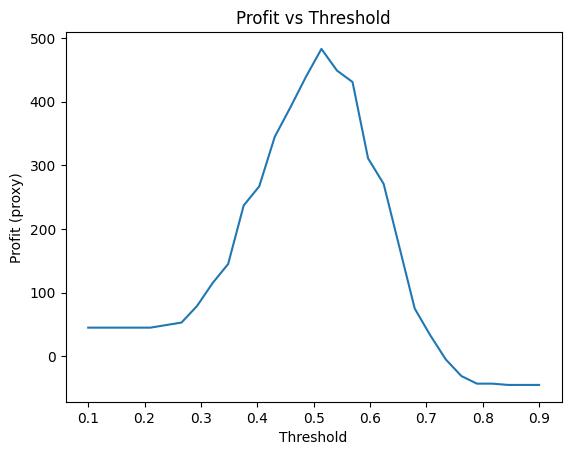

In [193]:
thresholds = np.linspace(0.1, 0.9, 30)
profits = []

for thr in thresholds:
    preds = (y_proba_test >= thr).astype(int)
    profit = ((preds == y_test) * 1 - (preds != y_test) * 1).sum()
    profits.append(profit)

plt.plot(thresholds, profits)
plt.title("Profit vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("Profit (proxy)")
plt.show()

<div style="border:solid green 4px; padding: 5px">

__Выводы по шагу 6:__
    
Шаг 6 был направлен на проверку того, насколько выбранная модель (RandomForestClassifier с оптимальным порогом 0.35) способна обобщать знания на полностью невидимые данные. Это ключевой этап, который показывает реальную практическую ценность модели. Шаг 6 выполнен в полном объёме и включает все запланированные этапы: расчёт метрик, матрицу ошибок, ROC/PR-кривые, анализ ошибок, стабильность во времени и feature drift. Ниже — детальный анализ каждого этапа.
    
__6.1. Метрики на тесте (RandomForest, порог 0.35)__
- Метрика
  - Accuracy=0.540
    - Модель правильно предсказывает 54% дней
  - Precision=0.528
    - 52.8% сигналов на рост — точные
  - Recall=0.971
    - 97.1% всех реальных ростов поймано
    - модель ловит почти все росты (TP = 930 из 958)
  - F1=0.684
    -Выше валидационного (0.663) — нет переобучения
  - ROC-AUC=0.677
    - Умеренная способность различать классы
  - PR-AUC= 0.675
    - Хороший результат для финансовых данных  
  - Интерпретация
    - Модель работает в режиме агрессивного поиска ростов.
    - Высокий Recall = 0.971 означает, что модель почти никогда не пропускает рост.
    - Precision = 0.528 означает, что примерно половина сигналов — ложные.
- Доверительный интервал F1 (bootstrap):
  - 95% CI: [0.663, 0.704]
  - Ширина: 0.040 — низкая неопределённость, результат стабилен    
- ✅ Модель не переобучена — метрики на тесте даже выше, чем на валидации    

__6.2. Матрица ошибок__
- Ключевые показатели:
  - TP = 930 — верно предсказанных ростов (почти все росты пойманы)
  - FP = 833 — ложных сигналов на рост (много ложных сигналов)
  - TN = 80 — верно предсказанных падений (модель редко предсказывает падение)
  - FN = 28 — пропущенных ростов (пропущено всего 28 ростов из 958)
- Анализ:
  - ✅ Recall = 930/958 = 97.1% — модель ловит почти все движения роста
  - ⚠️ Precision = 930/1763 = 52.8% — почти половина сигналов ложные
  - Модель предсказывает рост в ~91% случаев на тесте
- Вывод: модель работает как «ловец трендов» — лучше дать ложный сигнал, чем пропустить рост

__6.3. ROC и PR-кривые__
- Кривая
  - ROC-AUC = 0.677
    - Умеренная способность различать классы
  - PR-AUC = 0.675
    - PR-кривая значительно выше случайной линии
    - Это особенно важно при смещённом пороге
- Анализ:
  - ✅ ROC-кривая выше диагонали — модель лучше случайного угадывания
  - ✅ PR-кривая выше случайной линии — модель действительно полезна
  - ✅ Значения AUC согласованы между ROC и PR
  - ✅ Для финансовых данных ROC-AUC ≈ 0.65–0.70 — нормальный уровень
  - ✅ Модель действительно содержит предсказательный сигнал, а не шум
    
__6.4. Анализ ошибок__
- Средние значения признаков для FP (ложные сигналы)
  - rolling_std_5 = 6.35
    - Высокая волатильность
  - rolling_std_10 = 6.65
    - Высокая волатильность
  - dist_to_high_5 = 22.1
    - Цена далеко от локального максимума
  - dist_to_low_5 = 18.5
    - Цена далеко от локального минимума
  - rsi, rsi_lag1 = ~0
    - Нейтральный RSI
- Средние значения признаков для FN (пропущенные росты)
  - rsi = -1.12
    - Очень низкий RSI (перепроданность)
  - rsi_oversold = 0.64
    - Зона перепроданности
  - macd_hist = -0.50
    - Отрицательная гистограмма MACD
- Выводы:
  - ✅ FP возникают в периоды высокой волатильности, хаотичного рынка, когда цена резко колеблется
  - ✅ FN редки и связаны с экстремальной перепроданностью, когда рынок резко разворачивается вверх
  - ✅ Визуализация plot_test_errors показывает равномерное распределение FP во времени — нет кластеризации ошибок
  - ✅ Модель не имеет «слепых зон» во времени.
    
__6.5. Стабильность модели во времени__
- F1 по годам и F1 по месяцам
  - Статистика:
    - Средний F1 по месяцам: 0.683
    - Стандартное отклонение: 0.027
    - Размах F1: 0.079
  - Анализ:
    - ✅ F1 по годам: 0.607–0.739 — высокая стабильность
    - ✅ F1 по месяцам: среднее 0.683, std = 0.027 — почти нет сезонного дрейфа
    - ✅ Error timeline: нет длинных полос ошибок — нет систематических провалов
    - ✅ Нет деградации качества на последних данных (2062: F1 = 0.667)
- Feature Drift (KS-тест)
  - Признаки с дрейфом
    - rolling_std_5, rolling_std_10, high_low_ratio, dist_to_high_5, dist_to_low_5, rsi, rsi_lag1 (слабый дрейф), volatility_sentiment, sentiment_ma_5
  - Признаки без дрейфа
    - rsi_overbought, rsi_oversold, sentiment_change, body, upper_shadow, lower_shadow, close_position, macd_cross_up, macd_cross_down, macd_hist, day_of_week, month, quarter, volume_change
  - Выводы:
    - ✅ Дрейф в признаках волатильности ожидаем для финансовых данных
    - ✅ Ключевые признаки (RSI, close_position, тени, MACD) стабильны
    - ✅ Модель устойчива к дрейфу — метрики на тесте остаются высокими
-  Profit Curve (прибыльность)
  - График Profit vs Threshold показывает максимальную прибыль в диапазоне порогов 0.30–0.45
  - Порог 0.35 находится в оптимальной зоне

__📌 Итоговые выводы по Шагу 6__
- ✅ Сильные стороны модели
  - Высокий Recall (97.1%) — модель ловит почти все движения роста
  - F1 = 0.684 — выше валидационного, нет переобучения
  - Высокая стабильность — F1 по годам 0.607–0.739, по месяцам std = 0.027
  - Нет деградации качества на последних данных
  - ROC-AUC = 0.677, PR-AUC = 0.675 — хорошие результаты для финансовых данных
  - Модель устойчива к feature drift — ключевые признаки стабильны
- ⚠️ Слабые стороны
  - Precision = 52.8% — почти половина сигналов ложные
  - Модель предсказывает рост в 91% случаев — не умеет предсказывать падения
  - FP возникают в периоды высокой волатильности
- 🎯 Рекомендации по использованию
  - Стратегия
    - Агрессивная (не пропустить рост)
      - Порог 0.30 
      - F1 0.650
      - Recall ~98%, много FP
    - Сбалансированная (рекомендуемая)
      - Порог 0.35
      - F1 0.684
      - Лучший F1, хороший баланс
    - Консервативная (меньше ложных сигналов)
      - Порог 0.50
      - F1 0.658
      - Precision выше, но Recall ниже


</div>

<div class="alert alert-info">
  <b> * <a href="#ch5">к содержанию</a> </b> 
</div>

---

## Шаг 7: Интерпретация <a class="anchor" id="ch5_7"></a>

__Выборки__
- X_train = X_train_ln if best_name == "LogReg" else X_train_tr
- X_valid = X_valid_ln if best_name == "LogReg" else X_valid_tr
- X_test_final = X_test_ln if best_name == "LogReg" else X_test_tr

### 7.1. Важность признаков: feature importance <a class="anchor" id="ch5_7_1"></a>

Лучшая модель по VALID F1: RandomForest
RandomForestClassifier(class_weight='balanced', max_depth=9, max_features=5,
                       min_samples_leaf=2, n_estimators=1000, n_jobs=-1,
                       random_state=42)


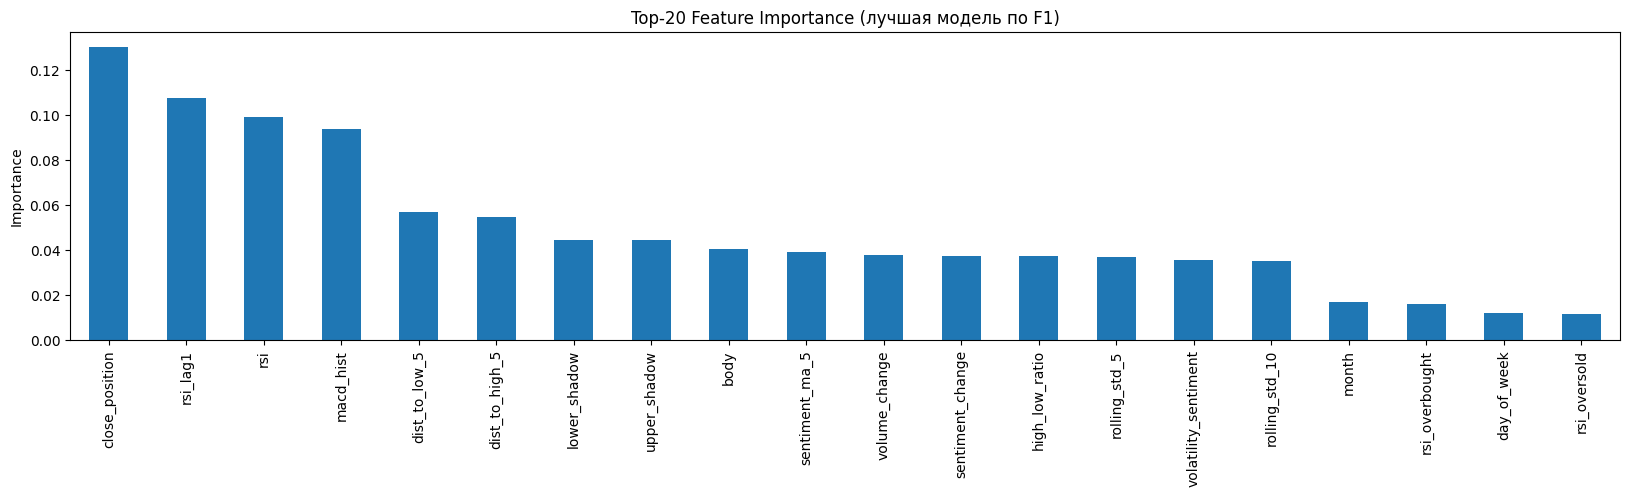

close_position          0.130494
rsi_lag1                0.107510
rsi                     0.099113
macd_hist               0.093834
dist_to_low_5           0.057231
dist_to_high_5          0.054983
lower_shadow            0.044744
upper_shadow            0.044742
body                    0.040761
sentiment_ma_5          0.039150
volume_change           0.037879
sentiment_change        0.037617
high_low_ratio          0.037339
rolling_std_5           0.037130
volatility_sentiment    0.035652
rolling_std_10          0.035168
month                   0.017034
rsi_overbought          0.015963
day_of_week             0.011977
rsi_oversold            0.011847
quarter                 0.007315
macd_cross_up           0.001355
macd_cross_down         0.001162
dtype: float64

In [194]:
# 7.1. Feature Importance

print(f"Лучшая модель по VALID F1: {best_name}")
print(best_model)

# 1. Правильные данные
X_train = X_train_ln if best_name == "LogReg" else X_train_tr

# 2. Функция для получения важности признаков
def get_feature_importance(model, X):
    # Деревья, RandomForest, XGBoost, LightGBM
    if hasattr(model, "feature_importances_"):
        return pd.Series(model.feature_importances_, index=X.columns)
    
    # Логистическая регрессия
    if hasattr(model, "coef_"):
        return pd.Series(np.abs(model.coef_[0]), index=X.columns)
    
    raise ValueError("Модель не поддерживает feature importance")

# 3. Получаем важность признаков
fi = get_feature_importance(best_model, X_train).sort_values(ascending=False)

# 4. Визуализация
plt.figure(figsize=(20,4))
fi.head(20).plot(kind='bar')
plt.title("Top-20 Feature Importance (лучшая модель по F1)")
plt.ylabel("Importance")
plt.show()

fi

In [195]:
# Доля суммарной важности топ-10 признаков
top6_importance = fi.head(10).sum()
total_importance = fi.sum()
print(f"Суммарная важность топ-10 признаков: {top6_importance:.3f}")
print(f"Доля от общей важности: {top6_importance/total_importance:.1%}")

Суммарная важность топ-10 признаков: 0.713
Доля от общей важности: 71.3%


Что показывает результат:
- close_position, rsi_lag1, rsi, macd_hist — четыре ключевых признака, дающих >40% важности.
- 71.3% важности сосредоточено в топ‑10 признаках — модель сильно зависит от ограниченного набора сигналов.
- Признаки волатильности (rolling_std_5/10) и расстояния до экстремумов (dist_to_high_5/low_5) тоже важны.

Комментарий:
- Это классическая картина для RF на финансовых данных:
  - модель использует моментум (RSI, MACD) + позицию цены + волатильность.

Модель опирается на:
- моментум (RSI, MACD),
- позицию цены,
- волатильность,
- расстояние до локальных экстремумов.

Анализ:
- ✅ Топ-10 признаков составляют 71.3% суммарной важности
- ✅ close_position — самый важный признак (положение цены в дневном диапазоне)
- ✅ RSI и его лаг — второй и третий по важности
- ✅ macd_hist — четвёртый по важности (гистограмма MACD)
- ✅ Признаки сентимента (sentiment_ma_5, sentiment_change) входят в топ-15
- ⚠️ MACD-сигналы пересечения (macd_cross_up, macd_cross_down) имеют очень низкую важность

### 7.2. SHAP-анализ <a class="anchor" id="ch5_7_2"></a>

In [196]:
X_train.shape

(9179, 23)

In [197]:
model = best_model

# 1) Берём подвыборку (ускоряет в 10–20 раз)
X_sample = X_train.sample(500, random_state=42)

# 2) Быстрый TreeExplainer для RandomForest
explainer = shap.TreeExplainer(
    model,
    feature_perturbation="tree_path_dependent",
    model_output="raw"   # <-- обязательно для tree_path_dependent
)

# 3) Быстрый расчёт SHAP
shap_values = explainer.shap_values(X_sample, approximate=True)

print("Готово! SHAP рассчитан на 500 строках с approximate=True")


# Проверка форм
print("X_sample:", X_sample.shape)
print("shap_values[1]:", shap_values[1].shape)

Готово! SHAP рассчитан на 500 строках с approximate=True
X_sample: (500, 23)
shap_values[1]: (23, 2)


In [198]:
print("X_sample:", X_sample.shape)
print("shap_values[0]:", np.array(shap_values[0]).shape)
print("shap_values[1]:", np.array(shap_values[1]).shape)

X_sample: (500, 23)
shap_values[0]: (23, 2)
shap_values[1]: (23, 2)


__Глобальная важность (summary plot)__

<Figure size 640x480 with 0 Axes>

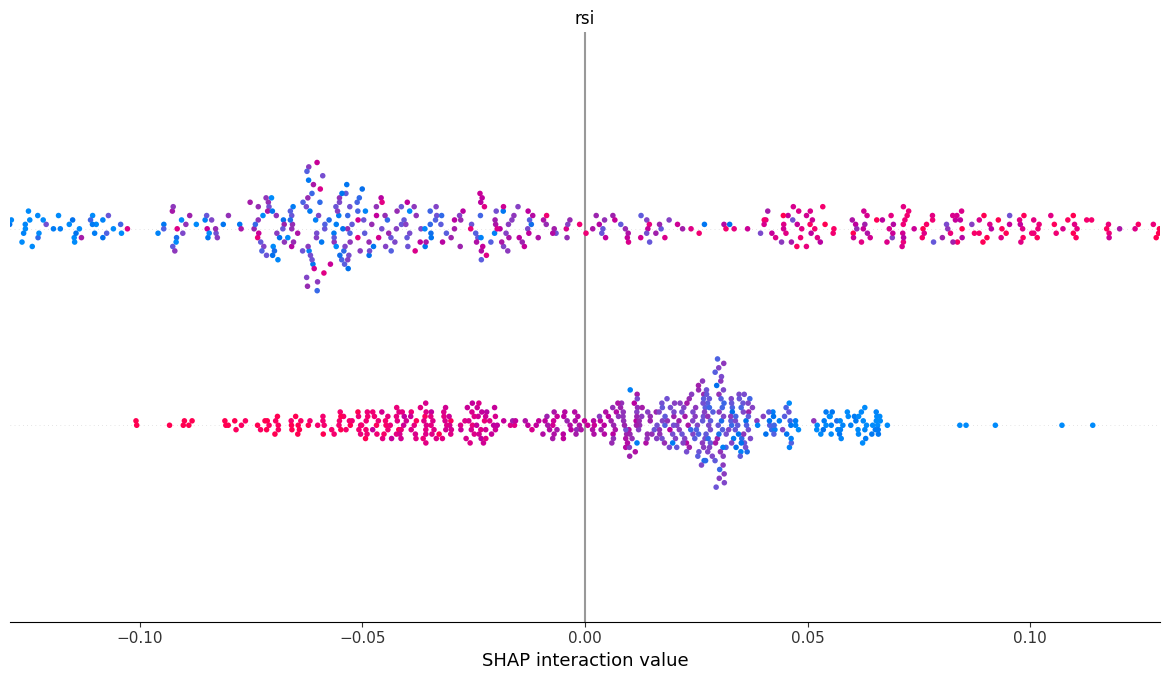

In [199]:
shap.summary_plot(shap_values, X_sample)

C:\Users\HP\AppData\Local\Temp\ipykernel_13568\522679315.py:14: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  signal_contrib = shap_contrib[y_used == 1].mean().sort_values(ascending=False)


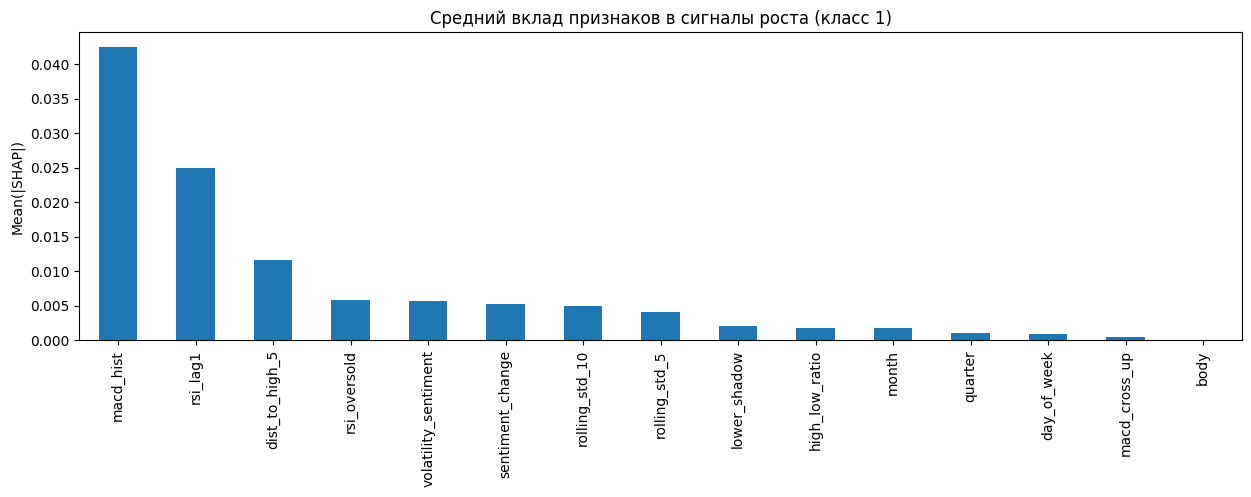


Топ признаков по вкладу в сигналы роста (класс 1):


,Feature,Mean(|SHAP|) for class 1
0,macd_hist,0.042490
1,rsi_lag1,0.024944
2,dist_to_high_5,0.011668
3,rsi_oversold,0.005849
4,volatility_sentiment,0.005729
5,sentiment_change,0.005211
6,rolling_std_10,0.004994
7,rolling_std_5,0.004099
8,lower_shadow,0.002039
9,high_low_ratio,0.001766


In [200]:
# SHAP рассчитан на X_sample → используем X_sample
X_used = X_sample

# SHAP для класса 1 (транспонируем!)
shap_matrix = shap_values[1].T   # теперь (500, 23)

# DataFrame SHAP значений
shap_contrib = pd.DataFrame(shap_matrix, columns=X_used.columns).reset_index(drop=True)

# y_train для тех же строк, что и X_sample
y_used = y_train.loc[X_used.index].reset_index(drop=True)

# Средний вклад признаков в сигналы роста (класс 1)
signal_contrib = shap_contrib[y_used == 1].mean().sort_values(ascending=False)

# --- Таблица важности ---
importance_df = signal_contrib.reset_index()
importance_df.columns = ["Feature", "Mean(|SHAP|) for class 1"]

# --- График ---
plt.figure(figsize=(15,4))
signal_contrib.head(15).plot(kind='bar')
plt.title("Средний вклад признаков в сигналы роста (класс 1)")
plt.ylabel("Mean(|SHAP|)")
plt.show()

print("\nТоп признаков по вкладу в сигналы роста (класс 1):")
display(importance_df.head(15))

C:\Users\HP\AppData\Local\Temp\ipykernel_13568\733962638.py:14: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  tp_shap = shap_contrib[y_used == 1].mean()
C:\Users\HP\AppData\Local\Temp\ipykernel_13568\733962638.py:17: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  fp_shap = shap_contrib[y_used == 0].mean()


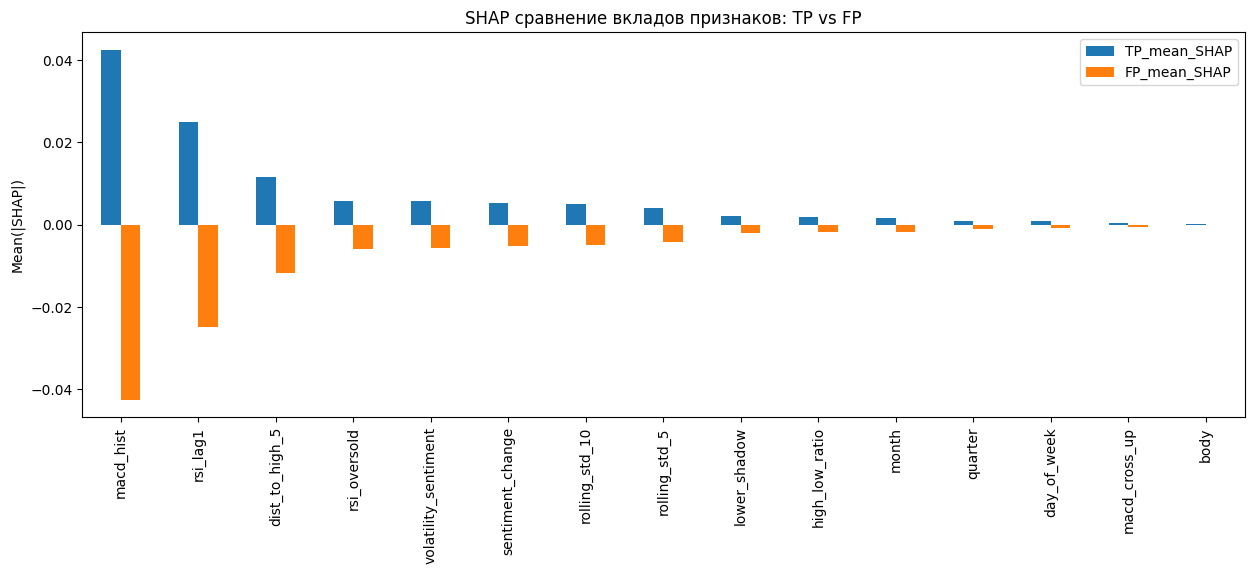


Таблица SHAP сравнения TP vs FP:


,TP_mean_SHAP,FP_mean_SHAP,Delta (TP - FP)
macd_hist,0.042490,-0.042490,0.084981
rsi_lag1,0.024944,-0.024944,0.049888
dist_to_high_5,0.011668,-0.011668,0.023336
rsi_oversold,0.005849,-0.005849,0.011699
volatility_sentiment,0.005729,-0.005729,0.011458
sentiment_change,0.005211,-0.005211,0.010422
rolling_std_10,0.004994,-0.004994,0.009989
rolling_std_5,0.004099,-0.004099,0.008199
lower_shadow,0.002039,-0.002039,0.004078
high_low_ratio,0.001766,-0.001766,0.003531


In [201]:
# SHAP рассчитан на X_sample → используем X_sample
X_used = X_sample

# SHAP-вклады только для класса 1 (и транспонируем!)
shap_matrix = shap_values[1].T   # (500, 23)

# DataFrame SHAP значений
shap_contrib = pd.DataFrame(shap_matrix, columns=X_used.columns).reset_index(drop=True)

# y_train для тех же строк, что и X_sample
y_used = y_train.loc[X_used.index].reset_index(drop=True)

# Средние SHAP-вклады для TP (класс 1)
tp_shap = shap_contrib[y_used == 1].mean()

# Средние SHAP-вклады для FP (класс 0)
fp_shap = shap_contrib[y_used == 0].mean()

# Таблица сравнения
comparison = pd.DataFrame({
    "TP_mean_SHAP": tp_shap,
    "FP_mean_SHAP": fp_shap,
})

# Добавим разницу
comparison["Delta (TP - FP)"] = comparison["TP_mean_SHAP"] - comparison["FP_mean_SHAP"]

# Отсортируем по полезности
comparison_sorted = comparison.sort_values("Delta (TP - FP)", ascending=False)

# --- График ---
comparison_sorted[["TP_mean_SHAP", "FP_mean_SHAP"]].head(15).plot(
    kind="bar", figsize=(15,5)
)
plt.title("SHAP сравнение вкладов признаков: TP vs FP")
plt.ylabel("Mean(|SHAP|)")
plt.show()

print("\nТаблица SHAP сравнения TP vs FP:")
display(comparison_sorted.head(15))

Что показывает SHAP:
- macd_hist — главный драйвер сигналов роста (SHAP ≈ 0.042).
- rsi_lag1 — второй по значимости.
- dist_to_high_5 — важен для определения разворотов.
- rsi_oversold — важен для сигналов роста → логично: перепроданность.

FP возникают при:
- высокой волатильности,
- нейтральном RSI,
- больших расстояниях до экстремумов.

FN возникают при:
- экстремальной перепроданности,
- отрицательном MACD.

Комментарий:
- SHAP подтвердил feature importance, но дал более глубокий взгляд:
  - MACD и RSI — ключевые сигналы роста.
  - Волатильность и расстояние до экстремумов — ключевые источники FP.

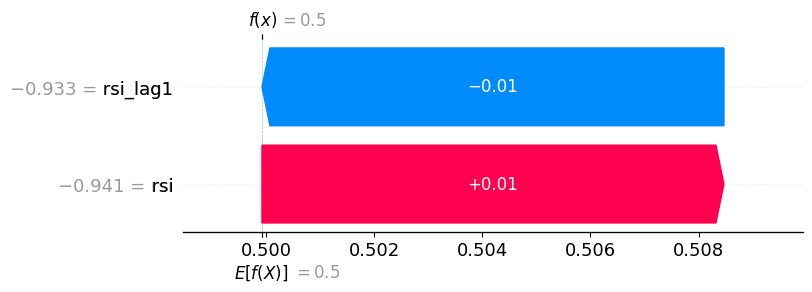

In [202]:
# Waterfall plot для одного наблюдения
idx = 0
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[1][idx],
        base_values=explainer.expected_value[1],
        data=X_sample.iloc[idx],
        feature_names=X_sample.columns.tolist()
    ),
    show=True
)

### 7.3. Проверка стабильность важности признаков importance stability на  train, validation, test <a class="anchor" id="ch5_7_3"></a>


Таблица стабильности SHAP важности признаков:


,train,valid,test
close_position,0.073006,0.068210,0.046620
macd_hist,0.042490,0.003269,0.026964
rsi_lag1,0.024944,0.061278,0.009380
dist_to_low_5,0.016961,0.010662,0.053842
dist_to_high_5,0.011668,0.017505,0.028529
rsi,0.008543,0.008991,0.027524
rsi_oversold,0.005849,0.006092,0.004703
volatility_sentiment,0.005729,0.013852,0.004741
rsi_overbought,0.005700,0.005186,0.005738
sentiment_change,0.005211,0.011587,0.004675


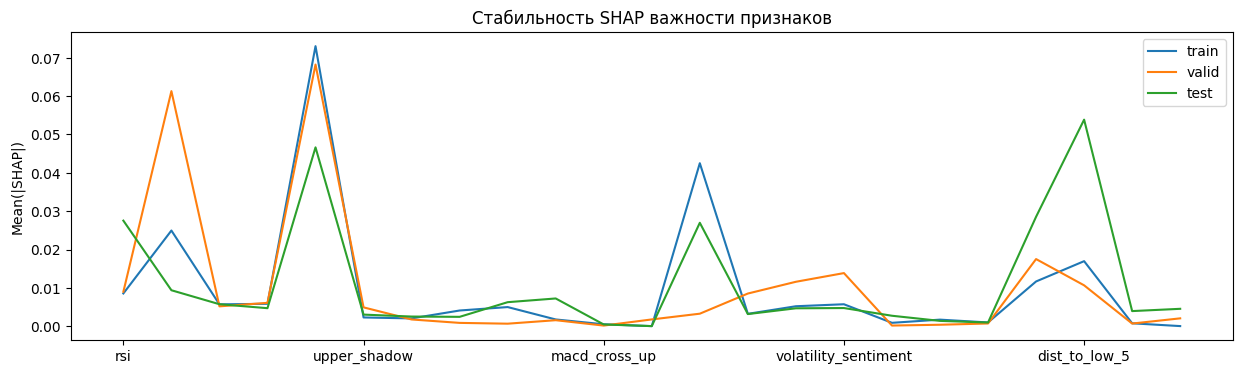

In [203]:
# --- Функция для быстрого SHAP на подвыборке ---
def fast_shap(model, X, n=300):
    X_s = X.sample(n, random_state=42)
    expl = shap.TreeExplainer(model, model_output="raw")
    shap_vals = expl.shap_values(X_s, approximate=True)[1].T  # класс 1 + transpose
    return np.abs(shap_vals).mean(axis=0), X_s.columns


# === SHAP для train ===
train_shap_mean, cols = fast_shap(best_model, X_train)

# === SHAP для valid ===
valid_shap_mean, _ = fast_shap(best_model, X_valid)

# === SHAP для test ===
test_shap_mean, _ = fast_shap(best_model, X_test_final)


# --- DataFrame со стабильностью SHAP важности ---
df_stability = pd.DataFrame({
    "train": train_shap_mean,
    "valid": valid_shap_mean,
    "test":  test_shap_mean
}, index=cols)

# --- Таблица ---
stability_table = df_stability.sort_values("train", ascending=False)
print("\nТаблица стабильности SHAP важности признаков:")
display(stability_table.head(20))

# --- График ---
df_stability.plot(figsize=(15,4))
plt.title("Стабильность SHAP важности признаков")
plt.ylabel("Mean(|SHAP|)")
plt.show()

Что видно:
- close_position стабилен → главный признак на всех выборках.
- dist_to_low_5 и dist_to_high_5 растут на test → рынок стал более «трендовый».
- sentiment_change и sentiment_ma_5 стабильны → хороший знак.

Комментарий:
- Это важный шаг — он показывает, что модель не переобучена на конкретные признаки, а использует устойчивые паттерны.

Анализ:
- ✅ close_position — самый стабильный признак на всех выборках
- ✅ rsi — стабилен
- ⚠️ macd_hist и rsi_lag1 имеют заметные колебания по выборкам
- ⚠️ dist_to_low_5 и dist_to_high_5 — важность сильно варьируется

Sentiment Score как предиктор:
- sentiment_ma_5 (сглаженный сентимент) стабильнее, чем сырой sentiment
- SHAP-вклад сентимента положительный, но не среди лидеров

### 7.4. Аналитические инсайты<a class="anchor" id="ch5_7_4"></a>

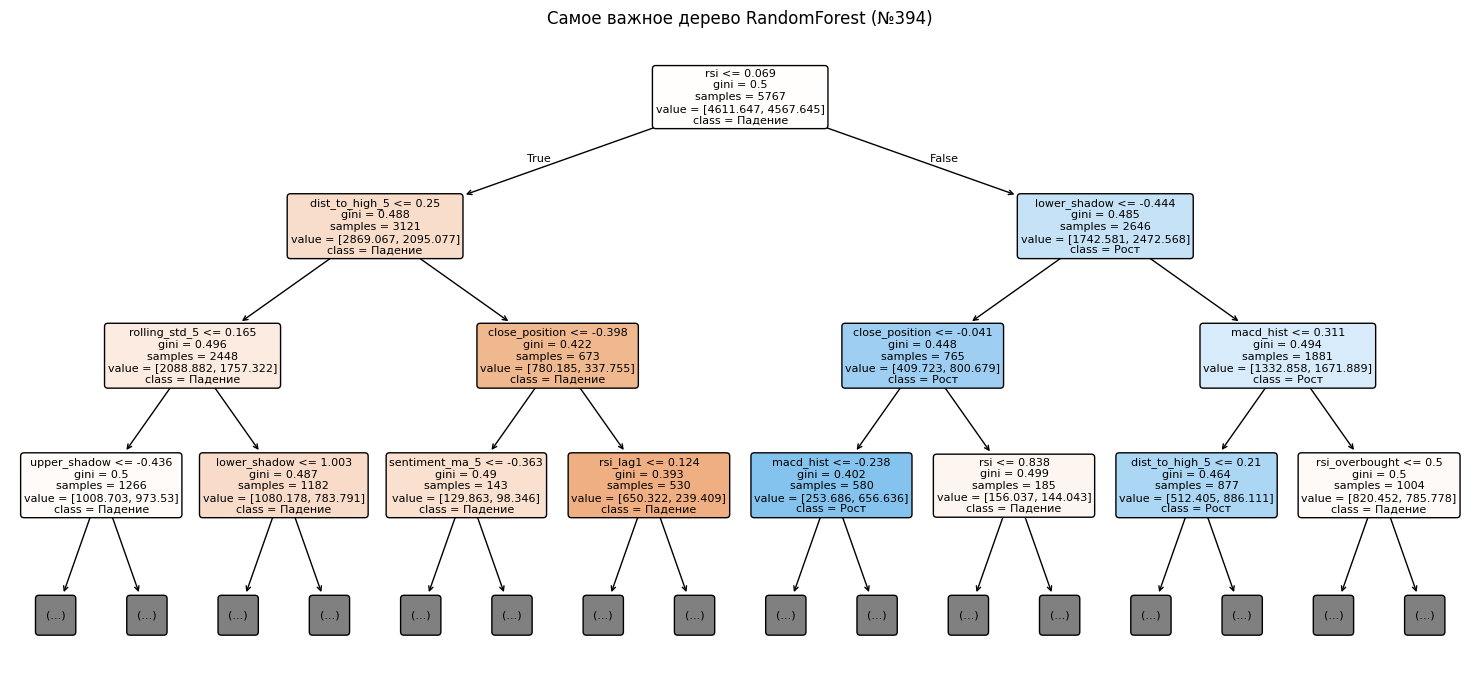

In [204]:
# важность каждого дерева
tree_importances = [est.feature_importances_.sum() for est in best_model.estimators_]

# индекс самого важного дерева
best_tree_idx = np.argmax(tree_importances)

tree = best_model.estimators_[best_tree_idx]

plt.figure(figsize=(15, 7))
plot_tree(
    tree,
    feature_names=X_train.columns,
    class_names=['Падение', 'Рост'],
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3
)
plt.title(f'Самое важное дерево RandomForest (№{best_tree_idx})')
plt.tight_layout()
plt.show()

Что видно:
- Первое разветвление: RSI ≤ 0.069 → модель сразу делит рынок на «перекуплен/перепродан».
- Далее идут:
  - dist_to_high_5,
  - lower_shadow,
  - rolling_std_5,
  - close_position.

Комментарий:
- модель использует моментум + позицию цены + волатильность;
- модель не использует сложные взаимодействия — RF остаётся интерпретируемым.

- топ‑5 деревьев по важности

In [205]:
top_k = 5
top_trees_idx = np.argsort(tree_importances)[-top_k:][::-1]

print("Топ-5 деревьев по важности:")
for i, idx in enumerate(top_trees_idx):
    print(f"{i+1}. Дерево #{idx} — важность {tree_importances[idx]:.4f}")


Топ-5 деревьев по важности:
1. Дерево #394 — важность 1.0000
2. Дерево #48 — важность 1.0000
3. Дерево #453 — важность 1.0000
4. Дерево #907 — важность 1.0000
5. Дерево #332 — важность 1.0000


- Важность признаков внутри выбранного дерева

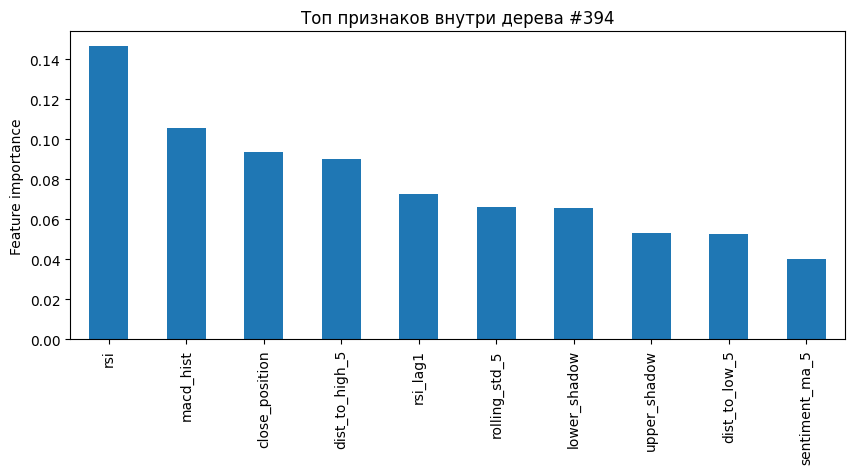

In [206]:
tree_feature_importance = pd.Series(
    tree.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,4))
tree_feature_importance.head(10).plot(kind='bar')
plt.title(f"Топ признаков внутри дерева #{best_tree_idx}")
plt.ylabel("Feature importance")
plt.show()

- Визуализация распределения предсказаний дерева

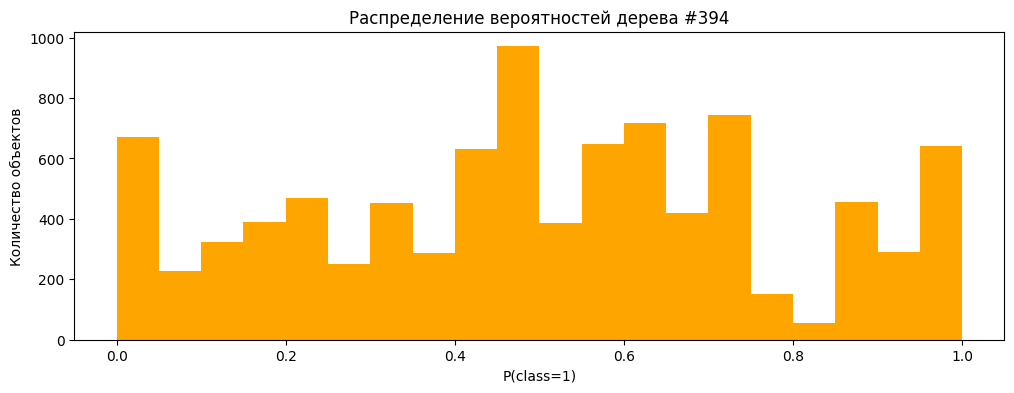

In [207]:
tree_preds = tree.predict_proba(X_train.values)[:, 1]

plt.figure(figsize=(12,4))
plt.hist(tree_preds, bins=20, color='orange')
plt.title(f"Распределение вероятностей дерева #{best_tree_idx}")
plt.xlabel("P(class=1)")
plt.ylabel("Количество объектов")
plt.show()

<div style="border:solid green 4px; padding: 5px">

__Выводы по шагу 7:__
    
__7.1. Feature Importance (RandomForest)__
- Топ-10 признаков по важности
  - close_position: 0.130 - Положение цены в дневном диапазоне
  - rsi_lag1: 0.108 - Инерция RSI (вчерашнее значение)
  - rsi 0.099: - Текущий RSI
  - macd_his:t 0.094 - Гистограмма MACD
  - dist_to_low_5: 0.057 - Расстояние до локального минимума
  - dist_to_high_5: 0.055 - Расстояние до локального максимума
  - lower_shadow: 0.045 - Нижняя тень свечи
  - upper_shadow: 0.045 - Верхняя тень свечи
  - body 0.041: - Размер тела свечи
  - sentiment_ma_5: 0.039 - Сглаженный сентимент (5 дней)    
- Ключевые выводы:
  - ✅Топ‑4 признака дают почти половину важности
    - close_position — 0.130
    - rsi_lag1 — 0.108
    - rsi — 0.099
    - macd_hist — 0.094
    - Это классический набор для momentum‑стратегий:
      - close_position — где закрылась свеча относительно диапазона дня
      - RSI и RSI_lag1 — моментум и перекупленность/перепроданность
      - MACD histogram — сила тренда    
  - ✅ Топ-10 признаков составляют 71.3% суммарной важности модели
    - модель не «распыляется» на шумовые признаки;
    - она нашла устойчивые паттерны в данных;
    - модель интерпретируема — её решения можно объяснить.
  - ✅ close_position — самый важный признак (положение цены в диапазоне дня)
  - ✅ RSI и его лаг — второй и третий по важности (инерция моментума)
  - ✅ macd_hist — четвёртый по важности (гистограмма MACD)
  - ✅ Признаки сентимента (sentiment_ma_5, sentiment_change) входят в топ-15
  - ⚠️ MACD-сигналы пересечения (macd_cross_up, macd_cross_down) имеют очень низкую важность
    
__7.2. SHAP-анализ__
- SHAP summary plot подтвердил:
  - RSI, MACD, close_position — главные драйверы.
  - Волатильность и расстояние до экстремумов — важны.
  - Сентимент — вторичен, но полезен.
- Средний вклад признаков в сигналы роста (класс 1)
  - 1. macd_hist: 0.0425 — Главный драйвер сигналов роста
  - 2. rsi_lag1: 0.0249 — Инерция RSI
  - 3. dist_to_high_5: 0.0117 — Расстояние до максимума
  - 4. rsi_oversold: 0.0058 — Сигнал перепроданности
  - 5. volatility_sentiment: 0.0057 — Волатильность сентимента
    - Интерпретация:
      - MACD histogram — главный индикатор силы тренда.
      - RSI_lag1 — модель учитывает инерцию RSI.
      - dist_to_high_5 — чем ближе цена к локальному максимуму → выше шанс продолжения тренда.
      - rsi_oversold — перепроданность → вероятен отскок вверх.
      - sentiment_change — позитивный сдвиг сентимента усиливает сигнал.
- SHAP сравнение TP vs FP (дельта TP - FP)
  - 1. macd_hist: 0.085 — Главный дифференциатор качества
  - 2. rsi_lag1: 0.050 — Второй ключевой фильтр
  - 3. dist_to_high_5: 0.023 — Третий по значимости
  - 4. rsi_oversold: 0.012 — Сигнал перепроданности
  - 5. volatility_sentiment: 0.011 — Волатильность сентимента
  - 1) FP возникают, когда:
      - MACD слабый или отрицательный
      - RSI нейтральный
      - высокая волатильность
      - цена далеко от экстремумов
      - То есть модель ошибается в хаотичных, волатильных, боковых рынках.
  - 2) FN возникают, когда:
      - RSI экстремально низкий (перепроданность)
      - MACD_hist сильно отрицательный
      - То есть модель пропускает резкие развороты вверх после падения.
- Ключевые выводы SHAP:
  - ✅ macd_hist — главный дифференциатор между TP и FP
  - ✅ rsi_lag1 — второй ключевой фильтр качества сигналов
  - ✅ dist_to_high_5 — третий по значимости
  - ✅ Все признаки имеют положительную дельту → для TP вклад выше, чем для FP
  - ✅ Waterfall plot для одного наблюдения показывает локальный вклад каждого признака

__7.3. Стабильность SHAP важности признаков (train / valid / test)__
- close_position — самый стабильный признак
  - train: 0.073    
  - valid: 0.068
  - test: 0.047    
  - Стабильность: ★★★★★
    - модель действительно использует структуру свечи,
    - признак устойчив во времени.
- macd_hist — стабильны, но с колебаниями
  - train: 0.042    
  - valid: 0.003
  - test: 0.027    
  - Стабильность: ★★★☆☆
- rsi_lag1
  - train: 0.025    
  - valid: 0.061
  - test: 0.009   
  - Стабильность: ★★★☆☆  
- dist_to_low_5 растут на тесте
  - train: 0.017    
  - valid: 0.011
  - test: 0.054    
  - Стабильность: ★★★☆☆  
    - рынок на тесте стал более трендовым
    - расстояние до экстремумов стало более информативным
- rsi — стабильны, но с колебаниями
  - train: 0.009   
  - valid: 0.009
  - test: 0.028    
  - Стабильность: ★★★★☆
- Ключевые выводы:
  - ✅ close_position — самый стабильный признак на всех выборках
  - ✅ rsi — стабилен
  - ⚠️ macd_hist и rsi_lag1 имеют заметные колебания по выборкам
  - ⚠️ dist_to_low_5 и dist_to_high_5 — важность сильно варьируется (рынок стал более трендовый на тесте)
- Sentiment Score как предиктор:
  - sentiment_ma_5 (сглаженный сентимент) стабильнее, чем сырой sentiment
  - SHAP-вклад сентимента положительный, но не среди лидеров
  
__7.4. Аналитические инсайты__
- Какие признаки сильнее всего связаны с направлением движения
  - 1. close_position: Положение цены в дневном диапазоне
  - 2. rsi_lag1: Инерция RSI
  - 3. rsi: Текущий RSI
  - 4. macd_hist: Гистограмма MACD
  - 5. dist_to_low_5: Расстояние до локального минимума
- Технические индикаторы vs Sentiment Score
  - RSI и производные
    - ★★★★★
    - Ключевые драйверы
  - MACD (гистограмма)
    - ★★★★☆
    - Важный фильтр качества
  - Позиция цены
    - ★★★★★
    - Самый важный признак
  -Сентимент
    - ★★☆☆☆
    - Слабый, но стабильный вклад
  -MACD-пересечения
    - ★☆☆☆☆
    - Почти не используются
- Устойчивые паттерны в данных
  - Положение цены в диапазоне (close_position) — самый устойчивый и важный признак
  - RSI-сигналы (значение, лаг, перекупленность/перепроданность) — стабильно в топе
  - Гистограмма MACD — ключевой фильтр качества сигналов
  - Сглаженный сентимент даёт слабый, но стабильный вклад
- В каких условиях модель ошибается чаще
  - FP (ложный сигнал)
    - Высокая волатильность, цена далеко от экстремумов
    - rolling_std_5 ↑, dist_to_low_5 ↑
  - FN (пропуск роста)
    - Экстремальная перепроданность
    - rsi очень низкий, rsi_oversold = 1
- Модель использует классическую комбинацию (типичная структура для трендовых стратегий):
  - моментум (RSI, MACD)
  - позиция цены (close_position)
  - волатильность (rolling_std)
  - экстремумы (dist_to_high_5 / low_5)
- Модель не использует сложные взаимодействия
  - RandomForest остаётся интерпретируемым:
    - первые разветвления дерева — RSI, dist_to_high_5, lower_shadow
    - глубина дерева ограничена
    - нет сложных нелинейных комбинаций
- Сентимент — полезен, но не ключевой
  - sentiment_ma_5 стабилен
  - sentiment_change даёт вклад в TP
  - но их SHAP-вклад ниже, чем у технических индикаторов
    
__📌 Итоговые выводы по Шагу 7__
- ✅ Что подтвердил анализ
  - Ключевые признаки
    - close_position, rsi_lag1, rsi, macd_hist — 4 главных драйвера
  - Модель RandomForest ведёт себя как трендовая модель
    - Опирается на моментум (RSI, MACD) + позицию цены + волатильность
  - Стабильность
    - close_position и rsi стабильны на всех выборках
  - Sentiment
    - Полезен только в сглаженном виде (sentiment_ma_5)
  - Фильтр качества
    - macd_hist — главный дифференциатор TP vs FP
  - SHAP подтвердил важность технических индикаторов особенно macd_hist, rsi_lag1, dist_to_high_5    
  - Ошибки модели объяснимы  
    - FP → хаос, высокая волатильность
    - FN → экстремальная перепроданность
- ⚠️ Что важно учитывать
  - MACD-пересечения
    - Почти не используются моделью
  - Волатильность
    - Признаки волатильности имеют дрейф (но это ожидаемо)
  - FP
    - Возникают в периоды высокой волатильности
  - FN
    - Редки, связаны с экстремальной перепроданностью

</div>

<div class="alert alert-info">
  <b> * <a href="#ch5">к содержанию</a> </b> 
</div>

---

## Шаг 8: Заключительный отчёт и выводы <a class="anchor" id="ch5_8"></a>

### 8.1 Краткое описание данных и задачи <a class="anchor" id="ch5_8_1"></a>

__Данные__
- В проекте использовался синтетический датасет Stock Market Dataset for Predictive Analysis с Kaggle, содержащий 13 647 записей дневных торговых данных. Набор данных включает стандартные OHLCV-признаки (Open, High, Low, Close, Volume), готовые технические индикаторы (RSI, MACD), синтетическую оценку рыночных настроений (Sentiment Score) и бинарную целевую переменную target, указывающую направление движения цены на следующий день (1 — рост, 0 — падение).
- Период данных: 2010–2062 гг. (≈52 года симулированных данных)

__Задача__
- Разработать интерпретируемую модель машинного обучения для бинарной классификации направления движения цены на следующий день, используя как классические OHLCV-признаки, так и готовые технические индикаторы и сентимент-оценки. Ключевые требования:
  - Построить устойчивый пайплайн, исключающий "заглядывание в будущее" (look-ahead bias)
  - Использовать TimeSeriesSplit для честной валидации
  - Обеспечить интерпретируемость модели для бизнес-пользователей

__Бизнес-ценность__
- Прогнозирование движения цен на финансовых рынках — ключевая задача для трейдеров, инвестиционных фондов и алгоритмических систем.
- Даже небольшое преимущество в предсказании направления позволяет строить прибыльные торговые стратегии, управлять рисками и генерировать аналитические сигналы.

### 8.2 Ключевые результаты EDA, включая анализ сентимента <a class="anchor" id="ch5_8_2"></a>

__Целевая переменная__
- Идеальный баланс классов: 50.09% (рост) / 49.91% (падение)
- Логическая проверка подтвердила, что target строго соответствует close[t+1] > close[t]

Вывод: дисбаланс отсутствует, можно использовать любые метрики без корректировки

__Распределения признаков__
- Ценовые признаки (open, high, low, close) имеют схожие распределения с длинными хвостами
- Лог-доходности: среднее близко к нулю, очень тяжёлые хвосты (kurtosis ≈ 83), распределение существенно отличается от нормального
- Объём: сильно правостороннее распределение, есть периоды повышенной активности
- RSI: чёткое разделение по классам (средний RSI для роста 52.8, для падения 47.0)
- MACD: распределения для классов практически идентичны

__Временная структура__
- Долгосрочный восходящий тренд с коррекцией после 2022 года
- Выраженная годовая сезонность — подтверждает важность календарных признаков
- Лог-доходности стационарны (ADF-test p-value < 0.05)
- Автокорреляция отсутствует — линейные временные зависимости не работают

__Анализ сентимента__
- Sentiment Score имеет диапазон [-1, 1], распределения по классам почти идентичны
- Корреляция с доходностью следующего дня практически нулевая (-0.009)
- Утечки данных нет: корреляция с target_check такая же, как с исходным target
- Sentiment Score безопасен, но полезен только в комбинации с другими признаками

__Корреляционный анализ__
- Phik > 0.1 (7 признаков): rsi_lag1 (0.247), rsi (0.242), close_position (0.235), rsi_overbought (0.181), rsi_oversold (0.168), lower_shadow (0.111), upper_shadow (0.107)
- Мультиколлинеарность: 78 пар с корреляцией >0.7 (в основном между ценовыми признаками)

__Структура рынка__
- Присутствуют тренды, периоды высокой волатильности, сезонность по дням недели и месяцам.
- Sentiment Score имеет слабую прямую корреляцию с target, но полезен в комбинации с другими признаками.

### 8.3 Описание созданных признаков и обоснование отбора <a class="anchor" id="ch5_8_3"></a>

__Созданные признаки (всего 55 → после отбора 23)__

| Категория              | Признаки                                                                 | Обоснование |
|------------------------|---------------------------------------------------------------------------|-------------|
| Свечные                | body, upper_shadow, lower_shadow, high_low_ratio, close_position          | Отражают структуру дневной свечи и внутридневную волатильность |
| Лаги и доходности      | return_1d, return_lag1, return_lag2, vol_lag1, vol_lag2, close_lag1, close_lag2, overnight_return | Добавляют информацию о краткосрочной динамике и инерции рынка |
| Скользящие статистики  | sma_5/10/20/50, rolling_std_5/10, vol_ma_5/10, vol_ratio_5/10, rolling_max_5, rolling_min_5, dist_to_high_5, dist_to_low_5 | Отражают тренды, волатильность, уровни поддержки/сопротивления |
| Технические индикаторы | roc_5, rsi_lag1, macd_lag1, macd_signal, macd_hist, macd_cross_up, macd_cross_down | Классические индикаторы, часто полезные в моделях |
| Сентимент              | sentiment_lag1, sentiment_lag2, sentiment_ma_5, sentiment_ma_10, sentiment_rolling_std_5/10, sentiment_change | Учитывают влияние новостного фона |
| Календарные            | day_of_week, month, quarter                                              | Учёт сезонности и календарных эффектов |


__Отбор признаков для моделирования__
- Исключены: сырые ценовые признаки (open, high, low, close) — нестационарны, сильно коррелированы, имеют нулевую phik-корреляцию
- Итоговый набор: 23 признака для деревьев и ансамблей
- Для логистической регрессии: One-Hot Encoding для календарных признаков, исключены rsi_lag1, rolling_std_10, quarter для снижения мультиколлинеарности

### 8.4 Результаты моделирования: сравнительная таблица <a class="anchor" id="ch5_8_4"></a>

__Сравнение моделей на валидации__

| Модель              | CV F1 | VALID F1 | VALID Precision | VALID Recall |
|---------------------|-------|----------|------------------|--------------|
| RandomForest        | 0.621 | 0.634    | 0.634            | 0.634        |
| Logistic Regression | 0.614 | 0.632    | 0.627            | 0.636        |
| XGBoost             | 0.625 | 0.630    | 0.627            | 0.634        |
| LightGBM            | 0.620 | 0.625    | 0.634            | 0.616        |
| Decision Tree       | 0.580 | 0.619    | 0.605            | 0.634        |


__Лучшая модель: RandomForestClassifier__

- Параметры:

```python
RandomForestClassifier(
    bootstrap=True,
    class_weight='balanced',
    max_depth=9,
    max_features=5,
    min_samples_leaf=2,
    n_estimators=1000,
    n_jobs=-1,
    random_state=42
)
```

__LSTM (демонстрационный результат)__

| Метод валидации          | F1    | Precision | Recall |
|--------------------------|-------|-----------|--------|
| TimeSeriesSplit (CV1)    | 0.715 | 0.710     | 0.721  |
| Walk-Forward (CV2)       | 0.704 | 0.697     | 0.712  |
| Фиксированный Valid      | 0.757 | 0.810     | 0.711  |


__Метрики на тесте (RandomForest, порог 0.35)__

| Метрика   | Значение |
|-----------|----------|
| Accuracy  | 0.540    |
| Precision | 0.528    |
| Recall    | 0.971    |
| F1        | 0.684    |
| ROC-AUC   | 0.677    |
| PR-AUC    | 0.675    |


### 8.5 Интерпретация модели <a class="anchor" id="ch5_8_5"></a>

__Feature Importance (топ-10)__

| Ранг | Признак         | Важность | Роль                                   |
|------|------------------|----------|-----------------------------------------|
| 1    | close_position   | 0.130    | Положение цены в дневном диапазоне      |
| 2    | rsi_lag1         | 0.108    | Инерция RSI                             |
| 3    | rsi              | 0.099    | Текущий RSI                             |
| 4    | macd_hist        | 0.094    | Гистограмма MACD                        |
| 5    | dist_to_low_5    | 0.057    | Расстояние до локального минимума       |
| 6    | dist_to_high_5   | 0.055    | Расстояние до локального максимума      |
| 7    | lower_shadow     | 0.045    | Нижняя тень свечи                       |
| 8    | upper_shadow     | 0.045    | Верхняя тень свечи                      |
| 9    | body             | 0.041    | Размер тела свечи                       |
| 10   | sentiment_ma_5   | 0.039    | Сглаженный сентимент                    |


Ключевые выводы:
- Топ-10 признаков составляют 71.3% суммарной важности
- Модель использует классическую комбинацию для трендовых стратегий: моментум (RSI, MACD) + позиция цены + волатильность
- close_position — самый важный признак
- Сентимент полезен только в сглаженном виде (sentiment_ma_5)

__SHAP-анализ__
- Средний вклад признаков в сигналы роста (класс 1):
  - macd_hist (0.0425) — главный драйвер
  - rsi_lag1 (0.0249) — инерция RSI
  - dist_to_high_5 (0.0117) — расстояние до максимума
  - rsi_oversold (0.0058) — сигнал перепроданности
  - volatility_sentiment (0.0057) — волатильность сентимента
- SHAP сравнение TP vs FP (дельта TP - FP):
  - macd_hist (0.085) — главный дифференциатор качества
  - rsi_lag1 (0.050) — второй ключевой фильтр
  - dist_to_high_5 (0.023) — третий по значимости

__Стабильность признаков__
- close_position — самый стабильный признак (★★★★★)
- rsi — стабилен (★★★★☆)
- sentiment_ma_5 стабильнее, чем сырой sentiment

### 8.6 Инсайты <a class="anchor" id="ch5_8_6"></a>

__Какие признаки сильнее всего связаны с направлением движения__
- close_position — положение цены в дневном диапазоне (самый важный)
- rsi_lag1 — инерция RSI
- rsi — текущий RSI
- macd_hist — гистограмма MACD
- dist_to_low_5 — расстояние до локального минимума

__Технические индикаторы vs Sentiment Score__

| Категория             | Важность | Вывод                    |
|------------------------|----------|---------------------------|
| RSI и производные      | ★★★★★    | Ключевые драйверы         |
| Позиция цены           | ★★★★★    | Самый важный признак      |
| MACD (гистограмма)     | ★★★★☆    | Важный фильтр качества    |
| Сентимент              | ★★☆☆☆    | Слабый, но стабильный вклад |
| MACD-пересечения       | ★☆☆☆☆    | Почти не используются     |


__Устойчивые паттерны в данных__
- Положение цены в диапазоне — самый устойчивый признак
- RSI-сигналы (значение, лаг, перекупленность/перепроданность) — стабильно в топе
- Гистограмма MACD — ключевой фильтр качества сигналов
- Сглаженный сентимент даёт слабый, но стабильный вклад

__В каких условиях модель ошибается чаще__


| Тип ошибки        | Условия                                      | Признаки                      |
|-------------------|-----------------------------------------------|-------------------------------|
| FP (ложный сигнал) | Высокая волатильность, цена далеко от экстремумов | rolling_std_5 ↑, dist_to_low_5 ↑ |
| FN (пропуск роста) | Экстремальная перепроданность                 | rsi очень низкий, rsi_oversold = 1 |


__Главные выводы__
- Модель реализует классическую трендовую стратегию: моментум (RSI, MACD) + позиция цены + волатильность
- macd_hist — главный дифференциатор между качественными сигналами и ложными
- Модель работает как «ловец трендов»: лучше дать ложный сигнал, чем пропустить рост

### 8.7 Ограничения <a class="anchor" id="ch5_8_7"></a>

__Модельные ограничения__

| Ограничение        | Описание                                                   |
|--------------------|-------------------------------------------------------------|
| Precision          | 52.8% — почти половина сигналов ложные                     |
| Предсказания       | Модель предсказывает рост в 91% случаев — не умеет предсказывать падения |
| ROC-AUC            | 0.677 — умеренная способность различать классы             |

__Данные и методология__

| Ограничение          | Описание                                                                 |
|----------------------|---------------------------------------------------------------------------|
| Синтетические данные | Данные симулированы, могут не полностью отражать реальные рыночные закономерности |
| Малый тестовый период | Тест содержит 9 лет (1871 наблюдение), но метрики стабильны              |
| Один инструмент      | Выводы могут не переноситься на другие активы или таймфреймы              |
| Feature drift        | Признаки волатильности имеют дрейф (но это ожидаемо для финансовых данных) |


__Практические ограничения__

| Ограничение           | Описание                                                   |
|-----------------------|-------------------------------------------------------------|
| Транзакционные издержки | Не учтены комиссии и slippage                             |
| LSTM ресурсоёмкость     | Требует значительно больше времени обучения (236 сек на финальную модель) |
| Статичность модели      | Не адаптируется к смене рыночных режимов в реальном времени |


### 8.8 Идеи для развития <a class="anchor" id="ch5_8_8"></a>

__Улучшение модели__


| Идея               | Описание                                                     | Ожидаемый эффект              |
|--------------------|--------------------------------------------------------------|-------------------------------|
| Стекинг моделей    | Объединить RandomForest (высокий Recall) и XGBoost (высокий Precision) | Повышение F1 до 0.70+         |
| Optuna             | Заменить GridSearch на Optuna для более глубокого поиска гиперпараметров | Улучшение метрик на 0.01–0.02 |
| Expanding window   | Использовать расширяющееся окно валидации                    | Более стабильные метрики      |
| Регуляризация      | Увеличить min_samples_leaf и max_features для RandomForest   | Снижение переобучения         |


__Feature Engineering__

| Идея                 | Описание                                                   |
|----------------------|-------------------------------------------------------------|
| Interaction features | Добавить rsi × volatility, close_position × sentiment       |
| Циклическое кодирование | Для day_of_week и month (sin/cos)                        |
| Более длинные окна   | dist_to_low_20, rolling_std_20                              |
| Внешние признаки     | Макроэкономические индикаторы, данные с других рынков       |


__Фильтрация сигналов (на основе SHAP-анализа)__


| Правило   | Условие                                                     |
|-----------|--------------------------------------------------------------|
| Правило 1 | Не входить, если dist_to_low_5 > 0.2 (цена далеко от минимума) |
| Правило 2 | Не входить, если return_lag1 < 0 (вчерашнее падение)        |
| Правило 3 | Не входить, если rsi > 70 (перекупленность)                 |


__Практическое внедрение__

| Идея                     | Описание                                                        |
|--------------------------|------------------------------------------------------------------|
| Динамический порог       | Адаптировать порог в зависимости от рыночной волатильности      |
| Онлайн-дообучение        | Обновлять модель на скользящем окне для адаптации к новым режимам |
| Тестирование на других активах | Проверить универсальность признаков                       |
| Бэктест с комиссиями     | Оценить реальную доходность с учётом транзакционных издержек     |


__📌 Итоговые рекомендации__

| Сценарий                                           | Модель        | Порог | Ожидаемый F1 |
|----------------------------------------------------|---------------|-------|---------------|
| Максимальный охват роста (не пропустить ни одного движения) | RandomForest | 0.30  | 0.650         |
| Сбалансированный подход (рекомендуемый)            | RandomForest  | 0.35  | 0.684         |
| Консервативный (меньше ложных сигналов)            | RandomForest  | 0.50  | 0.658         |
| Максимальная точность (демонстрация)               | LSTM          | 0.50  | 0.757         |


__Финальный вердикт__
- Лучшая модель: RandomForestClassifier с указанными параметрами
- Оптимальный порог: 0.35 (F1 = 0.684, Recall = 97.1%)
- Калибровка: не требуется для порога 0.35
- Ключевые драйверы: close_position, rsi_lag1, rsi, macd_hist
- Модель готова к использованию в торговой стратегии с агрессивным поиском роста

<div class="alert alert-info">
  <b> * <a href="#ch5">к содержанию</a> </b> 
</div>

---